In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import hour
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from pyspark.ml.feature import VectorAssembler
import numpy as np
from sklearn.preprocessing import StandardScaler

spark = SparkSession.builder\
    .master("local[*]")\
    .appName("Accident")\
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

In [2]:
# Define folder and file names
data_folder = "data"

# Create the folder if it doesn't exist
if not os.path.exists(data_folder):
  raise FileNotFoundError(f"Folder '{data_folder}' does not exist.")


In [3]:
path = os.path.abspath(os.path.join(os.getcwd(), data_folder))
df = spark.read.parquet(path)
df = df.withColumn("Hour", hour(df["Start_Time"]))
df.show(5, truncate=False)


+--------+-------------------+-------------------+---------+-----------+------------------+---------------+-----------+-----+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+----+--------+--------+--------+-------+-------+----------+-------+----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+----------------------+----------------------+-------------------------+-----------------------------+-------------------------+----------------------+-------------+------------+----------------------+----------------------+-------------------------+-----------------------------+-------------------------+----------------------+---------------+--------------------+----+
|Severity|Start_Time         |End_Time           |Start_Lat|Start_Lng  |Distance(mi)      |City           |County     |State|Temperature(F)|Wind_Chill(F)|Humidity(%)|Pressur

In [5]:
df.count()

7728394

In [4]:
scaler = StandardScaler()

def get_clusters(X,pca_num,clusterings):
  assembler = VectorAssembler(
      inputCols=X.columns,
      outputCol="features"
  )
  print("   Scaling",end="")
  X_scaled = scaler.fit_transform(np.array(assembler.transform(X).select("features").rdd.map(lambda row: row["features"]).collect()))
  X_pca = X_scaled
  if pca_num != None :
    print(",PCAing",end="")
    pca = PCA(n_components=pca_num)
    X_pca = pca.fit_transform(X_scaled)
  print(",kMeaning",end="")
  kmeans = KMeans(n_clusters=clusterings, random_state=42)
  clusters = kmeans.fit_predict(X_pca)
  print(" and Reversing")
  centers_pca = kmeans.cluster_centers_
  centers_scaled = centers_pca
  if pca_num != None:
    centers_scaled = pca.inverse_transform(centers_pca)
  centers_original = scaler.inverse_transform(centers_scaled)
  return X_pca, centers_pca, clusters , centers_original

In [7]:
def plot_data(data,centers,title,clusters):
  plt.scatter(data[:, 0], data[:, 1], c=clusters, cmap='viridis')
  plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', label='Cluster Centers')
  plt.title(title)
  plt.show()

In [ ]:
# @title Fat Dico
def transform_to_readable(array,cols):
  sunrise_dico = {2.0: 'Unknown', 0.0: 'Day', 1.0: 'Night'}
  state_dico = {41.0: 'ID', 18.0: 'OH', 48.0: 'SD', 22.0: 'CO', 20.0: 'AL', 27.0: 'MA', 12.0: 'IL', 7.0: 'PA', 16.0: 'NJ', 11.0: 'GA', 46.0: 'ME', 44.0: 'WY', 40.0: 'WV', 5.0: 'NC', 19.0: 'WA', 33.0: 'AR', 15.0: 'LA', 13.0: 'TN', 1.0: 'FL', 43.0: 'NH', 17.0: 'MD', 29.0: 'KY', 0.0: 'CA', 3.0: 'SC', 9.0: 'OR', 6.0: 'VA', 31.0: 'MT', 4.0: 'NY', 36.0: 'DC', 2.0: 'TX', 10.0: 'AZ', 45.0: 'ND', 21.0: 'UT', 37.0: 'RI', 26.0: 'IN', 28.0: 'WI', 32.0: 'IA', 24.0: 'MO', 39.0: 'DE', 42.0: 'NM', 38.0: 'MS', 25.0: 'CT', 8.0: 'MN', 30.0: 'NE', 35.0: 'KS', 34.0: 'NV', 14.0: 'MI', 23.0: 'OK', 47.0: 'VT'}
  weather_dico ={67.0: 'Sleet', 2.0: 'Cloudy', 77.0: 'Light Snow and Sleet / Windy', 81.0: 'Light Snow with Thunder', 63.0: 'Freezing Rain', 99.0: 'Mist / Windy', 76.0: 'Squalls / Windy', 115.0: 'Light Snow Shower / Windy', 1.0: 'Mostly Cloudy', 56.0: 'Wintry Mix / Windy', 86.0: 'Sleet / Windy', 109.0: 'Shallow Fog / Windy', 54.0: 'Drizzle and Fog', 35.0: 'N/A Precipitation', 80.0: 'Hail', 53.0: 'Heavy Drizzle', 96.0: 'Freezing Rain / Windy', 36.0: 'Shallow Fog', 100.0: 'Thunder and Hail', 28.0: 'Heavy Snow', 110.0: 'Drifting Snow / Windy', 64.0: 'Blowing Dust', 15.0: 'Thunder in the Vicinity', 85.0: 'Thunder / Wintry Mix', 24.0: 'Partly Cloudy / Windy', 30.0: 'Drizzle', 71.0: 'Smoke / Windy', 82.0: 'Squalls', 26.0: 'Light Rain / Windy', 27.0: 'Light Snow / Windy', 61.0: 'Light Drizzle / Windy', 74.0: 'Rain Shower', 73.0: 'Small Hail', 70.0: 'Snow and Sleet / Windy', 8.0: 'Light Snow', 55.0: 'Snow and Sleet', 6.0: 'Light Rain', 23.0: 'Wintry Mix', 83.0: 'Heavy Sleet', 13.0: 'Heavy Rain', 47.0: 'Blowing Snow / Windy', 52.0: 'Thunder / Windy', 88.0: 'Widespread Dust / Windy', 44.0: 'Light Freezing Drizzle', 93.0: 'Snow and Thunder', 49.0: 'T-Storm / Windy', 130.0: 'Heavy Sleet and Thunder', 17.0: 'T-Storm', 14.0: 'Light Drizzle', 62.0: 'Light Snow and Sleet', 134.0: 'Thunder and Hail / Windy', 0.0: 'Fair', 50.0: 'Fog / Windy', 48.0: 'Heavy Snow / Windy', 34.0: 'Light Freezing Rain', 20.0: 'Thunder', 11.0: 'Haze', 25.0: 'Heavy T-Storm', 121.0: 'Sleet and Thunder', 18.0: 'Mostly Cloudy / Windy', 51.0: 'Blowing Snow', 89.0: 'Drizzle / Windy', 78.0: 'Light Snow Shower', 22.0: 'Smoke', 10.0: 'Rain', 42.0: 'Showers in the Vicinity', 57.0: 'Blowing Dust / Windy', 38.0: 'Rain / Windy', 40.0: 'Haze / Windy', 45.0: 'Heavy T-Storm / Windy', 33.0: 'Mist', 59.0: 'Light Rain Shower', 16.0: 'Cloudy / Windy', 95.0: 'Tornado', 84.0: 'Freezing Drizzle', 144.0: 'Unknown', 19.0: 'Snow', 32.0: 'Patches of Fog', 97.0: 'Light Rain Shower / Windy', 4.0: 'Partly Cloudy', 65.0: 'Widespread Dust', 72.0: 'Light Freezing Rain / Windy', 12.0: 'Fair / Windy', 60.0: 'Light Sleet', 43.0: 'Snow / Windy', 90.0: 'Funnel Cloud', 21.0: 'Light Rain with Thunder', 98.0: 'Light Sleet / Windy', 113.0: 'Heavy Freezing Drizzle', 9.0: 'Fog', 41.0: 'Heavy Rain / Windy', 5.0: 'Overcast', 3.0: 'Clear', 92.0: 'Volcanic Ash', 66.0: 'Light Rain Showers', 31.0: 'Thunderstorm', 39.0: 'Thunderstorms and Rain', 7.0: 'Scattered Clouds', 127.0: 'Rain Shower / Windy', 112.0: 'Sand / Dust Whirls Nearby', 29.0: 'Light Thunderstorms and Rain', 140.0: 'Heavy Sleet / Windy', 91.0: 'Light Thunderstorms and Snow', 103.0: 'Thunder / Wintry Mix / Windy', 37.0: 'Heavy Thunderstorms and Rain', 137.0: 'Dust Whirls', 75.0: 'Sand / Dust Whirlwinds', 105.0: 'Heavy Snow with Thunder', 101.0: 'Heavy Freezing Rain', 135.0: 'Blowing Snow Nearby', 129.0: 'Blowing Sand', 79.0: 'Partial Fog', 120.0: 'Sand / Dust Whirlwinds / Windy', 104.0: 'Snow Grains', 133.0: 'Snow and Thunder / Windy', 143.0: 'Sand / Windy', 122.0: 'Duststorm', 139.0: 'Heavy Rain Shower / Windy', 116.0: 'Low Drifting Snow', 87.0: 'Light Snow Showers', 58.0: 'Light Ice Pellets', 108.0: 'Patches of Fog / Windy', 117.0: 'Heavy Blowing Snow', 69.0: 'Ice Pellets', 125.0: 'Light Hail', 68.0: 'Rain Showers', 102.0: 'Light Haze', 46.0: 'Light Freezing Fog', 141.0: 'Heavy Smoke', 111.0: 'Light Snow Grains', 126.0: 'Light Thunderstorm', 128.0: 'Thunderstorms and Snow', 114.0: 'Heavy Thunderstorms and Snow', 118.0: 'Heavy Ice Pellets', 119.0: 'Light Fog', 124.0: 'Light Blowing Snow', 106.0: 'Heavy Rain Showers', 132.0: 'Snow Showers', 94.0: 'Sand', 138.0: 'Heavy Freezing Rain / Windy', 107.0: 'Heavy Thunderstorms with Small Hail', 131.0: 'Rain and Sleet', 142.0: 'Partial Fog / Windy', 136.0: 'Drifting Snow', 123.0: 'Heavy Rain Shower'}
  city_dico = {12.0: 'San Diego', 91.0: 'Stockton', 136.0: 'Downey', 4982.0: 'South Rockwood', 1650.0: 'Henrietta', 641.0: 'Dillon', 423.0: 'Woodland Hills', 362.0: 'Leesburg', 456.0: 'Palmetto', 975.0: 'Richfield', 1501.0: 'Kernersville', 873.0: 'Spanish Fork', 5866.0: 'Glenshaw', 2516.0: 'Wallace', 3449.0: 'South Bend', 2278.0: 'Pinon Hills', 1646.0: 'Blythe', 4486.0: 'Sweet Springs', 5901.0: 'Grayson', 6304.0: 'Okawville', 3498.0: 'Heppner', 5432.0: 'Wills Point', 4146.0: 'Avondale Estates', 6176.0: 'Guin', 4133.0: 'Raeford', 9627.0: 'Washingtonville', 4301.0: 'Midland City', 5079.0: 'Waldron', 7023.0: 'Upton', 10004.0: 'Grove Hill', 5178.0: 'Plattsburgh', 7244.0: 'Edgar', 9206.0: 'St James City', 8503.0: 'Dane', 4128.0: 'Marlboro', 6820.0: 'Dardanelle', 6855.0: 'Schuyler', 11186.0: 'Monclova', 9880.0: 'Thornwood', 6989.0: 'Fort Klamath', 6114.0: 'Wilkesboro', 8208.0: 'Mayview', 13532.0: 'St Benedict', 8500.0: 'Colma', 11174.0: 'McNeil', 8096.0: 'Modale', 8645.0: 'Fyffe', 10653.0: 'Ekron', 8779.0: 'Emmons', 4730.0: 'Zephyr Cove', 4365.0: 'Ancram', 501.0: 'Inman', 5252.0: 'Alexander', 527.0: 'Phelan', 5054.0: 'Tobaccoville', 1286.0: 'Ojai', 476.0: 'San Clemente', 1810.0: 'Lenhartsville', 1928.0: 'Front Royal', 2125.0: 'Valley Center', 2616.0: 'Old Chatham', 1634.0: 'South Holland', 2296.0: 'Scottsburg', 3317.0: 'Walterville', 5047.0: 'Mount Pleasant Mills', 6472.0: 'McColl', 4557.0: 'Rosharon', 906.0: 'Cedar City', 343.0: 'Hallandale', 4064.0: 'Drexel Hill', 9707.0: 'East Palestine', 5991.0: 'Sigel', 3760.0: 'Howey in the Hills', 2772.0: 'Charles City', 8315.0: 'Needville', 986.0: 'Bordentown', 4260.0: 'Egg Harbor Twp', 3561.0: 'Douglas City', 6828.0: 'Haslett', 6106.0: 'Riegelwood', 3246.0: 'Eagle Creek', 6055.0: 'Fleming', 11868.0: 'Talmoon', 4636.0: 'Mc Clure', 6139.0: 'Keystone Heights', 8488.0: 'Burgess', 8654.0: 'Hot Springs Village', 7543.0: 'Convent', 6264.0: 'Schoharie', 6876.0: 'Golden Beach', 7932.0: 'Brogan', 7902.0: 'Slate Hill', 5889.0: 'Archbold', 5176.0: 'Locust Fork', 10618.0: 'Colstrip', 6189.0: 'Sand Lake', 2347.0: 'Luray', 745.0: 'Ridgeville', 623.0: 'Miami Beach', 162.0: 'Scottsdale', 3394.0: 'Barnum', 1336.0: 'Waynesboro', 8041.0: 'Caruthersville', 800.0: 'Los Alamitos', 6198.0: 'Clare', 7608.0: 'St Albans', 338.0: 'Palo Alto', 1903.0: 'Savage', 2698.0: 'Birdsboro', 7088.0: 'Thoreau', 2058.0: 'Stoughton', 2409.0: 'Mokelumne Hill', 6272.0: 'Wolf Point', 1445.0: 'South Saint Paul', 5207.0: 'Champlain', 1776.0: 'Cannon Falls', 1863.0: 'Marlton', 4600.0: 'Terry', 8920.0: 'Cressona', 3541.0: 'Peyton', 2630.0: 'Gable', 3476.0: 'Redwood Falls', 5463.0: 'Walnut Bottom', 4434.0: 'Cushing', 4680.0: 'South Glastonbury', 2537.0: 'New Lenox', 1871.0: 'Chemult', 5746.0: 'Roebling', 3386.0: 'Denmark', 5604.0: 'Page', 9267.0: 'Circle', 4014.0: 'Wickliffe', 4877.0: 'Mars', 3799.0: 'Painesville', 3804.0: 'Craryville', 5711.0: 'Lincoln University', 6509.0: 'Cherryville', 5846.0: 'Madison Lake', 9180.0: 'Porter Corners', 9043.0: 'Aulander', 6752.0: 'Valier', 10534.0: 'Wardensville', 5136.0: 'Camillus', 8640.0: 'Faucett', 6389.0: 'Van Horn', 5255.0: 'Candor', 5817.0: 'Southeast Marin', 7425.0: 'Saint Anthony', 8529.0: 'La Habra Heights', 7372.0: 'Browerville', 7242.0: 'Double Springs', 12304.0: 'Mc Coy', 12186.0: 'Harts', 1224.0: 'Rensselaer', 289.0: 'Tyler', 707.0: 'Rogers', 167.0: 'Pompano Beach', 1455.0: 'Rockford', 2870.0: 'Granite Falls', 435.0: 'Venice', 2979.0: 'Inyokern', 472.0: 'Alamo', 1593.0: 'Forney', 2672.0: 'Lucerne', 1325.0: 'Mount Airy', 2969.0: 'Winnetka', 10093.0: 'Nixa', 4188.0: 'Hickory Hills', 2370.0: 'Taylorsville', 3209.0: 'Uniontown', 4741.0: 'Massapequa Park', 5150.0: 'Natrona Heights', 7868.0: 'McAlisterville', 3863.0: 'Clifton Springs', 2883.0: 'Tremont', 6350.0: 'Swisshome', 5167.0: 'Eads', 4820.0: 'Smiths Creek', 7752.0: 'Gloversville', 6478.0: 'North Platte', 3023.0: 'Lehighton', 6890.0: 'Milliken', 5309.0: 'Beavertown', 5066.0: 'Elk Mound', 10644.0: 'Earleton', 11900.0: 'Wartburg', 5568.0: 'North Chelmsford', 5274.0: 'West Olive', 9689.0: 'Coon Rapids', 10560.0: 'Aniwa', 13332.0: 'Orchard Beach', 9375.0: 'Point Pleasant Boro', 10954.0: 'Barling', 8116.0: 'Sedgwick', 772.0: 'Somerset', 3113.0: 'Silver Creek', 2123.0: 'Huntingdon', 763.0: 'Malvern', 4965.0: 'Creola', 796.0: 'North Little Rock', 5130.0: 'West Alexander', 5088.0: 'Long Pond', 2149.0: 'Kew Gardens', 2104.0: 'Lake Bluff', 5527.0: 'Glen St Mary', 6209.0: 'Imler', 2825.0: 'Oconomowoc', 1664.0: 'Stroudsburg', 2326.0: 'Riverhead', 1607.0: 'Rhinebeck', 3451.0: 'Wilmer', 3107.0: 'Coulterville', 4542.0: 'Cochranville', 4202.0: 'Limon', 4150.0: 'Cardiff By The Sea', 2768.0: 'New Freedom', 5868.0: 'Hyndman', 8961.0: 'Leonard', 7877.0: 'Munford', 2290.0: 'Glen Saint Mary', 9172.0: 'Pennsboro', 2995.0: 'Terrebonne', 3835.0: 'Mc Bee', 8329.0: 'Powderhorn', 7765.0: 'Mammoth Spring', 5090.0: 'Newmanstown', 7200.0: 'Rancho Murieta', 11199.0: 'Muenster', 7858.0: 'Java', 8339.0: 'Ryegate', 6880.0: 'Hull', 7743.0: 'Dolores', 6825.0: 'Foreston', 10674.0: 'Gatzke', 6363.0: 'Deep River', 7258.0: 'Loma Mar', 11043.0: 'Emerald Isle', 9083.0: 'Elm Mott', 1280.0: 'Allen Park', 1493.0: 'Telford', 389.0: 'Wesley Chapel', 3171.0: 'Boones Mill', 2739.0: 'Oakley', 3028.0: 'Keithville', 371.0: 'Santa Monica', 1648.0: 'Kettleman City', 2839.0: 'High Springs', 3783.0: 'Wolcott', 2439.0: 'Trabuco Canyon', 4577.0: 'Clendenin', 3744.0: 'Mohawk', 1642.0: 'Buttonwillow', 3330.0: 'Somers Point', 4041.0: 'Hot Springs', 1765.0: 'Walton', 1531.0: 'Gig Harbor', 3832.0: 'Kinston', 3049.0: 'Scott Depot', 1780.0: 'Homeland', 3001.0: 'Sevier', 7469.0: 'Fort Loudon', 5608.0: 'Sealy', 4037.0: 'Willow Beach', 5547.0: 'Centennial', 3870.0: 'Sanderson', 6760.0: 'Burnt Cabins', 2561.0: 'Hogansville', 3542.0: 'Sherburn', 7037.0: 'Bergenfield', 6219.0: 'Paxton', 3661.0: 'Stafford Springs', 4366.0: 'Battle Mountain', 3053.0: 'Bethpage', 8057.0: 'Doddridge', 8291.0: 'Hindsville', 3543.0: 'South Elgin', 4470.0: 'Port Ludlow', 4536.0: 'Appomattox', 7213.0: 'Sugarcreek', 7185.0: 'Judsonia', 8186.0: 'Head Waters', 11108.0: 'Houstonia', 7106.0: 'Carlos', 10031.0: 'Intercourse', 7559.0: 'Green Forest', 10050.0: 'Lopez', 10434.0: 'Pall Mall', 7536.0: 'Capac', 7870.0: 'Medora', 6532.0: 'Moulton', 8498.0: 'Clallam Bay', 8439.0: 'Poplar', 33.0: 'New Orleans', 2038.0: 'Upper Lake', 736.0: 'Downingtown', 8083.0: 'Lake Milton', 9831.0: 'Port Ewen', 5503.0: 'Mount Croghan', 915.0: 'Germantown', 1429.0: 'Carnegie', 207.0: 'Torrance', 1631.0: 'Grand Island', 2435.0: 'East Meadow', 5549.0: 'Coxsackie', 1578.0: 'Stillwater', 241.0: 'Santa Fe Springs', 11453.0: 'Buckeystown', 5289.0: 'Gallatin', 4172.0: 'Meadow Vista', 6658.0: 'Danube', 3980.0: 'De Leon Springs', 7025.0: 'Voluntown', 2988.0: 'Mohegan Lake', 1512.0: 'Cedar Park', 7186.0: 'Kerhonkson', 4399.0: 'Marmora', 1917.0: 'Jonesville', 4794.0: 'Osage', 3963.0: 'Morrilton', 6712.0: 'Conner', 7917.0: 'Wheeler', 8754.0: 'Belpre', 10775.0: 'Mt Orab', 9144.0: 'Mildred', 5026.0: 'Newton Falls', 4272.0: 'Beaver Springs', 5089.0: 'McKeesport', 6917.0: 'Atkinson', 4519.0: 'Thornville', 6846.0: 'Oakmont', 7852.0: 'Harford', 9646.0: 'Avery', 7036.0: 'Baxley', 8870.0: 'Springwater', 7883.0: 'New Waverly', 9537.0: 'Martinsdale', 9447.0: 'Antwerp', 6762.0: 'Corbin', 1028.0: 'Forsyth', 153.0: 'Reno', 236.0: 'Durham', 914.0: 'Lititz', 125.0: 'Livermore', 956.0: 'Salisbury', 1260.0: 'Clark', 2547.0: 'Boron', 9711.0: 'Elk Park', 3807.0: 'New Alexandria', 3425.0: 'Fort Bridger', 3047.0: 'Lincolnton', 437.0: 'Peoria', 3995.0: 'West Grove', 994.0: 'King Of Prussia', 1794.0: 'Andrews', 3999.0: 'Chino Valley', 1885.0: 'Westville', 9363.0: 'Old Monroe', 8866.0: 'Simms', 4476.0: 'Bodfish', 5317.0: 'Franklin Square', 6759.0: 'Biscayne Park', 6569.0: 'Lake Alfred', 6096.0: 'Heyburn', 4540.0: 'Capay', 6163.0: 'West Milford', 9823.0: 'Pinckney', 4737.0: 'Gold River', 3961.0: 'Georgiana', 7935.0: 'Cassopolis', 11185.0: 'Moffit', 4930.0: 'Montevallo', 10475.0: 'Sabula', 6329.0: 'Castlewood', 12134.0: 'Flasher', 8263.0: 'Claypool', 7984.0: 'Mulberry Grove', 12000.0: 'Burgoon', 9555.0: 'Norman Park', 11287.0: 'Saint Georges', 8904.0: 'Branscomb', 469.0: 'Georgetown', 58.0: 'Fort Myers', 2013.0: 'San Andreas', 702.0: 'Goodyear', 4287.0: 'Holden', 492.0: 'Meriden', 722.0: 'Truckee', 6923.0: 'Cove City', 1101.0: 'Rockledge', 1801.0: 'Mentone', 1554.0: 'Oakridge', 3699.0: 'Santa Fe', 3302.0: 'Morro Bay', 3027.0: 'Laton', 4630.0: 'Dawson', 9163.0: 'Ohiopyle', 3801.0: 'Bellport', 7400.0: 'Loysville', 953.0: 'Pawtucket', 1385.0: 'Trumbull', 3093.0: 'Mount Juliet', 3271.0: 'West Islip', 3170.0: 'Squaw Valley', 6039.0: 'Amawalk', 12359.0: 'New Martinsville', 6673.0: 'Mc Gaheysville', 1989.0: 'Collinsville', 7473.0: 'Humphrey', 7708.0: 'Tabernacle', 10681.0: 'Gonvick', 8674.0: 'Magee', 10152.0: 'Ste Genevieve', 7887.0: 'Oakes', 9271.0: 'Como', 11307.0: 'Sheppard Afb', 8354.0: 'Wye Mills', 1576.0: 'Reddick', 1213.0: 'Fairview', 1139.0: 'Murfreesboro', 4250.0: 'Milltown', 414.0: 'Carmichael', 8185.0: 'Harrison Valley', 1368.0: 'Tillamook', 128.0: 'Charleston', 3176.0: 'Ponce de Leon', 888.0: 'Punta Gorda', 8483.0: 'Belhaven', 510.0: 'Selma', 2664.0: 'Elyria', 2283.0: 'Berryville', 3016.0: 'Queen Anne', 2787.0: 'Spencer', 2018.0: 'Larchmont', 5587.0: 'Chesterland', 5693.0: 'Ballantine', 1828.0: 'East Greenwich', 5332.0: 'Sigurd', 5774.0: 'Pennington Gap', 8424.0: 'Moffat', 5163.0: 'Danielson', 10901.0: 'Toutle', 1980.0: 'Raphine', 4252.0: 'Pleasant Prairie', 7387.0: 'Fork Union', 5452.0: 'Linville', 3492.0: 'Branchville', 6722.0: 'Helmville', 9058.0: 'Capon Bridge', 7437.0: 'Waskish', 8259.0: 'Bylas', 10068.0: 'Melba', 9385.0: 'Rhome', 6839.0: 'Maggie Valley', 11545.0: 'Eglon', 9657.0: 'Blissfield', 5406.0: 'Blossburg', 7020.0: 'Towaoc', 6047.0: 'Browns Mills', 11277.0: 'Romance', 6155.0: 'Schriever', 6488.0: 'Saguache', 6734.0: 'Nacogdoches', 11533.0: 'East Fultonham', 770.0: 'Blue River', 4129.0: 'New Cuyama', 539.0: 'Cocoa', 3045.0: 'Dunsmuir', 933.0: 'Statesville', 5318.0: 'Franklinton', 2661.0: 'Sparta', 2874.0: 'Hamer', 3395.0: 'Brownton', 2560.0: 'Etters', 4775.0: 'Turrell', 4469.0: 'Pawling', 1983.0: 'Solana Beach', 2334.0: 'Royse City', 1126.0: 'Gretna', 5594.0: 'Ewing', 3770.0: 'Grand Ledge', 2882.0: 'Moseley', 2428.0: 'Romeoville', 1961.0: 'Morton', 1800.0: 'Caldwell', 5069.0: 'Melvindale', 2798.0: 'Owens Cross Roads', 7755.0: 'Jackson Center', 2894.0: 'La Honda', 2155.0: 'Mountville', 5271.0: 'Talmage', 1044.0: 'Cullman', 5143.0: 'Leicester', 3689.0: 'Watsontown', 3173.0: 'East Windsor', 7134.0: 'McVeytown', 4183.0: 'Ahwahnee', 2293.0: 'Dalzell', 5033.0: 'Tryon', 8532.0: 'Lake Luzerne', 7328.0: 'Haleyville', 10811.0: 'Parkin', 7174.0: 'Dry Fork', 8512.0: 'Glenelg', 7075.0: 'Piketon', 9192.0: 'Rouseville', 13077.0: 'Isola', 10165.0: 'Tuckerman', 462.0: 'Sandy', 287.0: 'Gaffney', 751.0: 'Sandston', 674.0: 'Ephrata', 235.0: 'Boston', 2674.0: 'Twain Harte', 1534.0: 'Oak Creek', 2470.0: 'Natural Bridge', 2076.0: 'Port Matilda', 7417.0: 'Pardeeville', 1970.0: 'Aynor', 4433.0: 'Burnt Ranch', 1137.0: 'Centerville', 2220.0: 'Palatka', 7384.0: 'Factoryville', 2191.0: 'Chanhassen', 6619.0: 'Lavina', 1827.0: 'Duncansville', 2827.0: 'Juntura', 4389.0: 'Peachtree City', 940.0: 'Buford', 4807.0: 'Ellington', 4303.0: 'Robbins', 4537.0: 'Ballico', 8205.0: 'Lovington', 6531.0: 'Millheim', 4752.0: 'Unadilla', 6481.0: 'Pelahatchie', 5685.0: 'Ritzville', 1105.0: 'Waltham', 8122.0: 'Steamboat Rock', 3606.0: 'Christiana', 1347.0: 'Waukesha', 7268.0: 'Mena', 4177.0: 'Reseda', 4141.0: 'Peculiar', 4892.0: 'Early Branch', 8902.0: 'Boles', 7229.0: 'Belleair Bluffs', 5297.0: 'New Bethlehem', 4062.0: 'Crestwood', 6554.0: 'Bridger', 4302.0: 'Orting', 7879.0: 'New Preston Marble Dale', 4810.0: 'Hill City', 6414.0: 'Guilderland', 6497.0: 'Vincennes', 7157.0: 'Amagansett', 3777.0: 'Streamwood', 4808.0: 'Fayette', 4543.0: 'Cologne', 5063.0: 'Cordele', 7345.0: 'Oakland Mills', 6568.0: 'Hopkinsville', 5885.0: 'Surfside Beach', 11198.0: 'Mt Ulla', 10970.0: 'Bogata', 8478.0: 'Argos', 7028.0: 'West', 345.0: 'Apex', 9615.0: 'Tropic', 7689.0: 'New Lothrop', 4066.0: 'Hartsdale', 809.0: 'Commerce', 2478.0: 'Vicksburg', 499.0: 'Waukegan', 1314.0: 'Rocky Hill', 1859.0: 'Candler', 3128.0: 'Oshkosh', 8264.0: 'Clintwood', 1710.0: 'West Orange', 4289.0: 'Mendocino', 2027.0: 'Saint Joseph', 4901.0: 'Inlet Beach', 6149.0: 'Orbisonia', 6201.0: 'Epes', 7297.0: 'Wiley', 3789.0: 'Mt Holly', 4903.0: 'Maiden', 2270.0: 'Eden', 7129.0: 'Laguna Woods', 3124.0: 'Deer Lodge', 3724.0: 'Swannanoa', 8830.0: 'Munson', 7148.0: 'Thorp', 4503.0: 'Ramsey', 6675.0: 'Middleport', 9207.0: 'St Joe', 5229.0: 'Battleboro', 8220.0: 'Playa Vista', 7323.0: 'Glen Ullin', 6108.0: 'Stanhope', 4952.0: 'Neola', 3216.0: 'Big Bear City', 10452.0: 'Pleasant Unity', 5474.0: 'Hinesville', 7591.0: 'Raceland', 7971.0: 'Hesston', 10739.0: 'Maceo', 8312.0: 'Moroni', 10974.0: 'Boscobel', 8790.0: 'Gobles', 9941.0: 'Boyes', 203.0: 'Garden Grove', 3232.0: 'Hope Mills', 411.0: 'Davenport', 404.0: 'Petersburg', 286.0: 'Elk Grove', 3163.0: 'Bamberg', 6824.0: 'Fair Grove', 117.0: 'Baltimore', 4505.0: 'Schaghticoke', 5129.0: 'Three Springs', 1300.0: 'Coarsegold', 2211.0: 'Jennings', 3637.0: 'Buena Vista', 2323.0: 'Fairplay', 837.0: 'Goose Creek', 1086.0: 'Newton', 828.0: 'Inver Grove Heights', 2289.0: 'Citra', 9025.0: 'Wickes', 6060.0: 'Grover', 4926.0: 'Grassflat', 3752.0: 'Eatonville', 8390.0: 'Good Hope', 3968.0: 'Amenia', 3643.0: 'Moose Lake', 6072.0: 'North Creek', 2463.0: 'League City', 4580.0: 'Hazlehurst', 6051.0: 'Collinston', 3062.0: 'Neskowin', 5382.0: 'Elmo', 3085.0: 'Ware Shoals', 3596.0: 'Chagrin Falls', 7601.0: 'Scribner', 7333.0: 'Linton', 4569.0: 'San Simeon', 5888.0: 'Winsted', 9850.0: 'Saint Johnsville', 5661.0: 'East Granby', 6870.0: 'Clymer', 8155.0: 'Comanche', 4446.0: 'Franklin Lakes', 7985.0: 'Nashwauk', 5424.0: 'Port Murray', 6637.0: 'Sacred Heart', 8367.0: 'Cadet', 8571.0: 'Otter', 6962.0: 'Waccabuc', 11989.0: 'Brisbin', 8177.0: 'Gallipolis', 8094.0: 'Mcgregor', 6823.0: 'Elrod', 9254.0: 'Bucklin', 12665.0: 'Alderson', 7801.0: 'Vintondale', 8369.0: 'Cheverly', 7380.0: 'Downieville', 7530.0: 'Bethel Park', 8050.0: 'Culdesac', 783.0: 'Merritt Island', 890.0: 'Exton', 47.0: 'Corona', 880.0: 'Roslyn Heights', 169.0: 'Mesquite', 2389.0: 'Weedsport', 461.0: 'Burnsville', 7172.0: 'Dornsife', 1639.0: 'Summerton', 1953.0: 'Hodges', 1341.0: 'Kingman', 5034.0: 'Wabasha', 3169.0: 'Spring Lake', 3002.0: 'Bremen', 3575.0: 'Islamorada', 4193.0: 'North San Juan', 5411.0: 'Evans', 4559.0: 'Astor', 2663.0: 'Yoncalla', 4049.0: 'Blytheville', 3953.0: 'Loretto', 6436.0: 'Twin City', 8018.0: 'Trion', 3655.0: 'Oak Harbor', 5392.0: 'Red Lodge', 3041.0: 'Tifton', 8813.0: 'Lindsey', 6288.0: 'Drakes Branch', 1750.0: 'Seymour', 8525.0: 'Huntingburg', 4972.0: 'Mchenry', 4964.0: 'Conifer', 5492.0: 'Davidsville', 9525.0: 'Ladora', 7915.0: 'Wanatah', 10524.0: 'Upsala', 9543.0: 'Mineral Ridge', 6193.0: 'Whiteford', 7964.0: 'Freeburg', 8511.0: 'Gibsonburg', 9471.0: 'Christine', 6090.0: 'Corsicana', 9317.0: 'Holdrege', 7939.0: 'Cliffwood', 11661.0: 'Louisiana', 6995.0: 'Kettle River', 11106.0: 'Holmen', 1609.0: 'Tyrone', 73.0: 'Arlington', 1590.0: 'Lumberton', 1407.0: 'Soledad', 1725.0: 'Gladwyne', 1118.0: 'Hurst', 1090.0: 'North Chicago', 4329.0: 'Wheatley', 4055.0: 'La Marque', 704.0: 'Glen Ellyn', 6376.0: 'Long Lake', 3371.0: 'Deatsville', 3515.0: 'Fort Ann', 5519.0: 'Zuni', 4395.0: 'Bates City', 571.0: 'South San Francisco', 7447.0: "Bois D'Arc", 1417.0: 'North Bend', 2666.0: 'Saint Pauls', 4210.0: 'Sutton', 4248.0: 'Galloway', 2998.0: 'Gates', 6612.0: 'Flatwoods', 2177.0: 'Matawan', 6316.0: 'Swan River', 5733.0: 'Fairmount City', 4738.0: 'Indialantic', 10553.0: 'Alburtis', 5141.0: 'Hannacroix', 6885.0: 'Lucedale', 6123.0: 'Dalmatia', 5160.0: 'Cinnaminson', 8104.0: 'Oostburg', 8517.0: 'Harmans', 9983.0: 'East Millsboro', 8541.0: 'Lykens', 401.0: 'Milpitas', 1374.0: 'Chambersburg', 1995.0: 'Idleyld Park', 6555.0: 'Charlotte Court House', 3350.0: 'Atmore', 2629.0: 'Frazier Park', 2240.0: 'Springdale', 7178.0: 'Flagler', 6166.0: 'Bond', 1053.0: 'Brandywine', 2812.0: 'Alberta', 1328.0: 'Strasburg', 2314.0: 'Guild', 4214.0: 'Cave Creek', 3938.0: 'Loudon', 3038.0: 'Lincoln City', 2443.0: 'Old Bridge', 4650.0: 'Flanders', 917.0: 'City Of Industry', 3245.0: 'Westbrook', 2292.0: 'North Brunswick', 5877.0: 'North Grosvenordale', 6871.0: 'Dermott', 8352.0: 'Whiterocks', 2565.0: 'Westwood', 4860.0: 'Turbotville', 5394.0: 'Sprakers', 5350.0: 'Hoodsport', 10892.0: 'Tickfaw', 3988.0: 'Spring Run', 10854.0: 'Seaman', 6946.0: 'Millers Creek', 5898.0: 'Galeton', 3120.0: 'Panguitch', 5994.0: 'Voorheesville', 6973.0: 'Big Island', 8184.0: 'Hackberry', 5102.0: 'Apison', 7820.0: 'Bowdon', 5926.0: 'Wynantskill', 8603.0: 'Alamogordo', 7269.0: 'Merino', 7554.0: 'Fawn Grove', 4845.0: 'Firth', 7533.0: 'Braddock', 4847.0: 'Fort Mitchell', 1277.0: 'Dania', 372.0: 'Arcadia', 112.0: 'Fontana', 3847.0: 'Anita', 2864.0: 'New Canaan', 2029.0: 'Dundalk', 2515.0: 'Nitro', 1091.0: 'Rome', 1350.0: 'Alachua', 607.0: 'Northport', 1125.0: 'Toms River', 2214.0: 'Aston', 524.0: 'Lincoln', 4481.0: 'Lambsburg', 7056.0: 'Emigrant', 2042.0: 'Neptune', 9026.0: 'Winamac', 1709.0: 'Prineville', 3654.0: 'Mystic', 4242.0: 'Towanda', 4501.0: 'Pilot Hill', 3411.0: 'North Olmsted', 2685.0: 'Clarendon Hills', 4796.0: 'Ravena', 12041.0: 'Collbran', 4353.0: 'East Chatham', 5496.0: 'Geneseo', 7897.0: 'Rose Bud', 6046.0: 'Brookeville', 4888.0: 'Big Pine Key', 8647.0: 'Griffith', 10026.0: 'Hyampom', 9349.0: 'Mckinney', 9579.0: 'Prague', 3332.0: 'Derry', 4097.0: 'Nesconset', 6372.0: 'Gordon', 5668.0: 'Grand Meadow', 9635.0: 'Winneconne', 9550.0: 'Myrtle', 6235.0: 'Badger', 9087.0: 'Gildford', 8864.0: 'Seminary', 7377.0: 'Dallas Center', 9904.0: 'Winburne', 9420.0: 'Thorn Hill', 8521.0: 'Henry', 9008.0: 'Shonto', 255.0: 'Akron', 2977.0: 'Warm Springs', 2380.0: 'Salina', 7602.0: 'Shiprock', 151.0: 'Jackson', 3464.0: 'Clairton', 6979.0: 'Camp Creek', 1685.0: 'Ankeny', 918.0: 'Lynchburg', 3890.0: 'Jay', 1890.0: 'Discovery Bay', 3791.0: 'Port Jefferson Station', 2034.0: 'Wilson', 1221.0: 'Polk City', 1812.0: 'Goshen', 6908.0: 'Sergeant Bluff', 4879.0: 'Mount Hope', 1510.0: 'Lakeview', 4403.0: 'Ravenswood', 6256.0: 'McCormick', 3668.0: 'Charleroi', 6934.0: 'Humboldt', 2834.0: 'Gerber', 6282.0: 'Cassville', 5395.0: 'Stephentown', 2185.0: 'Cicero', 6064.0: 'Island Park', 6220.0: 'Port Clinton', 6997.0: 'Long Branch', 4782.0: 'Clarks Summit', 8328.0: 'Peterson', 12398.0: 'Olsburg', 10331.0: 'Gloster', 1645.0: 'Charlestown', 9316.0: 'Hoagland', 9339.0: 'Luthersville', 7678.0: 'Markleville', 6140.0: 'Leesport', 9744.0: 'Hernandez', 9542.0: 'Meade', 328.0: 'West Chester', 6042.0: 'Bird in Hand', 566.0: 'Willow Grove', 265.0: 'Bend', 3223.0: 'Fox Lake', 979.0: 'Mooresville', 2229.0: 'Wickenburg', 3657.0: 'Port Reading', 5041.0: 'Lemon Cove', 1494.0: 'Winton', 2203.0: 'Channelview', 6639.0: 'Sierra City', 1379.0: 'Buda', 1298.0: 'Beacon', 1978.0: 'Mcminnville', 5704.0: 'Feura Bush', 1552.0: 'Acworth', 3416.0: 'Julian', 6147.0: 'Oak Hall', 2865.0: 'Valley Park', 5792.0: 'Cross City', 4841.0: 'Cherokee', 5805.0: 'Melissa', 6068.0: 'Loyalton', 5560.0: 'Hartsel', 2178.0: 'Wixom', 7814.0: 'Aubrey', 6261.0: 'Raiford', 5818.0: 'Spencerville', 5340.0: 'Aspers', 6860.0: 'Wingate', 4077.0: 'Lake Park', 9866.0: 'Statenville', 8778.0: 'Emerado', 9352.0: 'Mondovi', 7318.0: 'East Waterford', 11921.0: 'Wild Horse', 6564.0: 'Glen Gardner', 9186.0: 'Ralph', 11395.0: 'Acosta', 6493.0: 'Titus', 8320.0: 'Ogema', 49.0: 'Long Beach', 159.0: 'San Leandro', 407.0: 'Winston Salem', 612.0: 'Osseo', 1644.0: 'Kenilworth', 2972.0: 'Clarion', 2620.0: 'Wallkill', 431.0: 'Sparks', 4526.0: 'Eskdale', 4954.0: 'North Franklin', 6719.0: 'Good Thunder', 2426.0: 'Halsey', 920.0: 'Huntington Station', 988.0: 'Ocoee', 7749.0: 'Floweree', 2320.0: 'Austinville', 6325.0: 'Bigelow', 6317.0: 'Tenafly', 4576.0: 'Canyon', 2262.0: 'Adel', 4277.0: 'Remer', 4677.0: 'Miles City', 2869.0: 'East Rochester', 2529.0: 'Potomac', 6049.0: 'Clifton Heights', 6669.0: 'Loa', 3405.0: 'Canajoharie', 5592.0: 'English', 6840.0: 'Moosup', 11245.0: 'Piankatank', 4760.0: 'Death Valley', 9529.0: 'Lingle', 4048.0: 'Blanding', 5287.0: 'Elba', 6630.0: 'New Germany', 9234.0: 'Arvilla', 9177.0: 'Polacca', 12147.0: 'Franklintown', 7702.0: 'South Hempstead', 8305.0: 'Lynch Station', 5234.0: 'Hayfield', 6981.0: 'Chuluota', 2938.0: 'Dumont', 335.0: 'Everett', 2039.0: 'Milan', 1377.0: 'Branford', 528.0: 'Bozeman', 149.0: 'Tallahassee', 512.0: 'Woodland', 705.0: 'Gilbert', 357.0: 'Lebanon', 1159.0: 'Fowler', 3381.0: 'Canon City', 1446.0: 'Bellmore', 3424.0: 'Ellabell', 3011.0: 'Kings Mountain', 5462.0: 'Virginia Gardens', 5194.0: 'Kayenta', 5544.0: 'Ashford', 6319.0: 'Union Mills', 3348.0: 'Noti', 2548.0: 'Enola', 1168.0: 'Saluda', 5956.0: 'Tappen', 4602.0: 'Wanamingo', 4921.0: 'East New Market', 4632.0: 'Faison', 3558.0: 'Seneca Falls', 7570.0: 'Kings Canyon National Pk', 3496.0: 'Davisburg', 6579.0: 'Mt Olive', 4401.0: 'Patrick', 6689.0: 'Stuttgart', 9655.0: 'Bergholz', 5860.0: 'Waterfall', 5268.0: 'Lake Hopatcong', 6033.0: 'Spanishburg', 11678.0: 'Markesan', 4217.0: 'Ellwood City', 3566.0: 'Monetta', 4375.0: 'Lauderhill', 6912.0: 'Swanville', 6067.0: 'Lockwood', 11780.0: 'Pleasant Lake', 8149.0: 'Brooten', 5869.0: 'Jarrell', 8164.0: 'East Amherst', 1215.0: 'Bennettsville', 829.0: 'Lees Summit', 544.0: 'Encinitas', 952.0: 'Elkridge', 3656.0: 'Philo', 349.0: 'Danville', 1875.0: 'Waverly', 1757.0: 'Junction City', 8095.0: 'Minter', 5671.0: 'Lytle Creek', 3702.0: 'Wellton', 7556.0: 'Giltner', 3364.0: 'Mt Airy', 3144.0: 'Cayce', 3489.0: 'Takoma Park', 6338.0: 'Longville', 3117.0: 'Glen Mills', 3175.0: 'Passaic', 5498.0: 'Haslet', 6421.0: 'Muscle Shoals', 3592.0: 'Louisburg', 6228.0: 'Waller', 2611.0: 'Pearland', 5049.0: 'Ostrander', 10293.0: 'Donnelly', 9171.0: 'Peebles', 5116.0: 'La Junta', 5739.0: 'Manzanola', 5630.0: 'Finleyville', 6025.0: 'Loma', 3824.0: 'La Fayette', 7540.0: 'Clarkton', 8150.0: 'Camp Meeker', 10060.0: 'Matheson', 1680.0: 'Foxboro', 9760.0: 'Jacksonboro', 9747.0: 'Hiwasse', 10785.0: 'New Weston', 7410.0: 'North Plains', 5957.0: 'Veradale', 8907.0: 'Burtchville', 13225.0: 'Meraux', 90.0: 'Cleveland', 323.0: 'Fullerton', 802.0: 'Merrick', 572.0: 'Elizabeth', 308.0: 'San Dimas', 3357.0: 'South Fork', 2065.0: 'Merchantville', 582.0: 'North Chesterfield', 900.0: 'Shingle Springs', 342.0: 'Mission Viejo', 4598.0: 'Keysville', 3228.0: 'Bailey', 3191.0: 'Shepherdsville', 2847.0: 'Flowood', 3203.0: 'Carnesville', 2012.0: 'Christmas', 3940.0: 'Muncie', 5555.0: 'Genoa', 2731.0: 'New Harmony', 1476.0: 'Templeton', 3306.0: 'South Pittsburg', 3030.0: 'Moscow', 1244.0: 'Bessemer', 630.0: 'Maple Grove', 2686.0: 'Quarryville', 3853.0: 'Havertown', 2767.0: 'Kelso', 3325.0: 'Wadena', 2552.0: 'Old Fort', 4789.0: 'Malcom', 4379.0: 'Pierz', 3389.0: 'Islip', 5001.0: 'Clint', 6817.0: 'Burnt Hills', 5863.0: 'Barto', 5930.0: 'Celina', 4134.0: 'Zamora', 8573.0: 'Parrott', 4629.0: 'Dale', 2771.0: 'Suisun City', 7762.0: 'Leo', 8736.0: 'Weimar', 8045.0: 'Cocolamus', 6942.0: 'Mack', 4615.0: 'Homer Glen', 6586.0: 'Senatobia', 9519.0: 'Huttonsville', 5359.0: 'Parachute', 6915.0: 'Wrightstown', 6517.0: 'Fort Meade', 8235.0: "Thompson's Station", 12488.0: 'Rush Hill', 11530.0: 'East Bank', 11688.0: 'McGill', 10451.0: 'Pleasant City', 8307.0: 'Maugansville', 231.0: 'Orangeburg', 2248.0: 'Cheraw', 4534.0: 'Stahlstown', 731.0: 'Royersford', 2353.0: 'Hibbing', 2107.0: 'Cheltenham', 1574.0: 'Zionsville', 1562.0: 'Bloomingdale', 1015.0: 'Hatboro', 839.0: 'Puyallup', 2033.0: 'Rego Park', 1226.0: 'Scranton', 882.0: 'Hastings', 1675.0: 'Tanner', 7454.0: 'Cambridge Springs', 6667.0: 'King', 4637.0: 'Mt Shasta', 3463.0: 'Belfair', 4421.0: 'Nisswa', 5376.0: 'Casper', 4440.0: 'Rocheport', 8973.0: 'McRae-Helena', 1462.0: 'Evansville', 5193.0: 'Kasota', 4981.0: 'Sheffield', 6343.0: 'Pearisburg', 9459.0: 'Briggsdale', 6928.0: 'Edwardsburg', 3623.0: 'Strafford', 5213.0: 'Oakville', 4814.0: 'North Wilkesboro', 8780.0: 'Evart', 9925.0: 'Arnegard', 8996.0: 'Potter', 8982.0: 'Newbern', 8626.0: 'Cayuga', 7934.0: 'Camden-Wyoming', 8658.0: 'Industry', 10303.0: 'Eckerty', 10135.0: 'Sandy Lake', 5797.0: 'Hooversville', 10872.0: 'South Solon', 11371.0: 'Wauregan', 6582.0: 'River Forest', 6781.0: 'Marysvale', 7663.0: 'Howey In The Hills', 6682.0: 'Painted Post', 8561.0: 'North Prince George', 10773.0: 'Moville', 7918.0: 'Wilseyville', 7636.0: 'Cathlamet', 12290.0: 'Lutsen', 9176.0: 'Pingree', 907.0: 'Elizabethtown', 15.0: 'Richmond', 38.0: 'Grand Rapids', 1527.0: 'Lakeport', 97.0: 'Albany', 164.0: 'Redlands', 10501.0: 'South El Dorado', 1169.0: 'Holbrook', 290.0: 'Taylors', 2542.0: 'Cheyenne', 2961.0: 'Coopersburg', 2209.0: 'Chehalis', 1873.0: 'Lenoir City', 5972.0: 'Eudora', 4398.0: 'Lenoir', 3258.0: 'Polson', 6346.0: 'Richardton', 2297.0: 'Ballston Lake', 11867.0: 'Talbott', 6598.0: 'Belleair Beach', 2305.0: 'Beaumont', 4834.0: 'Mc Alisterville', 3072.0: 'Mc Cormick', 3004.0: 'New Milford', 6443.0: 'Yoder', 4699.0: 'Manhattan Beach', 4030.0: 'Grenada', 6134.0: 'Homer City', 4812.0: 'Lynd', 3706.0: 'Cibola', 4232.0: 'Eighty Four', 5189.0: 'Dolan Springs', 4533.0: 'Slinger', 8152.0: 'Chesapeake Beach', 1761.0: 'Hackettstown', 7164.0: 'Chesapeake City', 5632.0: 'Glens Falls', 7169.0: 'Dahlgren', 11345.0: 'The Rock', 6805.0: 'Stone Ridge', 7470.0: 'Great Bend', 7077.0: 'Pleasant Gap', 9318.0: 'Hollandale', 7463.0: 'Deer Trail', 10275.0: 'Copenhagen', 8431.0: 'Ocilla', 8133.0: 'Wilder', 10115.0: 'Raymondville', 12175.0: 'Guthrie Center', 7588.0: 'Pfafftown', 514.0: 'Davison', 554.0: 'Cupertino', 961.0: 'Ellicott City', 605.0: 'Grayslake', 4698.0: 'Hereford', 1832.0: 'Dunnellon', 373.0: 'Seneca', 1330.0: 'Griffin', 2476.0: 'New Oxford', 2709.0: 'Redwood Valley', 1211.0: 'Gulf Breeze', 694.0: 'The Dalles', 583.0: 'Astoria', 1152.0: 'Bolingbrook', 1201.0: 'Sebring', 2766.0: 'Clear Brook', 3036.0: 'Cedar Valley', 2718.0: 'Kyburz', 5773.0: 'Pengilly', 2053.0: 'Pico Rivera', 4046.0: 'Nicollet', 2707.0: 'Lima', 2276.0: 'Delta', 7727.0: 'Balmorhea', 2697.0: 'Spring Mills', 2412.0: 'Moraine', 11181.0: 'Mineral Springs', 3142.0: 'Von Ormy', 4840.0: 'Camby', 5454.0: 'Mc Ewen', 5580.0: 'Valley Grove', 9533.0: 'Lusk', 5716.0: 'Mont Clare', 7510.0: 'Sherrills Ford', 8482.0: 'Beaver Creek', 6344.0: 'Poestenkill', 5767.0: 'Lubbock', 7249.0: 'Garrettsville', 8105.0: 'Otsego', 6019.0: 'Kenna', 9326.0: 'Karns City', 7792.0: 'Somes Bar', 7973.0: 'Hosston', 7680.0: 'McConnellsburg', 11926.0: 'Witter Springs', 9515.0: 'Harrellsville', 5691.0: 'Westley', 1673.0: 'Sewickley', 5875.0: 'Napoleon', 1798.0: 'Newport Beach', 687.0: 'Lutherville Timonium', 6028.0: 'Nathalie', 565.0: 'Victorville', 5024.0: 'Malden Bridge', 737.0: 'Dothan', 4467.0: 'Moriarty', 5355.0: 'Mexican Hat', 2355.0: 'Malverne', 1605.0: 'El Segundo', 3346.0: 'Falling Waters', 5320.0: 'Greenfield Center', 2388.0: 'Hanceville', 2854.0: 'York Haven', 10969.0: 'Boca Ciega', 2315.0: 'Hamden', 7709.0: 'Topock', 8211.0: 'Minerva', 8073.0: 'Haugan', 3666.0: 'Castella', 1686.0: 'Lafayette Hill', 1683.0: 'Posen', 3749.0: 'Thompsontown', 6233.0: 'Zieglerville', 3767.0: 'Brookpark', 669.0: 'Hanover Park', 4815.0: 'Osceola Mills', 6290.0: 'Ellisville', 6281.0: 'Cannon Beach', 3929.0: 'Oak Forest', 8142.0: 'Arriba', 5055.0: 'Unionville', 6526.0: 'Jackpot', 7363.0: 'Woodrow', 9282.0: 'Desdemona', 7156.0: 'Aldrich', 10289.0: 'District 12 Oxon Hill', 11218.0: 'Norris City', 7466.0: 'Elk City', 6382.0: 'Sag Harbor', 3618.0: 'Idaho Falls', 10438.0: 'Parkston', 7699.0: 'Samson', 18.0: 'Tucson', 379.0: 'Sanford', 72.0: 'Bradenton', 1070.0: 'Blackwood', 420.0: 'Williamsburg', 2607.0: 'Blue Earth', 254.0: 'Lynwood', 1589.0: 'Lindsay', 522.0: 'Webster', 9503.0: 'Galien', 4256.0: 'Stanardsville', 1007.0: 'French Camp', 3417.0: 'Lovettsville', 1398.0: 'Mamaroneck', 8292.0: 'Huff', 2280.0: 'Bonifay', 3907.0: 'Sanborn', 1857.0: 'Roswell', 2413.0: 'Ochopee', 7958.0: 'El Granada', 2501.0: 'Crownsville', 7161.0: 'Blairsburg', 8412.0: 'Lumber City', 5429.0: 'Union Pier', 4173.0: 'Orient', 5556.0: 'Glenhaven', 8591.0: 'St Paul', 4477.0: 'Carleton', 8731.0: 'Tuckasegee', 9153.0: 'Mt Jewett', 9024.0: 'West New York', 8037.0: 'Broad Top', 10398.0: 'Margaretville', 8723.0: 'Sturgeon Bay', 3624.0: 'Taunton', 7338.0: 'Mc Grath', 6735.0: 'North Antelope Valley', 7532.0: 'Bonduel', 11548.0: 'Elrosa', 1167.0: 'Benton', 29.0: 'Denver', 315.0: 'Union', 1273.0: 'Mayer', 213.0: 'Marietta', 1358.0: 'Liverpool', 428.0: 'Del Valle', 603.0: 'Portsmouth', 1305.0: 'Odessa', 3323.0: 'Hillsdale', 1225.0: 'La Verne', 5358.0: 'North Dartmouth', 4393.0: 'Abbottstown', 1262.0: 'Morgan', 2761.0: 'Bay Minette', 712.0: 'Sausalito', 2390.0: 'Belle Vernon', 2517.0: 'Aitkin', 5927.0: 'Albertson', 6014.0: 'Grundy', 1622.0: 'Pacific', 8661.0: 'Irondequoit', 5507.0: 'Pocono Summit', 368.0: 'Lombard', 4181.0: 'West Springfield', 6345.0: 'Reynolds', 7340.0: 'Minturn', 7845.0: 'Fond Du Lac', 6924.0: 'Crawford', 3152.0: 'Troutman', 2288.0: 'Minden', 7500.0: 'Pequea', 5650.0: 'Wright', 5195.0: 'Lufkin', 8110.0: 'Post', 5542.0: 'Accomac', 4736.0: 'Deer Creek', 6275.0: 'Baskerville', 4479.0: 'Flemington', 3601.0: 'Malta', 9445.0: 'Ancramdale', 7232.0: 'Beulaville', 1251.0: 'Delhi', 181.0: 'Simpsonville', 1712.0: 'Brisbane', 6969.0: 'Ash', 2208.0: 'Wellington', 7143.0: 'Rixeyville', 1175.0: 'Jessup', 1135.0: 'Quinton', 1320.0: 'Cartersville', 1187.0: 'Alta', 588.0: 'Saint Charles', 2406.0: 'Terra Bella', 6153.0: 'Round Mountain', 3269.0: 'Park Rapids', 3750.0: 'Tomah', 4485.0: 'Stewartstown', 1498.0: 'Sloatsburg', 2746.0: 'Tuxedo Park', 2166.0: 'Brothers', 2176.0: 'Elverta', 1432.0: 'Vero Beach', 2447.0: 'Barboursville', 8555.0: 'Nekoosa', 3309.0: 'Bunker Hill', 1967.0: 'Prospect', 6387.0: 'St Clair', 4718.0: 'Dania Beach', 3889.0: 'Indian Trail', 2978.0: 'Chicago Heights', 5200.0: 'Newfoundland', 4038.0: 'Winder', 7925.0: 'Berlin Heights', 4747.0: 'Pennington', 5158.0: 'Bass Lake', 5511.0: 'St Stephen', 4013.0: 'Weldon', 8914.0: 'Clarkson', 7511.0: 'Sleepy Hollow', 1388.0: 'Peabody', 11607.0: 'Herron', 5552.0: 'Dunellen', 8847.0: 'Reedsburg', 9381.0: 'Powers', 21.0: 'Greenville', 185.0: 'Fort Mill', 465.0: 'Livingston', 306.0: 'Covington', 132.0: 'Wilmington', 438.0: 'Upland', 11961.0: 'Beaver City', 468.0: 'Plymouth', 23.0: 'Seattle', 816.0: 'Paramus', 1061.0: 'North Port', 9812.0: 'Oceanport', 850.0: 'Paso Robles', 4806.0: 'East Setauket', 1850.0: 'Pacifica', 4028.0: 'Croton on Hudson', 3313.0: 'Maplesville', 801.0: 'Glenside', 7250.0: 'Germanton', 3473.0: 'Lauderdale Lakes', 4124.0: 'Sturgeon Lake', 8146.0: 'Big Cove Tannery', 3227.0: 'Azalea', 9149.0: 'Montfort', 4669.0: 'East Tehama', 4919.0: 'Bulls Gap', 7335.0: 'Mandaree', 6291.0: 'Etowah', 4203.0: 'Morris Plains', 10145.0: 'Solon Springs', 3299.0: 'Ellijay', 8594.0: 'Truesdale', 6826.0: 'Forestport', 9497.0: 'Farmersburg', 8588.0: 'Sprague River', 3419.0: 'North Ridgeville', 8111.0: 'Randsburg', 6262.0: 'Saint Thomas', 7969.0: 'Goliad', 5548.0: 'Conrad', 5045.0: 'McAdoo', 9523.0: 'Kenmore', 6263.0: 'Schnecksville', 9389.0: 'Rogers City', 8613.0: 'Black Rock', 5179.0: 'Putnam', 8443.0: 'Putnam Station', 11692.0: 'Merna', 9683.0: 'Cheyney', 3563.0: 'Gales Creek', 304.0: 'Encino', 11.0: 'Sacramento', 713.0: 'Antelope', 4829.0: 'Fort Defiance', 530.0: 'Ambler', 1430.0: 'Lewistown', 1294.0: 'Chino Hills', 8128.0: 'Wabasso', 2251.0: 'Broadway', 4439.0: 'Ottawa', 1884.0: 'Temple', 2340.0: 'Myakka City', 2500.0: 'Canby', 5037.0: 'Comptche', 7523.0: 'Weems', 6333.0: 'Fall City', 10098.0: 'Oldfort', 6326.0: 'Brocton', 6109.0: 'Starbuck', 2087.0: 'Yuma', 1651.0: 'Maywood', 7610.0: 'Thurmond', 4663.0: 'Rio Oso', 4263.0: 'Mt Crawford', 8043.0: 'Clitherall', 8008.0: 'Southside', 8085.0: 'Likely', 10771.0: 'Mount Tabor', 3590.0: 'Gambrills', 10855.0: 'Second Mesa', 11084.0: 'Greenfield Park', 13654.0: 'Wildrose', 11828.0: 'Severy', 644.0: 'Ann Arbor', 1654.0: 'New Kent', 1344.0: 'Waterford', 6575.0: 'McKittrick', 416.0: 'Oroville', 3942.0: 'Ronan', 1075.0: 'Saratoga Springs', 1734.0: 'Cornelius', 948.0: 'North Salt Lake', 2747.0: 'Cohoes', 1743.0: 'Langhorne', 3140.0: 'Pine Island', 3780.0: 'Toluca Lake', 5137.0: 'Cobb', 8925.0: 'Drayton', 1587.0: 'Damascus', 1911.0: 'Prescott', 5727.0: 'Bellemont', 1189.0: 'Fletcher', 5780.0: 'Summer Lake', 2141.0: 'Mc Calla', 3099.0: 'June Lake', 2722.0: 'Fernandina Beach', 3805.0: 'Havre De Grace', 2752.0: 'Sun City West', 9700.0: 'Denio', 4244.0: 'Twin Bridges', 7703.0: 'Spring Arbor', 6528.0: 'Latimer', 5084.0: 'Coupeville', 7583.0: 'Mendenhall', 5995.0: 'White Pigeon', 8549.0: 'McAlpin', 9368.0: 'Pantego', 10672.0: 'Garnerville', 11738.0: 'North Prairie', 6894.0: 'Needmore', 13517.0: 'South Heights', 12558.0: 'Summers', 12336.0: 'Moundsville', 1241.0: 'Cantonment', 3079.0: 'Elkview', 600.0: 'North Wales', 3040.0: 'Perkiomenville', 1084.0: 'Rosamond', 2015.0: 'Gotha', 3090.0: 'Glendive', 637.0: 'Olympia', 5984.0: 'New Brighton', 3327.0: 'Coward', 1428.0: 'Stuart', 2527.0: 'Barnesville', 654.0: 'Goleta', 2003.0: 'Melrose', 1711.0: 'Eatontown', 2811.0: 'Roseland', 2687.0: 'Silverado', 679.0: 'Glen Burnie', 4545.0: 'Friendsville', 3731.0: 'Monte Rio', 2967.0: 'Pacolet', 2110.0: 'Inwood', 5440.0: 'Dysart', 1234.0: 'Grapevine', 2801.0: 'Whitesboro', 4758.0: 'Corydon', 2245.0: 'West Coxsackie', 7734.0: 'Bluff', 6830.0: 'Heber Springs', 3679.0: 'West Lafayette', 9481.0: 'Coyanosa', 7093.0: 'Whitwell', 8129.0: 'Wakarusa', 10257.0: 'Canyondam', 10170.0: 'Ulm', 4453.0: 'Safford', 3465.0: 'Sweet Home', 3754.0: 'Rayne', 6927.0: 'Duluth city', 5132.0: 'Winkelman', 6510.0: 'Chidester', 12253.0: 'Kramer', 7617.0: 'Vansant', 6160.0: 'Strongstown', 10277.0: 'Coulee City', 8614.0: 'Blanca', 9175.0: 'Pine Mountain Valley', 11945.0: 'Anson', 5812.0: 'Pharr', 11168.0: 'Margarettsville', 8.0: 'Nashville', 43.0: 'San Bernardino', 1019.0: 'Waldorf', 291.0: 'Falls Church', 334.0: 'Aiken', 81.0: 'Milwaukee', 1499.0: 'Escalon', 1540.0: 'Souderton', 1013.0: 'Curtis Bay', 4238.0: 'Pleasant View', 856.0: 'Eureka', 3207.0: 'North Myrtle Beach', 3771.0: 'Lady Lake', 2422.0: 'Mahwah', 3345.0: 'Donalds', 4838.0: 'Altavista', 2677.0: 'Apache Junction', 3552.0: 'Forrest City', 3564.0: 'Kellogg', 5232.0: 'Garryowen', 1620.0: 'Winona', 944.0: 'Portage', 1529.0: 'Mercer Island', 3641.0: 'Juliette', 2634.0: 'Loganville', 8974.0: 'Meansville', 16.0: 'Oklahoma City', 2546.0: 'Auburndale', 5184.0: 'Wirtz', 3634.0: 'Willoughby', 8222.0: 'Ragged Point', 7291.0: 'Tama', 4516.0: 'Iowa', 4513.0: 'Carroll', 3746.0: 'Prince George', 8252.0: 'Antonito', 4160.0: 'Rock River', 7628.0: 'Bighorn', 7099.0: 'Beaverdam', 7221.0: 'Waterford Works', 7322.0: 'Gasport', 8655.0: 'Howard City', 8479.0: 'Arona', 4744.0: 'North Attleboro', 8020.0: 'Westerlo', 6721.0: 'Hanley Falls', 8997.0: 'Rock Spring', 1625.0: 'Narberth', 949.0: 'Billings', 811.0: 'West Hartford', 5007.0: 'Mascoutah', 1047.0: 'Ellenton', 5835.0: 'Dolphin', 2418.0: 'Corcoran', 862.0: 'Gibsonton', 5703.0: 'Evansdale', 5303.0: 'Skykomish', 564.0: 'Grants Pass', 2367.0: 'Pomaria', 1504.0: 'Ronkonkoma', 2449.0: 'Adrian', 5422.0: 'New Ellenton', 2853.0: 'Winter Haven', 4734.0: 'Clay', 2356.0: 'Carmel Valley', 6482.0: 'Pilesgrove', 3597.0: 'Eagle Lake', 6977.0: 'Busby', 10491.0: 'Sewanee', 4156.0: 'Middleton', 3224.0: 'Kearney', 12342.0: 'Mt Ayr', 5306.0: 'White Oak', 7873.0: 'Monroe City', 7544.0: 'Corinne', 7450.0: 'Buffalo Lake', 7239.0: 'Cuthbert', 5692.0: 'Yakima', 9981.0: 'Duck River', 5292.0: 'Lester Prairie', 8009.0: 'Spearville', 8035.0: 'Bradner', 10893.0: 'Tie Siding', 9938.0: 'Bonfield', 4979.0: 'Saint Francis', 842.0: 'San Gabriel', 621.0: 'Madison Heights', 6557.0: 'Claverack', 88.0: 'Madison', 467.0: 'White Plains', 773.0: 'Seminole', 20.0: 'San Antonio', 799.0: 'Elkton', 400.0: 'Highland Park', 2849.0: 'Myerstown', 2365.0: 'Bigfork', 1263.0: 'Tinley Park', 2263.0: 'Alpine', 2187.0: 'John Day', 1020.0: 'Wadsworth', 1387.0: 'Scarsdale', 6672.0: 'Mainesburg', 3710.0: 'Islip Terrace', 7289.0: 'Stem', 1283.0: 'Black Canyon City', 3897.0: 'Delanson', 2643.0: 'Denville', 3910.0: 'Armona', 7038.0: 'Bolton Landing', 3523.0: 'Berkeley Heights', 4597.0: 'Howe', 4435.0: 'Garysburg', 4970.0: 'Lake Village', 4092.0: 'Golconda', 3572.0: 'Blackville', 2464.0: 'Stanfield', 2975.0: 'Monmouth', 3382.0: 'McCloud', 6258.0: 'Pinetta', 4670.0: 'Greenbrier', 7575.0: 'Leonardo', 6632.0: 'Peachland', 10225.0: 'Bacliff', 9814.0: 'Otego', 5144.0: 'Lodge', 7064.0: 'Jack', 7196.0: 'New Richmond', 7479.0: 'Locke', 9513.0: 'Hall', 9766.0: 'Kents Store', 9199.0: 'Sekiu', 5378.0: 'Dairy', 10403.0: 'Mccloud', 8599.0: 'Wishon', 9217.0: 'Tullahoma', 176.0: 'Westminster', 1395.0: 'Saratoga', 536.0: 'Westport', 429.0: 'Merced', 710.0: 'Princeton', 853.0: 'Wichita', 963.0: 'Little Falls', 205.0: 'Elmhurst', 3602.0: 'Ajo', 744.0: 'Sonora', 3131.0: 'Thorntown', 6286.0: 'Corry', 725.0: 'St Louis', 4427.0: 'Wright City', 2617.0: 'Ardsley', 2261.0: 'Silver Lake', 2085.0: 'Sykesville', 875.0: 'Beltsville', 7015.0: 'Sumrall', 2577.0: 'Marina del Rey', 3883.0: 'Cross River', 7981.0: 'Montandon', 5624.0: 'Cos Cob', 2164.0: 'Pageland', 7104.0: 'Calabash', 4988.0: 'Nanty Glo', 9528.0: 'Levelland', 3872.0: 'Waseca', 6729.0: 'Mercersburg', 11200.0: 'Muir', 6246.0: 'East Dublin', 9233.0: 'Altheimer', 1979.0: 'Creswell', 10326.0: 'Gerton', 5993.0: 'Somerdale', 5420.0: 'Manson', 4905.0: 'Marble Falls', 8644.0: 'Fromberg', 6401.0: 'Citronelle', 5362.0: 'Rimersburg', 4560.0: 'Castleton On Hudson', 6599.0: 'Bird Island', 6728.0: 'Marine', 3947.0: 'Township of Washington', 8942.0: 'Haddock', 5949.0: 'Red Hill', 6388.0: 'Sunset Valley', 8929.0: 'Edmore', 4823.0: 'Bonney Lake', 9749.0: 'Hobucken', 7069.0: 'Magdalena', 12008.0: 'Calvert', 1808.0: 'Thomasville', 1667.0: 'Victor', 1317.0: 'East Saint Louis', 2649.0: 'New Hyde Park', 739.0: 'Warwick', 568.0: 'Pinellas Park', 6403.0: 'Cranberry Twp', 970.0: 'Payson', 946.0: 'Wyoming', 1657.0: 'Aldie', 1268.0: 'Bonsall', 271.0: 'Trenton', 1962.0: 'Slidell', 4161.0: 'St Pauls', 1247.0: 'Leesville', 874.0: 'Norco', 861.0: 'Beaverton', 1141.0: 'Coalville', 1565.0: 'Camp Hill', 4873.0: 'International Falls', 3147.0: 'Manakin Sabot', 3359.0: 'West Des Moines', 7248.0: 'Friendship', 2095.0: 'Ebensburg', 1910.0: 'Lake Dallas', 2227.0: 'West Newton', 3349.0: 'South Windsor', 2559.0: 'Dakota', 7223.0: 'Wesson', 2744.0: 'Red Wing', 6104.0: 'Power', 6963.0: 'Warrens', 6311.0: 'Sharon Hill', 6832.0: 'Hillman', 3739.0: 'Blooming Prairie', 1981.0: 'Lake Oswego', 4951.0: 'Nazareth', 4308.0: 'Blountstown', 9738.0: 'Guysville', 10768.0: 'Montalba', 8411.0: 'Liberty Center', 5759.0: 'Elizaville', 6786.0: 'New Ringgold', 8296.0: 'Kaycee', 7238.0: 'Craigsville', 5729.0: 'Byfield', 689.0: 'Des Plaines', 5584.0: 'Botkins', 954.0: 'Greenbelt', 1435.0: 'Stone Mountain', 6550.0: 'Vidalia', 3385.0: 'Darby', 1303.0: 'Arvada', 2641.0: 'Baldwin', 5096.0: 'Rose Hill', 1975.0: 'Wakefield', 3438.0: 'Horn Lake', 7816.0: 'Beasley', 8791.0: 'Goodridge', 3320.0: 'Pottsville', 5762.0: 'Hoffman', 5247.0: 'Thorndale', 9604.0: 'Staffordsville', 5211.0: 'Nedrow', 11671.0: 'Lynndyl', 9484.0: 'Cuyama', 9796.0: 'Montchanin', 5450.0: 'Kenneth City', 5473.0: 'Hartland', 9258.0: 'Cammal', 4865.0: 'Blacklick', 11205.0: 'Naylor', 4986.0: 'Henning', 9119.0: 'Kinsale', 10056.0: 'Marlette', 10388.0: 'Little Valley', 8940.0: 'Grand Rivers', 12081.0: 'Dexter City', 10062.0: 'Mayodan', 9273.0: 'Copake', 10727.0: 'Leck Kill', 7864.0: 'Log Lane Village', 7277.0: 'Oley', 123.0: 'Elgin', 270.0: 'Lehigh Acres', 115.0: 'Santa Rosa', 466.0: 'Winter Garden', 446.0: 'Lake Zurich', 788.0: 'Laguna Hills', 2374.0: 'Lee', 4887.0: 'Avila Beach', 5675.0: 'North Mankato', 1738.0: 'Saugerties', 4171.0: 'Maxton', 3387.0: 'Dubois', 6547.0: 'Thompson Falls', 2858.0: 'Goldsboro', 4667.0: 'Cedar Grove', 6396.0: 'Ayden', 5114.0: 'Hudson Falls', 2976.0: 'Snoqualmie', 3422.0: 'Walkersville', 2949.0: 'Windham', 7640.0: 'Council', 7051.0: 'Donnellson', 11512.0: 'Delight', 4235.0: 'Oakwood', 9718.0: 'Fairlawn', 8280.0: 'Elizabethville', 8971.0: 'Mathis', 7183.0: 'Horseshoe Bend', 6234.0: 'Avella', 9815.0: 'Owensville', 4419.0: 'Laceys Spring', 9944.0: 'Burlington Junction', 9482.0: 'Cuddebackville', 8383.0: 'Ethelsville', 6593.0: 'Vestavia', 9999.0: 'Fryburg', 331.0: 'Independence', 615.0: 'East Orange', 242.0: 'Visalia', 4603.0: 'Blue Island', 1008.0: 'Westlake Village', 2342.0: 'Burke', 557.0: 'Vienna', 1055.0: 'Red Bluff', 1087.0: 'Oviedo', 8582.0: 'Santo Domingo Pueblo', 7021.0: 'Tres Pinos', 2633.0: 'Huger', 2502.0: 'Fortuna', 958.0: 'Whitestone', 1062.0: 'Santa Paula', 1219.0: 'Hobe Sound', 1525.0: 'Enoree', 2020.0: 'Bradford', 3472.0: 'Cross Hill', 5266.0: 'Ivor', 1346.0: 'Youngsville', 4002.0: 'Lake Hughes', 4257.0: 'Vancleave', 2763.0: 'Hanna', 5131.0: 'West Park', 4229.0: 'Bladensburg', 5430.0: 'Walnut Cove', 8054.0: 'Dallesport', 2193.0: 'Waxahachie', 8282.0: 'Emmetsburg', 6943.0: 'Manton', 6227.0: 'Spout Spring', 1745.0: 'Rowlett', 6364.0: 'Delaware Water Gap', 6749.0: 'Sunnyside', 5456.0: 'Oregon House', 3765.0: 'Beverly', 5419.0: 'Lawtey', 11169.0: 'Martelle', 8930.0: 'Eldon', 11192.0: 'Morral', 7047.0: 'Clarence', 5536.0: 'Orleans', 5980.0: 'Minneola', 10830.0: 'Redington Shores', 8260.0: 'Cedarhurst', 7717.0: 'West Newbury', 12324.0: 'Milton-Freewater', 3570.0: 'Tilton', 264.0: 'Little Rock', 985.0: 'Greenfield', 2139.0: 'Wrightwood', 4713.0: 'Alviso', 10568.0: 'Bainville', 2675.0: 'Lawnside', 2313.0: 'Coraopolis', 4628.0: 'Cooksville', 2665.0: 'Hopewell', 989.0: 'Roy', 738.0: 'El Dorado Hills', 1124.0: 'Old Westbury', 1730.0: 'Midland', 6459.0: 'Haddam', 1285.0: 'Millbrae', 4197.0: 'Bunnell', 2830.0: 'Waldport', 3456.0: 'Ennis', 1287.0: 'Smithfield', 5094.0: 'Pinnacle', 1056.0: 'Hazel Park', 4594.0: 'Colonial Beach', 5895.0: 'Covert', 6420.0: 'McComb', 3652.0: 'Marne', 8078.0: 'Kearneysville', 6146.0: 'North Royalton', 7357.0: 'St Clairsville', 7293.0: 'Unicoi', 6287.0: 'Derrick City', 1731.0: 'Bear', 8938.0: 'Free Union', 7616.0: 'Valley Falls', 5298.0: 'Notasulga', 5775.0: 'Pottersville', 3318.0: 'Fall River', 8026.0: 'Alapaha', 7634.0: 'Canyon Dam', 3003.0: 'Long Creek', 10538.0: 'Weiner', 6988.0: 'Fitzgerald', 5803.0: 'Marseilles', 11246.0: 'Pilot', 10910.0: 'Voltaire', 5591.0: 'Eaton Rapids', 12984.0: 'Gerrardstown', 11120.0: 'Jennerstown', 9782.0: 'Lolita', 977.0: 'Rocklin', 3588.0: 'San Simon', 320.0: 'Largo', 1815.0: 'Bushnell', 1450.0: 'La Vergne', 2049.0: 'Ripley', 5349.0: 'Hinton', 4286.0: 'Franklinville', 1913.0: 'Zumbrota', 4641.0: 'Stevenson', 3538.0: 'Kersey', 643.0: 'New Rochelle', 2962.0: 'East Stroudsburg', 2650.0: 'Port Royal', 2999.0: 'Glade Spring', 7222.0: 'Waymart', 8859.0: 'Saint Mary', 4978.0: 'Prewitt', 6784.0: 'Mooresboro', 3946.0: 'Solon', 5328.0: 'Peoa', 10176.0: 'Wadesville', 4837.0: 'Wyola', 4259.0: 'Devon', 6947.0: 'Morocco', 7201.0: 'Rodessa', 5622.0: 'Bucyrus', 7804.0: 'Aaronsburg', 7562.0: 'Hertford', 6142.0: 'Mahnomen', 11977.0: 'Blevins', 5148.0: 'Mountain Iron', 13452.0: 'Rudy', 6081.0: 'Algonquin', 4083.0: 'Urbana', 5016.0: 'Bondurant', 7257.0: 'Lindenwold', 7443.0: 'Barrett', 3160.0: 'Prairieville', 663.0: 'Las Vegas', 7938.0: 'Clarissa', 8886.0: 'West Glacier', 11743.0: 'North Washington', 8199.0: 'Knobel', 12624.0: 'Wellman', 7612.0: 'Tomahawk', 1880.0: 'Ridgecrest', 2011.0: 'Washoe Valley', 1551.0: 'Atascadero', 1940.0: 'Kershaw', 7388.0: 'Glen Campbell', 348.0: 'Boynton Beach', 743.0: 'Daytona Beach', 823.0: 'Tarpon Springs', 1209.0: 'Morgantown', 1699.0: 'Weyers Cave', 925.0: 'Williams', 2268.0: 'Port Huron', 7750.0: 'Fort Denaud', 3838.0: 'North Versailles', 714.0: 'Mount Laurel', 5334.0: 'Slingerlands', 3362.0: 'Glenview', 4792.0: 'Millsboro', 3993.0: 'Royalton', 1513.0: 'Fairmont', 4053.0: 'Frazee', 3342.0: 'Port Angeles', 4110.0: 'Parlin', 3076.0: 'Wallowa', 3615.0: 'Blackstock', 5903.0: 'Greens Fork', 7153.0: 'West Stockbridge', 4746.0: 'Paulden', 3894.0: 'Arleta', 5832.0: 'Bixby', 6955.0: 'Penn Run', 6359.0: 'Cato', 5658.0: 'Dimondale', 12555.0: 'Stockett', 5963.0: 'Boaz', 8438.0: 'Pearsall', 10572.0: 'Barren Springs', 9075.0: 'Cyrus', 17.0: 'Jacksonville', 8527.0: 'Justiceburg', 3549.0: 'Del Rey', 396.0: 'Laurel', 959.0: 'Lake Mary', 378.0: 'Downers Grove', 488.0: 'Walnut', 1147.0: 'Mechanicsburg', 2238.0: 'Canastota', 2711.0: 'Destin', 1238.0: 'Yorba Linda', 4643.0: 'Adamstown', 574.0: 'Mount Vernon', 1841.0: 'Wimauma', 7458.0: 'Copper Hill', 4346.0: 'Tulelake', 436.0: 'Dorchester', 2206.0: 'Arbuckle', 5112.0: 'Harwinton', 3155.0: 'Laguna Beach', 3054.0: 'Eau Claire', 5916.0: 'Park Valley', 4426.0: 'Tarentum', 4061.0: 'Central City', 2328.0: 'Port Orchard', 4861.0: 'Unity', 5771.0: 'Mt Joy', 3287.0: 'Lake Wales', 9412.0: 'Stroud', 4947.0: 'Mc Connells', 8000.0: 'Rotonda West', 7928.0: 'Blencoe', 7632.0: 'Camak', 9748.0: 'Ho-Ho-Kus', 8230.0: 'South Windham', 12216.0: 'Hyde', 9055.0: 'Brush Creek', 4487.0: 'Barnhart', 6556.0: 'Chula', 8374.0: 'District 1', 8016.0: 'Tiverton', 9905.0: 'Wink', 7590.0: 'Powells Point', 11093.0: 'Harpster', 8224.0: 'Rich Creek', 410.0: 'Fort Washington', 1365.0: 'Gansevoort', 1178.0: 'Hercules', 6362.0: 'Churubusco', 247.0: 'Palm Harbor', 392.0: 'Hudson', 775.0: 'La Canada Flintridge', 2287.0: 'Hubbard', 597.0: 'Pikesville', 2966.0: 'Hutchinson', 4941.0: 'Casmalia', 3640.0: 'Garfield', 10400.0: 'Mascot', 2863.0: 'Lonoke', 2257.0: 'Sorrento', 2474.0: 'East Lyme', 6305.0: 'Pinecrest', 1258.0: 'Richburg', 3340.0: 'Fultondale', 5865.0: 'Ferrum', 2321.0: 'Blountsville', 7892.0: 'Posey', 7712.0: 'Trumansburg', 4075.0: 'Heber', 4040.0: 'Foothill Ranch', 2007.0: 'Bayonne', 5113.0: 'Hiram', 4492.0: 'Elkmont', 3632.0: 'Society Hill', 4561.0: 'Coal Township', 3214.0: 'Oak Hills', 2632.0: 'Stoneham', 3056.0: 'Lagrange', 5455.0: 'Miramonte', 11604.0: 'Henley', 3598.0: 'Fairborn', 2899.0: 'Bethany', 3992.0: 'Peru', 9309.0: 'Hanford Site', 7531.0: 'Big Arm', 11076.0: 'Gowanda', 7772.0: 'Olmsted Falls', 9801.0: 'Mt Prospect', 5623.0: 'Cool Ridge', 5002.0: 'Crystal Lake', 10148.0: 'South Fallsburg', 8704.0: 'Rising Fawn', 5841.0: 'Ironton', 9863.0: 'Spring Branch', 8172.0: 'Eure', 1120.0: 'Defuniak Springs', 448.0: 'Suffolk', 120.0: 'Fairfax', 717.0: 'Doral', 2880.0: 'Grand Haven', 4843.0: 'Durand', 886.0: 'Little Neck', 1670.0: 'Brunswick', 186.0: 'Irving', 503.0: 'Apopka', 1591.0: 'Rohnert Park', 1174.0: 'Apple Valley', 2554.0: 'Carlstadt', 2162.0: 'Huntley', 4332.0: 'Castalia', 876.0: 'Ormond Beach', 1617.0: 'Gilbertsville', 3146.0: 'Depoe Bay', 6259.0: 'Pompton Plains', 1878.0: 'Coquille', 4454.0: 'Tobyhanna', 3528.0: 'New Hampton', 1172.0: 'Buffalo Grove', 4240.0: 'Saddle River', 2908.0: 'Brook Park', 3683.0: 'Catawissa', 1360.0: 'Bryn Mawr', 6665.0: 'Jane Lew', 4717.0: 'Crosby', 4292.0: 'Remlap', 3736.0: 'Xenia', 4458.0: 'Camas', 2144.0: 'Thurmont', 8641.0: 'Fife Lake', 7109.0: 'Cochranton', 4571.0: 'Alford', 8604.0: 'Anahuac', 5128.0: 'Thompsons Station', 10615.0: 'Cokeville', 10125.0: 'Rocky Comfort', 3747.0: 'Riverbank', 3211.0: 'Willamina', 8061.0: 'Egnar', 10496.0: 'Sheppton', 10066.0: 'Mcclusky', 7216.0: 'Tower City', 3605.0: 'Chardon', 9424.0: 'Wahpeton', 9102.0: 'Hettinger', 7496.0: 'Olive Hill', 6842.0: 'Mosheim', 7082.0: 'Rocky Ridge', 217.0: 'Mira Loma', 1143.0: 'Kalispell', 2194.0: 'Belmar', 1958.0: 'Townsend', 1107.0: 'East Elmhurst', 201.0: 'Carson', 2817.0: 'Pickerington', 6739.0: 'Puposky', 1144.0: 'Chowchilla', 1349.0: 'Purcellville', 2316.0: 'Irrigon', 604.0: 'Moncks Corner', 4966.0: 'Elm City', 3089.0: 'Centereach', 440.0: 'Gurnee', 4165.0: 'Beech Creek', 2956.0: 'Auberry', 4574.0: 'Cades', 7124.0: 'Garyville', 3629.0: 'Pierson', 2987.0: 'Mercer', 8627.0: 'Chilton', 1662.0: 'Du Bois', 6406.0: 'Eastland', 8300.0: 'La Verkin', 9841.0: 'Roachdale', 3837.0: 'Moorestown', 5488.0: 'Bethel Island', 6540.0: 'Sardis', 2816.0: 'New Hudson', 5423.0: 'O Neals', 3508.0: 'Timber', 8380.0: 'Elm Creek', 4783.0: 'Coldwater', 13644.0: 'West Pittston', 8465.0: 'Villard', 8119.0: 'Sneads Ferry', 11300.0: 'Sedley', 10984.0: 'Bunkerville', 9085.0: 'Geraldine', 12234.0: 'Jud', 8937.0: 'Frazeysburg', 7637.0: 'Coal Center', 7402.0: 'Marshallville', 274.0: 'Pittsburg', 215.0: 'Vallejo', 232.0: 'Hampton', 174.0: 'Conway', 3567.0: 'Northwood', 439.0: 'Woodside', 1333.0: 'Eastover', 434.0: 'Oxnard', 3000.0: 'Hawaiian Gardens', 450.0: 'Waterbury', 363.0: 'Troy', 4779.0: 'Black River Falls', 7930.0: 'Brasstown', 1203.0: 'Waterloo', 1112.0: 'Erie', 668.0: 'Royal Oak', 5438.0: 'Cocoa Beach', 4654.0: 'Higganum', 2108.0: 'Scottsville', 957.0: 'Cranston', 5173.0: 'Goochland', 7444.0: 'Bear Creek', 1695.0: 'Honea Path', 3932.0: 'Stanford', 2181.0: 'Guilford', 5338.0: 'Zumbro Falls', 3904.0: 'Red Oak', 2557.0: 'South Hill', 2571.0: 'Bodega Bay', 5262.0: 'Fieldale', 4583.0: 'Lincroft', 3260.0: 'Wallsburg', 2513.0: 'Foresthill', 5583.0: 'Berrien Springs', 8673.0: 'Lyons Falls', 11055.0: 'Fishing Creek', 4697.0: 'Granby', 3971.0: 'Century', 6221.0: 'Ridgely', 4184.0: 'Circleville', 2960.0: 'Rochelle Park', 2826.0: 'Grinnell', 4116.0: 'Avenel', 2318.0: 'Kinards', 7426.0: 'Saint Ignace', 5227.0: 'Washington Township', 4753.0: 'University Park', 7079.0: 'Raton', 10706.0: 'Jefferson Township', 7518.0: 'Towner', 5966.0: 'Brooklet', 5389.0: 'Pegram', 7332.0: 'Lagunitas', 8979.0: 'Mt Pleasant Mills', 11071.0: 'Glen Richey', 8135.0: 'Winnett', 8451.0: 'Sabin', 31.0: 'Tulsa', 7739.0: 'Colebrook', 1474.0: 'South Pasadena', 5099.0: 'Waycross', 4508.0: 'Arrington', 3796.0: 'Milledgeville', 1470.0: 'Crestline', 1059.0: 'Bluffton', 1453.0: 'Caledonia', 2077.0: 'Starr', 5346.0: 'Faber', 1901.0: 'Capitola', 1202.0: 'Whites Creek', 3478.0: 'Yamhill', 3855.0: 'Ravenna', 5878.0: 'Oil City', 2114.0: 'Vandalia', 6202.0: 'Esperance', 5315.0: 'El Reno', 1935.0: 'Mount Joy', 2584.0: 'Talent', 3467.0: 'Fallston', 6536.0: 'Parish', 4224.0: 'Seguin', 9126.0: 'Lecompton', 3314.0: 'Newton Lower Falls', 7247.0: 'Fort Benton', 6700.0: 'Wrenshall', 8745.0: 'Alexandria Bay', 10570.0: 'Barksdale', 7421.0: 'Reform', 11443.0: 'Bradyville', 8557.0: 'New Vienna', 11267.0: 'Redkey', 6972.0: 'Berea', 346.0: 'Milford', 154.0: 'Concord', 1437.0: 'Commack', 2640.0: 'Ash Fork', 339.0: 'Canton', 1067.0: 'Avon', 889.0: 'Colonial Heights', 393.0: 'Brea', 3795.0: 'Kirkville', 1370.0: 'King City', 1293.0: 'Crawfordville', 6026.0: 'Middle Grove', 460.0: 'Reading', 8093.0: 'McDowell', 6223.0: 'Rootstown', 3981.0: 'East Helena', 3797.0: 'Monteagle', 2551.0: 'Niagara Falls', 9617.0: 'Upatoi', 1188.0: 'Albert Lea', 4094.0: 'Jefferson City', 5174.0: 'Isanti', 2669.0: 'Stevens', 3989.0: 'Bainbridge', 2071.0: 'Port Wentworth', 2048.0: 'Needles', 3984.0: 'Fredonia', 5152.0: 'Pass Christian', 3067.0: 'Motley', 6642.0: 'Stanleytown', 7770.0: 'Moravian Falls', 4384.0: 'Chappells', 6470.0: 'Marked Tree', 3638.0: 'Estill', 10114.0: 'Prichard', 9805.0: 'Neversink', 9150.0: 'Moorcroft', 7806.0: 'Ainsworth', 5408.0: 'Clarkesville', 9242.0: 'Benton City', 7162.0: 'Bloxom', 6007.0: 'Dix', 6369.0: 'Ehrenberg', 7063.0: 'Imperial Beach', 9321.0: 'Irma', 10738.0: 'Longcreek', 5046.0: 'Moundville', 11019.0: 'Deerbrook', 9772.0: 'Knightsen', 976.0: 'Teaneck', 69.0: 'Sarasota', 4748.0: 'Pine Brook', 845.0: 'Jamestown', 96.0: 'Irvine', 832.0: 'Harleysville', 382.0: 'Monticello', 910.0: 'Wasco', 179.0: 'Auburn', 7482.0: 'Mattaponi', 421.0: 'Dixon', 6010.0: 'Dutch John', 2325.0: 'Gardner', 2984.0: 'Hasbrouck Heights', 2285.0: 'Flourtown', 1557.0: 'Dunn Loring', 10304.0: 'Eckley', 1990.0: 'Hamtramck', 5520.0: 'Alpha', 2068.0: 'Broken Arrow', 4933.0: 'Pattersonville', 2889.0: 'Honeoye Falls', 8716.0: 'Shawmut', 6454.0: 'Farwell', 9325.0: 'Karnes City', 4767.0: 'King William', 5435.0: 'Blackwater', 4125.0: 'Sudlersville', 8821.0: 'McIntyre', 4596.0: 'Gold Creek', 4745.0: 'Orr', 8724.0: 'Sumerduck', 5270.0: 'Percival', 11853.0: 'Steelton', 3599.0: 'Forest Ranch', 8322.0: 'Ortonville', 4498.0: 'Morriston', 5670.0: 'Lawton', 4664.0: 'Vanceboro', 5654.0: 'Brevard', 11304.0: 'Shartlesville', 6862.0: 'Wysox', 4644.0: 'Alto', 9269.0: 'Clintondale', 6334.0: 'Greenvale', 7032.0: 'White Lake', 5553.0: 'East Nassau', 8100.0: 'New Pine Creek', 6249.0: 'Hiawatha', 7524.0: 'Woodbury Heights', 6978.0: 'Camano Island', 13401.0: 'Quebeck', 6092.0: 'Dammeron Valley', 9071.0: 'Comer', 6222.0: 'Rock Island', 11010.0: 'Cord', 66.0: 'Whittier', 93.0: 'Glendale', 28.0: 'Tampa', 2558.0: 'Cambria', 1488.0: 'Helena', 333.0: 'North Fort Myers', 2093.0: 'Bohemia', 3443.0: 'East Greenbush', 821.0: 'Oakdale', 1603.0: 'Nokomis', 797.0: 'Sanger', 7566.0: 'Hot Sulphur Springs', 3458.0: 'Grass Lake', 1932.0: 'Elko', 4342.0: 'Moorhead', 3074.0: 'Paoli', 5730.0: 'Center City', 1483.0: 'Lamont', 5437.0: 'Chilcoot', 2111.0: 'Lewiston', 3390.0: 'Lake View', 2644.0: 'Parkesburg', 4530.0: 'New Carlisle', 1555.0: 'Opelika', 3431.0: 'Stanley', 4283.0: 'Bridal Veil', 5614.0: 'Yarnell', 3165.0: 'Lodge Grass', 2519.0: 'Fancy Gap', 4091.0: 'Florham Park', 3809.0: 'Washougal', 5134.0: 'Beatty', 5939.0: 'Hensley', 5336.0: 'Unityville', 2653.0: 'Valhalla', 7982.0: 'Morenci', 5850.0: 'Prole', 6037.0: 'Yacolt', 590.0: 'Edmond', 6868.0: 'Caballo', 13325.0: 'Old Appleton', 6931.0: 'Fort Benning', 2016.0: 'Southaven', 5550.0: 'Croton-on-Hudson', 1457.0: 'Oakhurst', 1804.0: 'Rainier', 3574.0: 'Conover', 1888.0: 'Meacham', 1324.0: 'Thornton', 7165.0: 'Church View', 2635.0: 'Raymond', 6529.0: 'Logandale', 2684.0: 'Blairstown', 2903.0: 'Sparks Glencoe', 1891.0: 'Saint Johns', 4015.0: 'Big Pine', 9869.0: 'Stinnett', 4246.0: 'Catoosa', 4685.0: 'Tavernier', 2852.0: 'Willow Creek', 4539.0: 'Boyertown', 1773.0: 'New Smyrna Beach', 4417.0: 'Greeleyville', 7642.0: 'Eagle Bend', 4234.0: 'Helix', 4585.0: 'New Zion', 8397.0: 'Hiddenite', 6285.0: 'Constantine', 4899.0: 'Hoover', 2521.0: 'Letohatchee', 11131.0: 'Keokuk', 5543.0: 'Ashaway', 6974.0: 'Biwabik', 5962.0: 'Black Hawk', 8373.0: 'Dillon Beach', 7552.0: 'Elkhart Lake', 8335.0: 'Ringtown', 7005.0: 'Palos Heights', 6197.0: 'Chittenango', 5619.0: 'Big Spring', 9588.0: 'Rittman', 7846.0: 'Fort Dodge', 7039.0: 'Bozrah', 11786.0: 'Purgitsville', 10061.0: 'Maybell', 7573.0: 'Lake Geneva', 7672.0: 'Lore City', 893.0: 'Whitehall', 1259.0: 'Glenwood Springs', 261.0: 'Asheville', 1545.0: 'Dalton', 3674.0: 'Pendergrass', 5999.0: 'Broadus', 6266.0: 'Tekonsha', 3354.0: 'Naugatuck', 3728.0: 'Fleetwood', 973.0: 'North Bergen', 2520.0: 'Hornbrook', 3236.0: 'Forest Hill', 1630.0: 'Brainerd', 1496.0: 'Bellerose', 2182.0: 'Holtsville', 4599.0: 'Pomfret Center', 2676.0: 'Shaniko', 2741.0: 'McKinleyville', 3806.0: 'Morganville', 2459.0: 'Congress', 4295.0: 'Welch', 4898.0: 'Hidden Valley Lake', 4322.0: 'Ponte Vedra Beach', 6884.0: 'Little Orleans', 6992.0: 'Gainesboro', 5428.0: 'Rocky Top', 3859.0: 'West Contra Costa', 3814.0: 'Hazleton', 8169.0: 'Eldorado', 4801.0: 'Tarboro', 5938.0: 'Hawick', 9379.0: 'Port Henry', 5890.0: 'Bono', 6151.0: 'Pocono Lake', 7228.0: 'Allegany', 11865.0: 'Swansboro', 6216.0: 'Newport Coast', 5873.0: 'Lake Barrington', 5168.0: 'El Portal', 8140.0: 'Almond', 12135.0: 'Flippin', 6933.0: 'Greenup', 10842.0: 'Roxana', 10820.0: 'Powers Lake', 12575.0: 'Three Bridges', 84.0: 'York', 1611.0: 'Nuevo', 1021.0: 'Belleville', 969.0: 'Carpinteria', 79.0: 'Saint Petersburg', 7451.0: 'Bushkill', 5067.0: 'Fort Ripley', 318.0: 'Murrieta', 598.0: 'Palm Beach Gardens', 2691.0: 'Foley', 742.0: 'Athens', 916.0: 'Montrose', 967.0: 'Salida', 955.0: 'Towson', 3437.0: 'Glenmont', 4298.0: 'Haddonfield', 3007.0: 'White Springs', 5294.0: 'Menlo', 9862.0: 'Spartansburg', 2562.0: 'Mifflinburg', 3778.0: 'Streetsboro', 6238.0: 'Bodega', 4852.0: 'Merrimac', 1088.0: 'Roselle', 6887.0: 'Mc Graw', 4282.0: 'Alvarado', 4500.0: 'North Chili', 5400.0: 'Westhampton Beach', 5743.0: 'Petal', 9465.0: 'Casselton', 8325.0: 'Parker Dam', 5981.0: 'Minot', 10402.0: 'McPherson', 8147.0: 'Biola', 3272.0: 'Brundidge', 6944.0: 'Maple Hill', 9012.0: 'Sophia', 7774.0: 'Pen Argyl', 5651.0: 'Agate', 6514.0: 'Demorest', 9506.0: 'Glen Aubrey', 6486.0: 'Ririe', 7382.0: 'Elk Mountain', 7649.0: 'Fish Creek', 649.0: 'Willowbrook', 3295.0: 'St Matthews', 1503.0: 'Dunedin', 740.0: 'Oxford', 6698.0: 'Woodward', 6427.0: 'Painter', 2569.0: 'Murphys', 2922.0: 'Lockeford', 2594.0: 'Tuckerton', 2957.0: 'Elkhart', 3856.0: 'Ruffs Dale', 1951.0: 'Bremerton', 6041.0: 'Bay Harbor Islands', 7987.0: 'Nixon', 8400.0: 'Hunter', 2807.0: 'Central Islip', 3324.0: 'Ledgewood', 971.0: 'Chesnee', 1116.0: 'Conroe', 2424.0: 'Chattahoochee', 10211.0: 'Aguila', 7393.0: 'Huntertown', 9185.0: 'Queen City', 5900.0: 'Goldfield', 6872.0: 'Ellerbe', 3964.0: 'Newtown Square', 8623.0: 'Byromville', 8665.0: 'Keeling', 6297.0: 'Higginsville', 6088.0: 'Bumpass', 4613.0: 'Hamilton City', 6455.0: 'Forreston', 3494.0: 'Canterbury', 3305.0: 'Harris', 6332.0: 'Egan', 9852.0: 'Salesville', 9310.0: 'Harshaw', 7676.0: 'Mahanoy City', 9746.0: 'Hico', 6542.0: 'Slaughter', 13028.0: 'Hartford City', 1772.0: 'La Palma', 13.0: 'Phoenix', 152.0: 'La Puente', 1392.0: 'Southington', 5617.0: 'Atglen', 1442.0: 'Blue Springs', 686.0: 'Gaithersburg', 1156.0: 'Moorpark', 1400.0: 'Susanville', 2991.0: 'Vernalis', 4739.0: 'Keyes', 2132.0: 'Northville', 4525.0: 'Eagle Rock', 1688.0: 'Batesburg', 1383.0: 'Sheridan', 7241.0: 'Dodgeville', 3033.0: 'Vernonia', 2658.0: 'Mary Esther', 6237.0: 'Berkeley Springs', 5522.0: 'Belt', 2735.0: 'Brownsville', 3982.0: 'Elverson', 1720.0: 'Saint Peter', 3297.0: 'Coeur D Alene', 1835.0: 'Howell', 3150.0: 'Round Hill', 2857.0: 'Excelsior', 2745.0: 'San Quentin', 11643.0: 'Lamy', 4340.0: 'Imlay', 5221.0: 'Scipio', 9631.0: 'Wever', 7364.0: 'Yeagertown', 8160.0: 'District 7 Ocean City', 9441.0: 'Addyston', 6692.0: 'Tallassee', 8662.0: 'Jackson Springs', 6695.0: 'West Concord', 9020.0: 'Union Beach', 12427.0: 'Penn Hills', 10457.0: 'Potlatch', 9331.0: 'Kresgeville', 109.0: 'Gardena', 259.0: 'Gainesville', 386.0: 'Saint Augustine', 5402.0: 'Williamson', 2233.0: 'Longview', 1674.0: 'Spring Grove', 156.0: 'Aurora', 341.0: 'Fair Oaks', 6494.0: 'Tortilla Flat', 301.0: 'Martinez', 3607.0: 'East Palatka', 6975.0: 'Booneville', 3105.0: 'Bound Brook', 2948.0: 'Westfir', 633.0: 'Lugoff', 3182.0: 'Clarks Grove', 1964.0: 'Baytown', 3627.0: 'McFarland', 2224.0: 'Breezewood', 1176.0: 'Laguna Niguel', 4080.0: 'Scotia', 5628.0: 'Exmore', 6998.0: 'Mckenzie Bridge', 4932.0: 'Parksley', 6681.0: 'Oakland City', 10280.0: 'Criders', 3537.0: 'Keno', 2861.0: 'Rush', 5062.0: 'Concho', 3433.0: 'Upper Darby', 6135.0: 'Horton', 3316.0: 'Sturbridge', 5698.0: 'Clarklake', 4827.0: 'Fall Branch', 4410.0: 'Blenheim', 10620.0: 'Coolspring', 1853.0: 'Jonesborough', 7383.0: 'Ellaville', 8454.0: 'Schulenburg', 7488.0: 'Mt Ephraim', 7067.0: 'Lane', 1929.0: 'Londonderry', 7996.0: 'Pearson', 12148.0: 'Freer', 5040.0: 'Joanna', 7452.0: 'Calumet', 10385.0: 'Lemont Furnace', 2059.0: 'Carencro', 11882.0: 'Umpire', 10516.0: 'Three Lakes', 1128.0: 'Joliet', 934.0: 'Yuba City', 2105.0: 'Millbrook', 2941.0: 'Hollidaysburg', 4436.0: 'Hardin', 228.0: 'Chino', 1024.0: 'Wethersfield', 593.0: 'Lathrop', 646.0: 'Woodbury', 2453.0: 'Gladstone', 980.0: 'Lawrenceville', 552.0: 'Clio', 3078.0: 'Brazil', 791.0: 'Byron', 1444.0: 'Leawood', 3712.0: 'Narvon', 924.0: 'Loris', 4413.0: 'Drewsey', 4916.0: 'White', 2733.0: 'Walker', 6431.0: 'Robersonville', 3009.0: 'Amity', 7331.0: 'Kimmell', 3447.0: 'Moro', 3704.0: 'Boswell', 8602.0: 'Agency', 1912.0: 'West Point', 7073.0: 'Orrum', 5059.0: 'Callao', 6624.0: 'Mayport', 6507.0: 'Caspar', 5388.0: 'Oregonia', 4408.0: 'Warrington', 8014.0: 'Temperance', 11012.0: 'Counce', 11086.0: 'Gruver', 5319.0: 'Garvin', 7733.0: 'Blakely', 7159.0: 'Black Eagle', 9287.0: 'Elsinore', 8062.0: 'Ellenville', 9278.0: 'Darien Center', 6444.0: 'Alliance', 9693.0: 'Cullen', 5989.0: 'Saint James City', 7800.0: 'Vilas', 11796.0: 'Rapids City', 8686.0: 'Newcomerstown', 7589.0: 'Port Costa', 249.0: 'Newport News', 238.0: 'Jamaica', 786.0: 'Elkins Park', 5225.0: 'Twain', 1946.0: 'Bealeton', 2907.0: 'Seligman', 715.0: 'Nyack', 5726.0: 'Beebe', 82.0: 'Lafayette', 2613.0: 'Penryn', 879.0: 'Colfax', 1957.0: 'Southbury', 3745.0: 'Montverde', 2153.0: 'Mebane', 1760.0: 'Essington', 2150.0: 'Caruthers', 4117.0: 'Bergen', 4067.0: 'Hockley', 11875.0: 'Tilden', 3261.0: 'Applegate', 5853.0: 'Sanders', 7058.0: 'Gill', 10018.0: 'Hookerton', 1900.0: 'Enterprise', 3119.0: 'Lecanto', 5304.0: 'Stokesdale', 1538.0: 'Newberg', 8197.0: 'Keller', 5676.0: 'Oakman', 5653.0: 'Bear Mountain', 7347.0: 'Partlow', 10888.0: 'Telluride', 5203.0: 'Saxton', 7647.0: 'Falls Village', 5754.0: 'Avalon-Mulat', 4137.0: 'Kingsland', 8493.0: 'Catasauqua', 4851.0: 'Huffman', 5147.0: 'Mckeesport', 5546.0: 'Carnation', 6085.0: 'Beechgrove', 6732.0: 'Mount Clare', 4261.0: 'Jenison', 11729.0: 'Nora', 6939.0: 'Killingworth', 13672.0: 'Yarrow Point', 10461.0: 'Rabun Gap', 7666.0: 'Lambertville', 9260.0: 'Cashion', 9874.0: 'Summertown', 11310.0: 'Silver City', 9397.0: 'Sheffield Village', 4661.0: 'Otter Rock', 8619.0: 'Bruno', 8746.0: 'Aliceville', 403.0: 'Lutz', 1825.0: 'Clearlake Oaks', 1943.0: 'Cookeville', 160.0: 'Mobile', 60.0: 'Springfield', 212.0: 'Middletown', 197.0: 'Opa Locka', 3677.0: 'Varnville', 3479.0: 'Zanesville', 5521.0: 'Attica', 2456.0: 'Kingsville', 4835.0: 'Sellersville', 2667.0: 'Wellsboro', 1793.0: 'Edinburg', 1022.0: 'Sun City', 913.0: 'Altadena', 2133.0: 'Pamplico', 7549.0: 'Early', 5218.0: 'Raritan', 3058.0: 'Manchaca', 4175.0: 'Plain City', 1177.0: 'Artesia', 4123.0: 'Snow Hill', 2086.0: 'Toano', 2190.0: 'Ames', 1742.0: 'Lewis Center', 9419.0: 'Thatcher', 1971.0: 'Lake Stevens', 5198.0: 'Moncure', 6847.0: 'Palos Hills', 3121.0: 'Roanoke Rapids', 3511.0: 'Crescent Lake', 3556.0: 'Rexford', 4069.0: 'Kingston Springs', 7367.0: 'Atlantic Beach', 4582.0: 'Leona Valley', 4765.0: 'Jackson Heights', 6896.0: 'Newland', 4566.0: 'Lothian', 6765.0: 'Fountain City', 9453.0: 'Bejou', 10160.0: 'Tate', 8717.0: 'Shelburn', 7184.0: 'Jeffersonton', 11563.0: 'Fort Gay', 10267.0: 'Chimayo', 9783.0: 'Loraine', 760.0: 'San Luis Obispo', 1708.0: 'Kenner', 935.0: 'Nipomo', 2736.0: 'Duanesburg', 5120.0: 'Mountainside', 912.0: 'Chiloquin', 2806.0: 'Big Lake', 2336.0: 'Crossville', 7048.0: 'Cochran', 2906.0: 'Glenmoore', 4726.0: 'Plumerville', 280.0: 'Morrisville', 4442.0: 'Thorofare', 2638.0: 'Bonneau', 5951.0: 'Sabillasville', 3787.0: 'Hope', 11144.0: 'Leamington', 9059.0: 'Casar', 4546.0: 'Homewood', 8267.0: 'Crompond', 3833.0: 'Kodak', 3937.0: 'Everson', 5582.0: 'Axton', 5013.0: 'Taylors Falls', 7776.0: 'Petrolia', 2204.0: 'Otisville', 1060.0: 'Millersville', 4044.0: 'Monee', 6465.0: 'La Veta', 5768.0: 'Lula', 5325.0: 'Lynn Haven', 11212.0: 'Newell', 7645.0: 'Eastchester', 3344.0: 'Semmes', 5721.0: 'Sopchoppy', 11754.0: 'Oolitic', 8066.0: 'Gentry', 7802.0: 'Waupun', 10222.0: 'Archer City', 12490.0: 'Ruso', 10411.0: 'Mosca', 9896.0: 'Wannaska', 75.0: 'Kissimmee', 5847.0: 'Mansfield Center', 1930.0: 'Woodbine', 3026.0: 'La Salle', 402.0: 'Draper', 1081.0: 'Grove City', 2387.0: 'Hampstead', 559.0: 'Avondale', 1537.0: 'Gonzales', 390.0: 'Johnson City', 3008.0: 'Whitestown', 2936.0: 'Starke', 2121.0: 'Feasterville Trevose', 3448.0: 'Nescopeck', 3892.0: 'Rahway', 6000.0: 'Bryn Athyn', 1466.0: 'Dorchester Center', 6415.0: 'Hastings On Hudson', 7906.0: 'Stedman', 4185.0: 'Dushore', 5554.0: 'Fruitland', 7481.0: 'Marydel', 3500.0: 'Jewett City', 4176.0: 'Pompeys Pillar', 10329.0: 'Glenarden', 4087.0: 'Budd Lake', 8025.0: 'Ailey', 8596.0: 'Vona', 5696.0: 'Butte Falls', 5370.0: 'White Stone', 8015.0: 'Temple Terrace', 7344.0: 'New Fairfield', 5443.0: 'Frederica', 6534.0: 'Orrstown', 6971.0: 'Bayfield', 7301.0: 'Big Sandy', 6413.0: 'Grouse Creek', 7587.0: 'Oliver Springs', 9241.0: 'Bear Creek Township', 3333.0: 'Jones', 11782.0: 'Port Haywood', 9230.0: 'Adah', 12581.0: 'Toyah', 4025.0: 'Roll', 26.0: 'Indianapolis', 887.0: 'Daphne', 365.0: 'Lakewood', 83.0: 'Hayward', 5208.0: 'Eglin Air Force Base', 520.0: 'Newport', 1514.0: 'Clyde', 4489.0: 'Charlotte Hall', 3935.0: 'Chicago Ridge', 662.0: 'Huntington Park', 1818.0: 'Fort Bragg', 5572.0: 'Pine Valley', 1892.0: 'Ganado', 1588.0: 'Kelseyville', 1046.0: 'Bishopville', 2770.0: 'San Ardo', 1284.0: 'Graniteville', 4096.0: 'Mathews', 4914.0: 'Waddell', 2946.0: 'Plantation', 5600.0: 'McKenney', 1123.0: 'State College', 5842.0: 'Jenkinsville', 5997.0: 'Brady', 5021.0: 'Gore', 4266.0: 'Pocomoke City', 4120.0: 'Douglassville', 4959.0: 'St Helena', 1860.0: 'Elk Grove Village', 4099.0: 'Oswego', 1976.0: 'Florissant', 6814.0: 'Big Falls', 11346.0: 'Thomas', 7812.0: 'Astatula', 7044.0: 'Carrsville', 6595.0: 'Volente', 4327.0: 'Turbeville', 9825.0: 'Pleasant Plains', 7205.0: 'San Elizario', 6625.0: 'Mount Rainier', 10035.0: 'Juliaetta', 10352.0: 'Holdingford', 1313.0: 'Littlerock', 1041.0: 'Half Moon Bay', 314.0: 'Dublin', 2090.0: 'Briarcliff Manor', 2235.0: 'Summit', 1239.0: 'Herndon', 4635.0: 'Libby', 1746.0: 'Max Meadows', 1771.0: 'Churchville', 575.0: 'Hammond', 5512.0: 'Swoope', 1072.0: 'Newnan', 4854.0: 'New Salem', 1869.0: 'Westfield', 4464.0: 'Leonardtown', 6807.0: 'Amissville', 4323.0: 'Rocky Ford', 3432.0: 'Tuscumbia', 10492.0: 'Shabbona', 4928.0: 'Grottoes', 4035.0: 'Plains', 3373.0: 'Montevideo', 7607.0: 'Sperryville', 4655.0: 'Lockhart', 5626.0: 'Dansville', 4334.0: 'DeWitt', 4773.0: 'St Pete Beach', 5969.0: 'Currie', 4871.0: 'Holladay', 5299.0: 'Orchard Park', 4142.0: 'Saint Clair', 3782.0: 'Wampum', 9599.0: 'Sebree', 6405.0: 'Eagle Springs', 8700.0: 'Randlett', 6274.0: 'Atalissa', 3014.0: 'New Stanton', 5633.0: 'Grady', 7579.0: 'Maquoketa', 9492.0: 'Effort', 6713.0: 'Cosmopolis', 11682.0: 'Mauk', 9696.0: 'Currituck', 1974.0: 'Mill Hall', 2258.0: 'Whitsett', 1440.0: 'Mariposa', 618.0: 'Seaside', 4095.0: 'Lincolnwood', 1518.0: 'Putnam Valley', 2701.0: 'Mantua', 2070.0: 'Loma Linda', 5909.0: 'Madeira Beach', 65.0: 'Louisville', 1653.0: 'Superior', 1966.0: 'New Windsor', 974.0: 'Cloverdale', 1132.0: 'Porter Ranch', 7167.0: 'Cochise', 3103.0: 'West Branch', 1756.0: 'Floriston', 8192.0: 'Imboden', 1851.0: 'Quakertown', 4494.0: 'Empire', 7282.0: 'Rochester Mills', 3798.0: 'Oro Grande', 2668.0: 'Comstock Park', 3219.0: 'Newburg', 3129.0: 'Overton', 2696.0: 'Kingsport', 7547.0: 'Diamondhead', 6776.0: 'Lake in the Hills', 7022.0: 'Union Hall', 6487.0: 'Rotterdam Junction', 9224.0: 'Weber City', 6168.0: 'Camp Douglas', 11020.0: 'Delbarton', 2378.0: 'Usaf Academy', 5439.0: 'Cross Junction', 6500.0: 'Winterville', 5964.0: 'Bolivia', 2897.0: 'Stayton', 10906.0: 'Upper', 7767.0: 'Monahans', 9499.0: 'Flint Hill', 6137.0: 'Ironside', 7013.0: 'Shohola', 5418.0: 'Kanab', 10521.0: 'Ty Ty', 8127.0: 'Trimont', 6384.0: 'Simsbury', 10750.0: 'Mc Intyre', 1094.0: 'Bayside', 1618.0: 'McLean', 1682.0: 'South Charleston', 2098.0: 'Bradley', 1649.0: 'Elliston', 7722.0: 'Zenia', 4971.0: 'Lorida', 336.0: 'Sumter', 4180.0: 'West Middlesex', 2808.0: 'Cranbury', 2662.0: 'Willow Spring', 3581.0: 'Catheys Valley', 5911.0: 'McLeansville', 7651.0: 'Fort Branch', 2145.0: 'Crawfordsville', 4106.0: 'Lawrenceburg', 3948.0: 'Cedarpines Park', 1521.0: 'Harper Woods', 1473.0: 'Wallingford', 3529.0: 'Shedd', 2127.0: 'Le Roy', 5638.0: 'Lame Deer', 5700.0: 'Dragoon', 8059.0: 'Driscoll', 1999.0: 'Roxbury', 7681.0: 'Millen', 7697.0: 'Roulette', 6012.0: 'Ford', 8666.0: 'Kelford', 7639.0: 'Comfort', 5876.0: 'Nesmith', 8564.0: 'Odenville', 3785.0: 'Dolton', 7631.0: 'Bunnlevel', 7491.0: 'Nerstrand', 8636.0: 'Drumore', 11368.0: 'Vowinckel', 8301.0: 'Lake Toxaway', 8306.0: 'Marblemount', 262.0: 'Clinton', 178.0: 'Berkeley', 229.0: 'Ashland', 3908.0: 'Sutherland', 504.0: 'Holly Springs', 114.0: 'Norwalk', 996.0: 'Ballston Spa', 951.0: 'Bellingham', 1829.0: 'Keasbey', 6367.0: 'East Carbon', 3057.0: 'Lone Pine', 2511.0: 'Vinton', 1030.0: 'Kaysville', 2705.0: 'Surfside', 2888.0: 'Greeley', 2775.0: 'Ridgway', 1311.0: 'Zion', 7673.0: 'Lower Keys', 2789.0: 'Bonanza', 4623.0: 'Port Allegany', 4472.0: 'South Beach', 11409.0: 'Arnoldsville', 5629.0: 'Farragut', 4822.0: 'Aliquippa', 6787.0: 'New Springfield', 4047.0: 'South Plainfield', 6726.0: 'Lizton', 6652.0: 'Ariel', 5620.0: 'Braham', 3905.0: 'Rocky Gap', 7646.0: 'Elnora', 8174.0: 'Forks of Salmon', 6703.0: 'Bald Knob', 6254.0: 'Mattituck', 9854.0: 'Schenevus', 6491.0: 'Star', 5634.0: 'Harwich', 7191.0: 'Lund', 6423.0: 'Nine Mile Falls', 10268.0: 'Chincoteague', 7135.0: 'Mcarthur', 8327.0: 'Pella', 8782.0: 'Fountain Hill', 1372.0: 'Winfield', 140.0: 'Colton', 858.0: 'Prattville', 3700.0: 'Shafer', 670.0: 'Gaston', 5784.0: 'Wildersville', 701.0: 'Ridgeland', 5310.0: 'California', 1677.0: 'Armonk', 3174.0: 'North Dinwiddie', 1414.0: 'Wilsonville', 3880.0: 'Sublimity', 2429.0: 'Stacy', 5637.0: 'Kimberly', 4126.0: 'Fort Plain', 3187.0: 'Ashville', 2717.0: 'Tujunga', 5786.0: 'Alameda', 9359.0: 'Neihart', 6377.0: 'Mineral Point', 5343.0: 'Cook', 3595.0: 'Black Mountain', 9703.0: 'Dry Run', 4522.0: 'Atherton', 2689.0: 'Bullhead City', 4475.0: 'Texas City', 6646.0: 'Virginia City', 8649.0: 'Hawk Run', 6171.0: 'Farnham', 7305.0: 'Bradenville', 11088.0: 'Hackett', 8410.0: 'Lecompte', 8241.0: 'Vina', 10158.0: 'Talpa', 7195.0: 'Millwood', 4995.0: 'Sunrise', 8071.0: 'Greene', 3722.0: 'Lynden', 9903.0: 'Whitelaw', 9449.0: 'Arverne', 7176.0: 'Elkland', 7844.0: 'Fiskdale', 9779.0: 'Lakeshore', 187.0: 'Piedmont', 296.0: 'Bonita Springs', 62.0: 'Saint Louis', 481.0: 'Schenectady', 1629.0: 'Vale', 877.0: 'Alpharetta', 3092.0: 'Malabar', 519.0: 'Plano', 6400.0: 'Chuckey', 2895.0: 'Michigan City', 4633.0: 'Galway', 3196.0: 'De Beque', 4090.0: 'Edgemoor', 2008.0: 'Greenbrae', 3857.0: 'Salyer', 2918.0: 'Golden Valley', 5261.0: 'Fiddletown', 7111.0: 'Cream Ridge', 6183.0: 'Luxora', 10896.0: 'Tonasket', 5032.0: 'Toccoa', 2902.0: 'South Richmond Hill', 1614.0: 'Parrish', 2432.0: 'Hyde Park', 2534.0: 'Vernon Rockville', 3763.0: 'Occidental', 2069.0: 'Loganton', 2335.0: 'Byron Center', 1992.0: 'Attleboro', 2794.0: 'Yucaipa', 7423.0: 'Ronda', 7227.0: 'Adams Run', 2522.0: 'Merrimack', 4869.0: 'Grand Forks', 5646.0: 'Rossville', 6604.0: 'Chadbourn', 6836.0: 'Jeffers', 5913.0: 'Mount Jewett', 4776.0: 'Ward', 10835.0: 'Rickman', 7414.0: 'Orcutt', 6956.0: 'Petoskey', 8470.0: 'Webb', 8889.0: 'Wood Lake', 9190.0: 'Rice Lake', 9571.0: 'Parshall', 3275.0: 'Rescue', 148.0: 'Ogden', 48.0: 'Anaheim', 550.0: 'Tulare', 1339.0: 'Green Bay', 1208.0: 'Maupin', 230.0: 'Petaluma', 7343.0: 'Nathrop', 1986.0: 'Monroe Township', 3715.0: 'Sleepy Eye', 1737.0: 'Ringgold', 922.0: 'Fresh Meadows', 360.0: 'Irmo', 1517.0: 'Marcus Hook', 3692.0: 'Clementon', 3335.0: 'Nutley', 2813.0: 'Fair Lawn', 8980.0: 'Muleshoe', 3304.0: 'Stoystown', 2106.0: 'Providence Forge', 2395.0: 'Granite City', 2100.0: 'Keene', 2992.0: 'Woodlake', 3975.0: 'Sparrows Point', 3237.0: 'Forked River', 4648.0: 'Confluence', 4473.0: 'St Joseph', 3764.0: 'Union Bridge', 5710.0: 'Leavenworth', 7833.0: 'De Berry', 4348.0: 'West Berlin', 5776.0: 'Pound Ridge', 6539.0: 'Ransomville', 1245.0: 'Chelmsford', 7478.0: 'Littlefork', 12433.0: 'Pinetop-Lakeside', 3136.0: 'French Gulch', 4449.0: 'Millerstown', 2006.0: 'Pulaski', 6021.0: 'Kent City', 9369.0: 'Park Falls', 12065.0: 'Davey', 9112.0: 'Judith Gap', 9679.0: 'Channing', 7838.0: 'Elberfeld', 6618.0: 'Kuna', 4589.0: 'Smithton', 10036.0: 'Keizer', 8490.0: 'Carrington', 7901.0: 'Silas', 8299.0: 'Kunkletown', 3264.0: 'Deforest', 824.0: 'Abingdon', 7199.0: 'Pollocksville', 6697.0: 'Weyauwega', 1950.0: 'Bemidji', 3303.0: 'Old Town', 2264.0: 'Cascade', 4068.0: 'Ivanhoe', 2494.0: 'West Lake Hills', 5929.0: 'Blackduck', 1744.0: 'Moss Landing', 2917.0: 'Geneva', 1934.0: 'Millville', 3560.0: 'Cuyahoga Falls', 1205.0: 'Leeds', 2379.0: 'Cameron Park', 4383.0: 'Buckhead', 5224.0: 'Smithville', 6213.0: 'Mt Sidney', 5683.0: 'Randallstown', 6231.0: 'Yanceyville', 2421.0: 'Helper', 5442.0: 'Far Rockaway', 7397.0: 'Kentland', 2146.0: 'El Mirage', 2805.0: 'Bettendorf', 3580.0: 'Boxford', 5655.0: 'Brimfield', 8682.0: 'Navasota', 676.0: 'Andover', 7390.0: 'Gravette', 7837.0: 'East Norwich', 4001.0: 'Homer', 6654.0: 'Buckingham', 4459.0: 'Fairview Heights', 3514.0: 'Edmonds', 6709.0: 'Brayton', 10311.0: 'Ernul', 7805.0: 'Abbotsford', 7168.0: 'Corryton', 10076.0: 'Milnor', 7503.0: 'Poland', 5636.0: 'Kaibeto', 3885.0: 'Fort Mc Coy', 482.0: 'Wake Forest', 288.0: 'Mountain View', 219.0: 'Riverview', 767.0: 'Hopewell Junction', 947.0: 'Monterey', 4009.0: 'Paisley', 2495.0: 'Bella Vista', 4528.0: 'Kathleen', 3475.0: 'Ona', 284.0: 'Sun Valley', 6671.0: 'Lowry', 2777.0: 'San Miguel', 810.0: 'Maricopa', 1781.0: 'Ijamsville', 3215.0: 'Pauline', 1217.0: 'Zephyrhills', 1927.0: 'Monument', 3525.0: 'Gunnison', 852.0: 'Spring Valley', 5950.0: 'Rockwell', 3786.0: 'Hampton Bays', 4312.0: 'Dover Plains', 4088.0: 'Carr', 3347.0: 'Haines City', 6660.0: 'Gibbon', 1661.0: 'Vance', 6120.0: 'Center Hill', 5159.0: 'Callaway', 10106.0: 'Pierce', 9322.0: 'Jacobus', 5241.0: 'Olivet', 4723.0: 'Mayflower', 1739.0: 'Spencerport', 8663.0: 'Jenners', 7888.0: 'Orwigsburg', 5921.0: 'Tahoma', 3557.0: 'Scio', 6269.0: 'Wartrace', 3914.0: 'Cuba', 8346.0: 'Verbank', 12940.0: 'Falling Rock', 9865.0: 'St Mary', 6645.0: 'Upper Sandusky', 10365.0: 'Jessieville', 5539.0: 'West Salem', 6899.0: 'Pasco', 9922.0: 'Anna Maria', 9074.0: 'Cumby', 8408.0: 'Lakota', 9433.0: 'Western Grove', 7218.0: 'Van Horne', 8749.0: 'Attapulgus', 4608.0: 'Contoocook', 122.0: 'Summerville', 4817.0: 'Sale Creek', 2247.0: 'Angels Camp', 3893.0: 'Saint Helens', 1222.0: 'Roosevelt', 785.0: 'Los Banos', 473.0: 'Richardson', 484.0: 'San Lorenzo', 1214.0: 'Sedona', 1318.0: 'Myersville', 1777.0: 'Abbeville', 8762.0: 'Cleburne', 2231.0: 'Keswick', 1842.0: 'Eagle', 638.0: 'Upper Marlboro', 6383.0: 'Saint Augusta', 1998.0: 'Rolling Meadows', 1530.0: 'Philipsburg', 617.0: 'West Chicago', 4665.0: 'Acme', 3369.0: 'Alturas', 1248.0: 'Mount Pleasant', 3430.0: 'Snow Shoe', 3453.0: 'Winterhaven', 2430.0: 'Sturtevant', 4809.0: 'Fogelsville', 4714.0: 'Calhan', 3071.0: 'Jeannette', 5657.0: 'Declo', 7535.0: 'Bryans Road', 2074.0: 'Walnut Grove', 6831.0: 'Hedgesville', 3339.0: 'Echo Lake', 2654.0: 'Heath Springs', 2581.0: 'Rolesville', 8831.0: 'Murray', 4251.0: 'New Prague', 5293.0: 'Lilly', 6910.0: 'Stockholm', 3966.0: 'Sherman', 3950.0: 'Edwardsville', 6771.0: 'Horace', 7561.0: 'Helm', 7467.0: 'England', 5796.0: 'Glyndon', 7324.0: 'Glenrock', 7018.0: 'Theresa', 6336.0: 'Lanesboro', 11241.0: 'Perryton', 8285.0: 'Flatonia', 6590.0: 'Tamassee', 6404.0: 'Croydon', 10671.0: 'Gandeeville', 7811.0: 'Armuchee', 8605.0: 'Austinburg', 4490.0: 'Colorado City', 502.0: 'Rockville', 216.0: 'Harrisburg', 3773.0: 'Murrysville', 943.0: 'Tarrytown', 496.0: 'Wichita Falls', 3939.0: 'Lynbrook', 711.0: 'Goodlettsville', 766.0: 'Cambridge', 6294.0: 'Grandin', 1582.0: 'Mission', 3526.0: 'Harmony', 3466.0: 'East Freedom', 7641.0: 'Crystal City', 4882.0: 'Steamboat Springs', 2158.0: 'Flat Rock', 1752.0: 'Pismo Beach', 2103.0: 'Hillburn', 4678.0: 'Quilcene', 2556.0: 'Forest Grove', 2131.0: 'Wofford Heights', 5276.0: 'Zelienople', 4612.0: 'Frenchtown', 1747.0: 'Warrior', 2371.0: 'Tomball', 1839.0: 'Tahoe City', 4241.0: 'Shamokin', 2683.0: 'Tremonton', 7256.0: 'Lewiston Woodville', 3145.0: 'Cottageville', 5579.0: 'Thaxton', 6217.0: 'Nicktown', 2604.0: 'Harriman', 8708.0: 'Runnells', 7353.0: 'Rolling Hills Estates', 2237.0: 'Verbena', 13404.0: 'Radisson', 4450.0: 'Ottumwa', 7474.0: 'Ickesburg', 8715.0: 'Sea Bright', 5959.0: 'Woodstown', 11566.0: 'Fort Ripley city', 5042.0: 'Lotus', 2044.0: 'Bountiful', 6648.0: 'Wells Tannery', 6567.0: 'Herlong', 2973.0: 'Deming', 7995.0: 'Patrick Springs', 9118.0: 'Kill Buck', 6178.0: 'Hermantown', 10725.0: 'Langtry', 10333.0: 'Gouverneur', 545.0: 'Santa Clara', 4.0: 'Dallas', 2652.0: 'Brookhaven', 293.0: 'Marysville', 418.0: 'Mission Hills', 4104.0: 'Dunlap', 1066.0: 'Latta', 395.0: 'Windsor', 99.0: 'Hollywood', 1034.0: 'Long Island City', 4742.0: 'Montville', 5177.0: 'Pine Plains', 1948.0: 'Wheatland', 1389.0: 'Wilton', 1338.0: 'Powhatan', 1199.0: 'San Fernando', 4385.0: 'Fort Belvoir', 5618.0: 'Athena', 2377.0: 'Show Low', 4267.0: 'Port Deposit', 3098.0: 'Gypsum', 4870.0: 'Haskell', 6270.0: 'West Augusta', 2404.0: 'Morris', 2467.0: 'Jersey Shore', 11492.0: 'Colmesneil', 7683.0: 'Morven', 6203.0: 'Fosston', 6381.0: 'Rushville', 1460.0: 'Phillipsburg', 4998.0: 'Washington Boro', 7262.0: 'Malin', 5417.0: 'Hurley', 5246.0: 'Summerhill', 4694.0: 'Crystal Spring', 4216.0: 'Dawsonville', 4908.0: 'Peridot', 9794.0: 'Minto', 6629.0: 'New Enterprise', 10346.0: 'Hemphill', 9929.0: 'Avalon', 10848.0: 'Salt Rock', 11083.0: 'Green Mountain', 5970.0: 'Depew', 6337.0: 'Lawley', 11432.0: 'Birch River', 7862.0: 'Lindenwood', 5791.0: 'Chunchula', 1846.0: 'Hillsville', 2809.0: 'Grand Ridge', 5712.0: 'Lyle', 257.0: 'Azusa', 1788.0: 'Ione', 2137.0: 'Amityville', 2244.0: 'Echo', 2046.0: 'Piscataway', 4031.0: 'Haw River', 233.0: 'Napa', 3217.0: 'Big Sky', 1291.0: 'Mansfield', 2915.0: 'Absecon', 10161.0: 'Tennessee Colony', 6777.0: 'Lockesburg', 3378.0: 'Efland', 5595.0: 'Fish Camp', 3141.0: 'Twin Peaks', 5982.0: 'Montezuma', 1479.0: 'Issaquah', 6511.0: 'Clarendon', 8193.0: 'Indian Harbour Beach', 6857.0: 'Tafton', 3547.0: 'Attleboro Falls', 6323.0: 'Autryville', 6822.0: 'East Aurora', 2713.0: 'Hilton', 9366.0: 'Orlinda', 9819.0: 'Pateros', 7137.0: 'North Oxford', 11704.0: 'Moccasin', 9669.0: 'Byrdstown', 7264.0: 'Marine On Saint Croix', 6181.0: 'Loogootee', 7398.0: 'Larsen', 12158.0: 'Gilbertown', 6716.0: 'Eagle Mountain', 4994.0: 'Saint Martinville', 6853.0: 'Saline', 6794.0: 'Potterville', 27.0: 'Chicago', 244.0: 'North Miami Beach', 35.0: 'Rochester', 756.0: 'Lawndale', 620.0: 'North Augusta', 2479.0: 'Albion', 8910.0: 'Carbon', 1767.0: 'Wentzville', 972.0: 'Madras', 790.0: 'Pelzer', 5205.0: 'Alcoa', 2655.0: 'La Crosse', 5897.0: 'Far Hills', 8635.0: 'Doylesburg', 2944.0: 'Ely', 5371.0: 'Wood Ridge', 1701.0: 'Clinton Township', 6093.0: 'Duvall', 3455.0: 'Burgaw', 3792.0: 'Atlantic', 4199.0: 'Douglas', 3077.0: 'Winston', 8064.0: 'Flinton', 4862.0: 'Waconia', 10131.0: 'Saint Jo', 8046.0: 'Coleraine', 2932.0: 'Kamas', 3631.0: 'Social Circle', 7471.0: 'Greenwood Village', 7026.0: 'Walworth', 2737.0: 'Haverford', 3727.0: 'Fergus Falls', 5769.0: 'Marshville', 4101.0: 'Allison Park', 8226.0: 'Sentinel Butte', 5375.0: 'Aylett', 7778.0: 'Pomeroy', 9726.0: 'Gamaliel', 5640.0: 'Manti', 10372.0: 'Koppel', 8336.0: 'Riviera Beach', 13427.0: 'Rich', 11518.0: 'District 17 Chillum', 7009.0: 'Round Lake Heights', 9658.0: 'Bloomington Springs', 3034.0: 'Biloxi', 240.0: 'Glendora', 863.0: 'Tehachapi', 648.0: 'Eden Prairie', 4423.0: 'Pocahontas', 868.0: 'Jasper', 2062.0: 'Villanova', 4239.0: 'Rowland', 2952.0: 'Fernley', 2075.0: 'Moss Point', 4392.0: 'Worden', 606.0: 'Hattiesburg', 2821.0: 'Brookshire', 1246.0: 'Holland', 695.0: 'Lisle', 4070.0: 'Mahaffey', 3619.0: 'Maidens', 7701.0: 'Smock', 10013.0: 'Henrieville', 3408.0: 'Foster', 6957.0: 'Raynesford', 5014.0: 'Temple City', 5170.0: 'Eufaula', 4819.0: 'Sedalia', 5409.0: 'Dateland', 5401.0: 'Whitethorn', 8139.0: 'Alleyton', 5541.0: 'Youngwood', 4170.0: 'Los Olivos', 9460.0: 'Brownsdale', 4538.0: 'Bonner', 11534.0: 'East Killingly', 9365.0: 'Orfordville', 8691.0: 'Outing', 5945.0: 'Mauston', 7618.0: 'Vernon Hill', 12598.0: 'Urich', 5.0: 'Orlando', 500.0: 'Sonoma', 1233.0: 'Soda Springs', 63.0: 'Birmingham', 599.0: 'Maspeth', 433.0: 'Placerville', 1604.0: 'Stevenson Ranch', 831.0: 'McDonough', 680.0: 'Carlisle', 903.0: 'Nottingham', 317.0: 'San Rafael', 226.0: 'Winter Park', 1413.0: 'Gold Hill', 214.0: 'Burbank', 1548.0: 'New Britain', 2509.0: 'Stony Point', 2036.0: 'Sugar Land', 1418.0: 'Reedley', 2884.0: 'Atkins', 7461.0: 'Dalhart', 2715.0: 'Galesburg', 6255.0: 'Mc Sherrystown', 2576.0: 'Butler', 4511.0: 'Boyce', 4079.0: 'Nokesville', 2420.0: 'Galivants Ferry', 5782.0: 'Twinsburg', 1014.0: 'Bridgeton', 4924.0: 'Friedens', 2477.0: 'Platteville', 6437.0: 'Tyronza', 4743.0: 'Mountain Ranch', 8757.0: 'Brinklow', 2303.0: 'Sterling Heights', 3181.0: 'Cana', 4725.0: 'Pine Mountain', 5822.0: 'Vallecito', 5765.0: 'Jermyn', 4468.0: 'Mulino', 12429.0: 'Pettigrew', 2590.0: 'Cross', 5922.0: 'Tivoli', 5664.0: 'Evergreen Park', 4554.0: 'Onyx', 6289.0: 'Ellenboro', 8310.0: 'Middle Granville', 4575.0: 'Calverton', 5578.0: 'Standish', 3524.0: 'Centralia', 7840.0: 'Elkins', 6273.0: 'Womelsdorf', 5590.0: 'Dobbins', 4805.0: 'Countryside', 8988.0: 'Pampa', 9261.0: 'Cedar Lake', 7950.0: 'Devils Lake', 7986.0: 'Neotsu', 9670.0: 'Byrnedale', 9.0: 'Baton Rouge', 147.0: 'Salinas', 239.0: 'West Valley City', 177.0: 'Chester', 2982.0: 'Anaconda', 3190.0: 'Nice', 1206.0: 'Woodford', 2151.0: 'Middlebury', 497.0: 'Kent', 7788.0: 'San Jon', 3461.0: 'Solvang', 138.0: 'Providence', 2471.0: 'Ruckersville', 2851.0: 'Tappahannock', 3742.0: 'Marrero', 3931.0: 'Smoaks', 3527.0: 'Hoosick Falls', 2195.0: 'White City', 3900.0: 'Macedonia', 4198.0: 'Crothersville', 11424.0: 'Beemer', 6674.0: 'Meadow', 2751.0: 'Stevinson', 4205.0: 'Pine', 3991.0: 'Macdoel', 8240.0: 'Urbanna', 8407.0: 'Lacona', 3166.0: 'Pewaukee', 10972.0: 'Bonnerdale', 8945.0: 'Hopwood', 4662.0: 'Pride', 6945.0: 'Mi Wuk Village', 7738.0: 'Choteau', 6133.0: 'Holly Ridge', 9636.0: 'Witter', 10078.0: 'Minneota', 10548.0: 'Wood-Ridge', 9988.0: 'Embudo', 8099.0: 'Mount Gretna', 8365.0: 'Braxton', 3.0: 'Charlotte', 406.0: 'Claremont', 260.0: 'Stafford', 8818.0: 'Mantoloking', 4688.0: 'Vaughn', 3065.0: 'Brookline', 653.0: 'Port Allen', 8343.0: 'Sardinia', 864.0: 'Lanham', 3820.0: 'Dodge Center', 1923.0: 'Topanga', 2117.0: 'Rancho Santa Margarita', 1716.0: 'Harrison Township', 706.0: 'Rialto', 4732.0: 'Calpine', 9335.0: 'Locust Gap', 11833.0: 'Shiner', 3540.0: 'Oronoco', 3600.0: 'Joseph', 3290.0: 'Prairie City', 2202.0: 'Rush City', 3909.0: 'Trail', 4363.0: 'Valdese', 8924.0: 'Doerun', 9908.0: 'Yankeetown', 6999.0: 'Monaca', 6003.0: 'Chinle', 4317.0: 'Millerton', 3154.0: 'Festus', 6543.0: 'Sligo', 3230.0: 'Coppell', 4911.0: 'Sterrett', 7008.0: 'Rockbridge', 4374.0: 'Lacey', 4284.0: 'Burtonsville', 5576.0: 'Sewaren', 8074.0: 'Hillrose', 7208.0: 'Shinnston', 6560.0: 'East Glacier Park', 9994.0: 'Fort Campbell', 8138.0: 'Absarokee', 7278.0: 'Peosta', 7272.0: 'Nakina', 8079.0: 'Kenova', 8551.0: 'Menoken', 3834.0: 'Lawrence Twp', 281.0: 'New Port Richey', 1027.0: 'Cortlandt Manor', 2148.0: 'Kenosha', 616.0: 'Gary', 193.0: 'Boca Raton', 285.0: 'Grand Blanc', 1797.0: 'Lyman', 71.0: 'Spartanburg', 2317.0: 'Kane', 3226.0: 'Neeses', 1858.0: 'Santa Rosa Beach', 294.0: 'Boiling Springs', 2626.0: 'Chambers', 1472.0: 'Palmetto Bay', 3300.0: 'Grant', 1297.0: 'Queens Village', 982.0: 'Chevy Chase', 2802.0: 'Basking Ridge', 3912.0: 'Bethune', 3336.0: 'Boone', 3244.0: 'Wagener', 2489.0: 'Boonville', 3372.0: 'Kinzers', 4910.0: 'Ridge', 3102.0: 'Glenbrook', 2699.0: 'Catawba', 6008.0: 'Dravosburg', 11713.0: 'Mullen', 2890.0: 'Magnolia', 3915.0: 'Florida City', 2657.0: 'Coral Springs', 6733.0: 'Mt Gilead', 5035.0: 'Bokeelia', 7661.0: 'Hellam', 7180.0: 'Hartly', 4751.0: 'Stateline', 4319.0: 'Norwood Young America', 2947.0: 'Saraland', 10563.0: 'Assawoman', 5808.0: 'Millersburg', 6725.0: 'Laceyville', 11439.0: 'Bowbells', 6903.0: 'Rockaway Park', 9539.0: 'Massey', 7648.0: 'Fannettsburg', 11527.0: 'Dugspur', 6524.0: 'Iliff', 7904.0: 'South Lebanon', 398.0: 'Walterboro', 30.0: 'Kansas City', 1043.0: 'Westbury', 5838.0: 'Freeland', 19.0: 'Columbia', 2407.0: 'Verdi', 921.0: 'Tualatin', 820.0: 'Hendersonville', 451.0: 'Bedford', 2021.0: 'Guerneville', 1276.0: 'Katy', 610.0: 'Bala Cynwyd', 835.0: 'Ruther Glen', 2592.0: 'Markleeville', 1994.0: 'Hilliard', 6535.0: 'Ovando', 2350.0: 'Heflin', 2997.0: 'Four Oaks', 2205.0: 'Severn', 6523.0: 'Ida', 2226.0: 'Key Largo', 3735.0: 'Willington', 3691.0: 'Chiefland', 5464.0: 'Winnebago', 5288.0: 'Erwin', 5212.0: 'Oak Ridge', 4925.0: 'Glen Carbon', 5918.0: 'Rileyville', 2749.0: 'North Kingstown', 1592.0: 'Worcester', 2363.0: 'LaGrange', 6152.0: 'Rappahannock Academy', 11600.0: 'Harmon', 6095.0: 'Fulda', 3551.0: 'Eight Mile', 7045.0: 'Chattaroy', 11506.0: 'Dacono', 6468.0: 'Los Altos Hills', 9745.0: 'Hiawassee', 6795.0: 'Randall', 7505.0: 'Pullman', 10202.0: 'Wisner', 11183.0: 'Mizpah', 10511.0: 'Stonewall', 107.0: 'Myrtle Beach', 634.0: 'Clifton Park', 2037.0: 'Uniondale', 1269.0: 'Eagle Point', 584.0: 'Chantilly', 629.0: 'Clermont', 4280.0: 'Worth', 622.0: 'Redding', 4544.0: 'Creston', 1243.0: 'Wytheville', 594.0: 'Brighton', 3800.0: 'Senoia', 2253.0: 'Stephens City', 6756.0: 'Beavercreek', 1918.0: 'Paradise', 2366.0: 'Brockton', 3510.0: 'Boydton', 5006.0: 'Lacombe', 2765.0: 'Chester Springs', 2101.0: 'Garrison', 1899.0: 'Sunland', 6082.0: 'Amelia', 2764.0: 'Moss Beach', 5908.0: 'Lomira', 4788.0: 'Granger', 6837.0: 'Lindale', 5248.0: 'Trona', 2589.0: 'Canonsburg', 2728.0: 'Uncasville', 4230.0: 'Bolinas', 2756.0: 'La Plata', 6563.0: 'Garden Prairie', 4864.0: 'Abilene', 4211.0: 'Batesville', 7295.0: 'Vermilion', 5279.0: 'Bryson City', 3459.0: 'Mount Sidney', 2492.0: 'Tangent', 5081.0: 'Whitehouse Station', 6627.0: 'Mountainburg', 5714.0: 'Manila', 5641.0: 'Maple Lake', 3920.0: 'Stonington', 10933.0: 'Zephyr', 7580.0: 'Marble', 6148.0: 'Oakfield', 9438.0: 'Wynne', 6792.0: 'Ponte Vedra', 10339.0: 'Hamshire', 581.0: 'Panama City', 2223.0: 'Strathmore', 1733.0: 'Syosset', 3490.0: 'Willcox', 1334.0: 'Hermiston', 2446.0: 'Williamstown', 2322.0: 'Eloy', 1039.0: 'Plainfield', 479.0: 'Irvington', 5482.0: 'Rhododendron', 1340.0: 'Port Chester', 1080.0: 'Gray Court', 2505.0: 'Poulsbo', 1264.0: 'Ypsilanti', 5514.0: 'Welsh', 3761.0: 'New Bern', 4357.0: 'Leadville', 1077.0: 'Parker', 8117.0: 'Sells', 8456.0: 'Stephens', 3934.0: 'Whitakers', 1406.0: 'Schaumburg', 4206.0: 'Portersville', 2803.0: 'Buxton', 3544.0: 'Staples', 2639.0: 'Midway City', 3788.0: 'Mora', 4855.0: 'North Jackson', 4689.0: 'Welcome', 3201.0: 'Allenwood', 1865.0: 'Red Hook', 3485.0: 'Bartow', 7545.0: 'Dahlonega', 9382.0: 'Rail Road Flat', 4764.0: 'Hoquiam', 6661.0: 'Grass Range', 5992.0: 'Sixes', 5086.0: 'Johns Island', 7087.0: 'Sturgis', 3616.0: 'Elmore', 8243.0: 'West Cornwall', 7050.0: 'Diamond', 9974.0: 'Deputy', 8386.0: 'Frazer', 6982.0: 'Crystal Beach', 9354.0: 'Mouth of Wilson', 11709.0: 'Mt Aukum', 10266.0: 'Childress', 10123.0: 'Rock Hall', 10737.0: 'Long Key', 690.0: 'Malibu', 741.0: 'Seffner', 1671.0: 'Fairburn', 2981.0: 'Tolland', 2533.0: 'Lewisberry', 3161.0: 'Three Rivers', 3262.0: 'Biggs', 1010.0: 'Council Bluffs', 1130.0: 'Naperville', 2782.0: 'El Cerrito', 999.0: 'Lompoc', 919.0: 'Newbury Park', 930.0: 'Sebastopol', 3861.0: 'Baraboo', 1926.0: 'Cumming', 7035.0: 'Basin', 5748.0: 'South Hackensack', 2985.0: 'Kimball', 11360.0: 'Van Alstyne', 2385.0: 'Mocksville', 11279.0: 'Rosie', 4313.0: 'Dry Branch', 8107.0: 'Pine Hill', 7413.0: 'Ocean Isle Beach', 5161.0: 'Clarks Hill', 10244.0: 'Bock', 8761.0: 'Chickamauga', 4532.0: 'Seagoville', 9577.0: 'Ponsford', 13628.0: 'Water Valley', 8087.0: 'Lucasville', 13138.0: 'Lerona', 133.0: 'Woodbridge', 3423.0: 'Clewiston', 204.0: 'West Columbia', 369.0: 'Sunol', 168.0: 'Norristown', 2096.0: 'Halfmoon', 1533.0: 'Elmwood Park', 4686.0: 'Tioga', 474.0: 'Overland Park', 1122.0: 'King George', 1807.0: 'Louisa', 589.0: 'Monterey Park', 5427.0: 'Rio Dell', 6328.0: 'Cashiers', 2539.0: 'Shingletown', 2199.0: 'Thonotosassa', 8685.0: 'New Madrid', 700.0: 'Wayne', 1355.0: 'Woburn', 9209.0: 'Stone Creek', 1127.0: 'Hazelwood', 1423.0: 'Micanopy', 2311.0: 'Molalla', 822.0: 'Mechanicsville', 1386.0: 'Perryville', 1704.0: 'Houma', 2615.0: 'Forest', 10497.0: 'Shippingport', 3766.0: 'Blodgett', 4010.0: 'Palestine', 3253.0: 'Chalfont', 3858.0: 'Vestal', 5469.0: 'Cornersville', 5447.0: 'Imbler', 7089.0: 'Tionesta', 9430.0: 'West Green', 10518.0: 'Toone', 4922.0: 'Ellensburg', 8409.0: 'Lavallette', 7916.0: 'West Deptford', 6906.0: 'Seaside Heights', 5635.0: 'Hixton', 8272.0: 'Diablo', 9081.0: 'East Canaan', 5978.0: 'Lucerne Valley', 8701.0: 'Red Cliff', 10645.0: 'Earling', 8005.0: 'Shoshone', 12381.0: 'North Zulch', 74.0: 'Shreveport', 7564.0: 'Hobson', 183.0: 'Moreno Valley', 3241.0: 'Lennon', 146.0: 'Salem', 561.0: 'Turlock', 359.0: 'Bridgeport', 1079.0: 'Balch Springs', 166.0: 'Tuscaloosa', 1724.0: 'Dos Palos', 516.0: 'Boise', 8522.0: 'Holts Summit', 1515.0: 'District Heights', 1433.0: 'Conyers', 1257.0: 'Barstow', 4291.0: 'Poynette', 8844.0: 'Portal', 3876.0: 'Jacksonville Beach', 1461.0: 'Riverton', 6958.0: 'San Manuel', 3888.0: 'Highlands', 2605.0: 'Klamath', 1965.0: 'Crescent', 5840.0: 'High Hill', 4883.0: 'Tenmile', 3029.0: 'Loleta', 3407.0: 'Deer River', 9598.0: 'Scaly Mountain', 3135.0: 'Fort McDowell', 3959.0: 'Enumclaw', 7296.0: 'West Plains', 5659.0: 'Dubuque', 3645.0: 'Sugar Grove', 10392.0: 'Mackay', 6583.0: 'Rolling Prairie', 5380.0: 'Dunnsville', 4701.0: 'Old Greenwich', 9394.0: 'Savoy', 4818.0: 'Schuylerville', 9205.0: 'Sparrow Bush', 9606.0: 'Stryker', 8338.0: 'Rose Creek', 8337.0: 'Roland', 5478.0: 'Mount Sinai', 6743.0: 'Schroon Lake', 7823.0: 'Brooker', 8004.0: 'Shoals', 5573.0: 'Pittsville', 11163.0: 'Maiden Rock', 9327.0: 'Keedysville', 8137.0: 'Yoe', 5493.0: 'Dwight', 24.0: 'Portland', 353.0: 'Rock Hill', 2452.0: 'Republic', 189.0: 'Chandler', 7508.0: 'San Geronimo', 885.0: 'Clayton', 812.0: 'Citrus Heights', 585.0: 'Daly City', 2928.0: 'Van Buren', 1154.0: 'Clarksburg', 7097.0: 'Banner Elk', 998.0: 'Gwynn Oak', 1184.0: 'Waynesville', 246.0: 'Walnut Creek', 2028.0: 'Alsip', 2035.0: 'Marina Del Rey', 2433.0: 'Nassau', 3393.0: 'West Yellowstone', 5855.0: 'South Houston', 6707.0: 'Bingen', 506.0: 'Valencia', 6052.0: 'Crow Agency', 2931.0: 'Hoopa', 1823.0: 'Saint Peters', 4016.0: 'Chisholm', 7163.0: 'Chebanse', 4881.0: 'Shalimar', 2009.0: 'Media', 3429.0: 'Roscoe', 6131.0: 'Green Sulphur Springs', 10023.0: 'Humnoke', 6789.0: 'Panacea', 5794.0: 'Elburn', 7655.0: 'Goldston', 8406.0: 'Lackawaxen', 3725.0: 'Sylva', 5680.0: 'Poughquag', 7193.0: 'Mazeppa', 8477.0: 'Arcade', 4893.0: 'Eldred', 3576.0: 'Molino', 5258.0: 'Cotopaxi', 6034.0: 'Tar Heel', 7953.0: 'Eagar', 8705.0: 'Rock Port', 2299.0: 'Dandridge', 455.0: 'Toledo', 1235.0: 'Tonawanda', 6321.0: 'Waunakee', 3267.0: 'Manorville', 3192.0: 'Thomson', 5095.0: 'Plover', 2820.0: 'Windom', 3415.0: 'Herald', 2222.0: 'Johnsonville', 3088.0: 'Le Sueur', 4499.0: 'New Buffalo', 2963.0: 'Gasquet', 2172.0: 'Dedham', 1969.0: 'Forestville', 6631.0: 'North Tazewell', 4192.0: 'Meadowview', 3955.0: 'Seville', 6594.0: 'Vesuvius', 8884.0: 'Welaka', 3509.0: 'Alton', 5145.0: 'Lordsburg', 3990.0: 'Church Hill', 6187.0: 'Peninsula', 11328.0: 'St Jacob', 7434.0: 'Sweet Grass', 5104.0: 'Belle Glade', 7279.0: 'Quaker City', 8771.0: 'Dilley', 9324.0: 'Kalona', 8569.0: 'Oradell', 6686.0: 'Sheboygan Falls', 5331.0: 'Ruby', 8648.0: 'Hardyville', 11924.0: 'Winifred', 8577.0: 'Poulan', 4927.0: 'Graysville', 9702.0: 'Drifting', 9968.0: 'Crozier', 6891.0: 'Mohave Valley', 8747.0: 'Allport', 9705.0: 'Eagles Mere', 7606.0: 'South Park', 6881.0: 'Johnson Creek', 305.0: 'Renton', 1652.0: 'Islandia', 253.0: 'Yonkers', 521.0: 'Plymouth Meeting', 6758.0: 'Big Run', 8281.0: 'Emmet', 3852.0: 'Greeneville', 1817.0: 'Opa-Locka', 657.0: 'Pueblo', 681.0: 'San Bruno', 1254.0: 'Okeechobee', 765.0: 'Little River', 1982.0: 'Mullins', 531.0: 'Lenexa', 8081.0: 'Kilgore', 825.0: 'Catonsville', 2833.0: 'Crescent Valley', 3917.0: 'Perham', 2192.0: 'Fishers', 3505.0: 'Alden', 5937.0: 'Happy Jack', 5251.0: 'Whiteville', 4276.0: 'Pittsboro', 6113.0: 'Warba', 7565.0: 'Holloway', 3836.0: 'Mc Connellsburg', 2916.0: 'Cassatt', 4107.0: 'Medway', 688.0: 'Carol Stream', 5393.0: 'Rincon', 4957.0: 'Rimforest', 3042.0: 'Asbury', 5644.0: 'Oro Valley', 3693.0: 'East Lansing', 6353.0: 'Toughkenamon', 8767.0: 'Coshocton', 10698.0: 'Holmes Beach', 10824.0: 'Rainbow City', 7122.0: 'Fort Davis', 5357.0: 'North Bellmore', 6565.0: 'Glendo', 7620.0: 'Warriors Mark', 8427.0: 'Mt Solon', 7101.0: 'Bonnieville', 7513.0: 'South Point', 10503.0: 'Speonk', 7112.0: 'Creighton', 5220.0: 'Sapulpa', 2483.0: 'Myers Flat', 94.0: 'Pasadena', 2440.0: 'Franklin Park', 1071.0: 'Del Mar', 4592.0: 'Wilcox', 4803.0: 'Allenton', 3469.0: 'Mt Vernon', 1748.0: 'Havre de Grace', 1319.0: 'Pawleys Island', 1581.0: 'Cumberland', 4431.0: 'Bluefield', 1369.0: 'Crockett', 491.0: 'Dover', 6516.0: 'Elysian', 748.0: 'Elk River', 3927.0: 'Montgomery Creek', 4731.0: 'Bessemer City', 4127.0: 'Madelia', 3205.0: 'Dundas', 6029.0: 'Neelyton', 1779.0: 'Hammonton', 3204.0: 'Crum Lynne', 2351.0: 'Muskegon', 9373.0: 'Phenix', 6240.0: 'Bremo Bluff', 5072.0: 'Olyphant', 4991.0: 'Penn Laird', 6116.0: 'Zirconia', 5321.0: 'Hanahan', 5196.0: 'Maringouin', 9436.0: 'Wilmore', 8962.0: 'Levan', 8846.0: 'Reads Landing', 3898.0: 'Grimes', 6040.0: 'Ashton', 4918.0: 'Amboy', 7876.0: 'Mount Ulla', 7475.0: 'Iowa Park', 6606.0: 'Deposit', 8668.0: 'Lake Powell', 5725.0: 'Barksdale AFB', 4980.0: 'Severna Park', 12079.0: 'Deshler', 6063.0: 'Howes Cave', 11225.0: 'Oark', 1482.0: 'East Syracuse', 2246.0: 'Wilkes Barre', 6173.0: 'Frankford', 2845.0: 'Drums', 1031.0: 'Wendell', 1598.0: 'Gloucester', 3263.0: 'Dauphin', 3206.0: 'Flagler Beach', 1253.0: 'Kalamazoo', 4493.0: 'Emmaus', 4849.0: 'Harpers Ferry', 703.0: 'Clarkston', 4060.0: 'Buckley', 3769.0: 'Goldendale', 1250.0: 'Valley Springs', 2790.0: 'Coronado', 4813.0: 'Madisonville', 897.0: 'Watervliet', 490.0: 'Manchester', 4885.0: 'Woodhaven', 5585.0: 'Capron', 3729.0: 'Gold Canyon', 6577.0: 'Monte Vista', 2401.0: 'Grand Bay', 1408.0: 'Bellaire', 5973.0: 'Fork', 5864.0: 'Crimora', 10224.0: 'BWI Airport', 8706.0: 'Ross', 9252.0: 'Brilliant', 8774.0: 'Dowelltown', 9813.0: 'Ormsby', 10915.0: 'Water View', 6130.0: 'Great Meadows', 9018.0: 'Trego', 9229.0: 'Yeehaw Junction', 10155.0: 'Superior city', 10883.0: 'Summit Point', 8183.0: 'Guinda', 188.0: 'North Hollywood', 150.0: 'Chesapeake', 5296.0: 'Nelson', 266.0: 'Lorton', 752.0: 'Lithonia', 161.0: 'Sylmar', 1637.0: 'Rancho Santa Fe', 721.0: 'Flagstaff', 1762.0: 'Spotsylvania', 1931.0: 'Shippensburg', 1954.0: 'Kingstree', 1478.0: 'Morrow', 699.0: 'Blythewood', 1887.0: 'Key Biscayne', 3374.0: 'Reedsville', 2207.0: 'Denham Springs', 5339.0: 'Ashley', 5165.0: 'Dripping Springs', 3343.0: 'Price', 3370.0: 'Chatfield', 1186.0: 'Nephi', 3471.0: 'White Marsh', 7910.0: 'Union Point', 6634.0: 'Rancho Dominguez', 3846.0: 'Yerington', 5139.0: 'Fuquay-Varina', 3717.0: 'Bluemont', 11262.0: 'Puryear', 5545.0: 'Campo', 10242.0: 'Bloomburg', 8345.0: 'Velva', 6186.0: 'Occoquan', 9097.0: 'Greenough', 6738.0: 'Pounding Mill', 7499.0: 'Palisades', 2831.0: 'Bonita', 5896.0: 'Cuervo', 6449.0: 'Cranberry', 7786.0: 'Saint Stephens Church', 5672.0: 'New Bloomfield', 7246.0: 'Forbestown', 4676.0: 'Macomb', 6241.0: 'Chugwater', 3418.0: 'Meridianville', 9197.0: 'Saxonburg', 8188.0: 'Hermosa Beach', 10254.0: 'Cabool', 76.0: 'Cincinnati', 2514.0: 'Nicasio', 4601.0: 'Union Grove', 3247.0: 'Knightstown', 6643.0: 'Star City', 3265.0: 'Fosters', 841.0: 'Pinole', 1679.0: 'Yreka', 3504.0: 'Wellsville', 4527.0: 'Holyoke', 3233.0: 'Pine Bluff', 6172.0: 'Folkston', 441.0: 'Burton', 2600.0: 'Sewell', 4729.0: 'Winlock', 3646.0: 'Torrington', 12233.0: 'Jolon', 6004.0: 'Chinook', 1925.0: 'Lawrence', 4191.0: 'Mattawan', 5356.0: 'Minnesota City', 4149.0: 'Canyon City', 9200.0: 'Six Mile Run', 3249.0: 'Universal City', 3997.0: 'Angier', 7027.0: 'Waveland', 2983.0: 'Coram', 13556.0: 'Swan Lake', 4378.0: 'Onalaska', 4859.0: 'Tupelo', 5053.0: 'Skyforest', 4735.0: 'Cortez', 2927.0: 'Tuskegee', 3363.0: 'Harrisonville', 12026.0: 'Chemung', 10236.0: 'Bennet', 5471.0: 'Destrehan', 4367.0: 'Brewton', 4507.0: 'Vauxhall', 8440.0: 'Port St Joe', 7492.0: 'New Philadelphia', 11874.0: 'Throop', 8239.0: 'Turkey', 7078.0: 'Port Crane', 11766.0: 'Patrick Air Force Base', 993.0: 'Winnsboro', 108.0: 'Tempe', 92.0: 'Montgomery', 1354.0: 'Arvin', 733.0: 'Fort Walton Beach', 1115.0: 'New Albany', 1220.0: 'Thousand Oaks', 327.0: 'Naples', 2052.0: 'Paragonah', 4749.0: 'Post Falls', 381.0: 'Spring Hill', 2063.0: 'Alcolu', 1390.0: 'Palm Bay', 3388.0: 'Ghent', 5399.0: 'Trinity Center', 8879.0: 'Vickery', 5301.0: 'San Joaquin', 6351.0: 'Temperanceville', 2850.0: 'Rickreall', 6145.0: 'Narrows', 6483.0: 'Pinebluff', 4687.0: 'Valparaiso', 11993.0: 'Brush Valley', 3516.0: 'Green Pond', 5701.0: 'Eastlake', 4024.0: 'Pedricktown', 6257.0: 'North Bay Village', 3123.0: 'Cranberry Township', 7653.0: 'Geismar', 7237.0: 'Chaplin', 3125.0: 'District 4 Kent Island', 10111.0: 'Portales', 4356.0: 'Lakewood Ranch', 6843.0: 'Naches', 8600.0: 'Wylliesburg', 9413.0: 'Sumerco', 4187.0: 'Hebo', 6638.0: 'Saranac', 7060.0: 'Hobbs', 8808.0: 'Lake Lure', 10144.0: 'Skipperville', 11818.0: 'Saint Marks', 6210.0: 'Machesney Park', 5312.0: 'Cheswick', 12852.0: 'Dawn', 9800.0: 'Mt Pocono', 218.0: 'Fort Lee', 523.0: 'Shawnee', 2022.0: 'Queenstown', 563.0: 'Golden', 2793.0: 'Onamia', 551.0: 'Barrington', 489.0: 'Johnstown', 180.0: 'West Covina', 547.0: 'Hillside', 6591.0: 'Three Oaks', 2971.0: 'Asheboro', 678.0: 'Mundelein', 2120.0: 'Corfu', 12319.0: 'Michie', 1065.0: 'Round Lake', 7514.0: 'Splendora', 3404.0: 'Widener', 4330.0: 'Wittmann', 2358.0: 'Amherst', 5078.0: 'Statesboro', 1448.0: 'New Brunswick', 4606.0: 'Cedartown', 6929.0: 'Elon', 3698.0: 'Olanta', 3818.0: 'Angola', 2243.0: 'Culver', 3243.0: 'Smartsville', 5029.0: 'Seeley Lake', 4483.0: 'Mount Union', 4913.0: 'Tunnel Hill', 8523.0: 'Horseshoe Beach', 7560.0: 'Hallwood', 5756.0: 'Chualar', 8457.0: 'Sturgeon', 9893.0: 'Wabbaseka', 9136.0: 'Manchester Twp', 7937.0: 'Chimacum', 7539.0: 'Chocowinity', 10404.0: 'Meadow Valley', 5243.0: 'Russell', 3358.0: 'Waukee', 7098.0: 'Beaver Dam', 8428.0: 'Nebraska City', 8422.0: 'Meshoppen', 8245.0: 'Westampton', 12220.0: 'Imogene', 64.0: 'Chattanooga', 355.0: 'Knightdale', 1438.0: 'West Haven', 609.0: 'Canyon Country', 708.0: 'Ooltewah', 3017.0: 'Sulphur', 3156.0: 'Cope', 1522.0: 'Pollock Pines', 2784.0: 'Clemson', 2797.0: 'Green Lane', 1353.0: 'Fair Play', 1265.0: 'Oak Park', 415.0: 'Miami Gardens', 10576.0: 'Beattyville', 5022.0: 'Jal', 1615.0: 'Skokie', 11341.0: 'Tatums', 4288.0: 'Los Alamos', 4390.0: 'Pearblossom', 2531.0: 'Braselton', 1726.0: 'Itasca', 5706.0: 'Harlan', 8702.0: 'Red House', 4415.0: 'Floyd', 8452.0: 'San Angelo', 5101.0: 'Wingdale', 6501.0: 'Ambridge', 5135.0: 'Bouse', 8679.0: 'McClure', 10701.0: 'Hudgins', 9014.0: 'Spreckels', 9332.0: 'Lampasas', 3200.0: 'Saint James', 10127.0: 'Romney', 8471.0: 'Weirton', 13282.0: 'Navarro', 9451.0: 'Baileys Harbor', 4558.0: 'Saint Ann', 8806.0: 'Killeen', 7550.0: 'Edcouch', 5783.0: 'Waupaca', 5019.0: 'Epping', 5416.0: 'Gurley', 10690.0: 'Harwick', 9802.0: 'Muskego', 2408.0: 'Lynnfield', 8764.0: 'Coleman Falls', 12412.0: 'Palacios', 10467.0: 'Reedy', 51.0: 'Flint', 608.0: 'Zebulon', 3005.0: 'Saint Helena Island', 1556.0: 'Springfield Gardens', 374.0: 'Lakeland', 1279.0: 'Massapequa', 1004.0: 'Phoenixville', 1847.0: 'Hinckley', 3534.0: 'Cayucos', 860.0: 'Shakopee', 573.0: 'La Grange', 1424.0: 'Northbrook', 1532.0: 'Corte Madera', 5884.0: 'Shinglehouse', 3902.0: 'Miami Springs', 2730.0: 'Hot Springs National Park', 1897.0: 'Swedesboro', 4050.0: 'Camptonville', 3127.0: 'Linwood', 4649.0: 'Cotton', 2585.0: 'Copperopolis', 6428.0: 'Peshastin', 9221.0: 'Upper Falls', 1190.0: 'Scott', 3854.0: 'Port Republic', 6613.0: 'Fort Hancock', 4407.0: 'Tavares', 6827.0: 'Grizzly Flats', 5575.0: 'Rebersburg', 4936.0: 'Sneads', 7399.0: 'Leetsdale', 5954.0: 'Sellers', 3284.0: 'Coralville', 5607.0: 'Saugatuck', 10506.0: 'Springs', 9259.0: 'Cash', 7392.0: 'Harwood Heights', 5795.0: 'Freeman', 9501.0: 'Francesville', 7922.0: 'Ararat', 6283.0: 'Cimarron', 9235.0: 'Babson Park', 4588.0: 'Saco', 9098.0: 'Hagerman', 7584.0: 'Millstone Twp', 513.0: 'Spring', 45.0: 'Omaha', 2868.0: 'East Berlin', 2043.0: 'North', 757.0: 'Simi Valley', 2693.0: 'Sellersburg', 2595.0: 'Beachwood', 354.0: 'Duluth', 1382.0: 'Garden City', 937.0: 'Lost Hills', 6965.0: 'Wise', 2329.0: 'Rock Springs', 2337.0: 'Derwood', 3768.0: 'Chilhowie', 4331.0: 'Adair', 3685.0: 'Grasonville', 1452.0: 'Suwanee', 6492.0: 'Tecumseh', 4237.0: 'Pillager', 8349.0: 'Washington Depot', 3881.0: 'Waretown', 4761.0: 'Elmer', 8593.0: 'Tellico Plains', 8402.0: 'Jewett', 4740.0: 'Mars Hill', 6576.0: 'Modoc', 12658.0: 'Adairville', 3803.0: 'Collierville', 6127.0: 'East Patchogue', 8360.0: 'Barker', 11293.0: 'San Saba', 10859.0: 'Shawville', 1564.0: 'Tewksbury', 9621.0: 'Wales', 7151.0: 'Wabash', 815.0: 'Laurens', 44.0: 'New York', 1826.0: 'Port Charlotte', 2572.0: 'Castleton on Hudson', 2536.0: 'Glastonbury', 2518.0: 'Boonsboro', 4858.0: 'Sumterville', 4152.0: 'Export', 1029.0: 'Penfield', 1146.0: 'Danbury', 798.0: 'West Jordan', 671.0: 'Villa Park', 1456.0: 'Fairport', 6117.0: 'Angora', 2708.0: 'Milton Freewater', 6161.0: 'Tazewell', 3734.0: 'White Hall', 6767.0: 'Hastings-on-Hudson', 2646.0: 'Dobbs Ferry', 945.0: 'Kirkland', 5360.0: 'Pawcatuck', 6330.0: 'Cement City', 4548.0: 'Lexington Park', 9146.0: 'Mogadore', 1616.0: 'Breaux Bridge', 5737.0: 'Madisonburg', 3714.0: 'Penrose', 5852.0: 'Rison', 6479.0: 'Ottertail', 6018.0: 'Iron', 12078.0: 'Desha', 4618.0: 'Montross', 7946.0: 'Convoy', 4341.0: 'Montesano', 8251.0: 'Alum Creek', 8898.0: 'Bemus Point', 8362.0: 'Benwood', 7826.0: 'Cascadia', 7192.0: 'Mancos', 6838.0: 'Little Ferry', 7711.0: 'Traver', 8725.0: 'Swengel', 9225.0: 'Wedowee', 9564.0: 'Orange Springs', 4570.0: 'Silverstreet', 12718.0: 'Blacksville', 6566.0: 'Grabill', 8727.0: 'Tabiona', 6541.0: 'Saucier', 9049.0: 'Birdsnest', 2304.0: 'Trinity', 113.0: 'Santa Ana', 172.0: 'Escondido', 4466.0: 'Middlesex', 1896.0: 'Lincoln Park', 1009.0: 'Plainville', 4335.0: 'Gallagher', 1693.0: 'Saddle Brook', 1256.0: 'Urbandale', 774.0: 'Novi', 1987.0: 'Reisterstown', 1359.0: 'Ladera Ranch', 1207.0: 'Fountain', 4857.0: 'Summerland Key', 5564.0: 'Middlebury Center', 5377.0: 'Cordesville', 4270.0: 'Amesbury', 5642.0: 'Montara', 9330.0: 'Kosciusko', 9047.0: 'Belvedere-Tiburon', 4271.0: 'Battle Ground', 3972.0: 'Murphy', 12733.0: 'Bowmanstown', 3063.0: 'Beloit', 5649.0: 'Woodland Park', 4958.0: 'Shady Cove', 9510.0: 'Grand View', 10913.0: 'Wallington', 7737.0: 'Carey', 5115.0: 'Hunker', 7656.0: 'Goldvein', 6659.0: 'Flag Pond', 11138.0: 'La Pryor', 5761.0: 'Hiko', 6797.0: 'Ray', 4757.0: 'Bingham Lake', 9388.0: 'Rivesville', 277.0: 'Jersey City', 134.0: 'Silver Spring', 508.0: 'Greenwich', 619.0: 'Williamsport', 3019.0: 'Bristow', 7419.0: 'Preston City', 2549.0: 'Gila Bend', 1803.0: 'Claymont', 3916.0: 'Pacific Palisades', 5757.0: 'Clarkfield', 7209.0: 'Skipwith', 4220.0: 'Huson', 5441.0: 'Elizabeth City', 5436.0: 'Buffalo Junction', 3821.0: 'Galveston', 155.0: 'Albuquerque', 1232.0: 'Ardmore', 5020.0: 'Genesee', 5314.0: 'Ehrhardt', 7325.0: 'Gray Mountain', 1541.0: 'Huron', 11701.0: 'Mindoro', 4496.0: 'Jetersville', 5092.0: "O'Fallon", 1403.0: 'Bridgewater', 8361.0: 'Beallsville', 3862.0: 'Clifton Forge', 6080.0: 'Whaleyville', 5404.0: 'Barhamsville', 8348.0: 'Wallops Island', 7029.0: 'West Alexandria', 7041.0: 'Bridgehampton', 9535.0: 'Malakoff', 9290.0: 'Equality', 5961.0: 'Arch Cape', 12307.0: 'McEwensville', 8219.0: 'Orange Beach', 587.0: 'Estero', 1475.0: 'Pleasantville', 1963.0: 'Yorktown', 1922.0: 'Weed', 1941.0: 'Pennsauken', 2570.0: 'Punxsutawney', 1844.0: 'Calhoun', 4896.0: 'Goode', 388.0: 'Carrollton', 1050.0: 'Williamston', 2841.0: 'Bland', 3533.0: 'Asbury Park', 10297.0: 'East Ellijay', 2436.0: 'Newville', 299.0: 'Pflugerville', 4000.0: 'Grafton', 7871.0: 'Mill Spring', 2004.0: 'New City', 5669.0: 'Green Isle', 6456.0: 'Fort Gratiot', 7160.0: 'Bladenboro', 3435.0: 'Baxter', 2818.0: 'Portola Valley', 6128.0: 'Fulks Run', 4115.0: 'Walcott', 2810.0: 'Merion Station', 11404.0: 'Angelica', 3444.0: 'Emigrant Gap', 7406.0: 'McGaheysville', 1597.0: 'Nashua', 3401.0: 'Rimrock', 5396.0: 'Sunman', 6467.0: 'Le Center', 8201.0: 'Lismore', 5925.0: 'Wurtsboro', 6622.0: 'Lyndon Station', 4412.0: 'Chicopee', 10875.0: 'Springlake', 9333.0: 'Lenore', 6662.0: 'Harpersville', 10744.0: 'Mart', 5414.0: 'Fraziers Bottom', 7215.0: 'Tower', 5242.0: 'Redfield', 5540.0: 'Winthrop Harbor', 13372.0: 'Pine Knot', 364.0: 'Gilroy', 1542.0: 'Grantville', 3185.0: 'Lockbourne', 1057.0: 'Acampo', 2383.0: 'Round O', 6341.0: 'Oskaloosa', 1364.0: 'Bloomsburg', 1567.0: 'Battle Creek', 1874.0: 'Newtown', 1242.0: 'Pioneer', 3148.0: 'Morton Grove', 2619.0: 'Rockingham', 4136.0: 'Fennville', 1635.0: 'Holt', 6596.0: 'Woodsboro', 2126.0: 'Hancock', 1687.0: 'Monroeville', 781.0: 'Kennesaw', 5446.0: 'Hurricane Mills', 5570.0: 'Paris', 1665.0: 'Deltona', 1312.0: 'Exeter', 6688.0: 'St Peters', 2719.0: 'Sebastian', 3793.0: 'Egg Harbor City', 2079.0: 'Chatham', 4349.0: 'West Friendship', 4162.0: 'Tully', 4512.0: 'Brinnon', 11132.0: 'King Ferry', 7448.0: 'Brodheadsville', 2627.0: 'Denair', 6102.0: 'Ovid', 4057.0: 'Oakton', 4354.0: 'Fort Mohave', 4189.0: 'Honeyville', 4709.0: 'Siletz', 7408.0: 'Mt Sterling', 4826.0: 'Dewitt', 4355.0: 'Ithaca', 5823.0: 'Vernon Center', 5487.0: 'Beckwourth', 9674.0: 'Cedarburg', 8856.0: 'Rydal', 9174.0: 'Piffard', 8253.0: 'Baird', 8021.0: 'Wevertown', 243.0: 'Pacoima', 2140.0: 'Haymarket', 3611.0: 'Mulberry', 2448.0: 'Glen Ellen', 672.0: 'Belton', 480.0: 'South El Monte', 1870.0: 'Arcata', 1723.0: 'Silver Springs', 7438.0: 'Wattsburg', 881.0: 'Carson City', 1774.0: 'Selkirk', 2723.0: 'Groton', 1033.0: 'Huntington Beach', 2376.0: 'Shortsville', 5169.0: 'Emporium', 8084.0: 'Left Hand', 1485.0: 'Vernon', 3337.0: 'Clemmons', 4318.0: 'North Garden', 5282.0: 'Cisco', 5919.0: 'Rossford', 1608.0: 'Mount Kisco', 3210.0: 'Warminster', 5705.0: 'Glen Oaks', 2742.0: 'Pittston', 4209.0: 'Spiceland', 7974.0: 'Kulpmont', 9878.0: 'Ten Mile', 4360.0: 'Rocky River', 7418.0: 'Pompton Lakes', 3355.0: 'New York Mills', 6277.0: 'Big Stone Gap', 5943.0: 'Manalapan', 7350.0: 'Pioche', 6506.0: 'Brantley', 5940.0: 'Highland Home', 2056.0: 'Duxbury', 12286.0: 'Loysburg', 11271.0: 'Ringle', 8448.0: 'Roberta', 8801.0: 'Hume', 8712.0: 'Saltillo', 80.0: 'Pensacola', 1138.0: 'Pineville', 1415.0: 'South Lake Tahoe', 4441.0: 'Shermans Dale', 5465.0: 'Atco', 2914.0: 'Walsenburg', 4447.0: 'Landenberg', 3439.0: 'Lolo', 1985.0: 'Lower Lake', 2417.0: 'Bow', 1443.0: 'Boulder Creek', 2879.0: 'Diamond Springs', 4889.0: 'Cohasset', 1868.0: 'Reston', 6773.0: 'Kelliher', 2886.0: 'Clear Lake', 2754.0: 'Boalsburg', 3774.0: 'Rustburg', 6655.0: 'Cairnbrook', 4085.0: 'Weirsdale', 7856.0: 'Huxley', 5778.0: 'Siloam Springs', 5599.0: 'Mason City', 5223.0: 'Smiths Station', 7433.0: 'Sunburg', 9987.0: 'Ellison Bay', 4233.0: 'Grand Junction', 6513.0: 'Cornwall', 5236.0: 'Liberty Hill', 7306.0: 'Brielle', 9651.0: 'Bear Lake', 6357.0: 'Bay St Louis', 7615.0: 'Tygh Valley', 9213.0: 'Terryville', 7926.0: 'Berne', 9320.0: 'Intercession City', 7821.0: 'Box Elder', 10426.0: 'Nickerson', 12651.0: 'Yantis', 1289.0: 'Aventura', 425.0: 'Linden', 36.0: 'Fort Lauderdale', 1110.0: 'Commerce City', 144.0: 'Virginia Beach', 580.0: 'Latham', 776.0: 'Stratford', 1006.0: 'Valley Stream', 1580.0: 'Shelton', 3755.0: 'Springboro', 3137.0: 'Haines', 3825.0: 'Lake Harmony', 2348.0: 'Medina', 2631.0: 'Littlefield', 1787.0: 'Grantsville', 4967.0: 'Fruitland Park', 2097.0: 'Long Grove', 10089.0: 'Negaunee', 7766.0: 'McKenzie', 1802.0: 'Belgrade', 4832.0: 'Kit Carson', 7125.0: 'Grasston', 2372.0: 'Vernal', 1563.0: 'Holly', 4315.0: 'Hollsopple', 2488.0: 'Sioux City', 4804.0: 'Ansonia', 2623.0: 'Hayfork', 2610.0: 'Los Osos', 8476.0: 'Alplaus', 5226.0: 'Warroad', 6371.0: 'Fordyce', 5124.0: 'Scarbro', 8123.0: 'Stevensburg', 7456.0: 'Centerfield', 6851.0: 'Richland Hills', 4223.0: 'Scandia', 8909.0: 'Captiva', 5175.0: 'Lake Ariel', 6122.0: 'Cornelia', 6061.0: 'Hope Valley', 7719.0: 'Winger', 8734.0: 'Valentine', 9797.0: 'Montour', 6518.0: 'Fort Rock', 7179.0: 'Fruita', 10231.0: 'Beeville', 5015.0: 'Wareham', 4452.0: 'Rogue River', 10071.0: 'Midkiff', 11195.0: 'Mount Storm', 7885.0: 'North Hudson', 5924.0: 'Upperco', 8370.0: 'Cowarts', 7154.0: 'White Salmon', 6477.0: 'North Manchester', 157.0: 'Cerritos', 2099.0: 'La Porte', 105.0: 'Clearwater', 10.0: 'Atlanta', 1855.0: 'Benton Harbor', 4102.0: 'Castle Hayne', 110.0: 'Ocala', 950.0: 'Swansea', 6027.0: 'Moselle', 385.0: 'Plant City', 2073.0: 'Manhattan', 2128.0: 'Leland', 1436.0: 'Wildomar', 2622.0: 'Havana', 3413.0: 'Beaver Falls', 2024.0: 'McMinnville', 1108.0: 'Jordan Valley', 1140.0: 'Crestview', 658.0: 'Midvale', 4523.0: 'Brecksville', 4791.0: 'Mills River', 5935.0: 'Eureka Springs', 3051.0: 'Willow Springs', 7796.0: 'Sula', 8157.0: 'Cottontown', 1375.0: 'Methuen', 5983.0: 'Mt Juliet', 11567.0: 'Fortine', 5008.0: 'Midpines', 7298.0: 'Alanson', 9784.0: 'Loudonville', 10424.0: 'Ney', 7834.0: 'Del Rio', 5093.0: 'Picacho', 4144.0: 'Wilton Manors', 7411.0: 'Oberlin', 9864.0: 'St Croix', 7714.0: 'Walnutport', 8896.0: 'Baring', 9848.0: 'Sagaponack', 5077.0: 'Silt', 6250.0: 'Hickory Grove', 10937.0: 'Altmar', 9540.0: 'Mc Allister', 10153.0: 'Storden', 40.0: 'Dayton', 5933.0: 'Eastman', 210.0: 'Costa Mesa', 6129.0: 'Garibaldi', 808.0: 'Delano', 2391.0: 'Terrell', 5009.0: 'Pecos', 4254.0: 'Sedro Woolley', 2102.0: 'Lake Placid', 1434.0: 'Wauconda', 1854.0: 'Dresher', 1621.0: 'Beaver', 1717.0: 'Snowville', 567.0: 'Annapolis', 2414.0: 'Palmyra', 2543.0: 'Old Lyme', 1505.0: 'Cape Coral', 1770.0: 'Somers', 826.0: 'Clover', 3251.0: 'Bassett', 3352.0: 'Maxwell', 3066.0: 'Mona', 4344.0: 'North Stonington', 4652.0: 'Glassboro', 2255.0: 'Callahan', 6485.0: 'Rapidan', 1643.0: 'Fallon', 1914.0: 'Hopkinton', 2525.0: 'Mauldin', 5344.0: 'Cubero', 5589.0: 'Columbia City', 11576.0: 'Gassville', 8506.0: 'Eagleville', 5111.0: 'Harrington', 5410.0: 'Ebro', 11311.0: 'Silverlake', 4008.0: 'North Tonawanda', 5415.0: 'Gramercy', 7784.0: 'Rumson', 7320.0: 'Fabens', 8611.0: 'Belle Isle', 6207.0: 'Hartfield', 6559.0: 'Covesville', 5260.0: 'Elk', 11417.0: 'Bankston', 11316.0: 'Smoot', 7273.0: 'Naubinway', 12215.0: 'Hunnewell', 9496.0: 'Falfurrias', 872.0: 'Deland', 1345.0: 'Bossier City', 8003.0: 'Santa Claus', 463.0: 'Chesterfield', 511.0: 'Jurupa Valley', 1331.0: 'Manhasset', 1656.0: 'Williston', 2670.0: 'Belvidere', 1706.0: 'St Augustine', 4438.0: 'Oregon', 3032.0: 'Rifle', 4213.0: 'Carbondale', 5468.0: 'Cairo', 2690.0: 'Burney', 2512.0: 'Wilderville', 3850.0: 'Coudersport', 2434.0: 'Shorewood', 3507.0: 'Mc Coll', 854.0: 'Chatsworth', 4387.0: 'Kenyon', 718.0: 'Longwood', 1322.0: 'Chelsea', 3391.0: 'Paeonian Springs', 2129.0: 'Signal Hill', 4579.0: 'Glenolden', 5333.0: 'Sinclair', 3758.0: 'Derby', 4309.0: 'Cass Lake', 8720.0: 'Sinnamahoning', 2800.0: 'Whippany', 5723.0: 'Truman', 4946.0: 'James Creek', 5483.0: 'Rough And Ready', 4568.0: 'Palermo', 6553.0: 'Bellvue', 9610.0: 'Sweeny', 5883.0: 'Seven Springs', 5106.0: 'Delran', 8344.0: 'Union Dale', 5448.0: 'Indiana', 8897.0: 'Belle Haven', 3743.0: 'Mc Leansville', 10164.0: 'Trowbridge', 8326.0: 'Pearcy', 7292.0: 'Tuscarora', 12738.0: 'Brashear', 4674.0: 'Leechburg', 5353.0: 'Lapeer', 9108.0: 'Indian Shores', 13140.0: 'Lesterville', 9548.0: 'Mt Croghan', 3630.0: 'Queen Creek', 139.0: 'Diamond Bar', 10729.0: 'Leopolis', 1255.0: 'Pittsford', 2431.0: 'Blue Lake', 818.0: 'Willits', 1227.0: 'Coral Gables', 1729.0: 'Ellenwood', 2582.0: 'Marengo', 2694.0: 'Strongsville', 1427.0: 'Pleasant Grove', 9870.0: 'Strunk', 4140.0: 'New Paris', 2786.0: 'Miami Shores', 2740.0: 'Allendale', 2089.0: 'Martinsville', 7314.0: 'Cummings', 7735.0: 'Bostic', 3651.0: 'Mandeville', 4547.0: 'Le Claire', 3901.0: 'Mayesville', 6902.0: 'Richwood', 6761.0: 'Buskirk', 4372.0: 'Grampian', 6873.0: 'Erin', 5281.0: 'Carlin', 3951.0: 'Gold Run', 4683.0: 'Straughn', 6410.0: 'Gilmore', 3811.0: 'Chillicothe', 5103.0: 'Austerlitz', 5504.0: 'Muir Beach', 8389.0: 'Goldthwaite', 4973.0: 'Mill City', 10077.0: 'Mineral City', 7274.0: 'Neillsville', 9647.0: 'Bahama', 4300.0: 'Lilburn', 4844.0: 'East Northport', 7483.0: 'Mc Gregor', 2624.0: 'Kokomo', 4679.0: 'Rolla', 8533.0: 'Lake Lynn', 10288.0: 'Dillard', 10000.0: 'Galena Park', 7281.0: 'Robesonia', 8290.0: 'Hickory Creek', 11298.0: 'Seadrift', 10092.0: 'New Matamoras', 8178.0: 'Gaylesville', 1281.0: 'Farmingdale', 67.0: 'Memphis', 471.0: 'Littleton', 779.0: 'Tooele', 1449.0: 'Corvallis', 1862.0: 'Llano', 427.0: 'Camden', 1131.0: 'Palm City', 992.0: 'Isleton', 6687.0: 'Shipshewana', 2272.0: 'Rembert', 624.0: 'Forest Lake', 2460.0: 'Cutler', 2614.0: 'Vineland', 997.0: 'Moore', 4394.0: 'Angwin', 5497.0: 'Hahira', 1394.0: 'Snohomish', 2230.0: 'Geyserville', 7794.0: 'Strong', 6812.0: 'Babb', 2792.0: 'North Liberty', 4693.0: 'Byhalia', 6399.0: 'Cherry Tree', 4777.0: 'Zellwood', 3571.0: 'Bangor', 11122.0: 'Johnson', 5845.0: 'Lake Lillian', 5871.0: 'Kilmarnock', 6892.0: 'Muscatine', 3270.0: 'Round Lake Beach', 4369.0: 'Brockway', 3841.0: 'Port Jervis', 6107.0: 'Salix', 3956.0: 'Sharpsburg', 4422.0: 'Ocean View', 4798.0: 'Saint Ignatius', 3967.0: 'Weymouth', 7004.0: 'Oglesby', 2776.0: 'Rocky Point', 7652.0: 'Gatlinburg', 2680.0: 'Hutchins', 9181.0: 'Potts Camp', 6164.0: 'Belden', 6232.0: 'Yucca', 5709.0: 'Hunt Valley', 3617.0: 'Hutto', 10313.0: 'Faulkner', 8913.0: 'Choudrant', 10361.0: 'Indian Creek', 9009.0: 'Silver Star', 12185.0: 'Hartleton', 42.0: 'Columbus', 1134.0: 'Greensburg', 1332.0: 'Batavia', 3055.0: 'Hicksville', 1237.0: 'Triangle', 1849.0: 'New River', 1459.0: 'Saint Helena', 3911.0: 'Barnegat', 2891.0: 'Mount Hood Parkdale', 1663.0: 'Merrillville', 1528.0: 'Lake Worth Beach', 1425.0: 'Tonopah', 3031.0: 'Mt Laurel', 902.0: 'Benicia', 1351.0: 'New Cumberland', 3903.0: 'Mountain Rest', 2382.0: 'Hughesville', 2955.0: 'West Henrietta', 2250.0: 'Ashby', 1830.0: 'La Mirada', 2082.0: 'Metuchen', 1535.0: 'Greenwell Springs', 5689.0: 'Strawberry Plains', 4003.0: 'Long Barn', 2232.0: 'Gresham', 3070.0: 'Incline Village', 7024.0: 'Vilonia', 6984.0: 'Cut Bank', 1751.0: 'Leander', 4362.0: 'Slayton', 3434.0: 'Valatie', 10357.0: 'Horizon City', 4604.0: 'Bovey', 6011.0: 'Elberta', 5180.0: 'Rehoboth Beach', 2458.0: 'New Hartford', 8190.0: 'Honesdale', 5738.0: 'Malaga', 6158.0: 'Sprague', 6650.0: 'Alpena', 5233.0: 'Hadley', 4204.0: 'Netcong', 9346.0: 'Mayfield', 7359.0: 'Wagon Mound', 5732.0: 'Eclectic', 8494.0: 'Chaffee', 11919.0: 'Whitleyville', 8266.0: 'Correctionville', 3025.0: 'Barberton', 2454.0: 'Kutztown', 1881.0: 'Taft', 1016.0: 'Kingsburg', 1519.0: 'Burns', 1599.0: 'Lamar', 3289.0: 'Monsey', 696.0: 'Olathe', 1904.0: 'Muncy', 1271.0: 'Brookville', 1766.0: 'Dundee', 459.0: 'Garland', 413.0: 'King of Prussia', 2410.0: 'Monmouth Junction', 1335.0: 'Lake Station', 2260.0: 'Norwich', 3288.0: 'Ligonier', 7515.0: 'Storrs Center', 3138.0: 'Mount Ephraim', 2249.0: 'Elko New Market', 2113.0: 'Ridley Park', 3069.0: 'Fort Montgomery', 3709.0: 'Harlem', 1157.0: 'Folsom', 1032.0: 'Central Point', 5119.0: 'Lovelock', 5363.0: 'Roundup', 2933.0: 'Maple Heights', 9687.0: 'Colo', 3665.0: 'Burkeville', 11353.0: 'Twain Harte-Tuolumne City', 6390.0: 'Vandergrift', 5484.0: 'Saint Clairsville', 5230.0: 'Culloden', 1308.0: 'Titusville', 2953.0: 'Mill Creek', 5064.0: 'Dennison', 6970.0: 'Baconton', 2843.0: 'New Hill', 5749.0: 'Tappan', 4897.0: 'Granada', 6015.0: 'Hainesport', 7042.0: 'Broadbent', 7302.0: 'Bogue Chitto', 7144.0: 'Rumsey', 8052.0: 'Cygnet', 7611.0: 'Tillatoba', 4448.0: 'Mc Kees Rocks', 10214.0: 'Alfred Station', 5753.0: 'Versailles', 6009.0: 'Drewryville', 10017.0: 'Hilger', 7386.0: 'Fonda', 10249.0: 'Broad Channel', 7259.0: 'Lonaconing', 7405.0: 'McAllen', 10614.0: 'Coffeeville', 8265.0: 'College Station', 10169.0: 'Twining', 7961.0: 'Evans Mills', 14.0: 'Minneapolis', 1036.0: 'Yorktown Heights', 2266.0: 'Watertown', 1272.0: 'Hamburg', 55.0: 'Lancaster', 4638.0: 'Mullan', 1439.0: 'Great Falls', 1307.0: 'Arnold', 2524.0: 'Avon Park', 2574.0: 'Trout Run', 698.0: 'Duarte', 4567.0: 'Mastic', 5524.0: 'Cove', 8432.0: 'Odon', 3678.0: 'Waldo', 3680.0: 'West Miami', 5523.0: 'Canyon Creek', 4656.0: 'MI Wuk Village', 6676.0: 'Model', 2091.0: 'Calumet City', 2468.0: 'Lone Tree', 3164.0: 'Harper', 6804.0: 'Shelley', 3757.0: 'Blair', 6932.0: 'Gales Ferry', 3779.0: 'Thomaston', 9793.0: 'Middlebrook', 5532.0: 'Luling', 9201.0: 'Skamokawa', 6374.0: 'La Jose', 7577.0: 'Madrid', 9054.0: 'Brown City', 8829.0: 'Munfordville', 11292.0: 'San Augustine', 7797.0: 'Summersville', 857.0: 'Highland', 759.0: 'Valley Village', 494.0: 'Rancho Cordova', 1495.0: 'Lakehead', 5085.0: 'Eatonton', 896.0: 'Marshall', 2465.0: 'The Plains', 5707.0: 'Hartman', 307.0: 'Easley', 2545.0: 'Zolfo Springs', 220.0: 'Pleasanton', 1416.0: 'Harleyville', 754.0: 'Mount Morris', 7993.0: 'Palm', 2720.0: 'Wrightsville', 1150.0: 'Iselin', 1109.0: 'El Sobrante', 2481.0: 'Fort Valley', 723.0: 'Staunton', 4625.0: 'Sultan', 2636.0: 'Sandy Hook', 909.0: 'Roebuck', 2507.0: 'Camp Sherman', 4402.0: 'Pinehurst', 3987.0: 'Plainwell', 2083.0: 'Belleview', 3493.0: 'Byram', 4359.0: 'Riceboro', 3877.0: 'La Crescent', 2924.0: 'New Columbia', 5365.0: 'Scottsboro', 4863.0: 'Webberville', 3097.0: 'Berthoud', 2734.0: 'Bellwood', 4201.0: 'Kentfield', 5915.0: 'Owego', 4347.0: 'Walkertown', 6778.0: 'Lumpkin', 7054.0: 'Embarrass', 5109.0: 'Gallitzin', 6331.0: 'Cudahy', 6441.0: 'Whiting', 10386.0: 'Lesage', 6320.0: 'Van Wert', 11697.0: 'Milano', 6818.0: 'Challenge', 6909.0: 'Stapleton', 9946.0: 'Caddo Gap', 11257.0: 'Prentice', 8536.0: 'Liberty Township', 9949.0: 'Cannonville', 10574.0: 'Bauxite', 10717.0: 'Labadie', 8770.0: 'Delphi', 1304.0: 'Saginaw', 57.0: 'Ontario', 1038.0: 'Faribault', 1180.0: 'La Pine', 7381.0: 'Drybranch', 2473.0: 'Wamsutter', 995.0: 'Port Richey', 273.0: 'Emeryville', 3406.0: 'Decherd', 1035.0: 'Hillsboro', 3291.0: 'Bayport', 2142.0: 'Mc Donald', 3322.0: 'Adams', 1171.0: 'Campbell', 1275.0: 'Cardiff By the Sea', 2109.0: 'Casselberry', 1524.0: 'Hempstead', 3860.0: 'Ada', 5874.0: 'Las Animas', 7581.0: 'Markleysburg', 8363.0: 'Blackshear', 5979.0: 'Mcdonough', 4607.0: 'Clara City', 2541.0: 'Holmes', 4627.0: 'Blairs', 7757.0: 'Kennedyville', 2596.0: 'Eglin AFB', 4455.0: 'Tupman', 6462.0: 'Indianola', 8019.0: 'Turtlepoint', 3585.0: 'Kirkwood', 9353.0: 'Mount Ida', 8492.0: 'Castalian Springs', 7420.0: 'Ranger', 9240.0: 'Bean Station', 9350.0: 'Melcroft', 7799.0: 'Vaughan', 6032.0: 'Rush Valley', 7551.0: 'Elk Creek', 6935.0: 'Ionia', 8145.0: 'Beulah', 11435.0: 'Bivalve', 6347.0: 'Salado', 8237.0: 'Tillar', 7829.0: 'Coalmont', 194.0: 'Brentwood', 111.0: 'Florence', 9418.0: 'Terre Hill', 1697.0: 'Poughkeepsie', 8507.0: 'East Canton', 7053.0: 'East Troy', 6925.0: 'Crook', 2196.0: 'Norwood', 2386.0: 'Broomall', 8882.0: 'Walbridge', 2679.0: 'Eyota', 2189.0: 'Salome', 1099.0: 'Rockwall', 4437.0: 'Laguna', 4934.0: 'Reelsville', 3923.0: 'Canoga Park', 3895.0: 'Caseyville', 4868.0: 'East Taunton', 2618.0: 'Paradise Valley', 4578.0: 'Coupland', 4772.0: 'Spicer', 6295.0: 'Green Valley Lake', 10647.0: 'East Carondelet', 7360.0: 'Walkerton', 8394.0: 'Grovertown', 6048.0: 'Buhl', 5259.0: 'Dos Rios', 10401.0: 'McCrory', 2167.0: 'Danvers', 8377.0: 'East Bend', 11544.0: 'Egg Harbor', 7604.0: 'Slater', 337.0: 'Watsonville', 278.0: 'Eugene', 426.0: 'Allentown', 846.0: 'South Amboy', 929.0: 'Fountain Inn', 3013.0: 'New Kensington', 4285.0: 'Cogan Station', 4833.0: 'Lovingston', 9189.0: 'Reliance', 1713.0: 'Hopland', 4350.0: 'Boxborough', 3104.0: 'Western Springs', 8314.0: 'Mt Lemmon', 1040.0: 'Ruskin', 5722.0: 'St Marys', 4121.0: 'Harrisville', 1547.0: 'Panama City Beach', 5793.0: 'Durant', 5616.0: 'Ash Grove', 4166.0: 'Birch Run', 1441.0: 'Central', 4702.0: 'Paulsboro', 2061.0: 'Reynoldsburg', 5060.0: 'Cedar Glen', 2197.0: 'Glencoe', 4621.0: 'New Providence', 7212.0: 'Stratton', 9913.0: 'Alda', 6605.0: 'Claxton', 6318.0: 'Thibodaux', 10762.0: 'Mi-Wuk Village', 5807.0: 'Middle Village', 6391.0: 'Water Mill', 4780.0: 'Blossvale', 5843.0: 'Justin', 8908.0: 'Canadensis', 6038.0: 'Allyn', 11565.0: 'Fort Rice', 7781.0: 'Reed City', 2.0: 'Los Angeles', 56.0: 'Fort Worth', 208.0: 'Tustin', 3321.0: 'Smithsburg', 2993.0: 'Calimesa', 5499.0: 'Joseph City', 1018.0: 'Gustine', 1200.0: 'Groveland', 1106.0: 'Weehawken', 3235.0: 'Bernville', 2180.0: 'El Dorado', 2362.0: 'DeLand', 5902.0: 'Green Brook', 3751.0: 'Yaphank', 4681.0: 'Spray', 927.0: 'Studio City', 6022.0: 'Kermit', 4517.0: 'Kanosh', 1569.0: 'Hebron', 2138.0: 'Cockeysville', 4307.0: 'Bismarck', 8811.0: 'Larned', 3021.0: 'Glide', 7999.0: 'Reedville', 4763.0: 'Hewitt', 6954.0: 'Pemberton', 5480.0: 'Perdido', 5998.0: 'Brian Head', 6651.0: 'Anamosa', 9569.0: 'Pangburn', 10250.0: 'Bruce', 4219.0: 'Fort Littleton', 5326.0: 'Mexico', 5988.0: 'Saegertown', 7486.0: 'Meadows of Dan', 6358.0: 'Bena', 5602.0: 'New Caney', 8468.0: 'Watson', 11947.0: 'Archie', 5844.0: 'Keymar', 8741.0: 'Whiteriver', 8916.0: 'Copperhill', 9184.0: 'Purlear', 6013.0: 'Fort Duchesne', 9838.0: 'Readstown', 8223.0: 'Rancho Palos Verdes', 1301.0: 'Hauppauge', 268.0: 'Hesperia', 432.0: 'Morgan Hill', 1465.0: 'Lagrangeville', 211.0: 'Newhall', 859.0: 'Coatesville', 851.0: 'Patterson', 4848.0: 'Hardy', 303.0: 'Lake Worth', 1166.0: 'Corning', 2201.0: 'Missouri City', 5667.0: 'Gloucester Point', 6755.0: 'Yokuts Valley', 6704.0: 'Bartonsville', 2528.0: 'Miramar Beach', 3024.0: 'Wood Dale', 10743.0: 'Marsing', 3403.0: 'Sweetwater', 3582.0: 'Country Club Hills', 3278.0: 'Warner Robins', 3721.0: 'Floodwood', 4084.0: 'Wapakoneta', 3126.0: 'Jerome', 1819.0: 'Jordan', 6194.0: 'Aguilar', 3334.0: 'Kenly', 3392.0: 'Prather', 4310.0: 'Dayville', 6496.0: 'Upperville', 2393.0: 'Conservation', 3954.0: 'Port Townsend', 6770.0: 'Homerville', 3985.0: 'Heiskell', 6474.0: 'Murdock', 10053.0: 'Maine', 10335.0: 'Greenbush', 12346.0: 'Nara Visa', 9216.0: 'Treynor', 6764.0: 'Enon', 11249.0: 'Pleasant Mount', 9609.0: 'Swayzee', 11716.0: 'Munroe Falls', 3356.0: 'Okahumpka', 196.0: 'Hyattsville', 1968.0: 'Big Sur', 1792.0: 'Redondo Beach', 1078.0: 'Sunny Isles Beach', 394.0: 'Meridian', 3080.0: 'Fultonville', 7487.0: 'Millsap', 1104.0: 'Jupiter', 9967.0: 'Creekside', 2072.0: 'Chesterton', 263.0: 'Van Nuys', 2392.0: 'Chappaqua', 248.0: 'Palmdale', 6339.0: 'Marcellus', 3084.0: 'Manahawkin', 1231.0: 'Great Neck', 3899.0: 'Hastings on Hudson', 7599.0: 'Rothsay', 5987.0: 'Point Mugu Nawc', 534.0: 'Fountain Valley', 3688.0: 'Stewartsville', 7261.0: 'Ludowici', 3922.0: 'Bell', 631.0: 'Roseburg', 2848.0: 'High Ridge', 2482.0: 'Gardnerville', 3487.0: 'Pinewood', 7441.0: 'Adamsville', 4555.0: 'Parowan', 5275.0: 'Wyalusing', 7598.0: 'Roseboro', 5647.0: 'Surry', 6747.0: 'Stuyvesant', 4073.0: 'Angleton', 5280.0: 'Burgettstown', 3949.0: 'Condon', 5342.0: 'Collingswood', 7563.0: 'Higden', 9277.0: 'Custer City', 7351.0: 'Randle', 7948.0: 'Cutchogue', 11145.0: 'Lepanto', 4619.0: 'Mount Angel', 10466.0: 'Red Bud', 5910.0: 'Manasquan', 6952.0: 'Okabena', 8294.0: 'Jeromesville', 5004.0: 'Fairland', 6705.0: 'Belews Creek', 6070.0: 'Millersport', 5206.0: 'Bloomsbury', 6967.0: 'Americus', 11639.0: 'La Center', 11331.0: 'Stearns', 8548.0: 'Mc Lain', 2612.0: 'Penns Grove', 1069.0: 'Dunn', 89.0: 'Antioch', 1357.0: 'Gettysburg', 830.0: 'West Harrison', 258.0: 'Farmington', 121.0: 'Greer', 309.0: 'Sunnyvale', 2066.0: 'Roslyn', 673.0: 'Miamisburg', 2901.0: 'Oceano', 9641.0: 'Amidon', 1012.0: 'American Canyon', 1977.0: 'Howard', 3118.0: 'Lake Butler', 3308.0: 'Argyle', 3468.0: 'Manns Choice', 560.0: 'Lehi', 5643.0: 'Nunnelly', 3772.0: 'Lewis Run', 5849.0: 'Pamplin', 3919.0: 'Skippers', 5105.0: 'Bolivar', 4711.0: 'Tollhouse', 8795.0: 'Great Valley', 8342.0: 'Sandersville', 6310.0: 'Shannon', 2219.0: 'Westmont', 6301.0: 'Mineral Wells', 2781.0: 'Dickinson', 5906.0: 'Lanett', 2493.0: 'Warrensburg', 6110.0: 'Tallmadge', 8161.0: 'Drytown', 7726.0: 'Baldwin Place', 11101.0: 'Heidelberg', 6874.0: 'Fruitport', 1758.0: 'Maryland Heights', 7596.0: 'Rives Junction', 8576.0: 'Port Lavaca', 6267.0: 'Vesta', 7145.0: 'Sebeka', 8895.0: 'Bakers Mills', 628.0: 'Collegeville', 0.0: 'Miami', 61.0: 'Fresno', 3579.0: 'Stanwood', 1173.0: 'Buchanan', 1876.0: 'Winters', 2773.0: 'Eveleth', 1789.0: 'Justice', 778.0: 'Lowell', 1624.0: 'Edgewood', 1302.0: 'Oneonta', 5760.0: 'Granite Canon', 5699.0: 'Coeburn', 2599.0: 'Ozark', 4164.0: 'Bath', 3073.0: 'Old Saybrook', 3930.0: 'Ridge Spring', 4072.0: 'Owasso', 3050.0: 'West Greenwich', 4987.0: 'Hurlock', 7403.0: 'Martville', 6251.0: 'Isabella', 10526.0: 'Vallonia', 6615.0: 'Hortonville', 5953.0: 'Saylorsburg', 5531.0: 'Kingsley', 3502.0: 'Oakland Park', 7370.0: 'Box Springs', 9027.0: 'Wise River', 4983.0: 'Storrs Mansfield', 2586.0: 'Lindenhurst', 7654.0: 'Gibsonville', 8678.0: 'Maytown', 7407.0: 'Mooringsport', 7704.0: 'Starkville', 5728.0: 'Braidwood', 5928.0: 'Arab', 10550.0: 'Young Harris', 310.0: 'Medford', 143.0: 'Rowland Heights', 7940.0: 'Clinchco', 78.0: 'Pittsburgh', 498.0: 'Liberty', 724.0: 'Surprise', 470.0: 'Marion', 1573.0: 'Placentia', 2364.0: 'Barnwell', 256.0: 'Englewood', 3035.0: 'Browns Valley', 4444.0: 'Custer', 2750.0: 'Soddy Daisy', 1905.0: 'Highland Falls', 777.0: 'Bowman', 2651.0: 'St George', 6640.0: 'Snow Camp', 3086.0: 'Warfordsburg', 4471.0: 'Sequim', 2152.0: 'Hernando', 3730.0: 'Jamesburg', 3442.0: 'Veneta', 2892.0: 'Saint Stephen', 6057.0: 'Fort McCoy', 9837.0: 'Ravendale', 5986.0: 'Onley', 6121.0: 'Conowingo', 2212.0: 'Marlborough', 6058.0: 'Galax', 6380.0: 'Pleasant Dale', 3996.0: 'Westborough', 6914.0: 'Tonganoxie', 5154.0: 'Tillman', 4163.0: 'Anna', 11728.0: 'Nome', 9338.0: 'Lulu', 12875.0: 'District 7', 8710.0: 'Saint Bonifacius', 7817.0: 'Becket', 7404.0: 'Mattapoisett', 6214.0: 'Nappanee', 5238.0: 'Manchester Township', 2980.0: 'Lakefield', 9304.0: 'Grangeville', 9480.0: 'Cowansville', 8984.0: 'Ochlocknee', 6718.0: 'Forksville', 10580.0: 'Beresford', 10095.0: 'Northford', 7720.0: 'Winnie', 7189.0: 'Laughlintown', 7123.0: 'Fruit Heights', 9868.0: 'Stephenville', 126.0: 'Decatur', 1278.0: 'Healdsburg', 1893.0: 'Pine Grove', 984.0: 'Holiday', 1848.0: 'Kenansville', 142.0: 'Fredericksburg', 1042.0: 'Bellefonte', 848.0: 'Parsippany', 2695.0: 'Kings Beach', 1422.0: 'Richmond Hill', 1054.0: 'Olivehurst', 1806.0: 'Immokalee', 2088.0: 'Jeffersonville', 529.0: 'Clearfield', 3701.0: 'South Haven', 2116.0: 'Cambria Heights', 1384.0: 'Santee', 298.0: 'San Marcos', 3844.0: 'Rushmore', 4158.0: 'Nyssa', 4109.0: 'Northern Cambria', 2621.0: 'Coleville', 1342.0: 'Marana', 1161.0: 'Westerville', 2400.0: 'Gold Beach', 8027.0: 'Azle', 2609.0: 'Cleves', 4113.0: 'Story City', 5146.0: 'McDonald', 5052.0: 'Searcy', 4108.0: 'Moreland', 5856.0: 'Tijeras', 6898.0: 'Palmerton', 7086.0: 'Staley', 5485.0: 'The Sea Ranch', 6810.0: 'Axis', 4622.0: 'Odenton', 6834.0: 'Hurt', 7677.0: 'Many Farms', 6635.0: 'Raymore', 7502.0: 'Perrysville', 6991.0: 'Frenchville', 6393.0: 'West Milton', 515.0: 'Bellmawr', 2923.0: 'Moab', 964.0: 'Cottondale', 8042.0: 'Claudville', 2877.0: 'Terre Haute', 732.0: 'Atwater', 1627.0: 'North East', 3684.0: 'Flowery Branch', 3020.0: 'Floral Park', 5100.0: 'West Fargo', 6397.0: 'Bastrop', 1568.0: 'Hackensack', 4033.0: 'Menomonie', 3486.0: 'Dickson', 1949.0: 'Whitmore Lake', 3539.0: 'Logan', 2579.0: 'Marathon', 3738.0: 'Blaine', 5031.0: 'Terra Ceia', 7815.0: 'Banner', 3697.0: 'Gordonville', 11197.0: 'Mt Tabor', 7253.0: 'Hager City', 4996.0: 'Teterboro', 4945.0: 'Fort Garland', 7721.0: 'Woody', 6132.0: 'Hitchcock', 6581.0: 'Plato', 8092.0: 'Mc Kinnon', 10680.0: 'Godfrey', 68.0: 'Lexington', 1185.0: 'Anoka', 1261.0: 'Loveland', 642.0: 'Cherry Hill', 891.0: 'Bristol', 3843.0: 'Rochelle', 412.0: 'Huntington', 719.0: 'Abington', 601.0: 'Santa Clarita', 2855.0: 'Beckley', 2218.0: 'Sauk Rapids', 1274.0: 'Scotts Valley', 1833.0: 'Edwards', 3562.0: 'Ferris', 2017.0: 'Annville', 5470.0: 'Crofton', 3231.0: 'Dacula', 3081.0: 'Gaines', 2339.0: 'Maple Shade', 4042.0: 'Lithia', 6727.0: 'Lucama', 3794.0: 'Fort Deposit', 7194.0: 'McDavid', 7907.0: 'Sunfield', 5257.0: 'Center Point', 10599.0: 'Camp Lejeune', 12986.0: 'Gibbonsville', 1526.0: 'Framingham', 4118.0: 'Carrolltown', 4611.0: 'Franksville', 7763.0: 'Lilesville', 7105.0: 'Cape Girardeau', 7785.0: 'Sacaton', 7188.0: 'Koosharem', 6893.0: 'Natchez', 6845.0: 'New Meadows', 10133.0: 'Salisbury Mills', 7072.0: 'Mountain City', 12408.0: 'Owensburg', 5677.0: 'Only', 6990.0: 'Frametown', 9580.0: 'Ramah', 8238.0: 'Toston', 7016.0: 'Talladega', 9475.0: 'Comstock', 7624.0: 'Awendaw', 8853.0: 'Round Lake Park', 10090.0: 'Neptune Beach', 200.0: 'Syracuse', 1764.0: 'Carteret', 127.0: 'Huntsville', 1402.0: 'Mc Farland', 2911.0: 'Port St Lucie', 1749.0: 'Santa Margarita', 275.0: 'El Monte', 5660.0: 'Durango', 3221.0: 'Cedar Knolls', 2327.0: 'Warsaw', 1660.0: 'Sharon', 10827.0: 'Ravenden', 836.0: 'Layton', 2384.0: 'Hooksett', 2484.0: 'Orange City', 4999.0: 'Audubon', 6782.0: 'McKees Rocks', 6268.0: 'Wadesboro', 4231.0: 'Brooks', 3979.0: 'Copiague', 5373.0: 'Andersonville', 2256.0: 'Pleasant Valley', 5327.0: 'Osterburg', 2496.0: 'Friendswood', 4036.0: 'Underwood', 5030.0: 'Teec Nos Pos', 4324.0: 'San Marino', 6708.0: 'Bogota', 5830.0: 'Askov', 3648.0: 'Chisago City', 6775.0: 'Kim', 1373.0: 'East Providence', 7635.0: 'Carrabelle', 10215.0: 'Alleghany', 8195.0: 'Kandiyohi', 6829.0: 'Haughton', 8590.0: 'Squaw Lake', 4886.0: 'Assonet', 11038.0: 'Edgemont', 6694.0: 'Uxbridge', 7107.0: 'Center Cross', 11884.0: 'Valders', 1669.0: 'Morrison', 5216.0: 'Peachtree Corners', 1089.0: 'Melville', 145.0: 'Inglewood', 457.0: 'Manteca', 1916.0: 'Schiller Park', 6125.0: 'Dowagiac', 1594.0: 'Powell', 276.0: 'Melbourne', 4243.0: 'Triadelphia', 3094.0: 'Platte City', 855.0: 'Agoura Hills', 2312.0: 'Cle Elum', 3134.0: 'Esko', 3259.0: 'Timberville', 3162.0: 'Annapolis Junction', 4968.0: 'Happy Camp', 4159.0: 'Portola', 5005.0: 'Gilberts', 4414.0: 'Finksburg', 2601.0: 'Waterville', 1561.0: 'Townville', 5665.0: 'Frostproof', 5679.0: 'Port Trevorton', 6076.0: 'Shallotte', 2940.0: 'Glenville', 1809.0: 'Douglasville', 2115.0: 'Bay City', 1584.0: 'Bensenville', 8203.0: 'Little Plymouth', 2954.0: 'Rex', 6731.0: 'Mossyrock', 6099.0: 'La Jara', 4620.0: 'Mount Wolf', 4151.0: 'Etna', 7808.0: 'Alpine Meadows', 8080.0: 'Keystone', 11306.0: 'Shenandoah Junction', 7692.0: 'Playa del Rey', 9078.0: 'Dierks', 9046.0: 'Barton', 5123.0: 'Riverwoods', 6020.0: 'Kennewick', 8242.0: 'Watkins Glen', 5018.0: 'Edon', 9980.0: 'Duck', 8382.0: 'Esmont', 11615.0: 'Horntown', 8075.0: 'Hohenwald', 347.0: 'San Pablo', 784.0: 'Tucker', 3686.0: 'Mandan', 267.0: 'Des Moines', 5551.0: 'Duffield', 417.0: 'Rye', 7522.0: 'Wassaic', 546.0: 'North Hills', 685.0: 'Bothell', 1076.0: 'Parkville', 794.0: 'Newburgh', 5199.0: 'Nebo', 1895.0: 'Butte', 1223.0: 'Suffern', 2394.0: 'Garberville', 8048.0: 'Cripple Creek', 1396.0: 'Cascade Locks', 5476.0: 'Menasha', 8638.0: 'Estill Springs', 9622.0: 'Wallis', 5500.0: 'Lake Mills', 3096.0: 'Sicklerville', 9383.0: 'Rainelle', 3477.0: 'St Charles', 3609.0: 'Green Sea', 2732.0: 'Oreland', 3046.0: 'Hobart', 4368.0: 'Bridgman', 3756.0: 'Bayville', 3633.0: 'Wausau', 5882.0: 'Rough and Ready', 3450.0: 'White House', 5097.0: 'Stilesville', 7457.0: 'Conneaut', 4019.0: 'Hazen', 9257.0: 'Callicoon', 9104.0: 'Hooks', 5713.0: 'Malone', 9050.0: 'Blocksburg', 8120.0: 'Stantonsburg', 8347.0: 'Viola', 6867.0: 'Bulger', 9697.0: 'Dafter', 10217.0: 'Andreas', 8693.0: 'Pembina', 8067.0: 'Glen Echo', 9239.0: 'Bargersville', 8786.0: 'Gifford', 53.0: 'Salt Lake City', 2785.0: 'Glasgow', 4614.0: 'Havre', 4098.0: 'Norlina', 165.0: 'Flushing', 2157.0: 'Binghamton', 158.0: 'Compton', 5821.0: 'Tomales', 838.0: 'Aberdeen', 1380.0: 'Granite Bay', 445.0: 'Norcross', 1705.0: 'Ingleside', 10273.0: 'College Corner', 9393.0: 'Savona', 4684.0: 'Sugarloaf', 5789.0: 'Brogue', 5627.0: 'Elwood', 1165.0: 'Yulee', 1628.0: 'Queensbury', 2553.0: 'Pearl', 1659.0: 'Laveen', 3397.0: 'Hines', 2210.0: 'Culpeper', 3115.0: 'Emlenton', 5075.0: 'Platina', 3311.0: 'Laporte', 2926.0: 'Signal Mountain', 9422.0: 'Van', 3737.0: 'Backus', 6349.0: 'Stewart', 6001.0: 'Butte City', 4956.0: 'Paxinos', 7130.0: 'Landisburg', 3839.0: 'Piru', 10676.0: 'Glade Valley', 1840.0: 'Theodore', 2779.0: 'Chestertown', 5291.0: 'Knapp', 4902.0: 'Lindstrom', 6869.0: 'Cassel', 7700.0: 'Sheridan Lake', 4424.0: 'Spring Creek', 9845.0: 'Royal', 9122.0: 'Lake Orion', 7705.0: 'Stoneboro', 9370.0: 'Parksville', 13626.0: 'Washington Navy Yard', 5284.0: 'Croton On Hudson', 8643.0: 'Fort Hood', 4456.0: 'Waynesburg', 6416.0: 'Jensen Beach', 5142.0: 'Lakemoor', 10396.0: 'Marblehill', 10943.0: 'Armbrust', 5788.0: 'Andalusia', 6002.0: 'Centre', 12199.0: 'Hidalgo', 13328.0: 'Oliveburg', 11710.0: 'Mt Judea', 6866.0: 'Billingsley', 7504.0: 'Presto', 442.0: 'Clifton', 898.0: 'Live Oak', 6766.0: 'Gas City', 1073.0: 'San Pedro', 1149.0: 'Jericho', 2092.0: 'Phelps', 454.0: 'Bellflower', 795.0: 'Yemassee', 2267.0: 'Champlin', 444.0: 'Lansdale', 1155.0: 'Lemoore', 5091.0: 'Northridge', 541.0: 'Burlington', 3659.0: 'Rogersville', 9162.0: 'Noxen', 3887.0: 'Herkimer', 4255.0: 'Short Hills', 1405.0: 'Ridgewood', 4719.0: 'Elberton', 3222.0: 'Euclid', 6031.0: 'Pagosa Springs', 3587.0: 'Paicines', 4948.0: 'Metter', 3808.0: 'Silver Point', 5073.0: 'Pikeville', 5974.0: 'Hallstead', 6986.0: 'Durkee', 4953.0: 'Newfield', 4465.0: 'Melbourne Beach', 9584.0: 'Reunion', 7919.0: 'Addis', 5613.0: 'United States Air Force Academy', 4906.0: 'Patton', 8255.0: 'Berthold', 10415.0: 'Mt Lookout', 6192.0: 'West Fork', 3816.0: 'Rockaway Beach', 9717.0: 'Evensville', 7525.0: 'Alzada', 8113.0: 'Rixford', 5302.0: 'Seven Valleys', 11870.0: 'Tehama', 8309.0: 'Merkel', 5610.0: 'Steinhatchee', 2284.0: 'Magalia', 792.0: 'Mankato', 50.0: 'Hialeah', 222.0: 'Bethesda', 1821.0: 'Jonesboro', 1469.0: 'Government Camp', 3762.0: 'North Fork', 636.0: 'Buckeye', 375.0: 'Santa Maria', 8011.0: 'St Robert', 905.0: 'Temple Hills', 356.0: 'Oceanside', 5867.0: 'Hamel', 4054.0: 'Greycliff', 2942.0: 'Leggett', 2354.0: 'Lyons', 1936.0: 'Red Lion', 4122.0: 'Snellville', 2213.0: 'Amsterdam', 9237.0: 'Bandy', 6751.0: 'Ulmer', 4563.0: 'Fortson', 6126.0: 'Duke Center', 6813.0: 'Bechtelsville', 6170.0: 'Elbow Lake', 8931.0: 'Ellicottville', 5403.0: 'Youngtown', 5899.0: 'Garrett', 3139.0: 'Pell City', 8297.0: 'Kilkenny', 11362.0: 'Vesper', 6355.0: 'Webster City', 6656.0: 'Camilla', 7435.0: 'Tonalea', 5815.0: 'Ringoes', 11180.0: 'Mineral Bluff', 5272.0: 'Vinemont', 6218.0: 'North Bayside', 10659.0: 'Estancia', 2188.0: 'Pike Road', 5231.0: 'De Witt', 730.0: 'Broomfield', 1492.0: 'Martinsburg', 1516.0: 'Fort Wayne', 319.0: 'Glen Allen', 4215.0: 'Charles Town', 2294.0: 'Leonia', 464.0: 'Grass Valley', 2234.0: 'McArthur', 2427.0: 'Laytonville', 849.0: 'Hardeeville', 1558.0: 'Lake George', 928.0: 'West Nyack', 1068.0: 'Ft Mitchell', 3298.0: 'East Islip', 3329.0: 'Hollis', 2472.0: 'Southampton', 7409.0: 'Nassawadox', 2939.0: 'Fellsmere', 3059.0: 'Trussville', 8630.0: 'Coal Twp', 4550.0: 'Mc David', 1000.0: 'Taylor', 5611.0: 'Strattanville', 4316.0: 'Kremmling', 5809.0: 'Millmont', 5674.0: 'Newington', 5264.0: 'Hanksville', 6447.0: 'Cape May', 3410.0: 'Milroy', 4653.0: 'Hector', 6538.0: 'Pound', 6466.0: 'Lake Wilson', 8977.0: 'Mound City', 4720.0: 'Keyport', 2846.0: 'Dutch Flat', 5719.0: 'Pinconning', 6602.0: 'Boca Grande', 7217.0: 'Uvalde', 3976.0: 'West Monroe', 6307.0: 'Renville', 6907.0: 'Seiad Valley', 8953.0: 'Kabetogama', 10441.0: 'Peterman', 5810.0: 'Monongahela', 1063.0: 'Hephzibah', 9530.0: 'Little Hocking', 7777.0: 'Point Pleasant Beach', 4497.0: 'Middlefield', 7339.0: 'Middle Keys', 7818.0: 'Belgium', 332.0: 'Midlothian', 129.0: 'North Miami', 562.0: 'Darien', 485.0: 'Hagerstown', 3268.0: 'Mountain Top', 1805.0: 'Carlton', 1471.0: 'Pembroke Pines', 1266.0: 'Springville', 1546.0: 'North Branch', 991.0: 'East Brunswick', 5050.0: 'Potter Valley', 645.0: 'Fenton', 8179.0: 'Gazelle', 2302.0: 'Penngrove', 6875.0: 'Gay', 6418.0: 'Le Mars', 4786.0: 'Delmont', 2032.0: 'Mount Holly', 6961.0: 'Statham', 2738.0: 'Mahopac', 5057.0: 'White Sulphur Springs', 5836.0: 'Fairmount', 3517.0: 'Herriman', 5237.0: 'Lonsdale', 4326.0: 'Tuba City', 3784.0: 'Curwensville', 5188.0: 'Cusseta', 5948.0: 'Mound House', 6901.0: 'Purvis', 6242.0: 'Cornville', 7512.0: 'South Bay', 8013.0: 'Sumas', 6365.0: 'Denison', 8510.0: 'Getzville', 3338.0: 'Dickerson', 9066.0: 'Chinquapin', 7555.0: 'Galion', 6882.0: 'Keeseville', 10890.0: 'Tetonia', 4521.0: 'Yountville', 8378.0: 'East Branch', 10406.0: 'Merrillan', 4997.0: 'Toquerville', 11526.0: 'Duck Creek Village', 9685.0: 'Clarks Mills', 8270.0: 'Danielsville', 9774.0: 'Krotz Springs', 7464.0: 'Dillsboro', 10582.0: 'Berwyn Heights', 9284.0: 'Dyke', 11164.0: 'Maidsville', 7166.0: 'Clarkdale', 1814.0: 'Umatilla', 250.0: 'Ventura', 137.0: 'Colorado Springs', 367.0: 'Brooksville', 1577.0: 'Appleton', 1421.0: 'Boulder', 2523.0: 'Sutherlin', 764.0: 'Provo', 10593.0: 'Brenham', 7431.0: 'Steubenville', 1252.0: 'West Linn', 5770.0: 'Meeker', 3636.0: 'Bennett', 1655.0: 'Saint Michael', 377.0: 'Acton', 3075.0: 'St. Petersburg', 3603.0: 'Bracey', 4157.0: 'Moody', 4768.0: 'Mount Olive', 5758.0: 'Craig', 7376.0: 'Cozad', 4063.0: 'Cross Plains', 2935.0: 'Saint Marys', 3550.0: 'Demotte', 1306.0: 'West des Moines', 6177.0: 'Hawthorn Woods', 4524.0: 'Dillwyn', 2904.0: 'Catlett', 4556.0: 'Ravenel', 4034.0: 'New Florence', 3384.0: 'Anniston', 6100.0: 'McDermitt', 6434.0: 'Shevlin', 5891.0: 'Brownstown', 6960.0: 'Sikeston', 5277.0: 'Bal Harbour', 4293.0: 'Sumpter', 3060.0: 'Latonia', 7787.0: 'Salt Flat', 5942.0: 'Lostine', 8826.0: 'Morgan City', 6174.0: 'Gillette', 8485.0: 'Belle Center', 4985.0: 'Carver', 7412.0: 'Obrien', 11217.0: 'Normandy', 8834.0: 'New Madison', 4990.0: 'Panorama City', 666.0: 'Hanford', 3589.0: 'Dana Point', 173.0: 'Hartford', 3568.0: 'Shenandoah', 2934.0: 'Maumee', 269.0: 'Sterling', 1098.0: 'Bel Air', 2457.0: 'London', 324.0: 'Union City', 2170.0: 'Spanaway', 1866.0: 'Rutherford', 613.0: 'Montebello', 5684.0: 'Richlands', 2721.0: 'Cool', 5912.0: 'Melfa', 525.0: 'Warren', 4400.0: 'Munds Park', 8091.0: 'Mattawa', 3380.0: 'Watchung', 6785.0: 'Mt Carmel', 4704.0: 'Reed Point', 4668.0: 'Disputanta', 5904.0: 'Hague', 3441.0: 'Satsuma', 2084.0: 'Phenix City', 4573.0: 'Butner', 3513.0: 'Dugway', 6464.0: 'Julesburg', 6453.0: 'Earlysville', 3886.0: 'Globe', 4370.0: 'Chippewa Falls', 7960.0: 'Emily', 5253.0: 'Blomkest', 12363.0: 'New Salem Borough', 4338.0: 'Hickman', 3681.0: 'Aumsville', 7091.0: 'Townley', 4984.0: 'Bird In Hand', 8676.0: 'Marlin', 4830.0: 'Franktown', 9816.0: 'Pacific Beach', 8466.0: 'Wagram', 7031.0: 'West Long Branch', 7839.0: 'Electra', 282.0: 'Greenwood', 1613.0: 'Ossining', 1507.0: 'Locust Grove', 350.0: 'New Castle', 135.0: 'Homestead', 171.0: 'Knoxville', 533.0: 'Montclair', 202.0: 'Perris', 1497.0: 'Lewisburg', 477.0: 'San Juan Capistrano', 2438.0: 'Silverton', 224.0: 'Greensboro', 2309.0: 'Litchfield', 847.0: 'Katonah', 3018.0: 'The Villages', 1553.0: 'Parkton', 5347.0: 'Guadalupe', 2186.0: 'High Point', 1640.0: 'Chaska', 2346.0: 'Lake Isabella', 2271.0: 'Mckinleyville', 6348.0: 'Shasta', 4182.0: 'Woodcliff Lake', 2057.0: 'East Haven', 4314.0: 'Hamptonville', 9873.0: 'Sultana', 7537.0: 'Carmichaels', 2968.0: 'Shrewsbury', 4296.0: 'Deerwood', 11206.0: 'Neodesha', 7121.0: 'Fairless Hills', 5222.0: 'Silverthorne', 4226.0: 'Valley City', 5285.0: 'Diamond Point', 8033.0: 'Borger', 4361.0: 'Rosenberg', 5311.0: 'Cantua Creek', 7963.0: 'Fort Shaw', 8722.0: 'Sparkill', 1321.0: 'Braintree', 6452.0: 'Dows', 7592.0: 'Raven', 3292.0: 'Earth City', 5946.0: 'McCleary', 9243.0: 'Bergton', 5490.0: 'Browns Summit', 8650.0: 'Hayti', 9582.0: 'Reidville', 7043.0: 'Brush Prairie', 11264.0: 'Radersburg', 6244.0: 'Dupo', 8816.0: 'Lucas', 11573.0: 'Fritch', 661.0: 'Chapin', 1633.0: 'Felton', 387.0: 'Seal Beach', 475.0: 'Camarillo', 576.0: 'Annandale', 311.0: 'Huntersville', 1410.0: 'West Babylon', 5256.0: 'Castleberry', 9250.0: 'Bremond', 632.0: 'Bethlehem', 804.0: 'Ripon', 3748.0: 'Sayville', 3109.0: 'Litchfield Park', 1404.0: 'Rocky Mount', 3255.0: 'Heathsville', 1093.0: 'Magna', 2943.0: 'Winter Springs', 5039.0: 'Graceville', 3310.0: 'Chadds Ford', 2241.0: 'Egg Harbor Township', 5920.0: 'Sylvester', 1996.0: 'Sisters', 2081.0: 'Grovetown', 9142.0: 'Midway Park', 6994.0: 'Jefferson Valley', 4825.0: 'Creede', 2067.0: 'Wetumpka', 6450.0: 'Cullowhee', 12476.0: 'Rockhill Furnace', 5151.0: 'Pacific Junction', 2451.0: 'Drain', 7706.0: 'Strawberry Valley', 10102.0: 'Owenton', 7625.0: 'Beecher', 3626.0: 'Clearwater Beach', 5785.0: 'Accident', 5601.0: 'Nauvoo', 8651.0: 'Holliday', 5489.0: 'Big Bar', 10502.0: 'South Mills', 6796.0: 'Rangely', 9306.0: 'Green Mountain Falls', 3849.0: 'Coopersville', 6666.0: 'Joiner', 6849.0: 'Perryopolis', 7362.0: 'Winnabow', 5286.0: 'Durhamville', 10456.0: 'Portia', 10545.0: 'Wilmerding', 9921.0: 'Anatone', 923.0: 'Henderson', 1636.0: 'Happy Valley', 3293.0: 'Farmingville', 13678.0: 'Unknown', 2330.0: 'Smithtown', 1158.0: 'Lake Charles', 4750.0: 'Sawyer', 5586.0: 'Cedar Bluff', 4784.0: 'Colts Neck', 987.0: 'Livonia', 1769.0: 'Oldsmar', 4482.0: 'Mineola', 2783.0: 'Freehold', 9328.0: 'Kentwood', 4058.0: 'Ozone Park', 7740.0: 'Dagsboro', 4391.0: 'Sylvania', 4541.0: 'Casco', 3625.0: 'Cazadero', 5433.0: 'Ahoskie', 8986.0: 'Oklaunion', 6089.0: 'Clarksboro', 4432.0: 'Bronson', 4377.0: 'Olive Branch', 4148.0: 'Boonton', 5952.0: 'Sabina', 4811.0: 'Laredo', 6398.0: 'Britt', 6469.0: 'Luning', 7836.0: 'Doniphan', 5666.0: 'Glenns Ferry', 4876.0: 'Ludlow', 3452.0: 'Windsor Heights', 6426.0: 'Oriska', 9299.0: 'Gates Mills', 6476.0: 'New Richland', 8740.0: 'Whitehouse', 8737.0: 'Weldona', 9629.0: 'Wellersburg', 6913.0: 'Tomkins Cove', 9764.0: 'Kanorado', 12548.0: 'Starlight', 9011.0: 'Solomons', 12653.0: 'Yellow Jacket', 2183.0: 'Lockport', 131.0: 'Frederick', 8233.0: 'Sulligent', 926.0: 'Ukiah', 198.0: 'Castro Valley', 660.0: 'Dumfries', 1114.0: 'Camp Pendleton', 2281.0: 'Pennsburg', 3532.0: 'West Jefferson', 3208.0: 'St Cloud', 3628.0: 'New Boston', 4553.0: 'Olivia', 1511.0: 'Apollo Beach', 5596.0: 'Greenlawn', 749.0: 'Saint Clair Shores', 3273.0: 'Fife', 7094.0: 'Woodmere', 1700.0: 'Central Valley', 2369.0: 'Stanton', 5098.0: 'Tillson', 3158.0: 'Highland Mills', 6572.0: 'Lucinda', 6112.0: 'Volant', 6023.0: 'Kulpsville', 4154.0: 'Laplace', 6920.0: 'Brightwood', 5138.0: 'East Palo Alto', 3830.0: 'Crewe', 7315.0: 'Dearborn Heights', 6696.0: 'West Farmington', 5322.0: 'Jacobson', 8257.0: 'Bowlus', 13255.0: 'Moonachie', 8318.0: 'Obetz', 7308.0: 'Cedar Key', 10431.0: 'Oden', 2814.0: 'Fairdale', 3873.0: 'Wilmette', 6815.0: 'Blandon', 424.0: 'Klamath Falls', 1955.0: 'Mineral', 2239.0: 'Haltom City', 981.0: 'Crescent City', 141.0: 'Garner', 3474.0: 'Mequon', 2929.0: 'Accokeek', 1129.0: 'Manning', 6678.0: 'Mt Union', 2762.0: 'Berwick', 1813.0: 'Graham', 2360.0: 'Osprey', 4020.0: 'Hockessin', 6922.0: 'Connersville', 4605.0: 'Casey', 6737.0: 'Orchard', 1397.0: 'Corbett', 1082.0: 'Bowie', 9300.0: 'Glades', 6054.0: 'Edinboro', 8426.0: 'Mooreton', 7358.0: 'Trevorton', 2791.0: 'Mokena', 8777.0: 'Echola', 9093.0: 'Glorieta', 2743.0: 'Radford', 2900.0: 'Nehalem', 6050.0: 'Cokato', 4675.0: 'Lenox', 6742.0: 'Sandy Ridge', 8256.0: 'Blowing Rock', 6162.0: 'Warrendale', 6065.0: 'Islandton', 8502.0: 'Crest Hill', 4004.0: 'Montpelier', 6056.0: 'Florahome', 8699.0: 'Pray', 5893.0: 'Citrus Springs', 8559.0: 'Nickelsville', 9294.0: 'Flomaton', 10968.0: 'Bluewater', 8622.0: 'Burtrum', 9311.0: 'Hartsfield', 5374.0: 'Argusville', 5068.0: 'Mapleton Depot', 2660.0: 'Ronks', 3810.0: 'Carmel-by-the-Sea', 1026.0: 'Calistoga', 782.0: 'Cottage Grove', 556.0: 'Lynnwood', 1972.0: 'Newman', 7924.0: 'Beach City', 939.0: 'Bensalem', 4135.0: 'Emmitsburg', 1937.0: 'Spicewood', 3250.0: 'Apollo', 7869.0: 'McKean', 3687.0: 'Rushford', 5017.0: 'Champions Gate', 1690.0: 'Mims', 4793.0: 'Mt Dora', 3926.0: 'Key West', 3197.0: 'Edinburgh', 1666.0: 'Holly Hill', 4866.0: 'Dorris', 3193.0: 'Voorhees', 2755.0: 'De Pere', 3499.0: 'Heth', 5811.0: 'Montello', 5857.0: 'Topaz', 6169.0: 'Conestoga', 3827.0: 'Norman', 8481.0: 'Atoka', 6411.0: 'Gloverville', 7597.0: 'Roaring River', 7773.0: 'Orrville', 9822.0: 'Pequannock', 3296.0: 'Cambridge City', 4724.0: 'Norway', 11491.0: 'Cokeburg', 8216.0: 'Nolensville', 8055.0: 'Dendron', 9723.0: 'Fort Blackmore', 11067.0: 'German Twp', 2637.0: 'Beach Park', 9720.0: 'Finland', 12309.0: 'McLeod', 6044.0: 'Blue Ash', 325.0: 'Vista', 409.0: 'Hanover', 2361.0: 'Camino', 625.0: 'Carmel', 709.0: 'Zachary', 2154.0: 'Ferndale', 2338.0: 'Lock Haven', 1011.0: 'Longs', 3186.0: 'Watkins', 806.0: 'Harrisonburg', 4227.0: 'Wall Township', 728.0: 'Addison', 771.0: 'Riverdale', 7972.0: 'Holley', 2994.0: 'Evanston', 1506.0: 'Sumner', 1785.0: 'Woodlyn', 4411.0: 'Byers', 1647.0: 'Davie', 1658.0: 'Broussard', 5461.0: 'Upper Chichester', 3377.0: 'Divide', 3151.0: 'Ruffin', 3130.0: 'South Boston', 9248.0: 'Boyd', 3503.0: 'Old Station', 5149.0: 'Mt Kisco', 7313.0: 'Cresco', 8375.0: 'Dover AFB', 4380.0: 'Rutledge', 3928.0: 'Moore Haven', 3279.0: 'Wellborn', 3240.0: 'Lavonia', 7952.0: 'Duncans Mills', 3101.0: 'Pope Valley', 10248.0: 'Britton', 5526.0: 'Fort Payne', 6101.0: 'Mifflin', 7782.0: 'Rhodesdale', 10535.0: 'Waukon', 8753.0: 'Bellbrook', 6036.0: 'Veedersburg', 10634.0: 'De Queen', 7.0: 'Raleigh', 2174.0: 'Wexford', 5990.0: 'Selbyville', 3941.0: 'Oaklyn', 4328.0: 'Venus', 4007.0: 'Niantic', 3445.0: 'Finlayson', 819.0: 'La Jolla', 555.0: 'Kearny', 2748.0: 'Mount Jackson', 1877.0: 'Lincolnshire', 3642.0: 'Maumelle', 1085.0: 'Cottonwood', 2996.0: 'Eutawville', 4056.0: 'Lillington', 2324.0: 'Fleming Island', 5426.0: 'Quitman', 7119.0: 'Evans City', 4245.0: 'California Hot Springs', 5598.0: 'Luthersburg', 4139.0: 'Mount Carmel', 2295.0: 'Marriottsville', 3426.0: 'Gibsonia', 5070.0: 'Norris', 4082.0: 'Tiffin', 6714.0: 'Crystal Bay', 7416.0: 'Ouray', 8049.0: 'Croton Falls', 4531.0: 'Pinson', 9131.0: 'Longboat Key', 6800.0: 'San Tan Valley', 5686.0: 'Schoolcraft', 8167.0: 'Edisto Island', 8738.0: 'Weott', 8213.0: 'New Edinburg', 11072.0: 'Glidden', 6895.0: 'New Baden', 7682.0: 'Morrice', 10677.0: 'Gleason', 11590.0: 'Grenora', 4155.0: 'Loxahatchee', 11680.0: 'Marvell', 86.0: 'Norfolk', 34.0: 'Bronx', 2124.0: 'Patchogue', 901.0: 'Swartz Creek', 1702.0: 'Penn Valley', 1583.0: 'Old Hickory', 577.0: 'Huntingdon Valley', 4944.0: 'Flat Top', 1919.0: 'Perrysburg', 2840.0: 'Hudsonville', 2642.0: 'Canaan', 4105.0: 'Fort Jones', 2216.0: 'Debary', 4371.0: 'Endicott', 3428.0: 'Rockton', 2135.0: 'Wharton', 5372.0: 'Airville', 4691.0: 'Arlee', 3958.0: 'Winnemucca', 3172.0: 'Coyote', 5125.0: 'Spring Hope', 6587.0: 'St Amant', 5894.0: 'Cotulla', 3974.0: 'Porter', 10208.0: 'Zanesfield', 4937.0: 'White Pine', 6936.0: 'Jenkinsburg', 6111.0: 'Vivian', 6502.0: 'Aneth', 8554.0: 'Moshannon', 11752.0: 'Oklee', 6402.0: 'Cold Spring Harbor', 2143.0: 'Mount Crawford', 52.0: 'Washington', 1606.0: 'Woods Cross', 4960.0: 'Termo', 3802.0: 'Big Pool', 408.0: 'Castaic', 4565.0: 'Island Lake', 1786.0: 'Afton', 1508.0: 'North Salem', 793.0: 'Romulus', 803.0: 'Oxon Hill', 329.0: 'Mc Lean', 5214.0: 'Olympic Valley', 1197.0: 'Northfield', 6053.0: 'East Hanover', 5117.0: 'Leslie', 1480.0: 'Palatine', 2606.0: 'Mifflintown', 5157.0: 'Altha', 3460.0: 'Sayreville', 419.0: 'East Hartford', 3282.0: 'Advance', 2402.0: 'Hazlet', 1539.0: 'Plainview', 2724.0: 'Hayes', 4867.0: 'Duquesne', 6484.0: 'Pleasant Garden', 6078.0: 'Torrey', 9574.0: 'Penllyn', 4253.0: 'Satellite Beach', 8943.0: 'Hesperus', 4103.0: 'Cosby', 8464.0: 'Two Dot', 5172.0: 'Fort Stockton', 7572.0: 'Laingsburg', 8419.0: 'Mc Clave', 5379.0: 'District 5', 10458.0: 'Prairie Grove', 4428.0: 'Bastian', 4457.0: 'Attalla', 5936.0: 'Grimesland', 6409.0: 'Flovilla', 9721.0: 'Fisher', 6243.0: 'Due West', 10747.0: 'May', 6748.0: 'Summerdale', 98.0: 'Tracy', 380.0: 'Hopkins', 3817.0: 'Yorkville', 6614.0: 'Hokah', 1420.0: 'Firebaugh', 3242.0: 'Rockaway', 1316.0: 'Wynnewood', 1523.0: 'Schwenksville', 4320.0: 'Ogilvie', 1148.0: 'Clackamas', 586.0: 'Heber City', 535.0: 'Orange Park', 2912.0: 'Prescott Valley', 2419.0: 'Edgerton', 2937.0: 'Virginia', 1337.0: 'Freeport', 1296.0: 'Middleburg', 1196.0: 'Fort Collins', 5316.0: 'Fallentimber', 3671.0: 'Glenn', 2555.0: 'Estacada', 4673.0: 'Laurinburg', 908.0: 'Blue Bell', 2054.0: 'Grosse Tete', 6571.0: 'Loving', 6196.0: 'Blauvelt', 6299.0: 'Lorain', 3690.0: 'Breinigsville', 5228.0: 'Westcliffe', 8616.0: 'Bosque', 8828.0: 'Mt Ida', 7462.0: 'DeBary', 6562.0: 'Ferdinand', 6062.0: 'Hosford', 6864.0: 'Yelm', 3726.0: 'Ballwin', 3613.0: 'North Aurora', 11392.0: 'York New Salem', 7113.0: 'Cropseyville', 6788.0: 'North Windham', 8530.0: 'La Sal', 7330.0: 'Kendallville', 8865.0: 'Sharpsville', 10065.0: 'McClave', 11447.0: 'Briggs', 11913.0: 'Westphalia', 12613.0: 'Waltonville', 8581.0: 'Red Level', 543.0: 'Monroe', 2725.0: 'Idaho Springs', 1290.0: 'Earlimart', 1195.0: 'Bronxville', 827.0: 'Tarzana', 384.0: 'Bell Gardens', 883.0: 'Suitland', 2964.0: 'Girard', 2538.0: 'Pebble Beach', 2130.0: 'Southfields', 1586.0: 'Bedminster', 4179.0: 'Toney', 5390.0: 'Pisgah Forest', 869.0: 'Larkspur', 3921.0: 'Archer', 4856.0: 'South Glens Falls', 2970.0: 'Adairsville', 5559.0: 'Hamlet', 5505.0: 'New Virginia', 3866.0: 'Lake Panasoffkee', 2357.0: 'Vida', 5931.0: 'Davis Creek', 2958.0: 'Idanha', 5837.0: 'Forest Lakes', 5678.0: 'Plum Branch', 5209.0: 'Glennville', 3301.0: 'Le Grand', 6208.0: 'Huddleston', 4515.0: 'Hamlin', 7175.0: 'East Moriches', 8748.0: 'Artois', 6679.0: 'Mukwonago', 8231.0: 'St Ann', 8144.0: 'Bakersville', 7843.0: 'Fern Park', 7991.0: 'Onancock', 10611.0: 'Clarington', 9462.0: 'Byesville', 1002.0: 'Pickens', 478.0: 'Macon', 595.0: 'Calabasas', 6315.0: 'Sussex', 505.0: 'Oak Brook', 6073.0: 'Overgaard', 518.0: 'Ashburn', 1378.0: 'Jemison', 1668.0: 'Lake Havasu City', 692.0: 'Newberry', 965.0: 'Port Saint Lucie', 6644.0: 'Trout Creek', 4306.0: 'Tipp City', 720.0: 'Manheim', 3280.0: 'Farmville', 8115.0: 'Sarcoxie', 3986.0: 'McHenry', 3183.0: 'Esparto', 9079.0: 'Drasco', 6608.0: 'Ducor', 3994.0: 'Stuarts Draft', 8232.0: 'St James', 8900.0: 'Blairsden-Graeagle', 2714.0: 'Scappoose', 3676.0: 'Trafford', 5412.0: 'Fellows', 3998.0: 'Brookston', 1991.0: 'Revere', 5824.0: 'Watkinsville', 5577.0: 'Shady Spring', 5790.0: 'California City', 6987.0: 'Elizabethton', 6816.0: 'Burnham', 11097.0: 'Harveys Lake', 7346.0: 'Olean', 3082.0: 'Harvest', 7822.0: 'Broad Brook', 9654.0: 'Benezett', 5368.0: 'Verndale', 13596.0: 'Tyler Hill', 7658.0: 'Greenport', 7103.0: 'Brule', 8229.0: 'Solen', 11208.0: 'New Salisbury', 11660.0: 'Louise', 37.0: 'Detroit', 192.0: 'Pendleton', 2160.0: 'Cameron', 321.0: 'Vacaville', 1100.0: 'Maitland', 3188.0: 'Englishtown', 1490.0: 'Lemoyne', 2588.0: 'Bolton', 2681.0: 'Jenner', 747.0: 'Easton', 316.0: 'Lodi', 3653.0: 'Middle River', 4769.0: 'Olar', 2094.0: 'Weatherford', 3672.0: 'Landisville', 3167.0: 'Rawlins', 4795.0: 'Ottawa Lake', 2898.0: 'Wauchula', 2040.0: 'Morganton', 2198.0: 'South Chesterfield', 2173.0: 'Hughson', 3068.0: 'Arkadelphia', 2757.0: 'Lake Crystal', 9288.0: 'Ennice', 3945.0: 'Shepherd', 1864.0: 'Dexter', 10105.0: 'Peetz', 3331.0: 'Camp Verde', 6544.0: 'Spruce Pine', 4178.0: 'Rutherfordton', 8414.0: 'Marcell', 12296.0: 'Mariah Hill', 3521.0: 'Windsor Locks', 5734.0: 'Highspire', 8583.0: 'Seaboard', 11109.0: 'Hustle', 5558.0: 'Grants', 4336.0: 'Harvard', 6600.0: 'Blachly', 4581.0: 'Laurel Hill', 2055.0: 'Saugus', 13056.0: 'Hoskins', 10256.0: 'Canisteo', 13218.0: 'Meadow Creek', 9798.0: 'Mount Judea', 1732.0: 'Selinsgrove', 2274.0: 'Daleville', 3868.0: 'Piercy', 5043.0: 'Lowndesboro', 4017.0: 'Coloma', 532.0: 'Edison', 652.0: 'Chico', 2025.0: 'Goodrich', 1500.0: 'Kerman', 3319.0: 'Joplin', 6284.0: 'Concrete', 5825.0: 'Woodacre', 2795.0: 'Aliso Viejo', 3536.0: 'Hawley', 4706.0: 'Roxboro', 2910.0: 'Lansdowne', 6628.0: 'Moyock', 3865.0: 'Gaylord', 3194.0: 'Camp Pendleton Marine Corps Base', 5108.0: 'Falls Creek', 2485.0: 'Toms Brook', 8358.0: 'Ashdown', 4593.0: 'Clements', 1363.0: 'Rio Vista', 2712.0: 'Hellertown', 5186.0: 'Browning', 9264.0: 'Charlevoix', 4430.0: 'Berry Creek', 1960.0: 'Elizabethport', 2221.0: 'Ben Lomond', 8170.0: 'Encinal', 5133.0: 'Aspen', 2828.0: 'Millington', 6448.0: 'Cobleskill', 5702.0: 'Elkwood', 5688.0: 'Stoneville', 6253.0: 'Kneeland', 5787.0: 'Alvin', 8090.0: 'Marble Canyon', 3044.0: 'Center Line', 8783.0: 'Frankenmuth', 8618.0: 'Brookdale', 9380.0: 'Portville', 8544.0: 'Marion Junction', 6921.0: 'Campbellsburg', 59.0: 'San Francisco', 578.0: 'Franklin', 596.0: 'Lewisville', 1023.0: 'Oregon City', 1183.0: 'Running Springs', 370.0: 'Covina', 1755.0: 'Essex', 1684.0: 'Willard', 4086.0: 'Breckenridge', 1570.0: 'Jonestown', 4381.0: 'Bapchule', 1048.0: 'Timmonsville', 1520.0: 'Dinuba', 10166.0: 'Tunica', 3719.0: 'Casa Blanca', 639.0: 'Warrenton', 3879.0: 'Smethport', 3294.0: 'Moosic', 2774.0: 'Parkersburg', 6308.0: 'Rougemont', 2881.0: 'Hope Hull', 4949.0: 'Mickleton', 4610.0: 'Fort Myer', 7896.0: 'Riner', 3239.0: 'Knights Landing', 4802.0: 'Wind Gap', 3110.0: 'Minnetonka', 4147.0: 'Boerne', 4275.0: 'Merrill', 9840.0: 'Riviera', 3759.0: 'Doylestown', 6623.0: 'Madeline', 8785.0: 'Gateway', 3969.0: 'Avoca', 726.0: 'Woodridge', 5820.0: 'Tallulah', 4484.0: 'Stevens Point', 3351.0: 'Falkville', 6379.0: 'North Vernon', 11797.0: 'Readyville', 7595.0: 'Ringwood', 9509.0: 'Goodwin', 10271.0: 'Chrisney', 6075.0: 'Saint Amant', 7957.0: 'Effie', 4195.0: 'Alsea', 4207.0: 'Roberts', 313.0: 'Carlsbad', 251.0: 'Temecula', 7084.0: 'Snowmass', 602.0: 'Stockbridge', 3015.0: 'Pataskala', 1323.0: 'Iowa City', 1163.0: 'Lithia Springs', 1763.0: 'Bowling Green', 2568.0: 'Doyle', 1025.0: 'Hatfield', 1811.0: 'Leola', 1121.0: 'Woodburn', 4703.0: 'Redway', 1412.0: 'Christiansburg', 7012.0: 'Santo', 5162.0: 'Continental Divide', 2822.0: 'Colonia', 6229.0: 'Washington Twp', 4081.0: 'Shrub Oak', 4488.0: 'Blountville', 1956.0: 'North Babylon', 3781.0: 'Tuckahoe', 2442.0: 'Mitchell', 5250.0: 'Volcano', 2824.0: 'Oak View', 8153.0: 'Church Creek', 3822.0: 'Greentown', 4828.0: 'Fall River Mills', 4093.0: 'Interlachen', 5083.0: 'Bloomingburg', 3315.0: 'Rural Retreat', 10320.0: 'Floydada', 4727.0: 'San Gregorio', 7440.0: 'Willimantic', 8304.0: 'Lusby', 13320.0: 'Okanogan', 7911.0: 'Valentines', 5941.0: 'Kawkawlin', 11744.0: 'Northlake', 7427.0: 'Schuylkill Haven', 11130.0: 'Kenoza Lake', 6520.0: 'Grand Canyon', 6779.0: 'Manitowoc', 1.0: 'Houston', 1451.0: 'South Miami', 2455.0: 'Laramie', 4397.0: 'Lebanon Junction', 2573.0: 'Parma', 170.0: 'San Mateo', 7170.0: 'Deltaville', 2759.0: 'New Ulm', 1463.0: 'Fairfax Station', 3229.0: 'Clancy', 2564.0: 'Shirley', 1204.0: 'Frisco', 4299.0: 'Kankakee', 5887.0: 'Wetmore', 3705.0: 'Brinkley', 4297.0: 'Delmar', 2913.0: 'Swisher', 1753.0: 'Seaford', 7391.0: 'Hankinson', 6740.0: 'Red Springs', 4975.0: 'Oracle', 3519.0: 'Moneta', 2989.0: 'Orange Cove', 2591.0: 'Fishersville', 3593.0: 'North Canton', 6809.0: 'Atwood', 9951.0: 'Carp Lake', 3962.0: 'Haddon Heights', 7284.0: 'Shiloh', 5764.0: 'Iron Station', 5839.0: 'Glade Hill', 8537.0: 'Lickingville', 6045.0: 'Blue Jay', 7507.0: 'Salamanca', 4733.0: 'Cedarville', 3583.0: 'Findlay', 10594.0: 'Broxton', 2753.0: 'Zeeland', 7057.0: 'Gasburg', 8350.0: 'West Blocton', 9634.0: 'Wilmot', 8755.0: 'Blandburg', 9351.0: 'Millboro', 7108.0: 'Chalmers', 5537.0: 'Thurman', 11413.0: 'Avon Lake', 7136.0: 'Mount Bethel', 7493.0: 'Newfane', 9752.0: 'Huntland', 5755.0: 'Center Moriches', 7614.0: 'Twin Lakes', 6471.0: 'Massillon', 4755.0: 'West Warwick', 11579.0: 'Gentryville', 9638.0: 'Woodway', 7548.0: 'Dyersville', 7693.0: 'Rew', 87.0: 'Anderson', 1292.0: 'Vernon Hills', 3682.0: 'Broad Run', 2398.0: 'Brodnax', 199.0: 'Milton', 3669.0: 'Clearlake', 1939.0: 'Gordonsville', 7538.0: 'Center', 1401.0: 'Effingham', 2050.0: 'Conley', 3711.0: 'Meyersdale', 5932.0: 'East Quogue', 1162.0: 'Joelton', 5028.0: 'Register', 4766.0: 'Kila', 1426.0: 'Wells', 4404.0: 'Resaca', 3157.0: 'Dunbar', 4078.0: 'Mentor', 6886.0: 'Madeline Plains', 5475.0: 'Meadville', 3664.0: 'Buellton', 4562.0: 'Forest City', 8227.0: 'Silver Bay', 3621.0: 'Naselle', 11356.0: 'Union Star', 7867.0: 'Max', 5528.0: 'Guthrie', 5597.0: 'Guntersville', 10939.0: 'Anton', 5491.0: 'Brunson', 12636.0: 'Westmoreland City', 6951.0: 'New Town', 6505.0: 'Bogart', 9792.0: 'Medicine Lodge', 6030.0: 'Ogallala', 6407.0: 'Emerson', 11852.0: 'Stark City', 7355.0: 'Sims', 8728.0: 'Tarrs', 8518.0: 'Haxtun', 1092.0: 'Miami Lakes', 968.0: 'Clovis', 3933.0: 'West Sand Lake', 1703.0: 'Silver Plume', 614.0: 'Cutler Bay', 2273.0: 'Colusa', 6314.0: 'Supply', 2842.0: 'Matteson', 1882.0: 'West Memphis', 4495.0: 'Hershey', 1782.0: 'Schertz', 312.0: 'Duncan', 5012.0: 'Slatington', 1391.0: 'Somis', 1151.0: 'Verona', 866.0: 'Orem', 2867.0: 'Converse', 2704.0: 'Shelby', 4900.0: 'Indian Rocks Beach', 9601.0: 'Shadyside', 5444.0: 'Great Lakes', 4640.0: 'St Johns', 3114.0: 'East Earl', 3530.0: 'Tuolumne', 6844.0: 'New Concord', 3718.0: 'Carlotta', 2051.0: 'Marina', 1984.0: 'Willows', 6430.0: 'Poplarville', 7118.0: 'Erskine', 3829.0: 'Akeley', 3845.0: 'West Decatur', 7724.0: 'Archbald', 8459.0: 'Thayer', 7627.0: 'Belview', 5181.0: 'Rhoadesville', 5058.0: 'Bates', 8519.0: 'Hays', 5907.0: 'Lilliwaup', 9048.0: 'Bertrand', 8956.0: 'Kiowa', 8392.0: 'Granite', 6856.0: 'Swords Creek', 10800.0: 'Olive', 11732.0: 'North Bonneville', 7851.0: 'Hanska', 10210.0: 'Abrams', 4572.0: 'Blackfoot', 8812.0: 'Leon', 10157.0: 'Tall Timbers', 1790.0: 'Kennett Square', 54.0: 'Philadelphia', 665.0: 'Nanuet', 3116.0: 'Gallatin Gateway', 1721.0: 'Youngstown', 234.0: 'Centreville', 5164.0: 'Dingmans Ferry', 4631.0: 'East Hampton', 3925.0: 'Freedom', 3178.0: 'Tannersville', 1179.0: 'Windsor Mill', 7509.0: 'Seagrove', 399.0: 'West Sacramento', 8023.0: 'Willards', 9673.0: 'Castile', 5947.0: 'Milner', 4373.0: 'Jamesville', 4824.0: 'Cedar Creek', 2225.0: 'Capistrano Beach', 1988.0: 'Troutville', 5025.0: 'New Galilee', 6006.0: 'Cosmos', 3610.0: 'Montvale', 7754.0: 'Honaker', 2727.0: 'Springville-Mapleton', 2760.0: 'Willow Street', 4657.0: 'Marbury', 4722.0: 'Limestone', 10684.0: 'Grawn', 10330.0: 'Glenburn', 5479.0: 'North Baltimore', 7076.0: 'Pink Hill', 4586.0: 'Pearl River', 9307.0: 'Gwinner', 7034.0: 'Bascom', 10523.0: 'Upper Black Eddy', 6668.0: 'Langley', 12014.0: 'Cardington', 5185.0: 'Ball Ground', 7936.0: 'Champion', 6236.0: 'Balaton', 9231.0: 'Adams Center', 9021.0: 'Varysburg', 8249.0: 'Yalaha', 11297.0: 'Schaefferstown', 6461.0: 'Headland', 1119.0: 'Cordova', 190.0: 'Hawthorne', 2341.0: 'Valdosta', 25.0: 'San Jose', 1924.0: 'Deer Park', 2510.0: 'Summerland', 3647.0: 'Blairsden Graeagle', 5398.0: 'Topping', 2134.0: 'Sloughhouse', 2156.0: 'Worthington', 7316.0: 'Dora', 3790.0: 'Mt Wilson', 3522.0: 'Becker', 2919.0: 'Green Cove Springs', 4032.0: 'Liberty Lake', 3213.0: 'East St Louis', 5833.0: 'Columbiana', 1170.0: 'Navarre', 1820.0: 'Pooler', 6190.0: 'Solway', 5307.0: 'Woodville', 3412.0: 'York Springs', 5457.0: 'River Edge', 1715.0: 'Bay Point', 4269.0: 'Vidal', 6580.0: 'Pine Bluffs', 1831.0: 'Davidson', 8268.0: 'Crossett', 6375.0: 'Lake Grove', 8540.0: 'Lurgan', 5459.0: 'Stormville', 9088.0: 'Gillsville', 12245.0: 'Kewanna', 5027.0: 'Norton', 8694.0: 'Pine Grove Mills', 12287.0: 'Luckey', 7882.0: 'New Tazewell', 5879.0: 'Pennsville', 6996.0: 'Lamberton', 9544.0: 'Mongaup Valley', 10028.0: 'Idalou', 10285.0: 'Deep Gap', 6715.0: 'Defiance', 4672.0: 'Jarrettsville', 4923.0: 'Elmendorf', 2819.0: 'Six Mile', 493.0: 'Rosedale', 3365.0: 'Mt Pleasant', 780.0: 'Mill Valley', 1775.0: 'Calera', 755.0: 'Porterville', 4894.0: 'Farmersville', 2064.0: 'Caliente', 2381.0: 'Fargo', 4692.0: 'Blue Ridge', 4942.0: 'Corpus Christi', 8106.0: 'Parks', 1898.0: 'Grand Ronde', 3312.0: 'Long Prairie', 2875.0: 'Pembroke', 1198.0: 'Morristown', 9195.0: 'San Acacia', 8279.0: 'Edna', 4305.0: 'Socorro', 6354.0: 'Towaco', 7966.0: 'Geyser', 6385.0: 'Soddy-Daisy', 4549.0: 'Maineville', 2860.0: 'Reynoldsville', 4196.0: 'Bay Saint Louis', 6745.0: 'Snowflake', 6495.0: 'Ulster Park', 5118.0: 'Lookout', 6835.0: 'Interlochen', 6683.0: 'Plumas Lake', 5295.0: 'Miller Place', 8610.0: 'Belfry', 2506.0: 'Spokane Valley', 7527.0: 'Bearden', 3667.0: 'Cedar Springs', 9770.0: 'Kingsbury', 6361.0: 'Chapmanville', 7790.0: 'Sheldon', 8690.0: 'Ohatchee', 1049.0: 'Arroyo Grande', 2702.0: 'Montoursville', 206.0: 'Rancho Cucamonga', 3266.0: 'Littlestown', 483.0: 'Hermitage', 6499.0: 'West Bend', 447.0: 'Hollister', 458.0: 'Davis', 2437.0: 'Nichols', 1481.0: 'Winston-Salem', 1707.0: 'Gulfport', 807.0: 'Metairie', 753.0: 'Blacksburg', 3565.0: 'Medley', 878.0: 'Pelham', 1299.0: 'Nampa', 4225.0: 'Seward', 8772.0: 'Dimmitt', 5421.0: 'Muncy Valley', 3440.0: 'Purchase', 1727.0: 'Otis', 2950.0: 'Beech Grove', 6373.0: 'Honey Grove', 4884.0: 'West Terre Haute', 7096.0: 'Allensville', 4462.0: 'Kenwood', 10296.0: 'East Brady', 3658.0: 'Quicksburg', 3673.0: 'Osteen', 5467.0: 'Broadview Heights', 7266.0: 'McConnells', 3202.0: 'Blackstone', 5335.0: 'Springerville', 9824.0: 'Pine Hall', 5750.0: 'Treasure Island', 5313.0: 'Connellsville', 4895.0: 'Gardners', 3427.0: 'Oak Grove', 8835.0: 'Newaygo', 5566.0: 'Munster', 5881.0: 'Roaring Branch', 5385.0: 'Hydesville', 4265.0: 'Piqua', 4114.0: 'Volo', 5235.0: 'Jellico', 8398.0: 'Hotchkiss', 8039.0: 'Canal Point', 5870.0: 'Karthaus', 4931.0: 'Nunica', 11085.0: 'Griffithville', 4518.0: 'Mitchellville', 5187.0: 'Carbon Hill', 7288.0: 'Steeles Tavern', 6504.0: 'Avonmore', 9463.0: 'Carpentersville', 9280.0: 'Davis City', 9956.0: 'Chaparral', 8592.0: 'Swatara', 789.0: 'Baker City', 32.0: 'Riverside', 1371.0: 'Mendota', 1117.0: 'Austell', 3545.0: 'Stow', 5244.0: 'Scotch Plains', 184.0: 'Mesa', 1915.0: 'New London', 1544.0: 'Hillsborough', 787.0: 'Round Rock', 1933.0: 'Markham', 1356.0: 'Quantico', 2291.0: 'Wade', 3220.0: 'Topeka', 1267.0: 'Stevensville', 4700.0: 'McCalla', 2873.0: 'Dewey', 655.0: 'Utica', 4797.0: 'Rowesville', 2837.0: 'Dunnigan', 2974.0: 'Edgefield', 3285.0: 'Elloree', 6079.0: 'Washington Court House', 7686.0: 'Mount Royal', 4846.0: 'Floral City', 3867.0: 'McClellan', 4785.0: 'Cortland', 11009.0: 'Constantia', 9161.0: 'North Bloomfield', 8965.0: 'Lonepine', 8800.0: 'Holcombe', 4836.0: 'Waxhaw', 4273.0: 'East Petersburg', 6179.0: 'Howard Lake', 6941.0: 'Livingston Manor', 10006.0: 'Hallsboro', 8873.0: 'Talbotton', 8788.0: 'Glen Ridge', 6609.0: 'East Pittsburgh', 7395.0: 'Kaufman', 7327.0: 'Gulf Shores', 7254.0: 'Haverstraw', 12360.0: 'New Roads', 4712.0: 'Weeki Wachee', 9966.0: 'Colora', 8250.0: 'Adin', 10541.0: 'Wesley', 647.0: 'Belmont', 300.0: 'Conshohocken', 5720.0: 'San Anselmo', 118.0: 'Sherman Oaks', 223.0: 'Madera', 6017.0: 'Hustontown', 225.0: 'Fallbrook', 453.0: 'Delray Beach', 932.0: 'Joppa', 1791.0: 'Little Mountain', 352.0: 'Charlottesville', 1145.0: 'Rio Linda', 3048.0: 'Purdys', 3379.0: 'Palo Cedro', 1681.0: 'Grandview', 3573.0: 'Brownsboro', 6768.0: 'Highwood', 4890.0: 'Coleman', 5048.0: 'Niota', 5183.0: 'West Creek', 3402.0: 'Soperton', 3149.0: 'Pilot Rock', 6167.0: 'Cadiz', 1153.0: 'Johnston', 5056.0: 'Waldwick', 3555.0: 'Osceola', 4929.0: 'Lake Katrine', 5000.0: 'Boligee', 8817.0: 'Manitou Beach', 6850.0: 'Polkton', 7352.0: 'Rhinelander', 3741.0: 'Honey Brook', 8180.0: 'Gould', 8972.0: 'Mazomanie', 7251.0: 'Grapeview', 4754.0: 'Villa Ridge', 5736.0: 'Mad River', 4405.0: 'Sullivan', 4461.0: 'Kasson', 11295.0: 'Saxon', 4345.0: 'Planada', 6730.0: 'Mishawaka', 9384.0: 'Rainsville', 8112.0: 'River Falls', 7729.0: 'Basehor', 9522.0: 'Jenkins', 9439.0: 'Yellville', 9991.0: 'Flossmoor', 11173.0: 'McGehee', 833.0: 'Ceres', 101.0: 'Buffalo', 2497.0: 'Gervais', 3842.0: 'Riley', 1001.0: 'Castroville', 486.0: 'Quincy', 1210.0: 'Coalinga', 2598.0: 'Osakis', 548.0: 'Forest Park', 3675.0: 'Sutter', 2832.0: 'Columbia Falls', 1741.0: 'Hickory', 4143.0: 'Sierraville', 3819.0: 'Climax', 2171.0: 'Wheeling', 5960.0: 'Altura', 2333.0: 'Red Bank', 3708.0: 'Gualala', 6077.0: 'Sylacauga', 6016.0: 'Hat Creek', 3716.0: 'Whitmire', 4451.0: 'Peach Bottom', 3248.0: 'Reinholds', 1947.0: 'Pala', 6588.0: 'Storm Lake', 2300.0: 'Powell Butte', 9296.0: 'Fort Yates', 3776.0: 'Stony Brook', 2163.0: 'Lake Elmo', 8807.0: 'La Grange Park', 5996.0: 'Ashtabula', 6879.0: 'Grayling', 10129.0: 'Rudyard', 7909.0: 'Tunkhannock', 6589.0: 'Tamaqua', 7998.0: 'Ranson', 6084.0: 'Barney', 7880.0: 'New Raymer', 10444.0: 'Pickrell', 4186.0: 'Fowlerville', 11148.0: 'Liberal', 10009.0: 'Harrold', 5731.0: 'Coventry', 2921.0: 'Hazel Green', 10604.0: 'Cape Fair', 3052.0: 'Alberton', 591.0: 'Deerfield Beach', 237.0: 'Manassas', 6419.0: 'Mayo', 3913.0: 'Campbellton', 990.0: 'Tolleson', 1037.0: 'Secaucus', 2332.0: 'Inverness', 361.0: 'Lake Elsinore', 11302.0: 'Shade', 4939.0: 'Wilkes-Barre', 2503.0: 'Groveport', 758.0: 'South Jordan', 2799.0: 'Sidney', 5695.0: 'Big Bend', 3184.0: 'Las Cruces', 2530.0: 'Rockville Centre', 5010.0: 'Pine River', 5495.0: 'Frackville', 4587.0: 'Reevesville', 10139.0: 'Sequoia National Park', 3483.0: 'Ocean Springs', 1074.0: 'Baker', 5605.0: 'Pomona Park', 1329.0: 'East Rutherford', 7849.0: 'Gibson', 2788.0: 'Wayland', 4506.0: 'Soulsbyville', 5190.0: 'Donaldson', 2450.0: 'Canal Winchester', 4728.0: 'Sandusky', 1467.0: 'Brigham City', 11816.0: 'Sabinal', 7235.0: 'Catharpin', 7033.0: 'Apalachin', 7992.0: 'Osgood', 2893.0: 'Westchester', 209.0: 'Roseville', 1083.0: 'Mojave', 1795.0: 'Landrum', 5557.0: 'Gouldsboro', 9768.0: 'Keyser', 2563.0: 'Myrtle Point', 1484.0: 'Sauk Centre', 1579.0: 'Lawrence Township', 1282.0: 'Deerfield', 7758.0: 'Laddonia', 746.0: 'Travelers Rest', 2352.0: 'Weaverville', 2462.0: 'Latrobe', 1838.0: 'Waco', 3353.0: 'Mc Kenney', 1959.0: 'Mapleton', 1560.0: 'Prosperity', 5140.0: 'Garnett', 3111.0: 'Orick', 4026.0: 'Tidewater', 5269.0: 'Mohnton', 4962.0: 'Battle Lake', 3983.0: 'Ferron', 4218.0: 'Englewood Cliffs', 6663.0: 'Hoboken', 6798.0: 'Rosman', 1735.0: 'Fuquay Varina', 7813.0: 'Atlantic Highlands', 4352.0: 'Coker', 5828.0: 'Albemarle', 4504.0: 'Rising Sun', 8053.0: 'Dalbo', 10569.0: 'Bardwell', 12020.0: 'Chalkhill', 4787.0: 'Fort Thomas', 7989.0: 'Oakboro', 11907.0: 'West Hurley', 10660.0: 'Ethridge', 221.0: 'North Charleston', 813.0: 'Jenkintown', 366.0: 'Halethorpe', 397.0: 'Southfield', 840.0: 'Linthicum Heights', 843.0: 'San Juan Bautista', 3361.0: 'Fort Monroe', 2550.0: 'Jarratt', 2019.0: 'Winslow', 537.0: 'Denton', 6685.0: 'Shade Gap', 10136.0: 'Schaller', 4651.0: 'Frostburg', 4339.0: 'Houtzdale', 1852.0: 'Alabaster', 4337.0: 'Hazelton', 3276.0: 'Ross Valley', 8191.0: 'Howey-in-the-Hills', 3578.0: 'Philomath', 8989.0: 'Pea Ridge', 4696.0: 'Feasterville-Trevose', 7233.0: 'Black Creek', 6298.0: 'Lake Jackson', 3518.0: 'Laughlin', 3436.0: 'Carle Place', 8445.0: 'Ravalli', 3132.0: 'Aledo', 5215.0: 'Paragould', 4005.0: 'Mullica Hill', 1672.0: 'Haverhill', 6670.0: 'Longmeadow', 2608.0: 'Brownsburg', 8437.0: 'Park Hall', 4535.0: 'Whiteland', 3095.0: 'Raynham', 8366.0: 'Brownwood', 10651.0: 'East Springfield', 7603.0: 'Shoemakersville', 4647.0: 'Concordia', 8863.0: 'Seibert', 7793.0: 'Stockertown', 9931.0: 'Bee Branch', 5501.0: 'Lunenburg', 734.0: 'St Petersburg', 9141.0: 'Meigs', 899.0: 'Dade City', 1058.0: 'Missoula', 4022.0: 'Nesbit', 3108.0: 'Three Forks', 1678.0: 'Chapel Hill', 4294.0: 'Weedville', 3281.0: 'Southlake', 3591.0: 'Lake Saint Louis', 4705.0: 'Riceville', 4418.0: 'Kenbridge', 1309.0: 'Marianna', 2307.0: 'Cape May Court House', 2331.0: 'Coolidge', 2373.0: 'Westford', 4460.0: 'Fossil', 3960.0: 'Fort Morgan', 4480.0: 'Fort Lupton', 4907.0: 'Paynes Creek', 7319.0: 'Edenton', 1596.0: 'Macclenny', 2885.0: 'Atlantic City', 12594.0: 'Upham', 5472.0: 'Ephraim', 11494.0: 'Cooksburg', 10183.0: 'Warden', 9120.0: 'Krum', 4626.0: 'Bentleyville', 7202.0: 'Rollins', 4639.0: 'Remsen', 12911.0: 'Ekalaka', 8162.0: 'Dumas', 12924.0: 'Emigsville', 10416.0: 'Mt Wolf', 10067.0: 'Meadows Of Dan', 11243.0: 'Philippi', 7439.0: 'Waynetown', 1694.0: 'Bridgeville', 245.0: 'Santa Barbara', 130.0: 'Tacoma', 526.0: 'Novato', 2403.0: "Lee's Summit", 1691.0: 'Allen', 1886.0: 'Arlington Heights', 5525.0: 'Crystal Springs', 4071.0: 'Neptune City', 322.0: 'Alhambra', 6175.0: 'Goodhue', 1942.0: 'Rockwood', 1193.0: 'San Carlos', 2804.0: 'Clear Spring', 1824.0: 'Bridgeview', 1051.0: 'Berlin', 7497.0: 'Onawa', 1477.0: 'Benson', 8810.0: 'Lamesa', 5191.0: 'Gate City', 4386.0: 'Kaukauna', 6724.0: 'La Follette', 6664.0: 'Horseheads', 4659.0: 'Monkton', 7263.0: 'Mardela Springs', 3482.0: 'Mosier', 4671.0: 'Herculaneum', 6741.0: 'Samoa', 6460.0: 'Hawkinsville', 8959.0: 'Lawsonville', 4491.0: 'El Nido', 8421.0: 'Merry Hill', 4190.0: 'Luverne', 7422.0: 'Roan Mountain', 7541.0: 'Clintonville', 10108.0: 'Placida', 8803.0: 'Juneau', 1719.0: 'Hoffman Estates', 1602.0: 'New Paltz', 2566.0: 'Whitefish', 1212.0: 'West Hempstead', 3153.0: 'Warfield', 6621.0: 'Lottsburg', 1240.0: 'Brookfield', 2878.0: 'Davidsonville', 344.0: 'Brandon', 2045.0: 'Dinwiddie', 664.0: 'Murrells Inlet', 1343.0: 'Wyncote', 2416.0: 'Adelanto', 8086.0: 'Little Chute', 1783.0: 'North Richland Hills', 4169.0: 'Flintstone', 2242.0: 'Amelia Court House', 1908.0: 'Hilmar', 8508.0: 'Fountain Green', 2486.0: 'Delaplane', 3973.0: 'Oak Lawn', 7670.0: 'Lignum', 5645.0: 'Proctor', 3491.0: 'Alma', 9911.0: 'Acra', 5397.0: 'Tahoe Vista', 3978.0: 'Claysville', 11394.0: 'Zion Grove', 9105.0: 'Horatio', 9334.0: 'Lineville', 6424.0: 'Olney', 9920.0: 'Amazonia', 6858.0: 'Tamarack', 7270.0: 'Middleville', 7557.0: 'Glouster', 6392.0: 'West End', 9341.0: 'Machias', 6774.0: 'Kerkhoven', 8415.0: 'Markleton', 11851.0: 'St Paris', 22.0: 'Saint Paul', 182.0: 'Bellevue', 1133.0: 'Ridgefield', 817.0: 'Kingwood', 844.0: 'Weston', 39.0: 'Oakland', 4514.0: 'Cresson', 656.0: 'Orinda', 1784.0: 'Pixley', 1216.0: 'Berwyn', 2648.0: 'Neenah', 1458.0: 'Okatie', 5508.0: 'Roggen', 1768.0: 'Glendale Heights', 1218.0: 'Coos Bay', 4311.0: 'Dobson', 3421.0: 'Southgate', 6649.0: 'Whitmore', 4174.0: 'Palmer', 4658.0: 'Marshfield', 4222.0: 'Maurertown', 7283.0: 'Sherrill', 3733.0: 'Seal Rock', 2780.0: 'Clinton Corners', 2856.0: 'De Soto', 4376.0: 'Northampton', 5621.0: 'Bryan', 4715.0: 'Calhoun Falls', 4770.0: 'Pineland', 5413.0: 'Five Points', 5273.0: 'Walden', 10321.0: 'Fort Hill', 4969.0: 'Hummelstown', 9407.0: 'South Prince George', 5697.0: 'Cape Canaveral', 6086.0: 'Birchwood', 6378.0: 'Nevada', 10286.0: 'Dennard', 9626.0: 'Washington Crossing', 6610.0: 'Elliottsburg', 11299.0: 'Sedan', 8381.0: 'Endeavor', 5345.0: 'Escalante', 9169.0: 'Otley', 3189.0: 'Grain Valley', 1902.0: 'Rosemount', 7914.0: 'Wahkon', 2359.0: 'Helendale', 1236.0: 'Perry', 659.0: 'Aptos', 1909.0: 'Holmdel', 1973.0: 'Wendover', 443.0: 'Saint Cloud', 2005.0: 'New Holland', 11242.0: 'Petroleum', 2286.0: 'Hayden', 4358.0: 'Newton Grove', 2475.0: 'Gap', 4666.0: 'Butterfield', 1799.0: 'Ellendale', 2319.0: 'Ninety Six', 4509.0: 'Belvedere Tiburon', 2815.0: 'Mountain Home', 1944.0: 'Perth Amboy', 5562.0: 'Marshalltown', 4258.0: 'Biglerville', 2499.0: 'Loxley', 3884.0: 'Fort Edward', 2726.0: 'Nicolaus', 11407.0: 'Aripeka', 7501.0: 'Perkasie', 3039.0: 'Millbury', 9467.0: 'Catherine', 3823.0: 'Heron Lake', 6327.0: 'Bryantown', 5217.0: 'Ponce De Leon', 5249.0: 'Tucumcari', 6225.0: 'Skaneateles', 5517.0: 'Wilsons', 9532.0: 'Loyalhanna', 8999.0: 'Rothschild', 9648.0: 'Barnardsville', 8072.0: 'Haswell', 8181.0: 'Grassy Butte', 8836.0: 'North Bangor', 11294.0: 'Savanna', 7955.0: 'East Chicago', 7825.0: 'Caret', 8313.0: 'Mt Clare', 6702.0: 'Alderpoint', 9442.0: 'Alger', 297.0: 'Pottstown', 279.0: 'Manor', 1845.0: 'Gilchrist', 227.0: 'Bloomington', 2990.0: 'Pescadero', 2345.0: 'Crozet', 4194.0: 'Wiggins', 651.0: 'Fayetteville', 3957.0: 'Whitewater', 1310.0: 'Newcastle', 1064.0: 'March Air Reserve Base', 1052.0: 'Harrison', 1843.0: 'Loomis', 8368.0: 'Canal Fulton', 1249.0: 'Gloucester City', 2277.0: 'Perry Hall', 4018.0: 'Greenacres', 2778.0: 'Trappe', 1192.0: 'Lake Villa', 3720.0: 'Chase City', 2265.0: 'San Ysidro', 6438.0: 'Villa Grove', 2344.0: 'Santaquin', 5254.0: 'Cabin Creek', 5155.0: 'Waubun', 3225.0: 'Manvel', 3133.0: 'Donegal', 3896.0: 'Connelly Springs', 4212.0: 'Bedford Hills', 3848.0: 'Cantil', 5324.0: 'Lewes', 3495.0: 'Dassel', 8631.0: 'Commodore', 6159.0: 'Spring House', 5735.0: 'Indian Head', 7102.0: 'Bruceville', 6097.0: 'Isle', 7687.0: 'Nelsonville', 4781.0: 'Cardiff by the Sea', 6525.0: 'Indiantown', 4043.0: 'Missouri Valley', 5813.0: 'Radnor', 9417.0: 'Teachey', 9061.0: 'Cecilton', 9182.0: 'Princeton Junction', 8796.0: 'Groom', 10724.0: 'Lander', 7366.0: 'Amma', 10085.0: 'Mt Hamilton', 7920.0: 'Airmont', 6247.0: 'Estes Park', 4564.0: 'Gibbstown', 9731.0: 'Grant Park', 6966.0: 'Algodones', 6.0: 'Austin', 2000.0: 'Dupont', 116.0: 'Alexandria', 1698.0: 'Westlake', 691.0: 'Castle Rock', 2343.0: 'Duncannon', 2647.0: 'Mechanicville', 2122.0: 'Hemingway', 592.0: 'Altoona', 2228.0: 'Bandon', 2215.0: 'China Grove', 2047.0: 'Lakeside', 2965.0: 'Hilton Head Island', 2254.0: 'Wayzata', 1601.0: 'Howard Beach', 4771.0: 'Shawsville', 5122.0: 'Randleman', 2540.0: 'Crown Point', 4100.0: 'Redcrest', 4138.0: 'Mc Veytown', 2159.0: 'Plantsville', 2656.0: 'Stony Creek', 1502.0: 'Montgomeryville', 5826.0: 'Woodlawn', 4874.0: 'Kernville', 2269.0: 'Shorter', 9897.0: 'Washburn', 2415.0: 'Seabrook', 3012.0: 'Marcy', 3977.0: 'Winthrop', 8763.0: 'Cohagen', 7430.0: 'Stephenson', 10099.0: 'Oneals', 7220.0: 'Virgin', 10831.0: 'Redvale', 9890.0: 'Uvalda', 7127.0: 'Irvona', 10368.0: 'Kinard', 11013.0: 'Cramerton', 9022.0: 'Wanaque', 4478.0: 'Dix Hills', 9586.0: 'Rio Nido', 11075.0: 'Gould City', 8298.0: 'Korbel', 191.0: 'Redwood City', 558.0: 'Oakland Gardens', 3918.0: 'Salley', 383.0: 'Lake Forest', 2959.0: 'Park Ridge', 3198.0: 'Glenwood', 391.0: 'Lebec', 2673.0: 'Texarkana', 1142.0: 'Fishkill', 7835.0: 'Dinosaur', 1468.0: 'Gastonia', 4416.0: 'Glen Head', 3906.0: 'Russellville', 1867.0: 'Mount Shasta', 3497.0: 'Gadsden', 2823.0: 'Mt Baldy', 5038.0: 'Eastaboga', 2001.0: 'Ocean City', 3663.0: 'Bloomfield Hills', 2678.0: 'Belle Plaine', 4993.0: 'Renovo', 2259.0: 'Mount Dora', 1228.0: 'Randolph', 2301.0: 'Kannapolis', 3622.0: 'Rural Hall', 4023.0: 'Oneida', 4131.0: 'O Brien', 4645.0: 'Bonaire', 6574.0: 'Marion Station', 5662.0: 'Eastport', 8589.0: 'Spring Green', 5197.0: 'Millstone Township', 7211.0: 'Star Tannery', 12713.0: 'Big Flats', 10912.0: 'Waitsburg', 9103.0: 'Home', 7280.0: 'Ribera', 5819.0: 'Staatsburg', 12807.0: 'Clyde Park', 4609.0: 'Crab Orchard', 8759.0: 'Campbell Hall', 549.0: 'Granada Hills', 119.0: 'Orange', 936.0: 'Matthews', 1191.0: 'Woodruff', 2887.0: 'Delafield', 7141.0: 'Pinopolis', 768.0: 'Wildwood', 2769.0: 'Rice', 894.0: 'Lakeville', 1600.0: 'Richland', 2441.0: 'Friant', 1096.0: 'Wellford', 1136.0: 'Capitol Heights', 2578.0: 'Shandon', 2282.0: 'Shaver Lake', 4221.0: 'Klamath River', 6548.0: 'Traverse City', 11535.0: 'East Linn', 6653.0: 'Broadview', 3043.0: 'Bryant', 3703.0: 'Zimmerman', 5848.0: 'Northome', 4977.0: 'Point Arena', 7285.0: 'South Amana', 5263.0: 'Floyds Knobs', 8118.0: 'Sheffield Lake', 6322.0: 'Ashland City', 6356.0: 'Arabi', 7980.0: 'Mifflinville', 7090.0: 'Toomsuba', 7679.0: 'Mc Clellandtown', 8597.0: 'West Unity', 7857.0: 'Irwindale', 7853.0: 'Hartwell', 9125.0: 'Lavaca', 5862.0: 'Welches', 8501.0: 'Columbus Junction', 12022.0: 'Chappell Hill', 8070.0: 'Graton', 7498.0: 'Pacific Grove', 7881.0: 'New Sharon', 769.0: 'Fillmore', 376.0: 'Brewster', 2466.0: 'Eustis', 677.0: 'Menlo Park', 4816.0: 'Rio Grande', 2397.0: 'Totowa', 5581.0: 'Volborg', 11561.0: 'Forman', 667.0: 'Elmsford', 1409.0: 'Soquel', 1431.0: 'Palm Coast', 5976.0: 'Jensen', 3864.0: 'Corsica', 6342.0: 'Parsonsburg', 1676.0: 'Janesville', 2628.0: 'Fincastle', 1920.0: 'Burleson', 4321.0: 'Palisades Park', 960.0: 'San Ramon', 911.0: 'Delaware', 7476.0: 'Lake', 2490.0: 'Gridley', 4396.0: 'Fairhope', 5283.0: 'Corinth', 1572.0: 'Midway', 2838.0: 'Gardendale', 3732.0: 'Oakbrook Terrace', 5126.0: 'Steele', 2487.0: 'Greencastle', 8082.0: 'Kittrell', 3501.0: 'Northumberland', 5510.0: 'Scottdale', 7760.0: 'Lamoni', 7334.0: 'Losantville', 4200.0: 'Gurdon', 8034.0: 'Boyne Falls', 5744.0: 'Point of Rocks', 5369.0: 'Walnut Ridge', 12045.0: 'Conesville', 5673.0: 'New Tripoli', 8196.0: 'Keams Canyon', 4278.0: 'Slippery Rock', 5967.0: 'Charlo', 7736.0: 'Cahone', 7586.0: 'Olin', 7824.0: 'Burson', 10490.0: 'Senecaville', 7517.0: 'Sun River', 8792.0: 'Grantsboro', 8841.0: 'Omer', 7074.0: 'Pelican Rapids', 6620.0: 'Line Lexington', 12512.0: 'Shanksville', 8539.0: 'Locust Hill', 9986.0: 'Elk Falls', 11712.0: 'Mt Perry', 4938.0: 'Whitney Point', 611.0: 'Beaufort', 2184.0: 'Peekskill', 102.0: 'West Palm Beach', 4059.0: 'Salters', 3064.0: 'Big Timber', 2031.0: 'McKinney', 1536.0: 'Clatskanie', 2168.0: 'Frankfort', 4721.0: 'Kittanning', 2445.0: 'Shelbyville', 1566.0: 'Auburn Hills', 422.0: 'Ladson', 4660.0: 'Orland Park', 5210.0: 'Great River', 4382.0: 'Beacon Falls', 7688.0: 'New Iberia', 5801.0: 'Kingdom City', 4168.0: 'Eaton', 1714.0: 'New Braunfels', 1419.0: 'Fords', 7638.0: 'Columbia Station', 7665.0: 'Lake St Louis', 4145.0: 'Wisconsin Dells', 5348.0: 'Hainesville', 3520.0: 'Smith River', 6071.0: 'North Barrington', 7070.0: 'McIntosh', 5923.0: 'Tonto Basin', 6138.0: 'Ismay', 5831.0: 'Ault', 4208.0: 'Silverdale', 4839.0: 'Brush', 9624.0: 'Walthill', 9444.0: 'Ambrose', 6143.0: 'Millburn', 10073.0: 'Mill Run', 8125.0: 'Suffield', 8387.0: 'Gassaway', 10577.0: 'Bell Buckle', 8405.0: 'Kohler', 9113.0: 'Kathryn', 3614.0: 'Anacortes', 2175.0: 'Detroit Lakes', 2014.0: 'Caryville', 7011.0: 'Royal City', 487.0: 'La Grande', 1229.0: 'San Martin', 6878.0: 'Goodview', 4912.0: 'Summit Argo', 3753.0: 'Oak Hill', 2308.0: 'Cave Junction', 1003.0: 'Cedar Rapids', 3100.0: 'Ponchatoula', 1489.0: 'Hightstown', 3087.0: 'Biscoe', 5239.0: 'Mt Jackson', 7694.0: 'Rich Square', 6641.0: 'Spruce Creek', 8975.0: 'Menands', 11460.0: 'Campbellsport', 5827.0: 'Wooster', 3740.0: 'Canyonville', 3891.0: 'Oilville', 9791.0: 'Marion Center', 5219.0: 'Rockmart', 7116.0: 'East Berne', 4955.0: 'North Lima', 4262.0: 'Menomonee Falls', 3874.0: 'Baldwinsville', 3398.0: 'Huntington Woods', 1194.0: 'Erlanger', 10601.0: 'Canadian', 4039.0: 'College Point', 5240.0: 'Okemos', 5529.0: 'Haubstadt', 3446.0: 'Maple Valley', 8887.0: 'Whitesburg', 4799.0: 'South Salt Lake', 8793.0: 'Graytown', 12027.0: 'Cherry Creek', 11469.0: 'Catarina', 7317.0: 'Earleville', 6280.0: 'Bryceville', 5958.0: 'West Wareham', 6340.0: 'North Plainfield', 5905.0: 'Hannibal', 8707.0: 'Royston', 6324.0: 'Baudette', 5502.0: 'Maple Park', 10122.0: 'Rising Star', 5804.0: 'Medical Lake', 5354.0: 'Malad City', 8418.0: 'Mayville', 12577.0: 'Tichnor', 9895.0: 'Walland', 195.0: 'Staten Island', 1543.0: 'Brockport', 3840.0: 'Point Reyes Station', 892.0: 'Dearborn', 3022.0: 'Granville', 509.0: 'Lansing', 2872.0: 'Desoto', 1759.0: 'Emporia', 2375.0: 'Mays Landing', 895.0: 'Hinsdale', 697.0: 'Warrenville', 2275.0: 'Lindon', 1182.0: 'Hurricane', 7465.0: 'Dittmer', 978.0: 'Horsham', 2575.0: 'Bonner Springs', 5011.0: 'Santa Rosa Valley', 2444.0: 'Port Orange', 4076.0: 'Jim Thorpe', 6458.0: 'Guffey', 8168.0: 'Elberon', 8542.0: 'Lyles', 7007.0: 'Raisin City', 2165.0: 'Boardman', 6626.0: 'Mount Solon', 6313.0: 'Sun Lakes', 10290.0: 'District 18 Seat Pleasant', 8730.0: 'Tennyson', 10559.0: 'Amherst Junction', 2945.0: 'Levittown', 7225.0: 'West Hills', 7519.0: 'Truth or Consequences', 11040.0: 'Eldora', 5445.0: 'Heath', 7831.0: 'Copperas Cove', 9468.0: 'Cherry Log', 7126.0: 'Grey Eagle', 4850.0: 'Harwood', 10163.0: 'Transfer', 7311.0: 'Cobbtown', 6699.0: 'Wray', 8461.0: 'Toddville', 8677.0: 'Mascotte', 7674.0: 'Ludington', 11784.0: 'Prentiss', 8743.0: 'Woodgate', 7741.0: 'Delco', 9985.0: 'Eland', 2986.0: 'Lee Vining', 834.0: 'Paterson', 1921.0: 'Halifax', 2587.0: 'Robbinsville', 3143.0: 'Camas Valley', 7230.0: 'Bellefontaine', 1906.0: 'Melrose Park', 1575.0: 'Euless', 729.0: 'Fort Pierce', 4624.0: 'Rosendale', 2602.0: 'Avenal', 2411.0: 'Boring', 2491.0: 'Kyle', 2112.0: 'Orosi', 5663.0: 'Elmira', 1327.0: 'Rodeo', 6429.0: 'Pine Mountain Club', 1295.0: 'Mountlake Terrace', 2896.0: 'Sherwood', 7807.0: 'Almont', 3360.0: 'Beverly Hills', 3470.0: 'Selden', 5806.0: 'Mendon', 6417.0: 'Junction', 4584.0: 'Mountain Lake', 1393.0: 'Myrtle Creek', 3480.0: 'Gautier', 2706.0: 'Woodinville', 5799.0: 'Jesup', 6279.0: 'Bricelyn', 3812.0: 'Federalsburg', 5110.0: 'Gladys', 2729.0: 'Gardiner', 4364.0: 'Willis', 5265.0: 'Henefer', 3199.0: 'Saint Albans', 7744.0: 'Dyersburg', 5003.0: 'Earlham', 3831.0: 'Dufur', 8076.0: 'Iola', 9644.0: 'Archdale', 3815.0: 'Minooka', 7528.0: 'Bee Cave', 11266.0: 'Redgranite', 2480.0: 'Robertsdale', 684.0: 'Pleasant Hill', 340.0: 'Spokane', 5061.0: 'Claysburg', 884.0: 'Nevada City', 1740.0: 'Hazel Crest', 867.0: 'Wolf Creek', 252.0: 'Culver City', 6215.0: 'New Wilmington', 3454.0: 'Blairsville', 1754.0: 'Cotati', 3457.0: 'Eutaw', 2026.0: 'Mason', 2920.0: 'Harvey', 4443.0: 'Charlton', 3106.0: 'Channahon', 2716.0: 'Port Orford', 5308.0: 'Yadkinville', 4529.0: 'Mather', 11477.0: 'Chaptico', 3869.0: 'Prior Lake', 1822.0: 'Tipton', 2871.0: 'Dallastown', 3307.0: 'Vincentown', 2118.0: 'Troutdale', 5352.0: 'Langlois', 6200.0: 'Crete', 3594.0: 'Yachats', 2597.0: 'Lemont', 2461.0: 'Willmar', 4065.0: 'Fort George G Meade', 3091.0: 'Los Molinos', 1619.0: 'O Fallon', 4917.0: 'Alum Bank', 4045.0: 'New Lebanon', 8462.0: 'Toponas', 8998.0: 'Rodman', 11054.0: 'Fields Landing', 10916.0: 'Wausaukee', 11674.0: 'Manawa', 7356.0: 'Sperry', 4595.0: 'Elmont', 6248.0: 'Grifton', 2700.0: 'Clive', 6801.0: 'Sapphire', 5300.0: 'Palos Verdes Peninsula', 6919.0: 'Bradenton Beach', 10730.0: 'Lewis', 5609.0: 'Stanfordville', 8176.0: 'Fox River Grove', 6584.0: 'Roscommon', 12998.0: 'Golf', 9470.0: 'Cheyenne Wells', 11721.0: 'New Athens', 1894.0: 'Brick', 6224.0: 'Shirleysburg', 272.0: 'Grand Prairie', 2119.0: 'Cabin John', 3341.0: 'Knox', 1348.0: 'Wheat Ridge', 2080.0: 'Glen Rock', 5777.0: 'Prospect Park', 682.0: 'Federal Way', 4778.0: 'Bagley', 7609.0: 'St Michaels', 735.0: 'Bloomfield', 2905.0: 'Cedar Hill', 5752.0: 'Van Dyne', 1571.0: 'Hugo', 5955.0: 'Swarthmore', 5323.0: 'Jonesburg', 7234.0: 'Bosler', 1411.0: 'North Powder', 2710.0: 'Cold Spring', 6603.0: 'Buffalo Valley', 1889.0: 'Valrico', 2844.0: 'Center Valley', 11330.0: 'State Center', 4878.0: 'Menahga', 1718.0: 'Green River', 3462.0: 'Valley', 8463.0: 'Toppenish', 5763.0: 'Igo', 5977.0: 'Kinderhook', 5367.0: 'Turner', 5814.0: 'Rathdrum', 4236.0: 'Palisade', 3650.0: 'East Greenville', 4333.0: 'Cherry Valley', 5682.0: 'Prince Frederick', 6245.0: 'Eagle Bridge', 10840.0: 'Rockfall', 5080.0: 'West Wendover', 8903.0: 'Brackettville', 5486.0: 'Anthony', 8434.0: 'Opp', 7140.0: 'Orovada', 6750.0: 'Teasdale', 9940.0: 'Bowerston', 10179.0: 'Wall', 9971.0: 'Dante', 507.0: 'Libertyville', 4756.0: 'Amarillo', 762.0: 'Forest Hills', 77.0: 'Newark', 2349.0: 'Morrisdale', 4474.0: 'Sycamore', 163.0: 'Los Gatos', 871.0: 'Hixson', 3484.0: 'Roaring Spring', 2298.0: 'Cardwell', 1005.0: 'Saint Matthews', 351.0: 'Paramount', 640.0: 'Jefferson', 4279.0: 'Tranquillity', 1879.0: 'Iva', 11485.0: 'Clarkrange', 3283.0: 'Bruceton Mills', 6144.0: 'Minnesota Lake', 3159.0: 'Parlier', 2200.0: 'West Union', 1997.0: 'Reedsport', 5076.0: 'Sidman', 1816.0: 'Montague', 3695.0: 'Foristell', 4502.0: 'Racine', 1595.0: 'Trinidad', 3274.0: 'Lyndhurst', 5571.0: 'Parkers Prairie', 1728.0: 'Aromas', 5574.0: 'Ramseur', 3584.0: 'Fort White', 5466.0: 'Bancroft', 10049.0: 'Lizella', 6938.0: 'Keenesburg', 7341.0: 'Moapa', 7965.0: 'Frontenac', 5593.0: 'Evington', 3212.0: 'Cabot', 10107.0: 'Pitman', 2405.0: 'Saint Rose', 7052.0: 'East Mc Keesport', 8885.0: 'Wellsburg', 7243.0: 'Dyess', 6490.0: 'South Lyon', 8955.0: 'Kindred', 5965.0: 'Brewerton', 4425.0: 'Street', 8784.0: 'Frenchglen', 11107.0: 'Hood', 10944.0: 'Ash Flat', 41.0: 'Brooklyn', 302.0: 'Santa Cruz', 2010.0: 'Villa Rica', 1102.0: 'Arden', 1230.0: 'American Fork', 517.0: 'Savannah', 2498.0: 'Labelle', 983.0: 'Cranford', 449.0: 'Roanoke', 5087.0: 'Johnsonburg', 8165.0: 'East Flat Rock', 1464.0: 'Lanexa', 1837.0: 'Irwin', 5305.0: 'Westover', 4634.0: 'Gold Bar', 3326.0: 'Wedgefield', 3195.0: 'Cloquet', 2306.0: 'Bethel', 2526.0: 'Shafter', 2532.0: 'Edgewater', 7789.0: 'Shallowater', 3936.0: 'Dudley', 5971.0: 'Dove Creek', 3252.0: 'Carthage', 3006.0: 'Spring City', 2645.0: 'Remington', 10555.0: 'Allenhurst', 4264.0: 'Peotone', 6852.0: 'Rock Tavern', 8413.0: 'Manistee', 9899.0: 'Wendel', 5386.0: 'Mountain Brk', 13275.0: 'Mt Storm', 9135.0: 'Machipongo', 1856.0: 'La Vista', 11405.0: 'Ansted', 8560.0: 'North Benton', 6802.0: 'Shacklefords', 11627.0: 'Kaiser', 7861.0: 'Laurelton', 8867.0: 'South Boardman', 7578.0: 'Mantorville', 6195.0: 'Autaugaville', 7542.0: 'Coden', 9662.0: 'Brant Lake', 10177.0: 'Wainscott', 1585.0: 'Cheshire', 962.0: 'Kingston', 1938.0: 'Albertville', 1487.0: 'Catskill', 635.0: 'Stamford', 1181.0: 'Cromwell', 626.0: 'Land O Lakes', 570.0: 'Chula Vista', 358.0: 'North Highlands', 1836.0: 'Walhalla', 3488.0: 'Sun Prairie', 5051.0: 'Roseau', 1454.0: 'Circle Pines', 1834.0: 'Grandville', 2041.0: 'Pine City', 1692.0: 'Saint Regis', 7569.0: 'James City', 5708.0: 'Hayneville', 3639.0: 'Fort Lawn', 10349.0: 'Hertel', 1641.0: 'Campobello', 3554.0: 'Martin', 1778.0: 'Enfield', 5565.0: 'Mosinee', 2252.0: 'Dunkirk', 3277.0: 'View Park', 4021.0: 'Maysville', 7668.0: 'Ledyard', 5742.0: 'Oak Run', 7913.0: 'Virgilina', 3826.0: 'Mableton', 7290.0: 'Susquehanna', 9355.0: 'Mt Hermon', 4646.0: 'Carnelian Bay', 12061.0: 'Crafton', 4891.0: 'Delavan', 6889.0: 'Meherrin', 4842.0: 'Coalport', 6558.0: 'College Grove', 5156.0: 'Wewahitchka', 9117.0: 'Kennett', 5639.0: 'Landing', 6463.0: 'Italy', 8002.0: 'Salol', 6150.0: 'Orrtanna', 8472.0: 'West River', 8175.0: 'Fort Atkinson', 9652.0: 'Belen', 9829.0: 'Pomfret', 6711.0: 'Central Contra Costa', 430.0: 'New Haven', 1872.0: 'Fort Smith', 1550.0: 'Evergreen', 1907.0: 'Elkhorn', 683.0: 'Cowpens', 942.0: 'Orangevale', 2909.0: 'Covelo', 405.0: 'Monrovia', 5858.0: 'Trumann', 2580.0: 'New Berlin', 3367.0: 'Safety Harbor', 1612.0: 'Thompson', 2603.0: 'Crystal River', 1696.0: 'Owings Mills', 3604.0: 'Cape Charles', 3400.0: 'Reidsville', 3328.0: 'Henryville', 3548.0: 'Averill Park', 4520.0: 'Warners', 3368.0: 'Snelling', 5166.0: 'Dutton', 12302.0: 'Maxwelton', 6212.0: 'Mount Lemmon', 8024.0: 'Wilsall', 7660.0: 'Hathaway', 7394.0: 'Indian River', 8323.0: 'Owensboro', 11381.0: 'Wilsonia', 3535.0: 'Hallandale Beach', 1945.0: 'Redford', 12649.0: 'Woodberry Forest', 6633.0: 'Penhook', 6808.0: 'Appling', 3559.0: 'Spanish Fort', 7894.0: 'Reserve', 7715.0: 'Waskom', 6821.0: 'Deadwood', 12992.0: 'Glen Lyon', 5425.0: 'Powder Springs', 9795.0: 'Monarch', 8491.0: 'Cartwright', 10295.0: 'Dulce', 6861.0: 'Wisconsin Rapids', 326.0: 'National City', 70.0: 'El Paso', 1491.0: 'Longmont', 650.0: 'Altamonte Springs', 814.0: 'Hartsville', 1113.0: 'College Park', 4682.0: 'Stilwell', 3168.0: 'Riddle', 2876.0: 'Runnemede', 2859.0: 'Quartzsite', 1549.0: 'North Haven', 3882.0: 'Wyckoff', 2508.0: 'Courtland', 1352.0: 'Owatonna', 2544.0: 'Windber', 1610.0: 'Norden', 85.0: 'Augusta', 1638.0: 'Somerville', 4247.0: 'Coosawhatchie', 9016.0: 'Timpson', 4268.0: 'Scotrun', 3383.0: 'White Haven', 7062.0: 'Imlay City', 7152.0: 'Waite Park', 10682.0: 'Gowrie', 10522.0: 'Tyro', 4710.0: 'Stinson Beach', 6118.0: 'Brandy Station', 6791.0: 'Polk', 5202.0: 'Oriskany', 7329.0: 'Harborcreek', 5751.0: 'Ulysses', 9315.0: 'Hillsgrove', 10776.0: 'Mt Sinai', 7657.0: 'Gothenburg', 10241.0: 'Black Oak', 4051.0: 'Dekalb', 7553.0: 'Emmett', 9593.0: 'Rotan', 95.0: 'Baldwin Park', 579.0: 'Redmond', 3414.0: 'Hampshire', 5892.0: 'Canfield', 124.0: 'Modesto', 538.0: 'South Gate', 2866.0: 'Batesburg-Leesville', 6368.0: 'Eden Valley', 1952.0: 'Cypress', 1366.0: 'Sunbury', 2692.0: 'Noblesville', 1160.0: 'Valyermo', 2023.0: 'Chipley', 553.0: 'Rosemead', 938.0: 'Duncanville', 4762.0: 'Hayesville', 3878.0: 'Orangeville', 2930.0: 'Bentonville', 1045.0: 'Hamilton', 2567.0: 'Centre Hall', 3399.0: 'Ocklawaha', 5171.0: 'Forks', 4695.0: 'Deeth', 2836.0: 'Preston', 9220.0: 'Ulster', 3813.0: 'Gray', 2396.0: 'Pelion', 4872.0: 'Inglis', 10043.0: 'Lake Sherwood', 6204.0: 'Gleneden Beach', 4875.0: 'Kildeer', 6445.0: 'Bells', 11957.0: 'Bay Pines', 5361.0: 'Port Washington', 5740.0: 'Mcclellan', 5687.0: 'Sloan', 4943.0: 'Deer Island', 8804.0: 'Keewatin', 11850.0: 'St Anne', 9990.0: 'Flintville', 7860.0: 'Lanesville', 7446.0: 'Birds Landing', 6706.0: 'Big Springs', 11247.0: 'Pilot Point', 10721.0: 'Lake Junaluska', 5859.0: 'Tukwila', 4304.0: 'Sevierville', 8321.0: 'Ordway', 6769.0: 'Ho Ho Kus', 10149.0: 'South Yakima', 11089.0: 'Hale Center', 175.0: 'Hacienda Heights', 6296.0: 'Harrison City', 495.0: 'Park City', 2504.0: 'Kensington', 295.0: 'Buena Park', 931.0: 'Woodstock', 675.0: 'Darlington', 5044.0: 'Maryville', 8833.0: 'New Carrollton', 4800.0: 'Tallapoosa', 1486.0: 'Windermere', 941.0: 'Clarksville', 4029.0: 'Garden Valley', 292.0: 'Lake City', 3122.0: 'Sutter Creek', 2399.0: 'Galena', 1103.0: 'South Ozone Park', 5533.0: 'Matamoras', 3546.0: 'Willow River', 904.0: 'Bay Shore', 4909.0: 'Pilot Mountain', 1017.0: 'La Crescenta', 3713.0: 'Nicholson', 761.0: 'Niles', 3553.0: 'Kerby', 6783.0: 'Molena', 7095.0: 'Allegan', 6094.0: 'Folcroft', 3649.0: 'Colchester', 10712.0: 'Kinross', 5567.0: 'Nevis', 8570.0: 'Othello', 7480.0: 'Marienville', 9487.0: 'Demopolis', 3409.0: 'Lake Helen', 10507.0: 'St Meinrad', 9963.0: 'Cocoa-Rockledge', 7014.0: 'Sodus', 9017.0: 'Township Of Washington', 11885.0: 'Valley Forge', 10047.0: 'Lengby', 4551.0: 'Mead', 7080.0: 'Richton Park', 7197.0: 'Palos Park', 4228.0: 'West Bridgewater', 9602.0: 'Shawboro', 10549.0: 'Woolrich', 5934.0: 'Eldridge', 9446.0: 'Anton Chico', 10869.0: 'South Fulton', 865.0: 'Los Altos', 46.0: 'Bakersfield', 1559.0: 'Orland', 1097.0: 'Wappingers Falls', 1796.0: 'Brookings', 3952.0: 'Kalama', 2236.0: 'Sun City Center', 4616.0: 'Maynard', 3061.0: 'Milaca', 4027.0: 'West Mifflin', 4074.0: 'Boyds', 1722.0: 'Godwin', 2593.0: 'Stewartville', 7863.0: 'Linfield', 4249.0: 'Gum Spring', 8474.0: 'Wildorado', 2671.0: 'Crows Landing', 3180.0: 'Westmoreland', 3871.0: 'Shippenville', 2423.0: 'Mammoth Lakes', 3608.0: 'Eddyville', 10159.0: 'Taos', 3112.0: 'Salt Point', 2625.0: 'Schodack Landing', 6883.0: 'Lakehurst', 12277.0: 'Little Rock Air Force Base', 7529.0: 'Bernalillo', 8218.0: 'Ocean Shores', 11280.0: 'Rowlesburg', 5366.0: 'Shasta Lake', 4976.0: 'Pacheco', 5535.0: 'Mount Prospect', 11237.0: 'Peach Springs', 6191.0: 'Watford City', 8948.0: 'Hubert', 7874.0: 'Montauk', 9367.0: 'Orondo', 100.0: 'Henrico', 9077.0: 'Delevan', 3586.0: 'Mount Sterling', 1367.0: 'Bishop', 4617.0: 'Mc Kittrick', 1883.0: 'Southport', 283.0: 'Cary', 7489.0: 'Myton', 3944.0: 'Saltese', 1326.0: 'Royal Oaks', 2161.0: 'Fulton', 1376.0: 'Harbor City', 4853.0: 'New Church', 2703.0: 'Paw Paw', 1095.0: 'Wantagh', 3420.0: 'Rockport', 4429.0: 'Belle', 1399.0: 'Hood River', 2078.0: 'Casa Grande', 4708.0: 'Siler City', 2535.0: 'Fort Myers Beach', 6953.0: 'Olancha', 4445.0: 'Earp', 3037.0: 'Hoschton', 2829.0: 'Sandstone', 12313.0: 'Megargel', 7967.0: 'Gillett', 3875.0: 'Hinkley', 2279.0: 'Alva', 3635.0: 'Andrews Air Force Base', 8849.0: 'Reva', 3286.0: 'Gallup', 6537.0: 'Pequot Lakes', 727.0: 'Bartlett', 6091.0: 'Cyclone', 6156.0: 'South Vienna', 7187.0: 'Killdeer', 9032.0: 'Accord', 10394.0: 'Magazine', 6005.0: 'Collins', 2469.0: 'Mint Hill', 6530.0: 'Lowgap', 8006.0: 'Smith', 11666.0: 'Low Moor', 9732.0: 'Granton', 8572.0: 'Paint Rock', 6306.0: 'Plantersville', 4774.0: 'St Rose', 104.0: 'Pomona', 1270.0: 'Ridgeway', 2030.0: 'Lake Arrowhead', 330.0: 'Winchester', 2179.0: 'Drummond', 569.0: 'Smyrna', 966.0: 'Grand Terrace', 452.0: 'Vancouver', 5652.0: 'Alamosa', 2217.0: 'Santa Ynez', 1623.0: 'Ridgefield Park', 4935.0: 'Saltsburg', 870.0: 'Burlingame', 3644.0: 'Port Byron', 8442.0: 'Prinsburg', 4940.0: 'Adelphi', 2002.0: 'Banks', 2060.0: 'LA Place', 3396.0: 'Goldens Bridge', 3234.0: 'South Salem', 3965.0: 'Paynesville', 5407.0: 'Brookland', 3670.0: 'Ellsworth', 2169.0: 'Homosassa', 6897.0: 'Owings', 2659.0: 'New Baltimore', 10902.0: 'Travis Air Force Base', 4463.0: 'La Habra', 5453.0: 'Lisbon', 6265.0: 'Stonyford', 3924.0: 'Elkin', 5588.0: 'Church Road', 6182.0: 'Lost Creek', 8815.0: 'Loman', 4052.0: 'Elma', 7173.0: 'Driftwood', 5290.0: 'Kanarraville', 5766.0: 'Johannesburg', 9551.0: 'New Creek', 8364.0: 'Boomer', 7605.0: 'Smithmill', 6515.0: 'Dryden', 9560.0: 'Okolona', 7931.0: 'Brent', 11423.0: 'Beaverdale', 1736.0: 'New Market', 542.0: 'Humble', 716.0: 'Clanton', 693.0: 'Galt', 2835.0: 'Niceville', 1362.0: 'Beech Island', 1509.0: 'Doswell', 7276.0: 'Noxon', 6066.0: 'Leeper', 6292.0: 'Fredericktown', 750.0: 'Menifee', 1315.0: 'Vail', 1689.0: 'Hemet', 5509.0: 'Rosebud', 3375.0: 'Victoria', 7006.0: 'Plattsmouth', 1111.0: 'Summerfield', 3660.0: 'Sheboygan', 3177.0: 'Shamokin Dam', 3238.0: 'Imperial', 6848.0: 'Pennsylvania Furnace', 5384.0: 'Holtwood', 8574.0: 'Pennock', 12602.0: 'Valmy', 7875.0: 'Morningside', 7236.0: 'Central Square', 3662.0: 'Babylon', 8371.0: 'Crabtree', 5681.0: 'Poway', 6442.0: 'Wibaux', 5802.0: 'Manteno', 6446.0: 'Blakeslee', 10167.0: 'Turtle Lake', 5690.0: 'Swainsboro', 10104.0: 'Pamplin City', 5107.0: 'Diberville', 8148.0: 'Broadalbin', 9232.0: 'Allison', 11516.0: 'Dilworth', 8917.0: 'Corunna', 13210.0: 'McClellanville', 5278.0: 'Brookwood', 10109.0: 'Plentywood', 10857.0: 'Sharon Springs', 9489.0: 'East Marion', 8567.0: 'Ogunquit', 3010.0: 'Duson', 7944.0: 'Colleyville', 11914.0: 'Westtown', 10485.0: 'Sea Girt', 6720.0: 'Hampden', 9089.0: 'Gilman', 11021.0: 'Delton', 10740.0: 'Manistique', 10420.0: 'Nemaha', 11974.0: 'Bison', 6968.0: 'Ariton', 13356.0: 'Penns Creek', 10866.0: 'South Abington Township', 8892.0: 'Alpaugh', 9677.0: 'Ceresco', 5516.0: 'Willingboro', 7214.0: 'Talmo', 7477.0: 'Little Sioux', 13274.0: 'Mt Rainier', 6746.0: 'South Beloit', 9645.0: 'Arkdale', 11007.0: 'Concan', 11523.0: 'Dowling', 12221.0: 'Inchelium', 8669.0: 'Leasburg', 7520.0: 'Vincent', 11355.0: 'Una', 9286.0: 'Elmora', 13612.0: 'Vestaburg', 6918.0: 'Bowdoinham', 12399.0: 'Olton', 11705.0: 'Morann', 7342.0: 'Moriches', 5201.0: 'Northeast Dallas', 4274.0: 'Hingham', 1861.0: 'La Mesa', 8827.0: 'Moses Lake', 4325.0: 'Sanbornton', 8171.0: 'Ethel', 12972.0: 'Gail', 9536.0: 'Maribel', 10860.0: 'Sheppard AFB', 8585.0: 'Skiatook', 12195.0: 'Heltonville', 4690.0: 'Altamont', 7092.0: 'Turtle Creek', 10895.0: 'Tombstone', 6366.0: 'Dulzura', 8357.0: 'Arco', 7621.0: 'Wenona', 6684.0: 'Royal Palm Beach', 9902.0: 'West Portsmouth', 6271.0: 'Westland', 6115.0: 'Willow Hill', 11224.0: 'Nye', 6302.0: 'Moultrie', 9832.0: 'Potosi', 11835.0: 'Sinton', 9469.0: 'Cherryvale', 11238.0: 'Pedro', 2583.0: 'Mustang', 5975.0: 'Hammett', 10583.0: 'Bidwell', 8214.0: 'Newman Lake', 10695.0: 'Hersey', 11759.0: 'Palmer Lake', 4880.0: 'Newtonville', 7526.0: 'Amston', 6157.0: 'Southborough', 8331.0: 'Prospect Heights', 6432.0: 'Seatac', 13412.0: 'Raysal', 9191.0: 'Rock Rapids', 5534.0: 'Moline', 11273.0: 'River Ranch', 9566.0: 'Orwell', 6412.0: 'Gordo', 10025.0: 'Hungry Horse', 11343.0: 'Tenaha', 10537.0: 'Weeping Water', 5800.0: 'Kennedale', 9458.0: 'Blairs Mills', 6578.0: 'Montgomery City', 7890.0: 'Patrick AFB', 8215.0: 'Nipton', 11440.0: 'Boyden', 10283.0: 'Curtice', 10796.0: 'Oak Bay-Port Ludlow', 10124.0: 'Rockbridge Baths', 9029.0: 'Woolwine', 11881.0: 'Two Buttes', 8773.0: 'Dodge City', 7371.0: 'Branchburg', 5914.0: 'Onarga', 10088.0: 'Nags Head', 7133.0: 'Maple Plain', 7365.0: 'Young America', 9187.0: 'Reardan', 7368.0: 'Belcher', 13037.0: 'Heaters', 9464.0: 'Casnovia', 11602.0: 'Haydenville', 12549.0: 'Starrucca', 13405.0: 'Rainbow', 7240.0: 'Darwin', 6043.0: 'Bliss', 11240.0: 'Pembine', 8936.0: 'Franklin Grove', 6335.0: 'Iowa Falls', 12614.0: 'Wana', 4130.0: 'North Smithfield', 7424.0: 'Sabattus', 11673.0: 'Maljamar', 8497.0: 'Cincinnatus', 9883.0: 'Tolovana Park', 9427.0: 'Wapato', 11612.0: 'Holmesville', 5747.0: 'Sand Springs', 6841.0: 'Morongo Valley', 12587.0: 'Tunnelton', 9773.0: 'Kouts', 9457.0: 'Black Earth', 7848.0: 'Freeville', 9202.0: 'Smoketown', 9954.0: 'Cedar', 11731.0: 'North Berwick', 10876.0: 'Springtown', 9215.0: 'Tracy City', 7977.0: 'Mc Kean', 9661.0: 'Bowmansville', 8355.0: 'Agawam', 7929.0: 'Bon Aqua', 7990.0: 'Omro', 13333.0: 'Ord', 9111.0: 'Johnston City', 10718.0: 'Lachine', 9660.0: 'Boiceville', 12145.0: 'Fox', 11864.0: 'Surgoinsville', 4290.0: 'North Andover', 7629.0: 'Blanchard', 10245.0: 'Brawley', 9145.0: 'Mingo', 2136.0: 'Allston', 12448.0: 'Primos', 10390.0: 'Loch Sheldrake', 11583.0: 'Glen Daniel', 9508.0: 'Goodwater', 11599.0: 'Harman', 11810.0: 'Rodney', 11923.0: 'Willow Creek-Hoopa Valley', 9028.0: 'Woolwich', 10665.0: 'Fort Irwin', 5518.0: 'Yarmouth', 11167.0: 'Manzanita', 9147.0: 'Molt', 10799.0: 'Okarche', 7429.0: 'Spangle', 8684.0: 'New England', 11329.0: 'Stanchfield', 6024.0: 'Lakeway', 7803.0: 'West Lebanon', 12180.0: 'Halls', 12139.0: 'Fort Bidwell', 12161.0: 'Glen', 9553.0: 'Nora Springs', 11210.0: 'Newberry Springs', 3723.0: 'Pocatello', 9238.0: 'Bardstown', 8872.0: 'Swan', 10480.0: 'San Lucas', 10046.0: 'Lanse', 9212.0: 'Tecate', 10825.0: 'Ralston', 11763.0: 'Paron', 6035.0: 'Tenino', 8031.0: 'Bellville', 10454.0: 'Pope', 4989.0: 'Normal', 2425.0: 'Choctaw', 7131.0: 'Laurel Springs', 7083.0: 'Sarver', 10797.0: 'Ocotillo', 10976.0: 'Boyne City', 11746.0: 'Nova', 11951.0: 'Ave Maria', 12605.0: 'Vancourt', 6930.0: 'Espanola', 6119.0: 'Campton', 9476.0: 'Constable', 11282.0: 'Rubicon', 11239.0: 'Pemberville', 12677.0: 'Arkansas City', 8769.0: 'Daniels', 10639.0: 'Drummonds', 11837.0: 'Sister Bay', 10924.0: 'White Hills', 11892.0: 'Villisca', 9154.0: 'Musella', 7361.0: 'Weslaco', 9007.0: 'Shipman', 3696.0: 'Fort Bliss', 7369.0: 'Big Rapids', 11044.0: 'Enville', 11433.0: 'Bisbee', 12486.0: 'Roxobel', 3256.0: 'Lynn', 10142.0: 'Shreve', 12650.0: 'Wyandotte', 9437.0: 'Wolfeboro', 11344.0: 'Terra Alta', 7630.0: 'Bois D Arc', 6949.0: 'New Lisbon', 10760.0: 'Mesick', 11504.0: 'Cummington', 9374.0: 'Pierceton', 9526.0: 'Ladysmith', 11367.0: 'Virginia State University', 8820.0: 'Matlacha', 10963.0: 'Bieber', 8586.0: 'Spangler', 7468.0: 'Farmington Hills', 13642.0: 'West Manchester', 7659.0: 'Hallam', 7975.0: 'Loon Lake', 8752.0: 'Belfast', 12459.0: 'Ray City', 7558.0: 'Gray Summit', 6433.0: 'Shawano', 8824.0: 'Mills', 1288.0: 'El Cajon', 8927.0: 'Eastanollee', 13267.0: 'Mount Upton', 8579.0: 'Ragland', 9461.0: 'Buckhannon', 8797.0: 'Hampton Falls', 7730.0: 'Bay', 11883.0: 'Ute', 5364.0: 'San Jacinto', 10813.0: 'Paupack', 10033.0: 'Jean', 9276.0: 'Cross Fork', 11694.0: 'Mershon', 12077.0: 'Deport', 2925.0: 'Roslindale', 10410.0: 'Moran', 8794.0: 'Great Mills', 10327.0: 'Gilberton', 9377.0: 'Poplar Branch', 8839.0: 'Ohio City', 4992.0: 'Pontiac', 6239.0: 'Brattleboro', 12647.0: 'Winside', 7732.0: 'Black Diamond', 2682.0: 'Ramona', 6617.0: 'Ina', 8056.0: 'Diboll', 9194.0: 'Sahuarita', 1361.0: 'Papillion', 9173.0: 'Piermont', 13527.0: 'Speculator', 8514.0: 'Gorham', 10900.0: 'Touchet', 9780.0: 'Leary', 12454.0: 'Rago', 11653.0: 'Lighthouse Point', 7798.0: 'Vado', 9227.0: 'Windsor Hills', 11543.0: 'Edelstein', 8141.0: 'Antigo', 11524.0: 'Downsville', 11325.0: 'Speedwell', 7455.0: 'Castle Creek', 11077.0: 'Graettinger', 12003.0: 'Byars', 10382.0: 'Leavittsburg', 9512.0: 'Grover Beach', 11100.0: 'Hegins', 8513.0: 'Glenn Dale', 11042.0: 'Elm Grove', 8210.0: 'Metamora', 4006.0: 'Needham', 10886.0: 'Sweet Water', 11787.0: 'Pyote', 9597.0: 'Sauk City', 7158.0: 'Barclay', 9879.0: 'Thermal', 7576.0: 'Lynnville', 10977.0: 'Branson', 4950.0: 'Mount Gilead', 5481.0: 'Princess Anne', 5341.0: 'Claremore', 6865.0: 'Antrim', 9576.0: 'Pipersville', 10850.0: 'Scobey', 12910.0: 'Eitzen', 9686.0: 'Cofield', 6303.0: 'Newbury', 2688.0: 'Wellesley Hills', 3083.0: 'Lemon Grove', 8742.0: 'Williamsfield', 10182.0: 'Walters', 5886.0: 'West Liberty', 11988.0: 'Brinson', 7943.0: 'Coeymans Hollow', 12418.0: 'Paskenta', 10399.0: 'Markle', 10376.0: 'Lake Leelanau', 10998.0: 'Clarinda', 7304.0: 'Bosque Farms', 3694.0: 'Fitchburg', 7354.0: 'Scotland Neck', 11069.0: 'Gladewater', 9092.0: 'Glen Hope', 9762.0: 'Jones Mills', 7780.0: 'Raytown', 10337.0: 'Grosse Pointe', 10354.0: 'Hondo', 8547.0: 'Mc Arthur', 7622.0: 'Wood River', 8258.0: 'Burien', 12684.0: 'Atlantic Mine', 8121.0: 'State Road', 6141.0: 'Mabel', 10908.0: 'Valles Mines', 10287.0: 'Dewy Rose', 13327.0: 'Olema', 4920.0: 'Crowley', 8852.0: 'Rosebush', 10714.0: 'Klingerstown', 12163.0: 'Glen Jean', 13318.0: 'Offerle', 8944.0: 'Hildebran', 5071.0: 'North Hampton', 11165.0: 'Mallard', 11723.0: 'New Freeport', 9160.0: 'Nogales', 13399.0: 'Proberta', 11018.0: 'Deer', 2862.0: 'Hartselle', 7081.0: 'Richview', 6552.0: 'Angelus Oaks', 6519.0: 'Foster City', 5656.0: 'Candia', 10736.0: 'Long Island', 8760.0: 'Cheboygan', 10197.0: 'Whitewright', 9962.0: 'Clipper Mills', 7912.0: 'Vidor', 10720.0: 'Lake In The Hills', 13394.0: 'Poy Sippi', 8987.0: 'Osyka', 8934.0: 'Florida', 9170.0: 'Peck', 10975.0: 'Bouton', 10083.0: 'Moss', 11052.0: 'Fenwick', 8639.0: 'Farmland', 10697.0: 'Hollis Center', 9268.0: 'Claude', 10648.0: 'East Leroy', 10117.0: 'Red Rock', 11781.0: 'Poca', 9491.0: 'Edmeston', 6480.0: 'Paducah', 12327.0: 'Minocqua', 12276.0: 'Little Genesee', 4406.0: 'Swanton', 6926.0: 'Drake', 10629.0: 'Davenport Center', 7068.0: 'Lowville', 8608.0: 'Beatrice', 8799.0: 'Hazlet Township', 6976.0: 'Bryce', 9070.0: 'Columbus Grove', 8288.0: 'Grantsburg', 6657.0: 'Crandall', 9776.0: 'Lairdsville', 13232.0: 'Miamitown', 5615.0: 'Aguanga', 10782.0: 'New Auburn', 6780.0: 'Margate', 12530.0: 'Sonoita', 10261.0: 'Cashton', 13144.0: 'Limerick', 7516.0: 'Suamico', 10487.0: 'Seaview', 7267.0: 'McGregor', 13000.0: 'Gracemont', 8109.0: 'Port Saint Joe', 9919.0: 'Amanda Park', 8001.0: 'Ruston', 10358.0: 'Horse Shoe', 6252.0: 'Kennebunk', 11801.0: 'Remus', 11556.0: 'Fields', 11090.0: 'Hannaford', 12914.0: 'Eleanor', 10829.0: 'Rayle', 6819.0: 'Crescent Mills', 6087.0: 'Blandford', 7001.0: 'North Grafton', 6260.0: 'Putney', 10291.0: 'Dodge', 12182.0: 'Harcourt', 8862.0: 'Sciota', 6636.0: 'Richmondville', 9295.0: 'Forest Knolls', 9031.0: 'Zortman', 10558.0: 'Amery', 12144.0: 'Fort Sumner', 8404.0: 'Kennedy', 9116.0: 'Kellyton', 6854.0: 'Santa Ysabel', 8385.0: 'Fort Rucker', 8632.0: 'Culleoka', 10041.0: 'La Feria', 12463.0: 'Redlake', 7751.0: 'Glenfield', 4420.0: 'Natick', 7453.0: 'Calumet Park', 10946.0: 'Au Gres', 9975.0: 'Deridder', 5065.0: 'East Walpole', 8703.0: 'Richford', 7120.0: 'Fairhaven', 8535.0: 'Leetonia', 9106.0: 'Hornell', 10562.0: 'Asher', 8333.0: 'Richfield Springs', 11889.0: 'Velpen', 10359.0: 'Huachuca City', 10633.0: 'De Leon', 6710.0: 'Cedar Falls', 9345.0: 'Maurice', 12002.0: 'Burlison', 10316.0: 'Felda', 9426.0: 'Wamego', 11737.0: 'North Ferrisburgh', 8247.0: 'Wiscasset', 7698.0: 'Saint Maries', 10360.0: 'Hurdsfield', 10393.0: 'Mackinaw City', 8441.0: 'Prattsville', 8620.0: 'Burley', 8789.0: 'Glenbeulah', 6993.0: 'Garnet Valley', 8047.0: 'Crawley', 12115.0: 'Engadine', 8543.0: 'Mannsville', 4707.0: 'Seekonk', 7348.0: 'Payette', 9448.0: 'Aragon', 11386.0: 'Woodbourne', 11547.0: 'Elrama', 3828.0: 'Scarborough', 11003.0: 'Cold Brook', 9040.0: 'Amado', 12114.0: 'Emery', 7865.0: 'Lomita', 12428.0: 'Perrinton', 10002.0: 'Goodland', 11426.0: 'Belzoni', 9504.0: 'Giddings', 7878.0: 'New Park', 9572.0: 'Paulina', 6959.0: 'Saunderstown', 8607.0: 'Beale AFB', 5036.0: 'Bourbonnais', 10323.0: 'Frierson', 9943.0: 'Burkburnett', 5204.0: 'South Portland', 9600.0: 'Seneca Rocks', 10683.0: 'Grannis', 4510.0: 'Bennington', 9959.0: 'Chickasha', 13182.0: 'Marble Hill', 4974.0: 'Northborough', 8484.0: 'Belington', 10843.0: 'Rugby', 5880.0: 'Picayune', 7146.0: 'Sierra Blanca', 10630.0: 'David City', 12038.0: 'Coffeyville', 5431.0: 'West Frankfort', 10216.0: 'Almyra', 10527.0: 'Vega', 8030.0: 'Basalt', 7613.0: 'Truro', 11950.0: 'Asherton', 5449.0: 'Indio', 11570.0: 'Foxworth', 10812.0: 'Parkman', 8994.0: 'Port Hueneme', 8646.0: 'Greenleaf', 13134.0: 'Lecontes Mills', 11687.0: 'McCook', 7326.0: 'Green Valley', 13229.0: 'Meta', 12469.0: 'Rillton', 10667.0: 'Foxburg', 11427.0: 'Bendersville', 5330.0: 'Queens', 12183.0: 'Harrodsburg', 1164.0: 'Billerica', 7396.0: 'Kennebunkport', 6457.0: 'Franconia', 11004.0: 'Colerain', 8254.0: 'Bell Canyon', 7210.0: 'South Setauket', 8284.0: 'Fall Creek', 11059.0: 'Forkland', 5434.0: 'Biddeford', 10021.0: 'Houlton', 9694.0: 'Cumberland Center', 3775.0: 'Shoreline', 9110.0: 'Interlaken', 7117.0: 'East Haddam', 9472.0: 'Clemons', 10219.0: 'Antimony', 11309.0: 'Sigourney', 7921.0: 'Amargosa Valley', 9517.0: 'Highland Heights', 8637.0: 'Elbe', 12477.0: 'Rolling Hills', 10188.0: 'West Kill', 12240.0: 'Kempner', 7294.0: 'Valley Cottage', 11334.0: 'Summer Shade', 8970.0: 'Martins Ferry', 9583.0: 'Renfrew', 12515.0: 'Shellman', 9846.0: 'Rupert', 11640.0: 'La Ward', 10805.0: 'Otto', 6508.0: 'Cataldo', 9833.0: 'Pritchett', 11159.0: 'Lupton City', 7287.0: 'Spirit Lake', 13589.0: 'Trinchera', 11935.0: 'Alba', 6188.0: 'Rock Falls', 9203.0: 'Snyder', 10055.0: 'Mannington', 9376.0: 'Poncha Springs', 13118.0: 'Laclede', 6806.0: 'Williamsville', 11860.0: 'Stump Creek', 9222.0: 'Victorville-Hesperia', 4790.0: 'Manlius', 9932.0: 'Bel Alton', 6059.0: 'Goreville', 11184.0: 'Moberly', 8625.0: 'Carlock', 13478.0: 'Searchlight', 10828.0: 'Rayland', 12951.0: 'Follansbee', 8768.0: "D'Iberville", 8531.0: 'Lake Forest Park', 9051.0: 'Bloomsdale', 9663.0: 'Brewer', 5460.0: 'Tiller', 7978.0: 'Mc Rae', 6521.0: 'Halfway', 11582.0: 'Gillham', 7759.0: 'Lake Odessa', 5985.0: 'New Gloucester', 8308.0: 'McCammon', 10822.0: 'Prairie Du Sac', 10841.0: 'Ronceverte', 8735.0: 'Wadley', 11714.0: 'Mullinville', 12487.0: 'Roxton', 8311.0: 'Miltona', 13112.0: 'La Conner', 10751.0: 'McAlester', 9728.0: 'Glenpool', 11648.0: 'Leakesville', 7667.0: 'Lapine', 11501.0: 'Crossnore', 12696.0: 'Beach', 9360.0: 'Newborn', 9193.0: 'Rudolph', 8664.0: 'Jetmore', 8388.0: 'Glenford', 7226.0: 'West Winfield', 8901.0: 'Bloomer', 13188.0: 'Maroa', 8842.0: 'Ossipee', 12269.0: 'Lavon', 10140.0: 'Sherburne', 10057.0: 'Marthasville', 10784.0: 'New Waterford', 9053.0: 'Borrego Springs', 13097.0: 'Keytesville', 8954.0: 'Kalkaska', 8822.0: 'McRae', 9057.0: 'Camdenton', 10212.0: 'Alexis', 10128.0: 'Rosholt', 12761.0: 'Cabins', 8624.0: 'Caddo Mills', 11911.0: 'West Valley', 11568.0: 'Fowlerton', 9019.0: 'Uhrichsville', 10704.0: 'Jacumba', 12431.0: 'Picatinny Arsenal', 11499.0: 'Crested Butte', 8102.0: 'Novelty', 9281.0: 'Decker', 10342.0: 'Harker Heights', 10619.0: 'Comfrey', 8633.0: 'Dell', 8151.0: 'Cave Spring', 9006.0: 'Scottville', 10464.0: 'Rawson', 5383.0: 'Grantham', 11938.0: 'Allerton', 5917.0: 'Pittsfield', 6701.0: 'Yucca Valley', 2758.0: 'Leominster', 9390.0: 'Rollingstone', 8317.0: 'Oaks', 11942.0: 'Analomink', 10353.0: 'Hometown', 10126.0: 'Rogerson', 7850.0: 'Hallsville', 4111.0: 'Pevely', 11903.0: 'West Baldwin', 7742.0: 'Dent', 11764.0: 'Parrottsville', 7336.0: 'Manitou Springs', 12376.0: 'North Brentwood', 13555.0: 'Suwannee', 9546.0: 'Mount Lookout', 8283.0: 'Exchange', 9623.0: 'Wallisville', 9521.0: 'Inez', 8154.0: 'Columbia Cross Roads', 11849.0: 'Spring Dale', 13382.0: 'Ponca', 13603.0: 'Valliant', 13165.0: 'Lyburn', 10858.0: 'Shaw Afb', 10234.0: 'Benbrook', 11480.0: 'Chazy', 6799.0: 'Saint Michaels', 9474.0: 'Colville', 8007.0: 'South Sioux City', 12500.0: 'Salmon', 8563.0: 'Nunn', 8951.0: 'Jamieson', 12386.0: 'Obion', 7055.0: 'Emerald Hills', 12518.0: 'Sheyenne', 6980.0: 'Cape Neddick', 6205.0: 'Greenland', 3531.0: 'Warner', 9435.0: 'White Bluff', 6206.0: 'Haddon Township', 12455.0: 'Ramsay', 6772.0: 'Jobstown', 13518.0: 'South Hills', 10228.0: 'Barron', 11758.0: 'Ossian', 10921.0: 'West Hazleton', 11260.0: 'Prospect Hill', 10096.0: 'Ohkay Owingeh', 12017.0: 'Centerton', 5351.0: 'Kittery', 5944.0: 'Mattoon', 8244.0: 'West Suffield', 6983.0: 'Cumberland Foreside', 10769.0: 'Morley', 6859.0: 'Valley Head', 11301.0: 'Seiling', 6435.0: 'Spiritwood', 8869.0: 'Springville-Johnsondale', 4281.0: 'Wrentham', 10686.0: 'Groves', 3257.0: 'Needham Heights', 5387.0: 'North Las Vegas', 3970.0: 'Burr Ridge', 4351.0: 'Buzzards Bay', 10642.0: 'Dunmore', 11226.0: 'Odebolt', 7231.0: 'Bellows Falls', 8744.0: 'Zwingle', 6300.0: 'Luna Pier', 9270.0: 'Coachella', 7065.0: 'Kettle Falls', 11880.0: 'Tumacacori', 9810.0: 'North Lawrence', 10348.0: 'Hernshaw', 9429.0: 'Webb City', 8416.0: 'Marston', 8906.0: 'Bunkie', 5121.0: 'New Hope', 8919.0: 'Craigmont', 6309.0: 'Rutland', 7976.0: 'Manquin', 7962.0: 'Fanning Springs', 10536.0: 'Weatogue', 9285.0: 'East Wenatchee', 6597.0: 'Beaver Crossing', 11665.0: 'Loveville', 5625.0: 'Crittenden', 10213.0: 'Alfred', 6527.0: 'Jaffrey', 9152.0: 'Mount Orab', 7428.0: 'Sibley', 10646.0: 'East Alton', 8489.0: 'Cadillac', 10147.0: 'South Berwick', 8765.0: 'Connell', 10856.0: 'Semora', 5772.0: 'Newburyport', 9013.0: 'South Prairie', 9272.0: 'Conneaut Lake', 9140.0: 'Mccall', 8805.0: 'Kensett', 8473.0: 'Westhampton', 3707.0: 'Falmouth', 10889.0: 'Terrace Park', 12715.0: 'Binger', 7460.0: 'Corona del Mar', 9859.0: 'Simla', 11689.0: 'McSherrystown', 8276.0: 'East Sierra', 10281.0: 'Crivitz', 10034.0: 'Jemez Springs', 11182.0: 'Mingus', 11580.0: 'Germansville', 9044.0: 'Auxvasse', 10489.0: 'Selah', 9910.0: 'Acoma', 9072.0: 'Coolville', 6425.0: 'Opelousas', 7947.0: 'Cornwall Bridge', 13364.0: 'Pickett', 10547.0: 'Wing', 12118.0: 'Erwinna', 13563.0: 'Tamiment', 9964.0: 'Cocolalla', 9305.0: 'Great Barrington', 11253.0: 'Polo', 11121.0: 'Jim Falls', 13063.0: 'Icard', 6522.0: 'Hooper', 13588.0: 'Trilla', 8993.0: 'Point Harbor', 9993.0: 'Force', 9313.0: 'Hickory Flat', 8861.0: 'Saxe', 6691.0: 'Talking Rock', 9244.0: 'Bertha', 7219.0: 'Veyo', 1381.0: 'Pekin', 9404.0: 'South Bloomfield', 9549.0: 'Muscadine', 11215.0: 'Nezperce', 8286.0: 'Frederic', 9743.0: 'Herminie', 12016.0: 'Caro', 8189.0: 'Hernando Beach', 4011.0: 'Thousand Palms', 8538.0: 'Lind', 4831.0: 'Jamul', 10613.0: 'Cochecton', 7190.0: 'Lena', 8194.0: 'Johnsburg', 9004.0: 'Sault Sainte Marie', 8516.0: 'Gulliver', 11621.0: 'Island Pond', 11110.0: 'Indian Hills', 9151.0: 'Mooreville', 10953.0: 'Bard', 7138.0: 'Orefield', 11321.0: 'South Dayton', 10904.0: 'Trimble', 10204.0: 'Wood River Junction', 10726.0: 'Laurel Fork', 11982.0: 'Brackenridge', 4591.0: 'The Colony', 9096.0: 'Green Lake', 8556.0: 'Neosho', 10815.0: 'Pecatonica', 10446.0: 'Pinckneyville', 7690.0: 'Pima', 8391.0: 'Goodyears Bar', 10627.0: 'Darfur', 8173.0: 'Flora', 10595.0: 'Bryce Canyon City', 11531.0: 'East Bethany', 9167.0: 'Osburn', 6498.0: 'Walpole', 11908.0: 'West Mansfield', 8289.0: 'Helotes', 8714.0: 'Scott City', 13216.0: 'McMechen', 8568.0: 'Olney Springs', 9758.0: 'Iron River', 7071.0: 'Mondamin', 10240.0: 'Big Oak Flat', 8446.0: 'Rices Landing', 5718.0: 'Pauma Valley', 12350.0: 'Necedah', 10473.0: 'Runge', 12285.0: 'Lowry City', 9799.0: 'Mt Hope', 7472.0: 'Harpursville', 10119.0: 'Reeder', 8334.0: 'Riggins', 9753.0: 'Huntly', 9251.0: 'Brierfield', 11969.0: 'Bicknell', 11175.0: 'Mccammon', 12108.0: 'El Dorado Springs', 11747.0: 'Nutrioso', 11897.0: 'Walhonding', 10058.0: 'Martin City', 10515.0: 'Tatum', 6136.0: 'Idyllwild', 11053.0: 'Fieldon', 7954.0: 'Earle', 627.0: 'Yukon', 8319.0: 'Oconto', 5023.0: 'Luther', 12416.0: 'Parkhill', 10605.0: 'Carefree', 10435.0: 'Palm Beach', 9274.0: 'Cornell', 9293.0: 'Fithian', 13535.0: 'St. Pete Beach', 10922.0: 'West Salisbury', 13177.0: 'Mango', 11932.0: 'Yutan', 7633.0: 'Camden Wyoming', 8528.0: 'Kerrville', 8330.0: 'Pratt', 12343.0: 'Mt Bethel', 7769.0: 'Moodus', 7908.0: 'Teague', 8566.0: 'Ogdensburg', 8758.0: 'Buncombe', 8200.0: 'Landers', 7830.0: 'Coats', 11651.0: 'Lexa', 13528.0: 'Spring Bay', 10075.0: 'Millstadt', 13174.0: 'Man', 6790.0: 'Piney Flats', 6165.0: 'Berkley', 13534.0: 'St Martinville', 11048.0: 'Ettrick', 8423.0: 'Minonk', 10478.0: 'Salineville', 9003.0: 'Sandy Spring', 13088.0: 'Kendleton', 11412.0: 'Atlas', 8198.0: 'Kettering', 9608.0: 'Sunset Beach', 7271.0: 'Moravia', 10220.0: 'Arapahoe', 9807.0: 'New Russia', 9722.0: 'Forest Home', 7546.0: 'Deweyville', 12210.0: 'Hornitos', 12963.0: 'Fort Towson', 12071.0: 'Dearing', 2147.0: 'Jamaica Plain', 12819.0: 'Combs', 10741.0: 'Marine on Saint Croix', 10716.0: 'La Fargeville', 7019.0: 'Timnath', 12607.0: 'Venango', 13283.0: 'Naytahwaush', 13613.0: 'Villa Grande', 9095.0: 'Granite Springs', 6888.0: 'Medinah', 10259.0: 'Carrizozo', 10756.0: 'Mecca', 3512.0: 'Desert Hot Springs', 11633.0: 'Kinsman', 9565.0: 'Orofino', 11051.0: 'Faunsdale', 10508.0: 'Stewarts Point', 4388.0: 'Middle Island', 12314.0: 'Mellenville', 8595.0: 'Vanderbilt', 11352.0: 'Tubac', 10991.0: 'Cayuta', 8857.0: 'Sadieville', 12329.0: 'Mio', 13119.0: 'Ladd', 10832.0: 'Rembrandt', 9452.0: 'Basom', 12127.0: 'Farson', 6124.0: 'Desert Center', 9410.0: 'Springer', 7728.0: 'Barre', 13369.0: 'Pindall', 7900.0: 'Sidell', 4167.0: 'Cabazon', 5829.0: 'Alexander City', 6551.0: 'Wading River', 6964.0: 'Wellfleet', 9725.0: 'Fryeburg', 13655.0: 'Wilkinson', 9778.0: 'Lake Waccamaw', 9559.0: 'Nunda', 10587.0: 'Bloomville', 3366.0: 'Newalla', 10685.0: 'Grove', 9139.0: 'Mc Rae Helena', 12851.0: 'Davisville', 5405.0: 'Belcamp', 11324.0: 'Spalding', 7506.0: 'Rosemont', 10243.0: 'Blue Mounds', 5506.0: 'Old Mill Creek', 10962.0: 'Bethany Beach', 9948.0: 'Calvert City', 9692.0: 'Cuba City', 10668.0: 'Frisco City', 4409.0: 'Banning', 9978.0: 'Donalsonville', 7265.0: 'Mc Alpin', 10792.0: 'North Redington Beach', 7819.0: 'Bourbon', 12387.0: 'Ocate', 12354.0: 'New Cambria', 11626.0: 'Jourdanton', 6904.0: 'Sandpoint', 8040.0: 'Carriere', 5538.0: 'West Hollywood', 7049.0: 'Columbiaville', 10935.0: 'Addy', 7309.0: 'Chariton', 9727.0: 'Gig Harbor Peninsula', 6905.0: 'Saukville', 7933.0: 'Brookneal', 8108.0: 'Pocasset', 11876.0: 'Tower Lakes', 11980.0: 'Blue Rock', 10380.0: 'Lansford', 9592.0: 'Rosburg', 8044.0: 'Clute', 8958.0: 'Lava Hot Springs', 10251.0: 'Buffalo Mills', 9534.0: 'Macksburg', 8209.0: 'Mertztown', 3481.0: 'Middleboro', 9348.0: 'Mcconnelsville', 11614.0: 'Horner', 12553.0: 'Stirling City', 9520.0: 'Hydes', 8236.0: 'Ticonderoga', 6545.0: 'Taneytown', 6757.0: 'Beryl', 9639.0: 'Yermo', 6473.0: 'Mountain Center', 10884.0: 'Suring', 12622.0: 'Weinert', 13380.0: 'Pocono Manor', 8515.0: 'Grygla', 10427.0: 'North Granby', 10338.0: 'Hackleburg', 11807.0: 'Rock', 9587.0: 'Rio Rico', 13471.0: 'Sarona', 8775.0: 'East Bernard', 6105.0: 'Purcell', 9409.0: 'Southwest Ranches', 11268.0: 'Renwick', 12330.0: 'Miranda', 10477.0: 'Saint Xavier', 5861.0: 'Wauseon', 8469.0: 'Wautoma', 11804.0: 'Ridott', 13035.0: 'Hazelhurst', 13668.0: 'Wolfe City', 6180.0: 'Killen', 11536.0: 'East Norriton', 9965.0: 'Cohocton', 11074.0: 'Gormania', 13121.0: 'Lake Huntington', 9538.0: 'Masontown', 6503.0: 'Athol', 13299.0: 'Noonan', 10459.0: 'Prairie du Sac', 8689.0: 'North El Dorado', 7307.0: 'Castle Dale', 9010.0: 'Sloansville', 7662.0: 'Hemlock', 13104.0: 'Kings Mills', 7810.0: 'Arcanum', 11177.0: 'Mellen', 5513.0: 'Twin Falls', 10654.0: 'El Centro', 9228.0: 'Wolverine', 11322.0: 'South New Berlin', 1447.0: 'East Peoria', 5854.0: 'Shoreham', 8968.0: 'Lytton', 7432.0: 'Stokes', 10652.0: 'Eastford', 12913.0: 'Eldorado Springs', 11542.0: 'Eckerman', 8656.0: 'Hoxie', 8578.0: 'Preble', 11836.0: 'Siren', 10607.0: 'Cave-in-Rock', 5606.0: 'Sanibel', 8221.0: 'Plush', 11102.0: 'Henriette', 12742.0: 'Broadwater', 13480.0: 'Section', 11160.0: 'Luzerne', 7889.0: 'Oxbow', 10318.0: 'Felts Mills', 12545.0: 'Spraggs', 9158.0: 'New Millport', 11213.0: 'Newkirk', 8697.0: 'Portageville', 9842.0: 'Robertsville', 11560.0: 'Ford City', 10343.0: 'Harrington Park', 12076.0: 'Denhoff', 10758.0: 'Menominee', 12143.0: 'Fort Peck', 12484.0: 'Round Top', 7942.0: 'Coaling', 13421.0: 'Renick', 9034.0: 'Adkins', 9340.0: 'Macclesfield', 12815.0: 'Colcord', 10016.0: 'Highlandville', 10525.0: 'Valley Grande', 10334.0: 'Grassy Meadows', 7389.0: 'Goodells', 8580.0: 'Rawlings', 12679.0: 'Arnoldsburg', 11482.0: 'Chetopa', 12623.0: 'Wellesley Island', 12597.0: 'Upper Red Lake', 9531.0: 'Lookout Mountain', 9786.0: 'Luttrell', 12222.0: 'Indialantic-Melbourne Beach', 7761.0: 'Laurel Run', 8657.0: 'Indian Lake', 8384.0: 'Fort Calhoun', 9329.0: 'Kinmundy', 10632.0: 'De Borgia', 9545.0: 'Moraga', 12009.0: 'Campo Seco', 7884.0: 'Newcomb', 9414.0: 'Sundance', 8880.0: 'Vineyard', 11030.0: 'Durbin', 7827.0: 'Cave City', 10369.0: 'King and Queen Court House', 10752.0: 'McCall', 8372.0: 'Deep Run', 10817.0: 'Pennville', 13622.0: 'Walling', 10899.0: 'Toronto', 12068.0: 'De Graff', 9056.0: 'Burt', 12212.0: 'Howells', 10564.0: 'Auburntown', 10551.0: 'Abernathy', 12619.0: 'Wathena', 10064.0: 'Mc Dowell', 12791.0: 'Chapman', 13444.0: 'Rolling Fork', 8159.0: 'Crisfield', 4089.0: 'East Boston', 8401.0: 'Idledale', 7582.0: 'Maynardville', 7791.0: 'Shickshinny', 10447.0: 'Pinetop', 8739.0: 'West Collingswood', 8939.0: 'Gallion', 10959.0: 'Bee', 10877.0: 'St Stephens Church', 8845.0: 'Prosser', 11283.0: 'Rule', 8874.0: 'Timberlake', 10995.0: 'Chestnutridge', 9849.0: 'Saint Helen', 11739.0: 'North Rim', 11606.0: 'Heron', 7866.0: 'Macedon', 9909.0: 'Zion Crossroads', 11039.0: 'Edmonton', 7155.0: 'Airway Heights', 11866.0: 'Tacna', 6985.0: 'Deansboro', 10347.0: 'Herman', 6647.0: 'Weiser', 13301.0: 'Normanna', 12495.0: 'Sac City', 10670.0: 'Gackle', 7753.0: 'Hill AFB', 10917.0: 'Waynesfield', 11359.0: 'Vacherie', 8356.0: 'Anthem', 13172.0: 'Malo', 9121.0: 'Kuttawa', 11233.0: 'Paola', 10914.0: 'Walnut Shade', 11959.0: 'Bayboro', 12094.0: 'Dunseith', 9356.0: 'Mt Holly Springs', 9041.0: 'Andes', 10575.0: 'Bayard', 10377.0: 'Lake Suzy', 13273.0: 'Mt Gretna', 12601.0: 'Valley Lee', 8553.0: 'Monroeton', 13265.0: 'Mound Valley', 9561.0: 'Old Bethpage', 10862.0: 'Simsboro', 11984.0: 'Bradgate', 10708.0: 'Jewell Ridge', 7260.0: 'Loves Park', 9064.0: 'Chateaugay', 13502.0: 'Sipesville', 8351.0: 'West Warren', 11520.0: 'District 24 Braddock', 9992.0: 'Fombell', 8376.0: 'Dresden', 6616.0: 'Huntingtown', 11963.0: 'Beavercreek Township', 8660.0: 'Iron City', 11382.0: 'Winifrede', 10936.0: 'Allons', 10941.0: 'Aquasco', 7147.0: 'Tabor City', 10958.0: 'Beach Lake', 11597.0: 'Hanston', 7951.0: 'Dike', 9298.0: 'Gahanna', 8681.0: 'Nanjemoy', 10019.0: 'Hop Bottom', 12641.0: 'Whiteside', 7626.0: 'Belfield', 8709.0: 'Sagle', 8711.0: 'Salkum', 6744.0: 'Slocomb', 12193.0: 'Heart Butte', 11028.0: 'Dovray', 9877.0: 'Sweet Valley', 8436.0: 'Oyster Bay', 9818.0: 'Paragon', 12723.0: 'Blue Rapids', 6549.0: 'Vass', 9619.0: 'Venetia', 9159.0: 'Nocona', 10433.0: 'Otter Lake', 10051.0: 'Lucan', 10488.0: 'Secretary', 7891.0: 'Plaquemine', 12782.0: 'Cave Springs', 12551.0: 'Stella', 9585.0: 'Richton', 9399.0: 'Silverhill', 8430.0: 'New Canton', 12785.0: 'Cedarbluff', 13562.0: 'Talco', 11438.0: 'Bonham', 6074.0: 'Peterborough', 12060.0: 'Cowlesville', 7927.0: 'Birdseye', 8698.0: 'Poseyville', 10442.0: 'Phil Campbell', 6184.0: 'Mackinaw', 10312.0: 'Falconer', 13395.0: 'Prairie Du Chien', 10689.0: 'Hartville', 7534.0: 'Broadlands', 11609.0: 'Hodgkins', 9884.0: 'Tompkinsville', 12609.0: 'Wall Lake', 10409.0: 'Momence', 10322.0: 'Fort Scott', 8871.0: 'Stotts City', 12856.0: 'Deep Water', 8928.0: 'Edgeley', 7675.0: 'Mabelvale', 8060.0: 'Duette', 9630.0: 'West Burlington', 8851.0: 'Rosalia', 10967.0: 'Blue Ridge Summit', 11373.0: 'Welton', 10779.0: 'Nahunta', 5816.0: 'Schurz', 11017.0: 'Dameron', 8860.0: 'Sandy Creek', 10557.0: 'Amador City', 10662.0: 'Fallsburg', 12465.0: 'Rhame', 10150.0: 'Sparkman', 12948.0: 'Flournoy', 5530.0: 'King Hill', 10235.0: 'Benedict', 13061.0: 'Hurlburt Field', 9502.0: 'Free Soil', 10930.0: 'Yardley', 10846.0: 'Sale City', 13131.0: 'Layland', 13005.0: 'Gratis', 10679.0: 'Glen Morgan', 9887.0: 'Twin Lake', 6360.0: 'Cecil', 8990.0: 'Perkinston', 10709.0: 'Jolley', 9682.0: 'Cheektowaga', 13280.0: 'Nageezi', 11525.0: 'Driggs', 12191.0: 'Hawk Springs', 10494.0: 'Shaw AFB', 10137.0: 'Scottsbluff', 11319.0: 'Solsberry', 11005.0: 'Collingdale', 11351.0: 'Traer', 11016.0: 'Cut Off', 9739.0: 'Halliday', 11918.0: 'White Earth', 9036.0: 'Albrightsville', 7571.0: 'La Porte City', 9218.0: 'Tupper Lake', 7945.0: 'Congers', 9455.0: 'Belsano', 13367.0: 'Pilot Mound', 9038.0: 'Aldan', 13146.0: 'Lindside', 7378.0: 'Des Allemands', 11061.0: 'Fort Harrison', 11824.0: 'Scotts Mills', 9855.0: 'Secane', 8396.0: 'Harrells', 9756.0: 'Hysham', 12237.0: 'Kathio', 13170.0: 'Malcolm', 9906.0: 'Winterset', 9378.0: 'Poquoson', 10305.0: 'El Macero', 8922.0: 'Culbertson', 8088.0: 'Maple Falls', 7198.0: 'Pascagoula', 9068.0: 'Cobbs Creek', 8877.0: 'Valley Ford', 7664.0: 'Kendall Park', 7017.0: 'Tamarac', 10894.0: 'Tierra Amarilla', 10010.0: 'Hazle Township', 12833.0: 'Courtenay', 9069.0: 'Cody', 12226.0: 'Iredell', 8921.0: 'Crouse', 10837.0: 'Rising City', 11095.0: 'Harrod', 9581.0: 'Ramey', 10395.0: 'Maize', 10940.0: 'Apalachicola', 9851.0: 'Saint Meinrad', 10110.0: 'Port Monmouth', 6754.0: 'Wood Village', 11149.0: 'Libertytown', 10462.0: 'Ranchos de Taos', 9649.0: 'Battlefield', 8776.0: 'East Liberty', 5631.0: 'Gibsland', 11696.0: 'Metz', 10172.0: 'Valley View', 12514.0: 'Shaw Air Force Base', 12585.0: 'Tumbling Shoals', 10781.0: 'Neligh', 10774.0: 'Moxee', 9123.0: 'Larimore', 8275.0: 'East Liverpool', 7718.0: 'Westernville', 11154.0: 'Lone Jack', 8883.0: 'Warrensville', 7994.0: 'Parsons', 10284.0: 'Daviston', 9917.0: 'Altus', 11402.0: 'Anamoose', 9871.0: 'Strykersville', 8467.0: 'Walstonburg', 10471.0: 'Romeo', 8097.0: 'Modena', 12467.0: 'Richmond Dale', 12979.0: 'Gauley Bridge', 6950.0: 'New Plymouth', 11753.0: 'Olmsted Twp', 5717.0: 'Mukilteo', 13416.0: 'Redby', 3612.0: 'Newton Center', 7923.0: 'Armagh', 12720.0: 'Bloom', 6512.0: 'Colbert', 10020.0: 'Hospers', 8453.0: 'San Benito', 10465.0: 'Red Banks', 11915.0: 'Wheelersburg', 11649.0: 'Lehr', 10664.0: 'Fishtail', 9030.0: 'Yellow Springs', 5694.0: 'Barneveld', 8854.0: 'Rudd', 7010.0: 'Rowley', 11869.0: 'Taopi', 10138.0: 'Sears', 11113.0: 'Ingomar', 10711.0: 'Kimbolton', 10232.0: 'Belle Fourche', 8667.0: 'Kennard', 8101.0: 'North Arlington', 13211.0: 'McCloud-Medicine Lake', 11466.0: 'Carter', 11400.0: 'Amagon', 8063.0: 'Evening Shade', 11117.0: 'Ixonia', 13449.0: 'Rowan', 10262.0: 'Center Ridge', 10929.0: 'Worthville', 12171.0: 'Griswold', 7775.0: 'Petrified Forest Natl Pk', 9094.0: 'Granbury', 8946.0: 'Howardsville', 10761.0: 'Mexico Beach', 10556.0: 'Alta Vista', 10425.0: 'Niagara', 9130.0: 'Lockridge', 10520.0: 'Trotwood', 8303.0: 'Linkwood', 8182.0: 'Grayville', 7181.0: 'Hewlett', 10364.0: 'Ivoryton', 10072.0: 'Milesburg', 12808.0: 'Clyo', 9347.0: 'Mccleary', 12928.0: 'Entiat', 9514.0: 'Harbinger', 11327.0: 'St Georges', 8277.0: 'Eastpoint', 9297.0: 'Fouke', 8894.0: 'Avis', 11104.0: 'Highland City', 9820.0: 'Patoka', 10504.0: 'Spring Brook Township', 12243.0: 'Kevin', 8766.0: 'Coral Springs-Margate', 10544.0: 'Wilkesville', 8103.0: 'Oak City', 2368.0: 'Rockland', 9434.0: 'White Bird', 11201.0: 'Mullin', 12642.0: 'Wikieup', 12755.0: 'Burkesville', 8324.0: 'Park Hills', 8444.0: 'Quaker Hill', 12207.0: 'Holder', 7643.0: 'East Bernstadt', 7373.0: 'Buckner', 13466.0: 'San Juan Pueblo', 13426.0: 'Rhine', 12850.0: 'Daufuskie Island', 13259.0: 'Moriah Center', 13042.0: 'Hilham', 11562.0: 'Fort A P Hill', 7783.0: 'Rock City Falls', 9578.0: 'Port Tobacco', 11803.0: 'Rich Hill', 12899.0: 'East Sparta', 11314.0: 'Skippack', 12332.0: 'Monette', 13607.0: 'Vaucluse', 7002.0: 'North Woodstock', 5872.0: 'Lago Vista', 9828.0: 'Polebridge', 11800.0: 'Reeds', 9168.0: 'Oscoda', 7979.0: 'Mccordsville', 9478.0: 'Cooperstown', 6370.0: 'Elbridge', 11823.0: 'Scott Bar', 7828.0: 'Cleona', 9568.0: 'Palo', 10084.0: 'Mountain Lakes', 10201.0: 'Wisdom', 12420.0: 'Patuxent River', 11946.0: 'Arbyrd', 10498.0: 'Shunk', 7619.0: 'Vining', 3577.0: 'New Bedford', 11125.0: 'Karval', 10229.0: 'Bearcreek', 10961.0: 'Belspring', 8545.0: 'Marmaduke', 9735.0: 'Grays River', 8899.0: 'Bernardsville', 10279.0: 'Crane', 9719.0: 'Farley', 12543.0: 'Spivey', 3376.0: 'Boys Town', 7671.0: 'Logansport', 10978.0: 'Breese', 12722.0: 'Blue Mountain Lake', 10310.0: 'Elmwood', 8995.0: 'Potsdam', 6422.0: 'New Brockton', 10371.0: 'Knob Noster', 10691.0: 'Heilwood', 13263.0: 'Mott', 10040.0: 'Kiester', 10495.0: 'Sheep Ranch', 8653.0: 'Holstein', 8077.0: 'Irondale', 11172.0: 'Mc Leansboro', 8876.0: 'Topsham', 11471.0: 'Cedar Mountain', 11119.0: 'Jemez Pueblo', 9591.0: 'Rollinsville', 10531.0: 'Wahoo', 11788.0: 'Quapaw', 10585.0: 'Blakesburg', 12493.0: 'Ryder', 11274.0: 'Robert', 11057.0: 'Folly Beach', 8166.0: 'Economy', 10983.0: 'Bullock', 12318.0: 'Merritt', 13157.0: 'Lost Nation', 11142.0: 'Laneview', 9688.0: 'Colwich', 12525.0: 'Smithers', 7299.0: 'Arcola', 5569.0: 'Orderville', 9754.0: 'Hurdle Mills', 7349.0: 'Pinetops', 10763.0: 'Midville', 4904.0: 'Malden', 11332.0: 'Stirum', 11384.0: 'Wishek', 10909.0: 'Violet', 10833.0: 'Rhodes', 10379.0: 'Landis', 11032.0: 'Earl Park', 10764.0: 'Milldale', 10882.0: 'Strawberry Point', 7459.0: 'Corona Del Mar', 10770.0: 'Mount Nebo', 10453.0: 'Pontotoc', 12021.0: 'Chama', 12458.0: 'Ravenwood', 10366.0: 'Kamiah', 6083.0: 'American Falls', 12366.0: 'Newark Valley', 11418.0: 'Bardonia', 8504.0: 'Decorah', 11811.0: 'Rose Valley', 13621.0: 'Walla Walla-College Place', 12960.0: 'Fort Monmouth', 11464.0: 'Carolina Beach', 8449.0: 'Roopville', 12421.0: 'Pawnee City', 10383.0: 'Lebo', 11768.0: 'Paullina', 11718.0: 'Nespelem', 11211.0: 'Newdale', 7997.0: 'Pylesville', 6103.0: 'Palm Springs', 9415.0: 'Swan Valley', 10643.0: 'Eagle Grove', 11637.0: 'Knox City', 9364.0: 'Oldtown', 12023.0: 'Charleston AFB', 10422.0: 'New Augusta', 11857.0: 'Strawberry', 12028.0: 'Chestnut Mound', 10981.0: 'Brockwell', 9518.0: 'Humeston', 9781.0: 'Linn', 9918.0: 'Amana', 7110.0: 'Colquitt', 10045.0: 'Lanoka Harbor', 7832.0: 'Dadeville', 11630.0: 'Kenesaw', 9143.0: 'Milanville', 12149.0: 'Freetown', 9416.0: 'Sylvan Beach', 10997.0: 'Churchs Ferry', 12039.0: 'Coleharbor', 12355.0: 'New Derry', 10443.0: 'Phillips', 11891.0: 'Ville Platte', 5477.0: 'Metropolis', 12298.0: 'Martell', 11166.0: 'Manns Harbor', 11326.0: 'Spindale', 9196.0: 'Saranac Lake', 10421.0: 'Neosho Rapids', 10042.0: 'Lake Benton', 9275.0: 'Cornish', 12270.0: 'Lawtons', 11711.0: 'Mt Morris', 12132.0: 'Fessenden', 8966.0: 'Los Lunas', 7303.0: 'Bonners Ferry', 9107.0: 'Horse Cave', 10081.0: 'Moorefield', 9477.0: 'Constableville', 11724.0: 'New Leipzig', 9712.0: 'Elkader', 8207.0: 'Manly', 13482.0: 'Selfridge', 11484.0: 'Clark Mills', 10870.0: 'South Gibson', 9344.0: 'Massena', 11896.0: 'Walford', 11291.0: 'Salunga', 12537.0: 'South Heart', 10658.0: 'Essig', 9960.0: 'Childwold', 11669.0: 'Lutts', 11662.0: 'Loup City', 9253.0: 'Bruneau', 10592.0: 'Brainard', 9826.0: 'Plummer', 8447.0: 'Riga', 11191.0: 'Mooresburg', 6811.0: 'Ayer', 12474.0: 'Roann', 8695.0: 'Pinetown', 11141.0: 'Lancing', 10512.0: 'Sullivans Island', 9817.0: 'Packwood', 9500.0: 'Fort Madison', 9398.0: 'Shelburne', 11385.0: 'Wittman', 8534.0: 'Lapel', 9124.0: 'Larwill', 9625.0: 'Wapello', 11270.0: 'Riegelsville', 8584.0: 'Shelocta', 12410.0: 'Pace', 10483.0: 'Satartia', 12311.0: 'Meadow Bridge', 11041.0: 'Ellettsville', 10189.0: 'West Paducah', 13362.0: 'Philmont', 9976.0: 'Dickens', 10566.0: 'Avilla', 10367.0: 'Kerrick', 11135.0: 'Kure Beach', 10499.0: 'Smicksburg', 10863.0: 'Singers Glen', 11659.0: 'Lodgepole', 11958.0: 'Bay Springs', 9265.0: 'Chauvin', 7177.0: 'Fitzpatrick', 9763.0: 'Joshua', 11613.0: 'Honey Creek', 11317.0: 'Snoqualmie Pass', 8952.0: 'Jamison', 12063.0: 'Cynthiana', 11410.0: 'Arrey', 10612.0: 'Cobalt', 6546.0: 'Tekamah', 9527.0: 'Laurys Station', 11928.0: 'Wyaconda', 10146.0: 'Somersworth', 10979.0: 'Briceville', 10802.0: 'Ono', 8156.0: 'Corapeake', 10960.0: 'Beersheba Springs', 9839.0: 'Red Creek', 12589.0: 'Turon', 5127.0: 'Taberg', 12701.0: 'Belcourt', 13209.0: 'McAlister', 12451.0: 'Quakake', 10015.0: 'High Falls', 10816.0: 'Penn', 9886.0: 'Turin', 9035.0: 'Albia', 12485.0: 'Roxie', 12228.0: 'Iroquois', 11152.0: 'Lineboro', 13379.0: 'Pleasant Ridge', 6803.0: 'Shamong', 9063.0: 'Chadwicks', 11001.0: 'Coaldale', 10713.0: 'Kirby', 5851.0: 'Ramer', 6940.0: 'Lantana', 12409.0: 'Ozone', 11147.0: 'Levering', 10581.0: 'Bernard', 13583.0: 'Trementina', 11305.0: 'Shelbina', 7748.0: 'Filer', 10703.0: 'Irwinton', 11263.0: 'Radcliffe', 9357.0: 'Murtaugh', 12664.0: 'Alder', 10879.0: 'Stanberry', 1626.0: 'North Billerica', 12405.0: 'Oswayo', 11047.0: 'Estherville', 12507.0: 'Screven', 9757.0: 'Idalia', 11654.0: 'Lillie', 9736.0: 'Greybull', 10552.0: 'Adair Village', 8978.0: 'Mouth Of Wilson', 12036.0: 'Coalton', 10008.0: 'Hardwick', 9898.0: 'Weldon Spring', 11577.0: 'Gatesville', 9892.0: 'Vonore', 12423.0: 'Peeples Valley', 9936.0: 'Bluff City', 10993.0: 'Cerrillos', 11771.0: 'Peckville', 10947.0: 'Bagdad', 10806.0: 'Pachuta', 11011.0: 'Costilla', 12610.0: 'Wallaceton', 12043.0: 'Colver', 8450.0: 'Ruthton', 7100.0: 'Blanchester', 10845.0: 'Saint Leonard', 11358.0: 'Usk', 11794.0: 'Randalia', 10810.0: 'Parkdale', 7899.0: 'Scenery Hill', 10156.0: 'Swaledale', 10253.0: 'Burna', 13549.0: 'Streeter', 11008.0: 'Conewango Valley', 11676.0: 'Manilla', 10059.0: 'Masonville', 12625.0: 'Wenonah', 12263.0: 'Lamoure', 12583.0: 'Trezevant', 11456.0: 'Calhoun City', 11437.0: 'Blue Hill', 8617.0: 'Briones', 10168.0: 'Tuttle', 12059.0: 'Covington Township', 11734.0: 'North Coastal', 11146.0: 'Letts', 6948.0: 'New Ipswich', 11690.0: 'McVille', 9734.0: 'Grassy Creek', 8295.0: 'Kaw', 10514.0: 'Swanquarter', 12088.0: 'Dixons Mills', 11879.0: 'Trout Lake', 12091.0: 'Duff', 12173.0: 'Gulph Mills', 8403.0: 'Kemah', 8950.0: 'Ilion', 10374.0: 'Kykotsmovi Village', 7574.0: 'Lee Center', 9256.0: 'Calico Rock', 8069.0: 'Glenoma', 11379.0: 'Willacoochee', 10628.0: 'Darragh', 10003.0: 'Greenback', 13304.0: 'North Collins', 10649.0: 'East Meredith', 10205.0: 'Woodstock Valley', 11829.0: 'Shady Valley', 12464.0: 'Reeds Spring', 12524.0: 'Slovan', 13378.0: 'Platte Center', 11444.0: 'Branch', 9188.0: 'Redwood', 8628.0: 'Clearville', 10054.0: 'Mammoth', 9292.0: 'Everton', 11863.0: 'Sugar Run', 12208.0: 'Holman', 12073.0: 'Deepwater', 8017.0: 'Town Creek', 13269.0: 'Mountain Pine', 9494.0: 'Enigma', 8890.0: 'Worton', 8642.0: 'Fordoche', 10276.0: 'Corral', 9456.0: 'Big Rock', 8499.0: 'Clayville', 9483.0: 'Cunningham', 9573.0: 'Pavo', 10529.0: 'Verona Beach', 9431.0: 'West Seneca', 8114.0: 'Saint Paul Park', 10432.0: 'Oil Trough', 8634.0: 'Dennis', 11171.0: 'Mays', 11650.0: 'Lenzburg', 8225.0: 'Sabinsville', 10294.0: 'Dugger', 11594.0: 'Gwynedd', 7956.0: 'East Moline', 11740.0: 'North Street', 11550.0: 'Everly', 11975.0: 'Bladen', 8670.0: 'Lester', 10734.0: 'Little Birch', 10200.0: 'Wind Ridge', 13635.0: 'West Camp', 7139.0: 'Oriskany Falls', 11898.0: 'Ware', 7203.0: 'Sachse', 11396.0: 'Alcove', 10749.0: 'Mc Grady', 12155.0: 'Genola', 8524.0: 'Houghton Lake', 13041.0: 'Hermanville', 10836.0: 'Rienzi', 12384.0: 'Novinger', 10032.0: 'Ishpeming', 10134.0: 'Salvo', 8683.0: 'Neshanic Station', 9912.0: 'Albert City', 9401.0: 'Sioux Center', 7696.0: 'Roselle Park', 12788.0: 'Central Coast', 11389.0: 'Wooldridge', 6611.0: 'Enon Valley', 9872.0: 'Sugar City', 12874.0: 'District 6 Northern', 9915.0: 'Algona', 8089.0: 'Maplewood', 13171.0: 'Malmstrom AFB', 11188.0: 'Montour Falls', 9450.0: 'Axtell', 10510.0: 'Stittville', 7855.0: 'Holton', 12863.0: 'Dennisville', 12181.0: 'Hambleton', 12266.0: 'Lascassas', 10688.0: 'Haines Falls', 8480.0: 'Atascosa', 10069.0: 'Menard', 10986.0: 'Calcium', 9037.0: 'Alburgh', 8721.0: 'Skull Valley', 7859.0: 'Kell', 12973.0: 'Galata', 10389.0: 'Lobelville', 7731.0: 'Belleair', 10533.0: 'Wapwallopen', 11631.0: 'Keota', 11809.0: 'Rock Stream', 10440.0: 'Pencil Bluff', 8933.0: 'Fayette City', 10561.0: 'Armstrong', 12189.0: 'Hattieville', 7300.0: 'Barkhamsted', 13536.0: 'Stamping Ground', 12578.0: 'Tierra Verde', 11642.0: 'Lambert', 8495.0: 'Cheneyville', 12154.0: 'Geddes', 11819.0: 'San Patricio', 9128.0: 'Lemitar', 12521.0: 'Singer', 12437.0: 'Pleasant Shade', 9129.0: 'Leroy', 9100.0: 'Havelock', 13309.0: 'North Pownal', 9836.0: 'Rackerby', 10307.0: 'Ellenburg Depot', 13086.0: 'Karlsruhe', 9914.0: 'Alder Creek', 13331.0: 'Oneill', 11813.0: 'Rosston', 9761.0: 'Jacksons Gap', 9392.0: 'Sandy Level', 11194.0: 'Mount Holly Springs', 10363.0: 'Isle Of Palms', 12093.0: 'Dunn Center', 11091.0: 'Harlowton', 11137.0: 'La Motte', 11193.0: 'Moscow Mills', 11605.0: 'Hennepin', 10373.0: 'Kremlin', 13660.0: 'Wimbledon', 9733.0: 'Granville Summit', 7593.0: 'Rayville', 9479.0: 'Corbin City', 12646.0: 'Wilmar', 9699.0: 'Deal Island', 7895.0: 'Rexburg', 12441.0: 'Ponderosa', 9488.0: 'East Brookfield', 13458.0: 'Saint Benedict', 11529.0: 'Earlville', 10430.0: 'Ocean Ridge', 11099.0: 'Hawthorn', 9115.0: 'Keezletown', 10887.0: 'Swifton', 10597.0: 'Bussey', 10905.0: 'Union Church', 10185.0: 'West Baden Springs', 11140.0: 'Lake Arthur', 11338.0: 'Table Rock', 9082.0: 'East Durham', 7061.0: 'Holly Pond', 12300.0: 'Mathias', 12151.0: 'Fruitdale', 11060.0: 'Fort Drum', 9101.0: 'Hawesville', 9134.0: 'Lumber Bridge', 8802.0: 'Inkom', 11024.0: 'Doon', 11623.0: 'Isleta', 8671.0: 'Lottie', 11357.0: 'Upper Keys', 7746.0: 'Eastham', 10964.0: 'Bivins', 9148.0: 'Monessen', 9395.0: 'Scipio Center', 9698.0: 'Daniel Island', 13617.0: 'Vossburg', 12251.0: 'Kirtland', 9853.0: 'Salyersville', 9289.0: 'Epworth', 11029.0: 'Dubberly', 11598.0: 'Hardinsburg', 12102.0: 'Eaton Park', 11636.0: 'Klickitat', 8051.0: 'Cusick', 9245.0: 'Biggers', 7449.0: 'Buena', 8433.0: 'Olalla', 11461.0: 'Cannon Ball', 9301.0: 'Glassport', 10100.0: 'Ottsville', 9860.0: 'Soap Lake', 11323.0: 'South Otselic', 8287.0: 'Gosport', 8756.0: 'Blue Grass', 9247.0: 'Bourg', 12335.0: 'Morganfield', 8143.0: 'Ava', 9771.0: 'Kinsey', 8680.0: 'McCordsville', 8957.0: 'Kooskia', 12552.0: 'Still Pond', 9628.0: 'Wawaka', 9337.0: 'Luke', 9678.0: 'Chancellor', 9423.0: 'Wagarville', 11049.0: 'Fairbanks', 12964.0: 'Fountain Hills', 10994.0: 'Chaumont', 12284.0: 'Lowman', 9454.0: 'Belle Chasse', 12628.0: 'West Colusa', 11391.0: 'Yale', 12322.0: 'Milmont Park', 12334.0: 'Moorland', 12931.0: 'Etna Green', 12031.0: 'Clairfield', 10082.0: 'Morrisonville', 6753.0: 'Wilbraham', 8520.0: 'Haysi', 5561.0: 'Holland Patent', 12129.0: 'Ferguson', 12371.0: 'Norfork', 9554.0: 'Nordland', 10094.0: 'North Java', 10755.0: 'Meadows Place', 11888.0: 'Vanleer', 10233.0: 'Belmond', 11348.0: 'Tishomingo', 12385.0: 'Oberon', 13631.0: 'Weaubleau', 9950.0: 'Cape Carteret', 9558.0: 'Norton Shores', 7747.0: 'Fabius', 9402.0: 'Skokomish Nation', 10623.0: 'Crary', 9767.0: 'Kewadin', 11248.0: 'Pisgah', 9263.0: 'Chappell', 8941.0: 'Grandy', 9668.0: 'Byram Township', 9485.0: 'Dana', 10423.0: 'New Eagle', 12310.0: 'Mclean', 9612.0: 'Tensed', 10178.0: 'Wakpala', 9973.0: 'Dennehotso', 9575.0: 'Penn Yan', 12011.0: 'Canaseraga', 10925.0: 'White Sands Missile Range', 11702.0: 'Minetto', 11795.0: 'Rapelje', 11967.0: 'Bern', 12527.0: 'Snydertown', 12508.0: 'Seanor', 12206.0: 'Hoffmeister', 9857.0: 'Shoshoni', 6693.0: 'Union Springs', 11342.0: 'Tell City', 12122.0: 'Etlan', 5245.0: 'South Yarmouth', 13462.0: 'Saint Olaf', 12497.0: 'Saffell', 8985.0: 'Oglethorpe', 12265.0: 'Larimer', 10097.0: 'Ola', 11968.0: 'Bernhards Bay', 11858.0: 'Strawn', 10120.0: 'Repton', 10851.0: 'Scotland', 10567.0: 'Axson', 8269.0: 'Cumberland Furnace', 11996.0: 'Buckholts', 12814.0: 'Coinjock', 10154.0: 'Sunburst', 7847.0: 'Fort Stewart', 9303.0: 'Graford', 11079.0: 'Grand Marais', 12853.0: 'Dazey', 11755.0: 'Opheim', 12944.0: 'Finley', 11378.0: 'Wilber', 9507.0: 'Goodman', 12170.0: 'Green Castle', 11318.0: 'Solgohachia', 11552.0: 'Fairchild Air Force Base', 12098.0: 'East Kern', 8732.0: 'Tybee Island', 8601.0: 'Yazoo City', 11176.0: 'Medon', 10319.0: 'Fishertown', 9724.0: 'Fort Oglethorpe', 10661.0: 'Fairmount Heights', 9843.0: 'Rock Valley', 13543.0: 'State University', 10455.0: 'Port Hadlock', 7206.0: 'Sayre', 13640.0: 'West Helena', 11112.0: 'Ingalls', 6352.0: 'Thorsby', 10038.0: 'Kenmare', 11601.0: 'Haviland', 9428.0: 'Waves', 8949.0: 'Hughes', 11939.0: 'Altona', 7695.0: 'Rio Rancho', 12262.0: 'Laketown', 12218.0: 'Hyrum', 8228.0: 'Skillman', 10173.0: 'Vardaman', 9667.0: 'Bunn', 9266.0: 'Chunky', 7959.0: 'Elliott', 10733.0: 'Lindley', 8565.0: 'Oelwein', 6723.0: 'Kiln', 9970.0: 'Damon', 7710.0: 'Topsfield', 9952.0: 'Carpio', 9924.0: 'Arimo', 8963.0: 'Linesville', 9969.0: 'Crumpler', 11156.0: 'Louann', 10336.0: 'Grenville', 10408.0: 'Mine Hill', 7312.0: 'Conklin', 8460.0: 'The Hills', 12496.0: 'Sackets Harbor', 12306.0: 'Mc Intosh', 11158.0: 'Lowellville', 11285.0: 'Saint Ansgar', 8028.0: 'Baden', 7685.0: 'Mount Pocono', 12100.0: 'East Smithfield', 9400.0: 'Silverpeak', 13561.0: 'Taiban', 9923.0: 'Ardara', 9033.0: 'Adamsburg', 10956.0: 'Basye', 12019.0: 'Ceylon', 11118.0: 'Jeffrey City', 11635.0: 'Kitzmiller', 11414.0: 'Aztec', 10445.0: 'Pilot Grove', 10074.0: 'Millport', 12797.0: 'Chokoloskee', 11202.0: 'Musselshell', 10298.0: 'East Hazel Crest', 12121.0: 'Estero Island', 7594.0: 'Rigby', 11178.0: 'Michigan', 7779.0: 'Poolesville', 10885.0: 'Surrey', 11087.0: 'Guttenberg', 10418.0: 'Mumford', 11219.0: 'North Adams', 7988.0: 'North Lauderdale', 7691.0: 'Pittsview', 10449.0: 'Platte', 10757.0: 'Mediapolis', 9045.0: 'Barco', 7707.0: 'Succasunna', 12462.0: 'Rector', 11288.0: 'Saint Joe', 11953.0: 'Avon By the Sea', 13432.0: 'Ridgedale', 13050.0: 'Homedale', 11620.0: 'Inlet', 10344.0: 'Hartley', 9065.0: 'Chenango Forks', 9541.0: 'Mc Gehee', 11814.0: 'Rush Center', 10880.0: 'Sterling City', 8202.0: 'Little Egg Harbor Twp', 8726.0: 'Swiftwater', 12648.0: 'Wolford', 8552.0: 'Middleburgh', 10591.0: 'Bradley Beach', 9358.0: 'Natural Bridge Station', 13428.0: 'Richey', 9283.0: 'Dunnell', 13249.0: 'Mohall', 6312.0: 'South Dennis', 8505.0: 'Del Norte', 7903.0: 'South Easton', 8843.0: 'Pavilion', 9714.0: 'Enderlin', 11364.0: 'Vichy', 9740.0: 'Hanlontown', 11399.0: 'Almena', 8575.0: 'Plainsboro', 7000.0: 'Nicholasville', 10027.0: 'Iberia', 10143.0: 'Sierra Madre', 11490.0: 'Cogswell', 4716.0: 'Cheney', 12187.0: 'Hartstown', 7725.0: 'Baileyton', 12361.0: 'New Rockford', 10450.0: 'Playa Del Rey', 10397.0: 'Marcus', 12568.0: 'Tejon Ranch', 6475.0: 'New Palestine', 9590.0: 'Rohrersville', 8848.0: 'Rehoboth', 9498.0: 'Fenelton', 10112.0: 'Postville', 8719.0: 'Shokan', 9640.0: 'Alverton', 11767.0: 'Paul Smiths', 10655.0: 'Elk Garden', 13657.0: 'Willow Island', 4112.0: 'Sioux Falls', 10207.0: 'Yosemite National Park', 11815.0: 'Ruthven', 11930.0: 'Wyndmere', 11972.0: 'Binford', 12413.0: 'Palmview', 7275.0: 'North Reading', 12308.0: 'McGrady', 8750.0: 'Barry', 12505.0: 'Saulsbury', 9889.0: 'University Heights', 12140.0: 'Fort Dix', 13215.0: 'McKenna', 10007.0: 'Hanoverton', 9090.0: 'Gilmanton', 13194.0: 'Maxbass', 6440.0: 'West Barnstable', 12878.0: 'Dodson', 7150.0: 'Tumwater', 9620.0: 'Villas', 10678.0: 'Glen Lyn', 10116.0: 'Readlyn', 11507.0: 'Dakota City', 10463.0: 'Random Lake', 7046.0: 'Chenoa', 7684.0: 'Mount Clemens', 7245.0: 'Edina', 12703.0: 'Belle Valley', 5724.0: 'Westerly', 8475.0: 'Wylie', 10657.0: 'Enid', 13509.0: 'Smithdale', 10742.0: 'Marquette', 11973.0: 'Birney', 11777.0: 'Pitts', 7128.0: 'Jbsa Lackland', 8187.0: 'Henryetta', 10315.0: 'Feeding Hills', 12955.0: 'Fordsville', 8855.0: 'Rumney', 11150.0: 'Lidgerwood', 8550.0: 'Mcallen', 8546.0: 'Marquette Heights', 6293.0: 'Gilford', 7756.0: 'Jbsa Ft Sam Houston', 12400.0: 'Omak', 10479.0: 'Salvisa', 11187.0: 'Mont Vernon', 10864.0: 'Smithboro', 11717.0: 'Muse', 12750.0: 'Brusett', 11679.0: 'Marmarth', 12024.0: 'Charleston Afb', 8562.0: 'North Weymouth', 11937.0: 'Algonac', 9691.0: 'Cropwell', 11420.0: 'Barnett', 9114.0: 'Keansburg', 4821.0: 'Whitman', 5779.0: 'South Weymouth', 9972.0: 'Delphos', 11905.0: 'West Edmeston', 10118.0: 'Redington Beach', 8248.0: 'Woonsocket', 11335.0: 'Suncook', 7255.0: 'Hopedale', 8029.0: 'Bainbridge Island', 12668.0: 'Alvada', 10849.0: 'Scituate', 7521.0: 'Wakeman', 12141.0: 'Fort Eustis', 12953.0: 'Forbes', 3179.0: 'West Roxbury', 10539.0: 'Weleetka', 11419.0: 'Barnet', 8609.0: 'Belding', 11569.0: 'Fox Island', 9291.0: 'Eunice', 10918.0: 'Wenatchee', 11445.0: 'Bridge City', 9052.0: 'Bonnie', 7713.0: 'Villa Hills', 13095.0: 'Kewaunee', 10001.0: 'Gilmer', 10255.0: 'Camp Dennison', 9302.0: 'Gowen', 10309.0: 'Elmhurst Township', 12246.0: 'Kiefer', 8612.0: 'Bernardston', 11719.0: 'Nesquehoning', 9607.0: 'Sumiton', 10384.0: 'Leitchfield', 9211.0: 'Talala', 11871.0: 'Thawville', 8718.0: 'Shelburne Falls', 10263.0: 'Cerro Gordo', 7983.0: 'Mount Horeb', 11062.0: 'Fort Sill', 11584.0: 'Gnadenhutten', 13407.0: 'Rankin', 12762.0: 'Camden on Gauley', 11830.0: 'Shannock', 9665.0: 'Bristolville', 10907.0: 'Vader', 12779.0: 'Cathay', 13198.0: 'Mazon', 7204.0: 'Sammamish', 8672.0: 'Louisville Central', 10931.0: 'Yorklyn', 9834.0: 'Prosper', 4153.0: 'Hyannis', 9789.0: 'Mabank', 12657.0: 'Ackley', 12231.0: 'Jewell', 9881.0: 'Tignall', 11470.0: 'Cedar Crest', 9039.0: 'Alton Bay', 11906.0: 'West Harwich', 6394.0: 'Windcrest', 8163.0: 'Dunstable', 10044.0: 'Langdon', 12531.0: 'Soso', 11540.0: 'East Whatcom', 10759.0: 'Meridale', 8918.0: 'Coweta', 5153.0: 'Pepperell', 12744.0: 'Bronston', 5798.0: 'House Springs', 10472.0: 'Royal Palm Beach-West Jupiter', 11002.0: 'Coffee Creek', 8878.0: 'Valleyford', 12520.0: 'Siloam', 10505.0: 'Springhill', 12178.0: 'Half Way', 11468.0: 'Cassoday', 8819.0: 'Marlow', 9042.0: 'Apple Creek', 8964.0: 'Little Elm', 13670.0: 'Wolsey', 8131.0: 'Wellston', 12426.0: 'Penitas', 13618.0: 'Wahkiacus', 11472.0: 'Cedar Run', 12444.0: 'Port Norris', 9605.0: 'Stoutsville', 12907.0: 'Eddystone', 8278.0: 'Eastpointe', 10635.0: 'Delaware City', 11965.0: 'Belmont Hills', 7445.0: 'Belchertown', 13424.0: 'Reynolds Station', 11912.0: 'Westdale', 11082.0: 'Grayland', 11730.0: 'Normalville', 9127.0: 'Ledbetter', 7809.0: 'Amanda', 9516.0: 'Harwich Port', 7841.0: 'Epsom', 10731.0: 'Licking', 9664.0: 'Brightwaters', 13066.0: 'Ider', 13411.0: 'Ray Brook', 10589.0: 'Bowler', 10950.0: 'Baldwinville', 11586.0: 'Goose Lake', 9827.0: 'Point Of Rocks', 8204.0: 'Long Valley', 9811.0: 'Oakham', 5563.0: 'Mc Kenzie', 8340.0: 'Ryland Hght', 7723.0: 'Albers', 12967.0: 'Frankton', 8652.0: 'Holliston', 11129.0: 'Kendrick', 8598.0: 'Whitefield', 7886.0: 'North Palm Beach', 11792.0: 'Radcliff', 9901.0: 'West Kingston', 7171.0: 'Donna', 8825.0: 'Monte Sereno', 11380.0: 'Willowick', 12156.0: 'Gerlach', 12572.0: 'Teton', 7644.0: 'East Weymouth', 12716.0: 'Birds Lndg', 8832.0: 'Neville', 9713.0: 'Emelle', 13244.0: 'Minot AFB', 8798.0: 'Hanover Township', 12737.0: 'Brandamore', 12345.0: 'Mulga', 11434.0: 'Bitely', 11454.0: 'Buckfield', 8729.0: 'Teaticket', 8858.0: 'Saint Elmo', 13053.0: 'Hooven', 12670.0: 'Alverda', 8429.0: 'Nederland', 10086.0: 'Mulhall', 10151.0: 'Startex', 10517.0: 'Tohatchi', 7495.0: 'Olathe city', 13158.0: 'Louviers', 11985.0: 'Breezy Point', 10853.0: 'Sea Cliff', 13370.0: 'Pine Apple', 8068.0: 'Glenarm', 7030.0: 'West Boylston', 9861.0: 'South Jefferson', 8379.0: 'East Wareham', 13388.0: 'Port O Connor', 9642.0: 'Amite', 5182.0: 'Upper Merion', 7970.0: 'Harlingen', 9164.0: 'Opdyke', 12453.0: 'Quecreek', 9755.0: 'Hydro', 8926.0: 'East Hampstead', 10826.0: 'Randolph Center', 8733.0: 'University Place', 11845.0: 'South Paris', 9183.0: 'Provincetown', 12176.0: 'Hagaman', 11204.0: 'Naval Anacost Annex', 12138.0: 'Formoso', 10687.0: 'Gully', 10039.0: 'Kenton', 5074.0: 'Plaistow', 11608.0: 'Hildale', 11708.0: 'Mount Hermon', 12757.0: 'Burnside', 12406.0: 'Ovett', 10663.0: 'Fircrest', 8273.0: 'Downs', 9076.0: 'De Mossville', 9900.0: 'West Adams', 10728.0: 'Leoma', 10101.0: 'Overbrook', 5381.0: 'East Falmouth', 13206.0: 'Mc Kee', 9557.0: 'North Stratford', 7142.0: 'Rantoul', 7494.0: 'Norwell', 6900.0: 'Pesotum', 13084.0: 'Jenera', 10141.0: 'Shorterville', 4963.0: 'Coconut Creek', 11927.0: 'Wrightsville Beach', 6230.0: 'Whittington', 13071.0: 'Iota', 11408.0: 'Armington', 12241.0: 'Kennerdell', 8823.0: 'Medfield', 13564.0: 'Tamms', 6690.0: 'Swanzey', 12099.0: 'East Montpelier', 11539.0: 'East Wakefield', 9595.0: 'Saltville', 13510.0: 'Smithland', 5715.0: 'Mashpee', 13317.0: 'Odonnell', 8158.0: 'Cotuit', 10814.0: 'Pe Ell', 13207.0: 'Mc Leod', 10609.0: 'Church Point', 9099.0: 'Hallowell', 9927.0: 'Ashburnham', 13414.0: 'Red Cloud', 13250.0: 'Monango', 3943.0: 'Roxbury Crossing', 6561.0: 'Elsmere', 11593.0: 'Gueydan', 9659.0: 'Bluffs', 10340.0: 'Hanna City', 13417.0: 'Reddick-McIntosh', 11733.0: 'North Brookfield', 10772.0: 'Mount Washington', 12981.0: 'George West', 9432.0: 'West Townsend', 11035.0: 'East Rockaway', 11778.0: 'Plain Dealing', 8967.0: 'Lyndon', 8132.0: 'West Chesterfield', 8359.0: 'Atlanta-Decatur', 5968.0: 'Colona', 10606.0: 'Castle Pines', 8659.0: 'Inkster', 11760.0: 'Palouse', 8302.0: 'Liberty Twp', 13027.0: 'Harbor Springs', 9084.0: 'Fostoria', 12442.0: 'Port Gamble', 8875.0: 'Tonica', 7224.0: 'West Alton', 12356.0: 'New Durham', 11115.0: 'Ironwood', 11735.0: 'North Conway', 12470.0: 'Ringling', 13323.0: 'Olaton', 9073.0: 'Corrigan', 10191.0: 'West Simsbury', 13297.0: 'Nobleton', 4552.0: 'Newton Highlands', 5451.0: 'Laconia', 9214.0: 'Tigerton', 10048.0: 'Lithopolis', 10162.0: 'Thomasboro', 13650.0: 'Whitley City', 10292.0: 'Donaldsonville', 12137.0: 'Forks Of Salmon', 10803.0: 'Onsted', 8098.0: 'Mounds', 10952.0: 'Bannockburn', 13213.0: 'McDermott', 7872.0: 'Minier', 8353.0: 'Winchendon', 7745.0: 'East Dubuque', 9425.0: 'Walla Walla', 11068.0: 'Gilson', 9821.0: 'Peconic', 10024.0: 'Humptulips', 7114.0: 'Del City', 12229.0: 'Itta Bena', 11458.0: 'Calvin', 9637.0: 'Woodleaf', 12297.0: 'Marks', 12160.0: 'Gilliam', 12105.0: 'Edward', 8420.0: 'Mc Clellanville', 9473.0: 'Coahoma', 11948.0: 'Arthur', 8905.0: 'Brillion', 10804.0: 'Orford', 11139.0: 'Lacrosse', 9015.0: 'Thackerville', 11232.0: 'Panaca', 13595.0: 'Tyaskin', 4012.0: 'Tyngsboro', 9961.0: 'Cleveland Heights', 12274.0: 'Leupp', 11617.0: 'Hoyleton', 5612.0: 'Taylor Mill', 12388.0: 'Ocean Beach', 11628.0: 'Keenes', 5329.0: 'Plympton', 10012.0: 'Henniker', 11841.0: 'South Hadley', 7310.0: 'Chichester', 13260.0: 'Morland', 12893.0: 'East Dover', 13352.0: 'Peak', 10719.0: 'Ladoga', 12373.0: 'North Bay', 12047.0: 'Cooke City', 11284.0: 'Sagamore', 3506.0: 'Chestnut Hill', 6717.0: 'Farina', 11827.0: 'Sebewaing', 10966.0: 'Blue Mountain', 13123.0: 'Lake Providence', 11349.0: 'Toomsboro', 8587.0: 'Spofford', 11929.0: 'Wyanet', 4590.0: 'St. Louis', 8629.0: 'Closter', 12067.0: 'Dawson Springs', 10030.0: 'Indian Head Park', 8606.0: 'Barnhill', 10080.0: 'Monona', 10999.0: 'Clay City', 6439.0: 'Waban', 12864.0: 'Derby Line', 9421.0: 'Township 1 Charlotte', 13545.0: 'Stigler', 9262.0: 'Centerport', 10350.0: 'Hilbert', 11667.0: 'Lower Merion', 7132.0: 'Lostant', 6573.0: 'Mahomet', 9741.0: 'Hartsburg', 13247.0: 'Mirror Lake', 9208.0: 'Steward', 11214.0: 'Newsoms', 11034.0: 'East Rancho Dominguez', 11015.0: 'Crown', 5745.0: 'Rindge', 10754.0: 'Mccomb', 12896.0: 'East Grand Forks', 9690.0: 'Cooper City', 10753.0: 'McLoud', 9989.0: 'Emden', 6226.0: 'Southern Pines', 4759.0: 'Crestview Hills', 9279.0: 'Darrington', 6680.0: 'Newton Upper Falls', 8809.0: 'Lake Tapps', 8136.0: 'Wittenberg', 10666.0: 'Fort Knox', 13126.0: 'Langford', 9486.0: 'Danforth', 9928.0: 'Ashuelot', 10546.0: 'Windthorst', 12882.0: 'Drakesboro', 7182.0: 'Highlands Ranch', 6793.0: 'Port Jefferson', 7375.0: 'Centerburg', 9372.0: 'Pentwater', 8981.0: 'Nashport', 4642.0: 'Warr Acres', 9982.0: 'East Longmeadow', 8316.0: 'New Douglas', 8781.0: 'Fair Haven', 12637.0: 'Wewoka', 11538.0: 'East Schodack', 13305.0: 'North Greece', 12167.0: 'Grand Cane', 6736.0: 'North Baldwin', 9695.0: 'Cumberland City', 12401.0: 'Onslow', 6211.0: 'Morning View', 11320.0: 'South Brunswick', 13438.0: 'Robinson', 11820.0: 'Sandisfield', 7771.0: 'Odell', 6069.0: 'Mastic Beach', 10375.0: 'La Grange Highlands', 12734.0: 'Boxholm', 12950.0: 'Fluvanna', 5781.0: 'Tinton Falls', 9742.0: 'Hatley', 10571.0: 'Barnstead', 8058.0: 'Dongola', 6533.0: 'Moultonborough', 12190.0: 'Hawk Point', 9888.0: 'Two Harbors', 10195.0: 'Whatley', 9371.0: 'Pauls Valley', 11383.0: 'Winter Garden-Ocoee', 11936.0: 'Albin', 10603.0: 'Canon', 11964.0: 'Beccaria', 9493.0: 'El Campo', 13608.0: 'Vaughnsville', 9856.0: 'Sherborn', 12746.0: 'Brownfield', 8124.0: 'Stoddard', 9653.0: 'Belford', 12710.0: 'Bethel Heights', 12390.0: 'Ocean Park', 13498.0: 'Silver Gate', 12044.0: 'Concord Twp', 11825.0: 'Searsboro', 12654.0: 'Yorkshire', 9405.0: 'South Colton', 8261.0: 'Center Barnstead', 13007.0: 'Green Springs', 10705.0: 'Jakin', 11388.0: 'Woodsville', 5082.0: 'Wyandanch', 12136.0: 'Florala', 9945.0: 'Caddo', 9788.0: 'Lytle', 11390.0: 'Wykoff', 9633.0: 'Willoughby Hills', 8911.0: 'Catlettsburg', 12452.0: 'Quanah', 7768.0: 'Monroe Center', 8399.0: 'Hubbardston', 10622.0: 'Copley', 12325.0: 'Milwaukie', 12005.0: 'Bynum', 8212.0: 'Missouri River', 9876.0: 'Swampscott', 6607.0: 'Dracut', 12956.0: 'Forrest', 7623.0: 'Woodhull', 11808.0: 'Rock Creek', 11736.0: 'North Davis', 13592.0: 'Turtletown', 11289.0: 'Saint Landry', 13079.0: 'Jachin', 9953.0: 'Cecilia', 12443.0: 'Port Isabel', 7286.0: 'South Deerfield', 7252.0: 'Groveton', 10198.0: 'Whitingham', 5515.0: 'West Yarmouth', 12004.0: 'Bybee', 13204.0: 'Mc Connellstown', 7764.0: 'Lynn Center', 9708.0: 'East San Gabriel Valley', 13034.0: 'Hazel', 9957.0: 'Checotah', 10301.0: 'East Tawas', 11473.0: 'Center Tuftonboro', 10951.0: 'Balsam Grove', 11902.0: 'Webbers Falls', 8293.0: 'Island Falls', 5603.0: 'North Providence', 8881.0: 'Waddy', 11258.0: 'Prestonsburg', 9680.0: 'Chanute', 7600.0: 'San Juan', 8947.0: 'Howland', 6489.0: 'South Burlington', 9386.0: 'Rio', 8787.0: 'Glen Arm', 9589.0: 'Rockdale', 12934.0: 'Exira', 11014.0: 'Cranesville', 11080.0: 'Grapeland', 9323.0: 'Jersey Village', 9885.0: 'Travis AFB', 8713.0: 'Sanbornville', 9067.0: 'Coal Valley', 12844.0: 'Curlew', 8246.0: 'White Heath', 5494.0: 'East Sandwich', 13067.0: 'Immaculata', 11700.0: 'Miller', 8458.0: 'Sunapee', 7949.0: 'Devens', 6185.0: 'North Scituate', 10484.0: 'Schofield', 12904.0: 'Ebervale', 9387.0: 'Rio Grande City', 6154.0: 'Sandwich', 12109.0: 'El Prado', 12087.0: 'Dixon Springs', 9411.0: 'Streator', 6833.0: 'Huntsburg', 10184.0: 'Wayne City', 12674.0: 'Anacoco', 11315.0: 'Slaton', 11619.0: 'Hurtsboro', 9165.0: 'Oreana', 5741.0: 'Meredith', 12528.0: 'Sobieski', 2310.0: 'Mattapan', 8526.0: 'Illiopolis', 10625.0: 'Curtiss', 9552.0: 'New Germantown', 10079.0: 'Mitchells', 12348.0: 'Narrowsburg', 8621.0: 'Burnt Prairie', 4915.0: 'Westwego', 11065.0: 'Galesville', 7585.0: 'Morehead', 12368.0: 'Newmarket', 9998.0: 'Frankston', 10608.0: 'Center Sandwich', 9858.0: 'Silvis', 9947.0: 'Calamus', 7490.0: 'Neoga', 9882.0: 'Tolono', 10673.0: 'Garwood', 8038.0: 'Brooklawn', 4961.0: 'Wellesley', 10193.0: 'Westernport', 12142.0: 'Fort Gibson', 13013.0: 'Grundy Center', 9198.0: 'Seale', 8992.0: 'Pleasant Plain', 11698.0: 'Miles', 10324.0: 'Furlong', 13023.0: 'Hanscom Afb', 11551.0: 'Fair Bluff', 9701.0: 'Dozier', 6592.0: 'Tuscola', 6911.0: 'Stratham', 9505.0: 'Gilmanton Iron Works', 8393.0: 'Griggsville', 8435.0: 'Osterville', 10852.0: 'Scott Township', 13487.0: 'Sharps Chapel', 9804.0: 'Nellysford', 8969.0: 'Marco Island', 9830.0: 'Port Arthur', 11877.0: 'Trempealeau', 8341.0: 'Sainte Genevieve', 13072.0: 'Iowa Hill', 11336.0: 'Surrency', 10911.0: 'Wagoner', 7040.0: 'Braceville', 12559.0: 'Summit Hill', 11136.0: 'La Joya', 11574.0: 'Galva', 13017.0: 'Guston', 13152.0: 'Lone Grove', 7321.0: 'Ft Wright', 11290.0: 'Saint Louisville', 10405.0: 'Mendham', 11190.0: 'Moores Hill', 7842.0: 'Fate', 8888.0: 'Winooski', 11541.0: 'Eastview', 12843.0: 'Cullom', 10715.0: 'Kulm', 10532.0: 'Walled Lake', 12825.0: 'Cordell', 9958.0: 'Chickasaw', 10070.0: 'Mercedes', 9835.0: 'Quogue', 12962.0: 'Fort Recovery', 7795.0: 'Sudbury', 12635.0: 'West Sierra', 13106.0: 'Kintyre', 3218.0: 'Champaign', 8022.0: 'White River Junction', 11992.0: 'Brook', 13419.0: 'Regent', 9246.0: 'Boscawen', 6570.0: 'Leighton', 9547.0: 'Mount Victory', 7207.0: 'Shelby Township', 11779.0: 'Pleasant Hope', 8012.0: 'Steger', 9808.0: 'North Branford', 9440.0: 'Acushnet', 8891.0: 'Wrens', 11699.0: 'Milford Center', 10278.0: 'Coxs Creek', 7567.0: 'Ipswich', 12075.0: 'Dell City', 12252.0: 'Kossuth', 11143.0: 'Lauderdale By The Sea', 7898.0: 'Saint Robert', 12378.0: 'North Freedom', 12466.0: 'Richards', 7115.0: 'Divernon', 9750.0: 'Holderness', 9765.0: 'Kempton', 10868.0: 'South Daytona', 10470.0: 'Rockwell City', 12748.0: 'Bruington', 12759.0: 'Busy', 6763.0: 'Eddy', 7568.0: 'Jacksonville West', 9847.0: 'Sagamore Beach', 7085.0: 'Southwest Orange', 6199.0: 'Colonie', 6408.0: 'Fisherville', 8234.0: 'Teutopolis', 4119.0: 'Creve Coeur', 7485.0: 'Mcloud', 8487.0: 'Bonne Terre', 7941.0: 'Coal City', 7149.0: 'Tulalip', 8983.0: 'North Falmouth', 9632.0: 'Wheatley Heights', 10600.0: 'Campbellsville', 12438.0: 'Plevna', 11519.0: 'District 2', 12025.0: 'Chatom', 13552.0: 'Suches', 6677.0: 'Montgomery Village', 8206.0: 'Mancelona', 5834.0: 'Crescent Springs', 6863.0: 'Yarmouth Port', 12165.0: 'Glenwood Landing', 12083.0: 'District 13', 10878.0: 'St. Marys', 7968.0: 'Goffstown', 10723.0: 'Lamoille', 9336.0: 'Los Fresnos', 13435.0: 'Robards', 8126.0: 'Sugar Hill', 12414.0: 'Park River', 6395.0: 'Ashkum', 8692.0: 'Owingsville', 7716.0: 'Wenham', 11515.0: 'Dillonvale', 13538.0: 'Star Junction', 10897.0: 'Tonkawa', 8615.0: 'Blue Point', 10926.0: 'Wilbur', 9875.0: 'Sunderland', 7650.0: 'Fitzwilliam', 10735.0: 'Little Suamico', 11789.0: 'Quinault', 11616.0: 'Horseshoe Bay', 10306.0: 'Elbert', 9178.0: 'Poplar Grove', 11812.0: 'Rossburg', 11532.0: 'East Dundee', 12936.0: 'Fairchance', 12535.0: 'South Dartmouth', 13217.0: 'Mcdaniel', 9156.0: 'Napanoch', 9997.0: 'Francestown', 8838.0: 'Offutt AFB', 9005.0: 'Schererville', 12745.0: 'Brookeland', 10795.0: 'Northeast Jefferson', 11873.0: 'Thiells', 11133.0: 'Kingfield', 11502.0: 'Croton', 10345.0: 'Hearne', 10957.0: 'Bayou La Batre', 6386.0: 'South and East Osceola', 9086.0: 'Gibbsboro', 13391.0: 'Poteau', 10519.0: 'Township 12 Paw Creek', 13054.0: 'Hornbeak', 10186.0: 'West Dover', 10300.0: 'East Kingston', 12702.0: 'Belle Rose', 13508.0: 'Smith Valley', 10838.0: 'Robstown', 10436.0: 'Pana', 13287.0: 'Neuse', 9255.0: 'Bulverde', 9396.0: 'Setauket', 10439.0: 'Pattonsburg', 9939.0: 'Boutte', 9361.0: 'North Westside', 11361.0: 'Vandiver', 10282.0: 'Crossroads', 10650.0: 'East Newark', 11411.0: 'Aspinwall', 9342.0: 'Manville', 13109.0: 'Knott', 12456.0: 'Ranchester', 10640.0: 'Drumright', 12249.0: 'Kinney', 12352.0: 'Nettie', 13531.0: 'Springport', 9091.0: 'Glen Cove', 13577.0: 'Tollesboro', 11684.0: 'Mc Crory', 9312.0: 'Haysville', 8915.0: 'Colby', 12611.0: 'Wallback', 13453.0: 'Russia', 11922.0: 'Wilkinsburg', 10801.0: 'Olympia Fields', 12200.0: 'Higdon', 8960.0: 'Lempster', 11495.0: 'Copalis Beach', 13222.0: 'Medimont', 12510.0: 'Seven Hills', 11591.0: 'Grosse Pointe Farms', 13477.0: 'Scooba', 9613.0: 'Thrall', 12606.0: 'Vassalboro', 8065.0: 'Fraser', 11462.0: 'Canyon Lake', 9769.0: 'Killbuck', 12280.0: 'Lorane', 12542.0: 'Southeast Jefferson', 12351.0: 'Netawaka', 10793.0: 'North Rose', 8217.0: 'Norridge', 10407.0: 'Mica', 10258.0: 'Carbonado', 10626.0: 'Daingerfield', 12615.0: 'Wardsboro', 12293.0: 'Magnolia Springs', 12042.0: 'Collyer', 12975.0: 'Garden Plain', 10328.0: 'Gilsum', 13643.0: 'West Peoria', 12492.0: 'Russellton', 9408.0: 'South Royalton', 10565.0: 'Aurelia', 12885.0: 'Dungannon', 9524.0: 'Kenvil', 13199.0: 'Mc Camey', 13313.0: 'Northeast Travis', 10037.0: 'Kendall', 13600.0: 'Uriah', 10584.0: 'Big Cabin', 11707.0: 'Mount Arlington', 11785.0: 'Prophetstown', 12389.0: 'Ocean Grove', 10180.0: 'Walls', 8496.0: 'Chesaning', 13242.0: 'Minnewaukan', 12312.0: 'Mechanic Falls', 10302.0: 'East Williston', 11111.0: 'Indian Springs', 9955.0: 'Center Ossipee', 10543.0: 'West Sunbury', 11073.0: 'Goddard', 9204.0: 'South Orange', 9594.0: 'Russiaville', 10381.0: 'Larose', 11339.0: 'Taftville', 10269.0: 'Chocorua', 13251.0: 'Monon', 9979.0: 'Dry Ridge', 9643.0: 'Anaheim-Santa Ana-Garden Grove', 13464.0: 'San Antonio North', 11436.0: 'Blandinsville', 12279.0: 'Lonedell', 9803.0: 'National Stock Yards', 13620.0: 'Walker Lake', 12333.0: 'Monmouth Beach', 8509.0: 'Fountaintown', 12596.0: 'Upper Jay', 8688.0: 'North Easton', 10437.0: 'Park Forest', 9706.0: 'East Freetown', 13360.0: 'Pewee Valley', 10807.0: 'Paige', 12766.0: 'Capitan', 12062.0: 'Cuttingsville', 10260.0: 'Cashmere', 13019.0: 'Guymon', 12074.0: 'Deering', 12316.0: 'Meramec', 9775.0: 'La Place', 11094.0: 'Harrah', 8455.0: 'Southold', 13521.0: 'South Santa Clara Valley', 12159.0: 'Gilbertville', 12728.0: 'Boling', 9210.0: 'Streetman', 10638.0: 'District F', 12236.0: 'Kansas', 10839.0: 'Roca', 12396.0: 'Olmito', 10636.0: 'Demarest', 8837.0: 'Ocean', 10351.0: 'Hobgood', 13261.0: 'Morris Run', 11751.0: 'Oilmont', 9132.0: 'Lorena', 8675.0: 'Manito', 12801.0: 'Clarks', 10474.0: 'Rusk', 9157.0: 'New Franken', 10270.0: 'Chouteau', 9787.0: 'Luxemburg', 13665.0: 'Winona Lake', 12040.0: 'Coleridge', 12870.0: 'District 19', 12328.0: 'Minster', 13347.0: 'Panama City Beaches', 9002.0: 'Sandown', 13446.0: 'Roswell-Alpharetta', 10809.0: 'Palenville', 13441.0: 'Rockleigh', 12821.0: 'Continental', 12479.0: 'Roma', 13418.0: 'Refugio', 11374.0: 'Wentworth', 11775.0: 'Pinola', 11757.0: 'Osborn', 12902.0: 'Eastborough', 12192.0: 'Haworth', 12501.0: 'San Antonio Central', 12630.0: 'West Gardiner', 12404.0: 'Oscar', 13090.0: 'Kenney', 12731.0: 'Bottineau', 10992.0: 'Cazenovia', 12116.0: 'Eolia', 13196.0: 'Maybrook', 9616.0: 'Tularosa', 13550.0: 'Stromsburg', 13358.0: 'Perkins', 10898.0: 'Tornillo', 10206.0: 'Worley', 10272.0: 'Cloudcroft', 9563.0: 'Oologah', 11403.0: 'Angel Fire', 11695.0: 'Mescalero', 11449.0: 'Brooktondale', 9715.0: 'Errol', 12380.0: 'North Yarmouth', 13051.0: 'Hominy', 9676.0: 'Centerbrook', 9314.0: 'High Bridge', 13632.0: 'Wentworths Location', 10710.0: 'Kewaskum', 13016.0: 'Gunter', 10469.0: 'River Grove', 11487.0: 'Clearbrook', 13440.0: 'Rociada', 13666.0: 'Wishram', 10087.0: 'Murrayville', 12080.0: 'Dewey Beach', 12503.0: 'Santa Elena', 13004.0: 'Granite Quarry', 11046.0: 'Essex Fells', 13221.0: 'Medicine Lake', 12976.0: 'Garfield Heights', 11092.0: 'Harpersfield', 12513.0: 'Shaw', 11406.0: 'Appalachia', 11126.0: 'Keatchie', 11134.0: 'Kitty Hawk', 9891.0: 'Vian', 12834.0: 'Cowan', 13014.0: 'Gun Barrel City', 11925.0: 'Withee', 12483.0: 'Rosemary Beach', 13586.0: 'Trexlertown', 8991.0: 'Pine Bush', 9080.0: 'Dyer', 12053.0: 'Cottekill', 13652.0: 'Wilburton', 13636.0: 'West Collingswood Heights', 11553.0: 'Farmerville', 9916.0: 'Alice', 11509.0: 'Dauphin Island', 12798.0: 'Cinebar', 13293.0: 'Newburgh Heights', 9656.0: 'Bermuda', 13519.0: 'South Plymouth', 8814.0: 'Locust Valley', 11559.0: 'Findley Lake', 10641.0: 'Dunbarton', 13002.0: 'Grand Rapids city', 12792.0: 'Chaseley', 10052.0: 'Lyndonville', 9109.0: 'Inola', 11157.0: 'Louisville Airport', 13302.0: 'North Bennington', 11376.0: 'West Wardsboro', 9023.0: 'West Bloomfield', 9785.0: 'Louisville South', 13353.0: 'Pecan Gap', 10238.0: 'Bertram', 6098.0: 'Jenks', 11066.0: 'Geff', 10130.0: 'Rumford', 11844.0: 'South Londonderry', 11036.0: 'East Shasta', 9751.0: 'Hortense', 8868.0: 'Spencertown', 9466.0: 'Cataula', 12868.0: 'District 13 Kent', 10789.0: 'North Middletown', 12764.0: 'Caneyville', 10602.0: 'Canandaigua', 11105.0: 'Holgate', 7003.0: 'Northglenn', 11303.0: 'Shaker Heights', 11634.0: 'Kintnersville', 12349.0: 'Natural Dam', 12203.0: 'Hilltown', 9934.0: 'Berkey', 13634.0: 'West Brooklyn', 13500.0: 'Simmesport', 12133.0: 'Fielding', 12876.0: 'District C', 13214.0: 'McEwen', 10429.0: 'Oaktown', 10391.0: 'Lyndeborough', 13101.0: 'Kimballton', 9737.0: 'Grindstone', 10171.0: 'Upper Saddle River', 10949.0: 'Baldwin City', 12784.0: 'Cedar Point', 9684.0: 'Churchton', 11656.0: 'Locust', 9001.0: 'Rye Brook', 8274.0: 'East Bridgewater', 13115.0: 'La Luz', 11783.0: 'Portage des Sioux', 12435.0: 'Pipe Creek', 13224.0: 'Menno', 12369.0: 'Newry', 10610.0: 'Cibolo', 10362.0: 'Indian Orchard', 11252.0: 'Pollok', 12394.0: 'Oklahoma City Southwest', 11281.0: 'Royalston', 12740.0: 'Bridgewater Corners', 11901.0: 'Washtucna', 11503.0: 'Cuddy', 12741.0: 'Bristol town', 9308.0: 'Hales Corners', 11802.0: 'Rentz', 10029.0: 'Ilwaco', 12367.0: 'Newfields', 12125.0: 'Falls Of Rough', 10675.0: 'Gaylordsville', 11571.0: 'French Settlement', 11652.0: 'Liberty Townshp', 10174.0: 'Vinita', 7669.0: 'Leyden', 10419.0: 'Natchitoches', 13465.0: 'San Isidro', 8395.0: 'Guyton', 11452.0: 'Buckeye Lake', 12223.0: 'Indian Mound', 10791.0: 'North Penobscot', 11372.0: 'Weare', 13220.0: 'Mecosta', 10932.0: 'Zavalla', 12796.0: 'Chesterbrook', 10540.0: 'Wernersville', 11369.0: 'Watauga', 11670.0: 'Lyndora', 8923.0: 'De Kalb', 9495.0: 'Erving', 9490.0: 'Easthampton', 8687.0: 'Nichols Hills', 6601.0: 'Black Forest-Peyton', 8417.0: 'Marstons Mills', 10694.0: 'Hermann', 10265.0: 'Childersburg', 13633.0: 'West Brandywine', 12725.0: 'Bluford', 12001.0: 'Burkittsville', 10767.0: 'Minersville', 13675.0: 'Young', 11834.0: 'Silex', 11255.0: 'Portland West', 13145.0: 'Lincolnville', 12990.0: 'Glasford', 12943.0: 'Fingal', 13141.0: 'Levant', 10486.0: 'Seaside Park', 12338.0: 'Mount Healthy', 9729.0: 'Golden Meadow', 13025.0: 'Happy Creek', 13390.0: 'Portland East', 12341.0: 'Mountain Grove', 7374.0: 'Burnet', 10732.0: 'Lillian', 8751.0: 'Beggs', 13032.0: 'Hawarden', 7905.0: 'South River', 11116.0: 'Iuka', 10370.0: 'Kinnelon', 12054.0: 'Cotton Valley', 12947.0: 'Florien', 11944.0: 'Ansley', 12499.0: 'Saint Jacob', 8893.0: 'Alstead', 10780.0: 'Natalia', 12244.0: 'Kewanee', 8010.0: 'Spotswood', 12903.0: 'Ebeemee Twp', 10971.0: 'Boggstown', 10669.0: 'Gabbs', 11624.0: 'Jacksonville East', 12224.0: 'Intervale', 6916.0: 'Abbott', 11058.0: 'Forestdale', 13345.0: 'Palm River-Gibsonton', 9403.0: 'Sound Beach', 11483.0: 'Clarence Center', 9937.0: 'Bondville', 13205.0: 'Mc Gill', 10230.0: 'Beckville', 10903.0: 'Trent', 9133.0: 'Luke Air Force Base', 13168.0: 'Maddock', 9759.0: 'Ivins', 5391.0: 'Proviso', 9155.0: 'Muskogee', 11745.0: 'Northvale', 12540.0: 'South Range', 9672.0: 'Carterville', 12225.0: 'Iraan', 12595.0: 'Upper Gwynedd', 13425.0: 'Rheiderland', 12357.0: 'New Egypt', 8271.0: 'Delano-McFarland', 13129.0: 'Lathrup Village', 12810.0: 'Coburn', 13434.0: 'River Oaks', 11893.0: 'Vineyard Haven', 13246.0: 'Miromar Lakes', 13415.0: 'Red Mountain', 9406.0: 'South Milwaukee', 9675.0: 'Center Harbor', 8850.0: 'Rochester Hills', 11537.0: 'East Otto', 13558.0: 'Sykeston', 10239.0: 'Bethalto', 12258.0: 'Lake Tahoe', 10765.0: 'Millis', 10586.0: 'Blanco', 9614.0: 'Townshend', 11581.0: 'Gilboa', 10624.0: 'Cresskill', 12086.0: 'Dixfield', 12608.0: 'Waccamaw Neck', 13625.0: 'Warrensville Heights', 12714.0: 'Big Indian', 7337.0: 'Maple Glen', 8134.0: 'Williston Park', 12845.0: 'Curryville', 10063.0: 'Mc Carley', 12906.0: 'Ecorse', 13554.0: 'Summitville', 12082.0: 'Dilliner', 10014.0: 'Hidden Hills', 11846.0: 'South Pekin', 13167.0: 'Macy', 13525.0: 'South Williamson', 12070.0: 'Deal', 13128.0: 'Larchwood', 9933.0: 'Belle Mead', 12772.0: 'Carrabassett Valley', 12523.0: 'Slaughters', 10356.0: 'Hookstown', 13576.0: 'Tolar', 10948.0: 'Bakerstown', 5648.0: 'Upper Macungie', 11481.0: 'Chepachet', 12938.0: 'Fairway', 9650.0: 'Bay Head', 8332.0: 'Rancho Mirage', 10274.0: 'Colon', 12862.0: 'Dennistown', 13143.0: 'Lime Springs', 10847.0: 'Sallisaw', 12305.0: 'Mc Dade', 12529.0: 'Somonauk', 11886.0: 'Valmora', 12131.0: 'Ferrisburgh', 13137.0: 'Leonardville', 13277.0: 'Mulkeytown', 12564.0: 'Sweet', 11354.0: 'Tylertown', 12267.0: 'Lauderdale', 12749.0: 'Bruning', 13068.0: 'Indiahoma', 13175.0: 'Manastash Ridge', 11826.0: 'Seattle East', 11831.0: 'Shavano Park', 12411.0: 'Pahrump', 12382.0: 'Northwest Clackamas', 13474.0: 'Sauk Village', 13641.0: 'West Leyden', 12504.0: 'Sarah', 13103.0: 'Kingfisher', 11991.0: 'Bronwood', 11496.0: 'Coplay', 11655.0: 'Lisbon Falls', 13052.0: 'Honoraville', 12588.0: 'Turners Station', 11773.0: 'Petersham', 9223.0: 'Waelder', 10528.0: 'Vergennes', 12541.0: 'South Whitley', 12765.0: 'Canute', 12538.0: 'South Hero', 11265.0: 'Ralls', 10190.0: 'West Sayville', 12397.0: 'Olmstedville', 11488.0: 'Coalgate', 10187.0: 'West Hatfield', 11476.0: 'Chalmette', 11765.0: 'Patagonia', 13237.0: 'Milbank', 11511.0: 'Deary', 10091.0: 'New Era', 13130.0: 'Laurel Bloomery', 11370.0: 'Waterman', 10788.0: 'North Dighton', 9219.0: 'Ullin', 12865.0: 'Deville', 11672.0: 'Malinta', 11430.0: 'Bingham Canyon', 12985.0: 'Gerry', 12331.0: 'Mirando City', 13512.0: 'Snowmass Village', 13148.0: 'Livermore Falls', 12826.0: 'Corinna', 12460.0: 'Readsboro', 13501.0: 'Sinclairville', 11207.0: 'Neshkoro', 11000.0: 'Cliffside Park', 13445.0: 'Rosiclare', 11448.0: 'Brooklyn Heights', 11843.0: 'South Kent', 10573.0: 'Barton City', 12922.0: 'Elsie', 13083.0: 'Jena', 12686.0: 'Babcock', 10414.0: 'Mountain', 10509.0: 'Stirling', 12006.0: 'Cabery', 10980.0: 'Bridgeboro', 12260.0: 'Lakebay', 12202.0: 'Highgate Center', 9709.0: 'Eddington', 11446.0: 'Bridgton', 13488.0: 'Shell', 12616.0: 'Wataga', 13160.0: 'Lowndesville', 12106.0: 'Edwardsport', 11960.0: 'Beattie', 11031.0: 'Eagle Pass', 12640.0: 'White Sands', 10616.0: 'Colgate', 13040.0: 'Helenwood', 12997.0: 'Golden City', 12188.0: 'Hartwick', 13461.0: 'Saint Hedwig', 11638.0: 'Kountze', 12662.0: 'Adolphus', 11555.0: 'Fertile', 13368.0: 'Pimento', 10942.0: 'Arena', 12323.0: 'Milo', 11776.0: 'Pipestone', 13326.0: 'Old Forge', 10982.0: 'Bryant Pond', 13197.0: 'Maylene', 13334.0: 'Ore City', 12841.0: 'Crystal', 12089.0: 'Dolomite', 11508.0: 'Darrow', 12773.0: 'Carrizo Springs', 10194.0: 'Weyerhaeuser', 10786.0: 'Newport Center', 11223.0: 'Northfork', 11227.0: 'Okeana', 10448.0: 'Pittstown', 11554.0: 'Fennimore', 11658.0: 'Loda', 13377.0: 'Plankinton', 11256.0: 'Pownal', 12994.0: 'Glenn Heights', 11428.0: 'Bent Mountain', 12430.0: 'Pewamo', 12242.0: 'Kevil', 11976.0: 'Blanchardville', 13602.0: 'Valley Spring', 11557.0: 'Fieldsboro', 12230.0: 'Jacobsburg', 13288.0: 'New Albin', 13504.0: 'Skowhegan', 10113.0: 'Preston Hollow', 10861.0: 'Sierra Vista', 11196.0: 'Mount Tremper', 13193.0: 'Mattamiscontis Twp', 11350.0: 'Torbert', 13290.0: 'New Riegel', 13059.0: 'Hubbardsville', 12168.0: 'Grand Isle', 11840.0: 'South Grafton', 8696.0: 'Port Bolivar', 13355.0: 'Pellston', 12422.0: 'Payne', 10460.0: 'Quemado', 12917.0: 'Elka Park', 13439.0: 'Robinsonville', 13093.0: 'Keshena', 13436.0: 'Robbinston', 13271.0: 'Moyie Springs', 13565.0: 'Tarawa Terrace', 13089.0: 'Kenedy', 12832.0: 'Council Grove', 12509.0: 'Sequatchie', 13568.0: 'Thief River Falls', 11703.0: 'Minoa', 10413.0: 'Mount Carroll', 12275.0: 'Lido Beach', 11377.0: 'White Deer', 12837.0: 'Crookston', 12539.0: 'South Newfane', 10923.0: 'West Townshend', 12957.0: 'Fort Gaines', 13310.0: 'North Star', 13031.0: 'Hatchechubbee', 10748.0: 'Mc Dermott', 12887.0: 'Dunnville', 10226.0: 'Bar Harbor', 12092.0: 'Dummerston', 11750.0: 'Odum', 13664.0: 'Wingo', 11398.0: 'Allenport', 13338.0: 'Otisco', 10022.0: 'Huguenot', 12030.0: 'Christopher', 11842.0: 'South Huntington', 12554.0: 'Stockdale', 9060.0: 'Cathedral City', 12915.0: 'Elfrida', 13361.0: 'Phillipston', 12315.0: 'Melvin', 11465.0: 'Carrboro', 12281.0: 'Los Ranchos', 11189.0: 'Mooreland', 12157.0: 'Gibson City', 10637.0: 'Devine', 11276.0: 'Rocksprings', 9362.0: 'Okemah', 10325.0: 'Gambier', 12586.0: 'Tumtum', 12795.0: 'Chelan', 11725.0: 'New Portland', 8840.0: 'Okmulgee', 13298.0: 'Nodaway', 10378.0: 'Lanark', 11838.0: 'Smelterville', 12873.0: 'District 5 Dublin', 12712.0: 'Big Clifty', 11769.0: 'Pawnee', 10973.0: 'Borden', 13476.0: 'Science Hill', 12272.0: 'Leipsic', 12111.0: 'Elkville', 10702.0: 'Hudson Oaks', 10513.0: 'Sulphur Springs', 12767.0: 'Capulin', 11817.0: 'Saint Gabriel', 13468.0: 'Sandoval', 10132.0: 'Saint Johnsbury', 11517.0: 'District 10', 12869.0: 'District 16', 12969.0: 'Frenchburg', 12424.0: 'Penasco', 13389.0: 'Port St. Lucie', 10798.0: 'Odem', 11585.0: 'Godley', 13156.0: 'Longbranch', 13663.0: 'Wingina', 10223.0: 'Argenta', 12760.0: 'Butlerville', 10700.0: 'Hubertus', 10834.0: 'Richland Center', 12375.0: 'North Blenheim', 10777.0: 'Muscoda', 11596.0: 'Hailey', 11259.0: 'Priest River', 10844.0: 'Saint Francisville', 13457.0: 'Saginaw city', 11234.0: 'Paonia', 11855.0: 'Stockport', 8976.0: 'Midland Park', 12813.0: 'Cohutta', 12971.0: 'Fruithurst', 12015.0: 'Carlinville', 10881.0: 'Stone Park', 11933.0: 'Abita Springs', 13448.0: 'Rouses Point', 13212.0: 'McConnelsville', 11575.0: 'Garland City', 12066.0: 'Davisboro', 10631.0: 'Davis Junction', 11668.0: 'Lucile', 12562.0: 'Sutersville', 12633.0: 'West Ossipee', 13316.0: 'Odin', 12968.0: 'Fredon Township', 12032.0: 'Claryville', 11995.0: 'Buckatunna', 13467.0: 'Sandia Park', 13114.0: 'La Harpe', 11625.0: 'Joes', 11081.0: 'Gratiot', 13187.0: 'Marissa', 11955.0: 'Baileyville', 7893.0: 'Potrero', 11425.0: 'Beldenville', 13049.0: 'Holy Cross', 12164.0: 'Glen Rose', 11791.0: 'Quinlan', 12584.0: 'Tribune', 11910.0: 'West Richland', 12365.0: 'New Vineyard', 13295.0: 'Niwot', 9166.0: 'Orono', 13560.0: 'Tahoka', 11522.0: 'District 9', 13336.0: 'Osawatomie', 12786.0: 'Cedaredge', 11474.0: 'Centerview', 12007.0: 'Calipatria', 12113.0: 'Elmdale', 13292.0: 'New Woodstock', 12618.0: 'Waterville Valley', 10988.0: 'Califon', 13447.0: 'Rothbury', 13396.0: 'Prairie Village', 11027.0: 'Dorrance', 12789.0: 'Central Jefferson', 13587.0: 'Tridell', 9567.0: 'Owosso', 9942.0: 'Brodhead', 12037.0: 'Codyville Plt', 11971.0: 'Big Wells', 13307.0: 'North Montpelier', 13062.0: 'Hustisford', 12632.0: 'West Halifax', 11114.0: 'Iron Mountain', 11463.0: 'Carney', 11078.0: 'Grahamsville', 11431.0: 'Bingham Farms', 11839.0: 'South Acworth', 11127.0: 'Kemmerer', 13423.0: 'Rensselaerville', 12268.0: 'Laura', 13386.0: 'Port Gibson', 9935.0: 'Birnamwood', 8932.0: 'Essexville', 12205.0: 'Hodgdon', 12557.0: 'Sugar Valley', 13161.0: 'Luana', 11872.0: 'Thedford', 13043.0: 'Hilliards', 8130.0: 'Watseka', 13185.0: 'Margate City', 10617.0: 'Colrain', 13270.0: 'Mouthcard', 13238.0: 'Millfield', 13673.0: 'Yeso', 13189.0: 'Marshallton', 12556.0: 'Sublette', 10209.0: 'Zillah', 12709.0: 'Berryton', 12440.0: 'Ponca City', 13015.0: 'Gunpowder', 12339.0: 'Mount Perry', 11528.0: 'Eagle Nest', 12778.0: 'Cataumet', 11899.0: 'Warnerville', 9138.0: 'Marblehead', 9511.0: 'Greenbank', 12402.0: 'Orange Grove', 10746.0: 'Maud', 11155.0: 'Longport', 11286.0: 'Saint Croix Falls', 11588.0: 'Granite Shoals', 12104.0: 'Edwall', 11629.0: 'Kellyville', 12051.0: 'Copake Falls', 12489.0: 'Rushsylvania', 12179.0: 'Hallettsville', 11375.0: 'West Caldwell', 10542.0: 'West Finley', 13306.0: 'North Hero', 13551.0: 'Struthers', 13178.0: 'Manitowish Waters', 12326.0: 'Minatare', 12532.0: 'South Barrington', 11415.0: 'Bally', 13651.0: 'Whittemore', 9137.0: 'Mannford', 12085.0: 'District 6', 13098.0: 'Kiamesha Lake', 12604.0: 'Vanceburg', 13102.0: 'Kincaid', 7379.0: 'Descanso', 9319.0: 'Hopatcong', 11916.0: 'Whispering Pines', 12196.0: 'Hensonville', 12894.0: 'East Dummerston', 13296.0: 'Noble', 12502.0: 'San Fernando Valley', 13463.0: 'Salt Lick', 11500.0: 'Crooksville', 10928.0: 'Wimberley', 11123.0: 'Juda', 12425.0: 'Pendroy', 13513.0: 'Somerton', 13117.0: 'Lac Du Flambeau', 12511.0: 'Shaftsbury', 13252.0: 'Mont Alto', 11064.0: 'Fulshear', 12811.0: 'Coburn Gore', 13590.0: 'Trivoli', 12593.0: 'University', 11645.0: 'Lapwai', 12295.0: 'Marcola', 12695.0: 'Bayside Hills', 12261.0: 'Laketon', 10103.0: 'Pahokee', 12491.0: 'Russells Point', 13486.0: 'Shady Side', 11250.0: 'Pocono Pines', 13073.0: 'Ipava', 13164.0: 'Lukeville', 12816.0: 'Coldspring', 10264.0: 'Chetek', 13136.0: 'Lenoxville', 11677.0: 'Manteo', 13064.0: 'Idabel', 12248.0: 'Kimberlin Heights', 10783.0: 'New Braintree', 13024.0: 'Hansen', 7442.0: 'Anza', 12064.0: 'Daggett', 12756.0: 'Burnett', 11663.0: 'Lovejoy', 11387.0: 'Woods Hole', 10579.0: 'Benzonia', 11450.0: 'Browntown', 11558.0: 'Fifield', 12052.0: 'Cottage Hills', 11497.0: 'Cougar', 13279.0: 'Munising', 11862.0: 'Sudan', 12013.0: 'Canutillo', 11363.0: 'Vevay', 12689.0: 'Barneston', 13044.0: 'Hillsboro Beach', 12563.0: 'Swea City', 11313.0: 'Six Lakes', 11632.0: 'Kinder', 6451.0: 'District 3', 11848.0: 'Sparland', 13493.0: 'Shullsburg', 12048.0: 'Cookstown', 12471.0: 'Ripton', 11589.0: 'Greens', 10005.0: 'Haledon', 12666.0: 'Alloway', 8032.0: 'Bermuda Dunes', 12162.0: 'Glen Arbor', 11498.0: 'Coyle', 12645.0: 'Willow', 12858.0: 'Delancey', 10588.0: 'Bly', 13311.0: 'North Syracuse', 13567.0: 'Texola', 11269.0: 'Richboro', 12930.0: 'Estillfork', 11806.0: 'Rives', 12457.0: 'Rapid City', 12634.0: 'West Paris', 12996.0: 'Godeffroy', 11761.0: 'Pansey', 10481.0: 'Sandyston', 10196.0: 'White Cloud', 12204.0: 'Hiltons', 10247.0: 'Brier', 13303.0: 'North Chatham', 13658.0: 'Willshire', 12803.0: 'Clearmont', 13048.0: 'Holtville', 9710.0: 'Eleva', 9391.0: 'Ryan', 12018.0: 'Centuria', 12473.0: 'River Vale', 13139.0: 'Leshara', 9806.0: 'New Lexington', 12697.0: 'Beardstown', 12775.0: 'Castle', 13630.0: 'Wauzeka', 12213.0: 'Hulbert', 10778.0: 'Nahant', 13365.0: 'Pierre', 11275.0: 'Rochdale', 10252.0: 'Burdett', 12235.0: 'Kadoka', 12096.0: 'East Atlantic Beach', 12126.0: 'Farmdale', 11251.0: 'Pollock', 11610.0: 'Hogansburg', 13099.0: 'Kiel', 10482.0: 'Sarahsville', 13611.0: 'Vergas', 11230.0: 'Otwell', 12727.0: 'Bolckow', 12945.0: 'Fish Haven', 9996.0: 'Fortville', 13491.0: 'Shongaloo', 13349.0: 'Parsonsfield', 10355.0: 'Honor', 13300.0: 'Norborne', 11221.0: 'North Walpole', 12256.0: 'Lahoma', 11770.0: 'Paxico', 12804.0: 'Clifford Township', 12128.0: 'Fence', 11917.0: 'White Castle', 12478.0: 'Rollinsford', 10175.0: 'Viroqua', 10873.0: 'Southbridge', 13344.0: 'Paden City', 10308.0: 'Ellerslie', 11887.0: 'Van Etten', 11272.0: 'Rio Hondo', 11056.0: 'Flower Mound', 11216.0: 'Nooksack', 11675.0: 'Mangum', 9000.0: 'Rural Valley', 10237.0: 'Berkshire', 12475.0: 'Robeline', 12958.0: 'Fort Gordon', 12403.0: 'Orion', 9730.0: 'Grambling', 13403.0: 'Quil Ceda Village', 9809.0: 'North Hartland', 9226.0: 'West Brookfield', 10945.0: 'Ashfield', 9681.0: 'Chassell', 12446.0: 'Powderly', 12752.0: 'Brussels', 13610.0: 'Ventnor City', 12035.0: 'Cloutierville', 13381.0: 'Pointblank', 12395.0: 'Oktaha', 12959.0: 'Fort Laramie', 12374.0: 'North Beach', 10476.0: 'Saint Paris', 9930.0: 'Bantam', 11832.0: 'Shavertown', 10891.0: 'Thermopolis', 11909.0: 'West Oneonta', 10468.0: 'Reese', 13420.0: 'Remsenburg', 9926.0: 'Arundel', 13647.0: 'Westmorland', 11365.0: 'Vine Grove', 11475.0: 'Challis', 12130.0: 'Ferriday', 12888.0: 'Duryea', 7066.0: 'Lakeside Park', 12197.0: 'Heuvelton', 9704.0: 'Eagle River', 8935.0: 'Forest Falls', 11429.0: 'Bingham', 12639.0: 'Whigham', 10819.0: 'Pigeon Forge', 12393.0: 'Okauchee', 12982.0: 'Gering', 13153.0: 'Lone Oak', 12046.0: 'Conrath', 12920.0: 'Elmore City', 12800.0: 'Claridge', 12823.0: 'Copalis Crossing', 11513.0: 'Dennis Port', 4132.0: 'Palm Desert', 11236.0: 'Paulding', 12124.0: 'Fairlee', 13516.0: 'South Hampton', 11641.0: 'Lacon', 13661.0: 'Windfall', 12866.0: 'Diller', 13506.0: 'Slickville', 12294.0: 'Maple City', 12534.0: 'South Bound Brook', 10927.0: 'Willow Park', 13373.0: 'Pinedale', 10299.0: 'East Jordan', 8912.0: 'Chicora', 13522.0: 'South Shore', 11847.0: 'South Portsmouth', 12254.0: 'La Fontaine', 10227.0: 'Barnstable', 11762.0: 'Paradis', 12321.0: 'Millers Falls', 10871.0: 'South Hamilton', 12095.0: 'Earth', 6278.0: 'Boulevard', 11994.0: 'Brutus', 9844.0: 'Rocky Face', 12644.0: 'Williams Bay', 13572.0: 'Tilleda', 11979.0: 'Blue Creek', 10203.0: 'Wonder Lake', 11025.0: 'Dorena', 8262.0: 'Central Falls', 13348.0: 'Park Hill', 10821.0: 'Powhatan Point', 12669.0: 'Alvaton', 9443.0: 'Allenstown', 12516.0: 'Shelter Island', 10596.0: 'Burr Oak', 11366.0: 'Virden', 13149.0: 'Lockland', 12301.0: 'Maurepas', 10919.0: 'West Chazy', 12449.0: 'Provo-Orem', 11587.0: 'Gower', 12050.0: 'Cooper', 11878.0: 'Tripoli', 13036.0: 'Headrick', 13671.0: 'Worland', 10965.0: 'Blackwell', 11549.0: 'Elton', 12643.0: 'Wilkeson', 13371.0: 'Pine Beach', 11748.0: 'Ocheyedan', 11459.0: 'Camanche', 13485.0: 'Severance', 11170.0: 'Masury', 11478.0: 'Charlemont', 11393.0: 'Ysleta Del Sur Pueblo', 12012.0: 'Cantrall', 12259.0: 'Lake Tomahawk', 12970.0: 'Friedheim', 13384.0: 'Ponder', 11296.0: 'Scandinavia', 12961.0: 'Fort Polk', 12656.0: 'Abiquiu', 11479.0: 'Chase', 9716.0: 'Essex Junction', 13393.0: 'Poultney', 12415.0: 'Parkers Lake', 13257.0: 'Morehead City', 11235.0: 'Parker City', 13615.0: 'Village Of Lakewood', 11894.0: 'Waggoner', 10554.0: 'Alleman', 9556.0: 'North Pekin', 9562.0: 'Old Tappan', 11489.0: 'Cocoa Beach-Cape Canaveral', 11572.0: 'Frewsburg', 12571.0: 'Tenstrike', 9977.0: 'Dolgeville', 12966.0: 'Fourmile', 13085.0: 'Jerusalem', 11966.0: 'Berlin Center', 10530.0: 'Wadmalaw Island', 11457.0: 'Callands', 10987.0: 'Calexico', 12824.0: 'Coral', 11162.0: 'Madbury', 13351.0: 'Paul', 12194.0: 'Hedrick', 11340.0: 'Tarzan', 10493.0: 'Shamrock', 13266.0: 'Mount Pulaski', 13253.0: 'Mooers', 6937.0: 'Joshua Tree', 11956.0: 'Bath Springs', 13248.0: 'Mize', 10314.0: 'Federal Way-Auburn', 11203.0: 'Nanticoke', 12364.0: 'New Sweden', 12900.0: 'East Thetford', 11646.0: 'Larrabee', 13489.0: 'Sherrard', 13186.0: 'Marine City', 13492.0: 'Shubuta', 12988.0: 'Girardville', 13406.0: 'Ranburne', 13366.0: 'Pike', 11657.0: 'Locust Dale', 11050.0: 'Fanwood', 12768.0: 'Carl Junction', 13392.0: 'Pottsboro', 12320.0: 'Midwest', 13614.0: 'Village Of Indian Springs', 13003.0: 'Grand Valley', 12661.0: 'Adger', 12676.0: 'Arenas Valley', 12580.0: 'Toxey', 11726.0: 'New Trier', 12174.0: 'Guntown', 12977.0: 'Garnavillo', 11685.0: 'Mc Cutchenville', 12693.0: 'Baxter Springs', 12107.0: 'Eidson', 13530.0: 'Springerton', 13315.0: 'Nortonville', 11647.0: 'Laurelville', 13653.0: 'Wild Rose', 11622.0: 'Isle of Palms', 12836.0: 'Croatan', 10790.0: 'North Palm Springs', 13639.0: 'West Elizabeth', 13624.0: 'Wanette', 12419.0: 'Pattison', 9179.0: 'Port Penn', 11798.0: 'Red Bay', 12590.0: 'Twin Mountain', 10598.0: 'Cable', 12282.0: 'Lovilia', 12949.0: 'Fluker', 12847.0: 'Custer Park', 13339.0: 'Otranto', 12880.0: 'Douglass', 12698.0: 'Beaver Dams', 13544.0: 'Stennis Space Center', 11124.0: 'Kansasville', 12561.0: 'Surf City', 10818.0: 'Peshtigo', 12827.0: 'Cornwall On Hudson', 13228.0: 'Mesilla Park', 13078.0: 'Ivydale', 13553.0: 'Sullivan City', 13656.0: 'Willow City', 11421.0: 'Bay Village', 12591.0: 'Twisp', 13402.0: 'Queen', 12617.0: 'Watersmeet', 13533.0: 'St Leonard', 9611.0: 'Tawas City', 11222.0: 'Northbridge', 8486.0: 'Big Bear Lake', 13241.0: 'Mineville', 10707.0: 'Jerseyville', 12101.0: 'East St. Louis', 12687.0: 'Ballinger', 13430.0: 'Richland VIII', 12809.0: 'Coal Hill', 12436.0: 'Placitas', 12699.0: 'Beaverton-Hillsboro', 11931.0: 'Wyomissing', 12978.0: 'Garwin', 13285.0: 'Nemo', 13329.0: 'Olla', 12909.0: 'Edgartown', 12857.0: 'Deer Valley', 12150.0: 'Fries', 12288.0: 'Lumberville', 13503.0: 'Skidmore', 12084.0: 'District 14', 12859.0: 'Delanco', 13495.0: 'Sidney Center', 13125.0: 'Lakeside-Marblehead', 10874.0: 'Southwick', 12439.0: 'Point Marion', 13201.0: 'Mc Caulley', 13132.0: 'Le Raysville', 12838.0: 'Crosswicks', 13570.0: 'Thurston', 13638.0: 'West Dennis', 10656.0: 'Elwell', 11742.0: 'North Utica', 12691.0: 'Basile', 9062.0: 'Central Volusia', 9666.0: 'Bruce Twp', 11179.0: 'Middle Point', 13400.0: 'Purdon', 13195.0: 'Maybee', 11493.0: 'Conneautville', 12939.0: 'Falkner', 13496.0: 'Sierra', 10865.0: 'Smyrna Mills', 12317.0: 'Meredosia', 12831.0: 'Cosmos township', 12884.0: 'Duke', 12681.0: 'Arvonia', 11793.0: 'Ranchita', 13359.0: 'Petty', 11720.0: 'Nettleton', 11103.0: 'Herscher', 12120.0: 'Estell Manor', 12620.0: 'Waukomis', 13087.0: 'Kechi', 12942.0: 'Faxon', 10787.0: 'Normandy Park', 12828.0: 'Corolla', 12445.0: 'Porterdale', 11683.0: 'Mayhill', 13429.0: 'Richland Springs', 13235.0: 'Midfield', 13227.0: 'Merom', 12110.0: 'Elida', 12839.0: 'Cruger', 12688.0: 'Bandera', 13677.0: 'Zionville', 13108.0: 'Knippa', 13150.0: 'Lockney', 13159.0: 'Lovelady', 13470.0: 'Santa Anna', 12835.0: 'Crane Hill', 13433.0: 'Riesel', 9249.0: 'Braman', 13057.0: 'Houghton', 10332.0: 'Goldsmith', 13540.0: 'Stark', 12146.0: 'Franklin Furnace', 12232.0: 'Joint Base Lewis Mcchord', 13010.0: 'Greenwood Lake', 13490.0: 'Ship Bottom', 13319.0: 'Ohio', 11422.0: 'Beach Haven', 13060.0: 'Hunt', 13548.0: 'Strabane', 12854.0: 'De Lancey', 11706.0: 'Mossville', 12812.0: 'Coffeen', 12706.0: 'Bentley', 10920.0: 'West Haverstraw', 10745.0: 'Mashantucket', 13018.0: 'Guy', 13573.0: 'Tiltonsville', 13179.0: 'Many', 11978.0: 'Blounts Creek', 13511.0: 'Smokerun', 12923.0: 'Elsinore Valley', 13208.0: 'Mc Nabb', 11231.0: 'Ozona', 12667.0: 'Alston', 11949.0: 'Ascutney', 13181.0: 'Mapleville', 9343.0: 'Marinette', 13571.0: 'Tidioute', 12895.0: 'East Fairfield', 12704.0: 'Benkelman', 11756.0: 'Orchard Lake', 11895.0: 'Wakeeney', 11859.0: 'Strum', 13469.0: 'Sandyville', 13278.0: 'Munday', 13180.0: 'Maple Rapids', 13184.0: 'Marfa', 13008.0: 'Green Village', 13173.0: 'Mamou', 11441.0: 'Boykins', 11023.0: 'District 6 Spauldings', 12391.0: 'Oceanside-Escondido', 11741.0: 'North Troy', 11486.0: 'Clawson', 13190.0: 'Martindale', 12344.0: 'Muldrow', 13092.0: 'Keosauqua', 12877.0: 'Dixmoor', 10199.0: 'Whitinsville', 12711.0: 'Bienville', 12912.0: 'Ela', 13020.0: 'Guys', 13268.0: 'Mountain Dale', 10990.0: 'Carter Lake', 13081.0: 'Jasonville', 13387.0: 'Port Hope', 13524.0: 'South Tamworth', 13341.0: 'Otterbein', 12506.0: 'Schroeder', 12029.0: 'Chewelah', 13494.0: 'Shushan', 13408.0: 'Ransom', 11592.0: 'Grosse Pointe Park', 12303.0: 'Mc Adenville', 12526.0: 'Smiths Grove', 12347.0: 'Narragansett', 13272.0: 'Mt Enterprise', 12567.0: 'Tariffville', 12879.0: 'Donnelsville', 12806.0: 'Clyde Hill', 13231.0: 'Mexia', 13001.0: 'Gracewood', 11990.0: 'Bromley', 13662.0: 'Window Rock', 13497.0: 'Silsbee', 12726.0: 'Bogalusa', 12730.0: 'Bon Secour', 12432.0: 'Pierre Part', 12987.0: 'Gilmore City', 12818.0: 'Colliers', 12379.0: 'North Truro', 12273.0: 'Leona', 10696.0: 'Hill', 12247.0: 'Kill Devil Hills', 12049.0: 'Cookville', 12820.0: 'Conemaugh', 11952.0: 'Avinger', 13601.0: 'Valhermoso Springs', 11981.0: 'Bowersville', 13021.0: 'Guys Mills', 12680.0: 'Aroda', 12927.0: 'Enders', 13124.0: 'Lakeside Marblehead', 9236.0: 'Ballard', 12184.0: 'Harrogate', 12721.0: 'Blue Eye', 10500.0: 'South Chatham', 12560.0: 'Suquamish', 10699.0: 'House Creek', 11722.0: 'New Franklin', 13133.0: 'Leaf River', 11998.0: 'Bull Valley', 12289.0: 'Lummi Island', 12057.0: 'Counselor', 11128.0: 'Kemp', 13616.0: 'Virginia Dale', 13676.0: 'Zaleski', 12482.0: 'Rose', 13475.0: 'Schuyler Falls', 13451.0: 'Rozet', 9777.0: 'Lake Hiawatha', 12787.0: 'Center Conway', 10590.0: 'Boylston', 12952.0: 'Fontana Dam', 12690.0: 'Bartelso', 12919.0: 'Ellis', 13291.0: 'New Straitsville', 11856.0: 'Stout', 13499.0: 'Silver Grove', 12926.0: 'Emory', 13357.0: 'Peoria Heights', 13374.0: 'Piseco', 13483.0: 'Senath', 11347.0: 'Thompsonville', 12517.0: 'Sherwood Forest', 13276.0: 'Muldraugh', 13046.0: 'Hodgenville', 11715.0: 'Mulvane', 11026.0: 'Dorothy', 12450.0: 'Prudenville', 12519.0: 'Shutesbury', 12566.0: 'Tamworth', 12472.0: 'River Rouge', 11333.0: 'Stowe', 13166.0: 'Lyford', 13322.0: 'Oklahoma City Northwest', 13437.0: 'Robins', 11153.0: 'Lipan', 12758.0: 'Burr Hill', 12055.0: 'Cottonwood Falls', 12770.0: 'Carmine', 11986.0: 'Brigantine', 12166.0: 'Gotebo', 12417.0: 'Parkland', 11578.0: 'Genoa City', 13541.0: 'Starks', 10428.0: 'Nowata', 9995.0: 'Fort Johnson', 10387.0: 'Leverett', 12993.0: 'Glen Wild', 13308.0: 'North Pinal', 13363.0: 'Pickensville', 10989.0: 'Carrier Mills', 12621.0: 'Waverly Hall', 13074.0: 'Ira', 13029.0: 'Haskins', 11822.0: 'Sawyerville', 13343.0: 'Outlook', 12461.0: 'Reagan', 13163.0: 'Ludlow Falls', 11983.0: 'Bradfordwoods', 13581.0: 'Trafalgar', 12494.0: 'Ryland Heights', 12569.0: 'Tekoa', 11161.0: 'Macungie', 13039.0: 'Hebbronville', 12533.0: 'South Bloomingville', 12708.0: 'Bernice', 12705.0: 'Bent', 13623.0: 'Walnut Hills', 11861.0: 'Stumpy Point', 12239.0: 'Kelly', 13289.0: 'New Limerick', 13539.0: 'Star Lake', 12941.0: 'Falls', 12362.0: 'New Ross', 13110.0: 'Knotts Island', 12692.0: 'Batesland', 12629.0: 'West Enfield', 13070.0: 'Indian Wells', 13591.0: 'Turners Falls', 12112.0: 'Ellenburg Center', 11790.0: 'Quinebaug', 13203.0: 'Mc Comb', 12383.0: 'Northwest Travis', 11941.0: 'Anadarko', 12732.0: 'Boulder Junction', 13264.0: 'Mound Bayou', 13575.0: 'Tiro', 12905.0: 'Eckert', 13147.0: 'Lisman', 13398.0: 'Princeville', 12255.0: 'La Quinta', 12576.0: 'Three Chopt', 10181.0: 'Walsh', 12717.0: 'Black River', 13599.0: 'Urbancrest', 9894.0: 'Waleska', 11681.0: 'Maryland', 13515.0: 'South Cairo', 12250.0: 'Kirksville', 12747.0: 'Brownstown Twp', 11416.0: 'Baltic', 13202.0: 'Mc Clelland', 13667.0: 'Wolbach', 12169.0: 'Grand River', 10218.0: 'Annawan', 10867.0: 'South China', 13585.0: 'Trevor', 11510.0: 'Deale', 13155.0: 'Long Eddy', 11022.0: 'Dickinson Center', 12638.0: 'Wheatfield', 12892.0: 'East Dorset', 13443.0: 'Roe', 12209.0: 'Horicon', 11904.0: 'West Bountiful', 12663.0: 'Alcova', 13578.0: 'Topton', 12058.0: 'Coushatta', 12481.0: 'Rosanky', 10246.0: 'Bridport', 13580.0: 'Township 9', 11442.0: 'Braddyville', 10412.0: 'Mount Ayr', 12763.0: 'Camp Wood', 13116.0: 'La Monte', 13354.0: 'Pelican', 12392.0: 'Ojo Caliente', 12925.0: 'Emington', 12626.0: 'West Brevard', 13006.0: 'Green Spring', 11151.0: 'Limington', 13256.0: 'Mooseheart', 12573.0: 'Texline', 10766.0: 'Minburn', 13154.0: 'Long Beach Township', 13385.0: 'Port Carbon', 12299.0: 'Matfield Green', 10938.0: 'Alto Pass', 12769.0: 'Carmi', 12729.0: 'Bolling Afb', 12805.0: 'Clopton', 11098.0: 'Hauser', 10955.0: 'Barryville', 12498.0: 'Sagola', 11229.0: 'Ossineke', 12627.0: 'West Charleston', 13239.0: 'Millry', 12034.0: 'Clontarf', 13191.0: 'Martinton', 11006.0: 'Colt', 12544.0: 'Spooner', 12891.0: 'East China', 13107.0: 'Kirklin', 13076.0: 'Irons', 12932.0: 'Eustace', 12097.0: 'East Concord', 13094.0: 'Ketchum', 13254.0: 'Mooers Forks', 12954.0: 'Fordland', 12999.0: 'Gooding', 12238.0: 'Keene Valley', 13598.0: 'Union Park', 12889.0: 'Eagle Bay', 13122.0: 'Lake Ozark', 13033.0: 'Haynesville', 12353.0: 'New Bavaria', 12965.0: 'Fountainville', 13022.0: 'Hagerhill', 13629.0: 'Wausa', 13258.0: 'Moriah', 13431.0: 'Richwoods', 13236.0: 'Midwest City', 11799.0: 'Red Boiling Springs', 12340.0: 'Mount Savage', 12377.0: 'North Clarendon', 13045.0: 'Hobbsville', 11774.0: 'Pineview', 12754.0: 'Burdette', 12337.0: 'Mount Calvary', 12916.0: 'Elk Rapids', 12117.0: 'Erick', 12771.0: 'Carolina', 13233.0: 'Middle Brook', 13230.0: 'Metaline Falls', 13526.0: 'Southwest Dallas', 13240.0: 'Milmay', 12989.0: 'Gladbrook', 13460.0: 'Saint Germain', 11693.0: 'Merrionette Park', 13219.0: 'Mears', 11467.0: 'Cassadaga', 12631.0: 'West Granby', 12846.0: 'Curtis', 11096.0: 'Hart', 13080.0: 'Jackman', 10823.0: 'Prairie du Chien', 12781.0: 'Cattaraugus', 12886.0: 'Dunkerton', 12370.0: 'Nobleboro', 13314.0: 'Northwoods', 12700.0: 'Bedias', 13450.0: 'Royal Center', 13223.0: 'Medusa', 13605.0: 'Vashon', 13169.0: 'Magnetic Springs', 13529.0: 'Springbrook', 12719.0: 'Blawnox', 12783.0: 'Cedar Park-Liberty Hill', 12724.0: 'Bluff Dale', 13335.0: 'Orland Hills', 12929.0: 'Eola', 13284.0: 'Nehawka', 13579.0: 'Township 6 Clear Creek', 11312.0: 'Sioux Rapids', 13375.0: 'Pitcairn', 11220.0: 'North Mono', 10192.0: 'Westby', 12592.0: 'Underhill', 11772.0: 'Pelican Lake', 13346.0: 'Palos Verdes Estates', 12565.0: 'Switz City', 12735.0: 'Boyers', 12799.0: 'City Of Spokane Valley', 12933.0: 'Everglades City', 13047.0: 'Holly Grove', 13645.0: 'West Santa Cruz', 12849.0: 'Daniel', 12675.0: 'Annada', 12010.0: 'Campti', 12678.0: 'Armada', 10692.0: 'Helen', 11397.0: 'Alledonia', 12991.0: 'Glen Flora', 13594.0: 'Two Rivers', 12198.0: 'Hickory Corners', 13566.0: 'Taylorville', 12673.0: 'Anabel', 12774.0: 'Casstown', 12217.0: 'Hyden', 13574.0: 'Tingley', 13324.0: 'Olcott', 13505.0: 'Slade', 13030.0: 'Hasty', 11934.0: 'Ackerman', 13557.0: 'Swissvale', 12682.0: 'Ashley Falls', 13075.0: 'Irasburg', 13127.0: 'Laona', 13111.0: 'Kronenwetter', 13674.0: 'Yoakum', 10794.0: 'North Whidbey Island', 11514.0: 'Desmet', 12177.0: 'Hale', 12480.0: 'Roodhouse', 13442.0: 'Rockvale', 10996.0: 'Chili', 12861.0: 'Dellrose', 13606.0: 'Vashon Island', 13183.0: 'Marenisco', 11063.0: 'French Lick', 13009.0: 'Greenview', 10985.0: 'Cadyville', 12743.0: 'Brock', 11890.0: 'Vermontville', 12794.0: 'Check', 13337.0: 'Oswegatchie', 12292.0: 'Lyon', 12937.0: 'Fairchild', 13659.0: 'Wimauma-Riverview', 13559.0: 'Tabernash', 11691.0: 'Meeteetse', 13312.0: 'North Venice', 12536.0: 'South Euclid', 12227.0: 'Iron Ridge', 13058.0: 'Houghton Lake Heights', 12582.0: 'Tracys Landing', 12211.0: 'Hotevilla', 12033.0: 'Clifton Township', 13537.0: 'Stamps', 13200.0: 'Mc Caskill', 12842.0: 'Cuero', 10417.0: 'Mulliken', 12103.0: 'Eau Galle', 13151.0: 'Lohrville', 12739.0: 'Bretton Woods', 12921.0: 'Elroy', 12570.0: 'Tennessee', 10621.0: 'Coon Valley', 13637.0: 'West Columbia-Cayce', 13176.0: 'Manchester Center', 13245.0: 'Minturn-Red Cliff', 12840.0: 'Crump', 12872.0: 'District 21', 13350.0: 'Patten', 13542.0: 'State Line', 13646.0: 'Westbrookville', 13597.0: 'Union Gap', 12152.0: 'Garden', 13055.0: 'Hornick', 12830.0: 'Correll', 13113.0: 'La Farge', 12790.0: 'Chana', 12257.0: 'Lake Cormorant', 13593.0: 'Tuskegee Institute', 12574.0: 'Thetford Center', 11664.0: 'Lovell', 12056.0: 'Coulee Dam', 12871.0: 'District 2 Frederick', 12780.0: 'Catoctin', 13012.0: 'Grosse Ile', 11521.0: 'District 4', 13582.0: 'Travis Afb', 12897.0: 'East Hancock', 11962.0: 'Beaver Meadows', 12201.0: 'Higginson', 12867.0: 'District 1 Abingdon', 12447.0: 'Presque Isle', 12822.0: 'Cooks', 13100.0: 'Killona', 12776.0: 'Castleton', 12522.0: 'Slatyfork', 13376.0: 'Pitcher', 12829.0: 'Corrales', 13321.0: 'Okaton', 11308.0: 'Shiocton', 10317.0: 'Felicity', 13091.0: 'Kenockee', 11618.0: 'Hunters', 13507.0: 'Smackover', 13649.0: 'White River', 11970.0: 'Big Prairie', 13011.0: 'Gregory', 11033.0: 'East Hartland', 12898.0: 'East Point', 13243.0: 'Minong', 13520.0: 'South Roxana', 10722.0: 'Lakemont', 13142.0: 'Liebenthal', 12683.0: 'Assaria', 13162.0: 'Lublin', 13330.0: 'Omar', 12072.0: 'Decaturville', 12707.0: 'Berlin township', 9907.0: 'Wolcottville', 11595.0: 'Hahnville', 12219.0: 'Idlewild', 12983.0: 'Germfask', 12153.0: 'Gays Mills', 12278.0: 'Lone Rock', 12612.0: 'Waltersburg', 11037.0: 'Edgecomb', 13065.0: 'Idaho City', 12672.0: 'American Fork-Pleasant Grove', 13234.0: 'Middlesboro', 12546.0: 'Springfield Center', 11505.0: 'Custar', 10808.0: 'Palatine Bridge', 12372.0: 'Norridgewock', 13409.0: 'Rapid River', 13648.0: 'Westwood Hills', 13484.0: 'Seney', 11455.0: 'Buna', 12918.0: 'Ellamore', 13547.0: 'Stockton Springs', 13609.0: 'Velarde', 12974.0: 'Gap Mills', 12283.0: 'Lowden', 11228.0: 'Ophir', 13397.0: 'Primm Springs', 11999.0: 'Bunceton', 11821.0: 'Sandy River Plt', 13342.0: 'Otway', 12599.0: 'Vallecitos', 12685.0: 'Avera', 11940.0: 'Alvordton', 11611.0: 'Holdenville', 13459.0: 'Saint Croix', 11987.0: 'Brinkhaven', 11337.0: 'Suttons Bay', 13619.0: 'Waldoboro', 12908.0: 'Edgard', 11644.0: 'Lance Creek', 12995.0: 'Glenwood City', 13410.0: 'Rarden', 13569.0: 'Thousandsticks', 12671.0: 'Amber', 13383.0: 'Pond Eddy', 13038.0: 'Heavener', 13105.0: 'Kinsley', 12777.0: 'Cat Spring', 10934.0: 'Ackworth', 11854.0: 'Steep Falls', 13422.0: 'Rensselaer Falls', 13286.0: 'Ness City', 11997.0: 'Bude', 12890.0: 'East Central Washington', 11603.0: 'Hedley', 12271.0: 'Leadore', 13604.0: 'Varna', 13584.0: 'Trenary', 12946.0: 'Fitzhugh', 12901.0: 'East Waterboro', 12802.0: 'Clarksdale', 12751.0: 'Brushton', 12358.0: 'New Glarus', 13120.0: 'Lake Andes', 12291.0: 'Lyerly', 12736.0: 'Bradford township', 12753.0: 'Bucksport', 13082.0: 'Jeanerette', 11954.0: 'Baggs', 12655.0: 'Aberdeen Proving Ground', 12935.0: 'Fairbank', 11749.0: 'Oconto Falls', 13135.0: 'Lemmon', 12659.0: 'Adell', 13026.0: 'Harbeson', 13479.0: 'Searsmont', 13627.0: 'Wasta', 13192.0: 'Masardis', 12550.0: 'Steeleville', 12407.0: 'Owen', 12652.0: 'Yatesboro', 12793.0: 'Chauncey', 13481.0: 'Selby', 12883.0: 'Duck Hill', 12848.0: 'Damariscotta', 12881.0: 'Downing', 12264.0: 'Lanesborough', 12660.0: 'Adena', 12172.0: 'Guildhall', 12855.0: 'De Ruyter', 13546.0: 'Stites', 13413.0: 'Rebecca', 11564.0: 'Fort Jennings', 11070.0: 'Gladwin', 13294.0: 'Niagara University', 13455.0: 'S Coffeyville', 13096.0: 'Key Colony Beach', 5267.0: 'Kings Park', 1993.0: 'Colmar', 540.0: 'Wheaton', 10121.0: 'Richgrove', 1632.0: 'Dillsburg', 3851.0: 'Elysburg', 7484.0: 'McBee', 5458.0: 'Schellsburg', 10693.0: 'Hendricks', 103.0: 'Fremont', 5337.0: 'White Post', 3569.0: 'Sunset', 2796.0: 'Creedmoor', 7401.0: 'Manassas Park', 805.0: 'Saint George', 11209.0: 'New Underwood', 106.0: 'Fairfield', 3620.0: 'Miramar', 2951.0: 'Duchesne', 9596.0: 'Sand Coulee', 6276.0: 'Berry', 3254.0: 'Fond du Lac', 4343.0: 'Mount Hamilton', 7854.0: 'Hatch', 9618.0: 'Vaiden', 8036.0: 'Brazoria', 12119.0: 'Esopus', 11943.0: 'Aneta', 12579.0: 'Tilghman', 8558.0: 'Nicholls', 7415.0: 'Otis Orchards', 10341.0: 'Hansford', 7436.0: 'Warner Springs', 12547.0: 'St Marks', 9570.0: 'Panhandle', 7385.0: 'Farmer City', 12123.0: 'Etoile', 11920.0: 'Whitney', 13473.0: 'Satanta', 13472.0: 'Sartell', 12214.0: 'Hunlock Creek', 10011.0: 'Henagar', 11261.0: 'Pryor', 6585.0: 'Sauquoit', 9790.0: 'Mantachie', 9984.0: 'Ebony', 9603.0: 'South Wales', 6877.0: 'Goodfield', 8425.0: 'Monson', 9671.0: 'Cadott', 7059.0: 'Greendale', 11805.0: 'Rineyville', 5192.0: 'Hanson', 12468.0: 'Riddleton', 9867.0: 'Steilacoom', 11727.0: 'New Washington', 12817.0: 'College Place', 12603.0: 'Van Meter', 11045.0: 'Escanaba', 13514.0: 'Sour Lake', 13523.0: 'South Sterling', 11278.0: 'Rose City', 10578.0: 'Bentonia', 12980.0: 'George', 13226.0: 'Merigold', 13069.0: 'Indian Valley', 10221.0: 'Arcadia West', 13669.0: 'Wolfforth', 12860.0: 'Delcambre', 13456.0: 'Sadorus', 11244.0: 'Phoenicia', 13340.0: 'Ottawa Hills', 12694.0: 'Bayou la Batre', 11686.0: 'Mc Henry', 13281.0: 'Nantucket', 11254.0: 'Port Barre', 11546.0: 'Eliot', 13454.0: 'Russian River-Sonoma Coast', 12090.0: 'Dorset', 12069.0: 'De Kalb Junction', 13262.0: 'Morse', 12600.0: 'Valley Bend', 11451.0: 'Bruceton', 12434.0: 'Pinkhams', 11401.0: 'Amberg'}
  res = pd.DataFrame()
  for col in range(len(cols)):
    if '_indexed' in cols[col]:
      if 'Sunrise' in cols[col]:
        res[cols[col][: - (len('_indexed'))]] = [sunrise_dico[val] for val in array[:,col].round()]
      elif 'Weather_Condition' in cols[col]:
        res[cols[col][: - (len('_indexed'))]] = [weather_dico[val] for val in array[:,col].round()]
      elif 'City_ind' in cols[col]:
        res[cols[col][: - (len('_indexed'))]] = [city_dico[val] for val in array[:,col].round()]
      elif 'State' in cols[col]:
        res[cols[col][: - (len('_indexed'))]] = [state_dico[val] for val in array[:,col].round()]
      else:
        res[cols[col][: - (len('_indexed'))]] = array[:,col].round()
    else:
      res[cols[col]] = array[:,col]
  return res

Start Clustering and Mapping Nbr 0/0:
 Start Clustering:
   Scaling,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


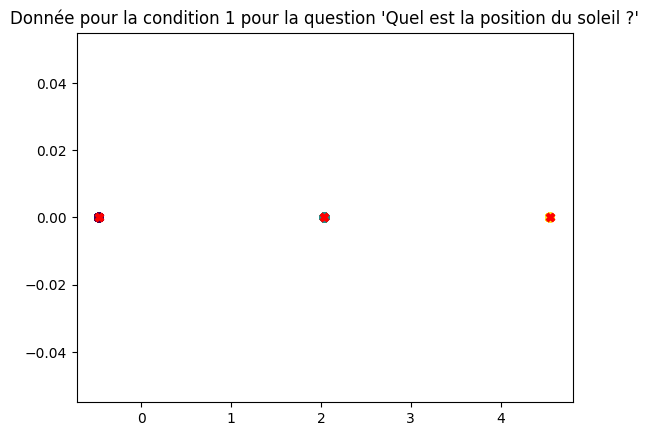

 Finished Mapping


,Sunrise_Sunset,Severity
0,Day,1.0
1,Night,1.0
2,Unknown,1.0


Start Clustering and Mapping Nbr 0/1:
 Start Clustering:
   Scaling,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


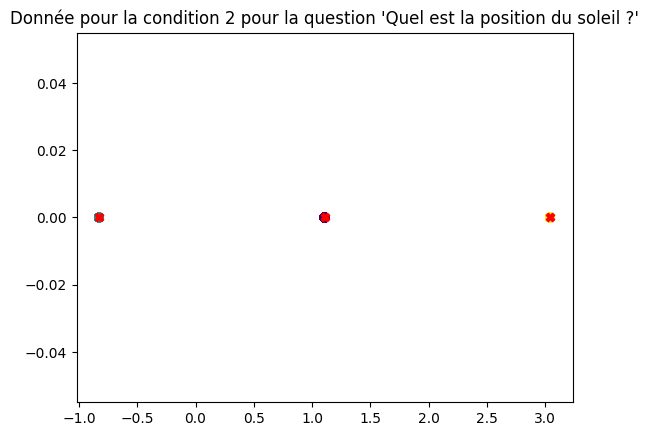

 Finished Mapping


,Sunrise_Sunset,Severity
0,Night,4.0
1,Day,4.0
2,Unknown,4.0


Start Clustering and Mapping Nbr 0/2:
 Start Clustering:
   Scaling,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


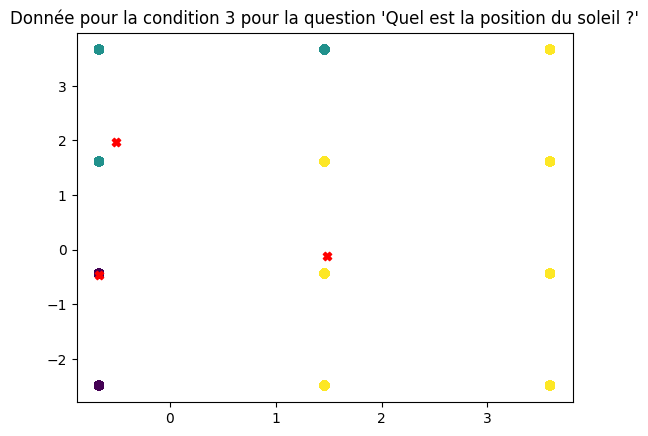

 Finished Mapping


,Sunrise_Sunset,Severity
0,Day,1.987176
1,Day,3.178263
2,Night,2.155040


Start Clustering and Mapping Nbr 1/0:
 Start Clustering:
   Scaling,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


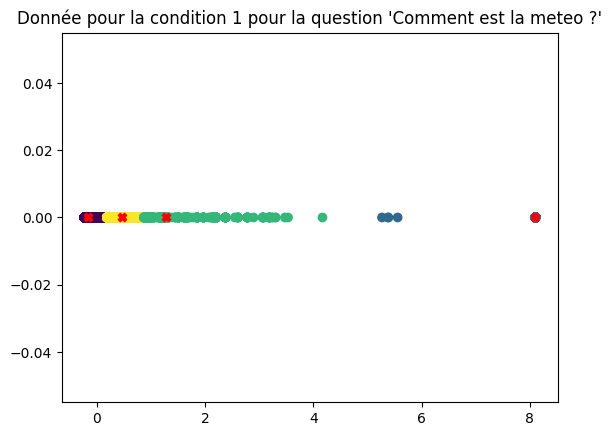

 Finished Mapping


,Weather_Condition,Severity
0,Mostly Cloudy,1.0
1,Unknown,1.0
2,Light Rain / Windy,1.0
3,Fair / Windy,1.0


Start Clustering and Mapping Nbr 1/1:
 Start Clustering:
   Scaling,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


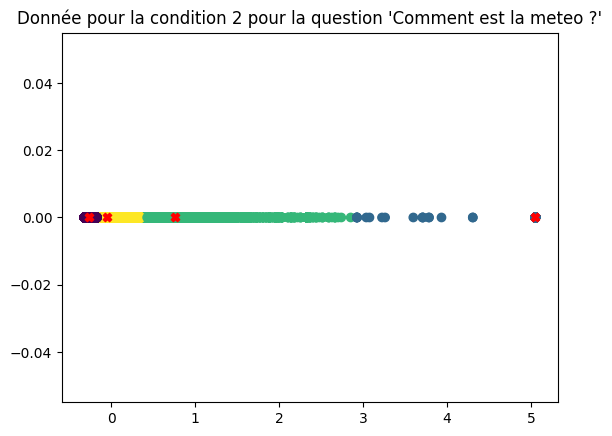

 Finished Mapping


,Weather_Condition,Severity
0,Mostly Cloudy,4.0
1,Unknown,4.0
2,Light Thunderstorms and Rain,4.0
3,Scattered Clouds,4.0


Start Clustering and Mapping Nbr 1/2:
 Start Clustering:
   Scaling,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


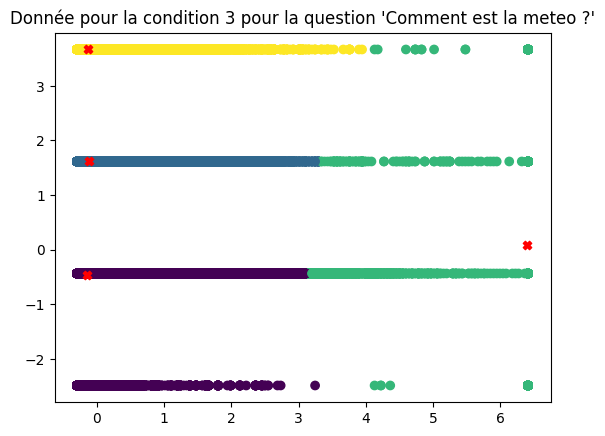

 Finished Mapping


,Weather_Condition,Severity
0,Clear,1.989092
1,Partly Cloudy,3.000000
2,Unknown,2.254228
3,Clear,4.000000


Start Clustering and Mapping Nbr 2/0:
 Start Clustering:
   Scaling,PCAing,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


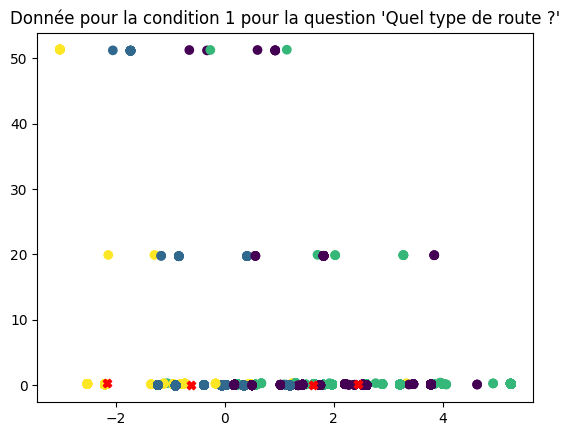

 Finished Mapping


,Severity,Bump,Crossing,Give_Way,Junction,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop
0,1.0,0.000413,9.996458e-01,0.016294,-7.466250e-15,0.045634,7.120684e-17,1.768724e-14,0.047996,0.002007,0.821713,0.0
1,1.0,0.000336,9.608980e-14,0.005896,2.233630e-14,0.000897,-2.002028e-17,-2.407796e-15,0.037346,0.000695,0.237099,0.0
2,1.0,0.000740,6.338393e-01,0.001481,4.072566e-03,0.089226,-4.474857e-16,1.000000e+00,0.051833,0.003332,0.670492,0.0
3,1.0,0.003209,1.476252e-02,0.001926,1.000000e+00,0.003209,2.874169e-16,2.246470e-03,0.007702,0.003851,0.010911,0.0


Start Clustering and Mapping Nbr 2/1:
 Start Clustering:
   Scaling,PCAing,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


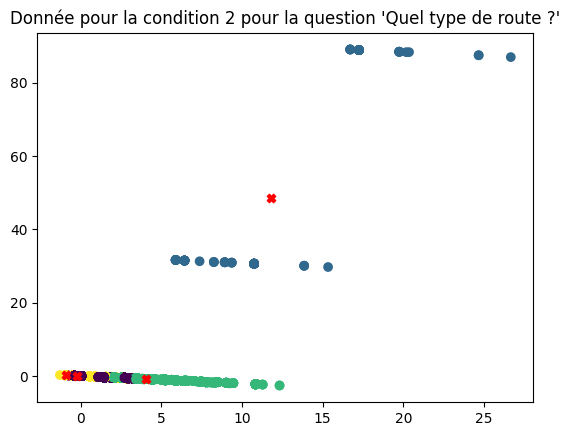

 Finished Mapping


,Severity,Bump,Crossing,Give_Way,Junction,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop
0,4.0,0.000139,0.000650,0.004688,-8.098226e-08,-0.000094,2.942117e-05,0.005174,0.027542,-0.000254,0.064401,0.0
1,4.0,0.421379,1.028643,0.025435,1.413451e-01,-0.070008,4.056410e-05,0.059333,-0.008372,0.783524,-0.095474,0.0
2,4.0,-0.002418,0.943245,0.022147,1.080642e-02,0.109615,-8.287492e-07,0.132532,0.066327,0.004423,0.650041,0.0
3,4.0,-0.000076,0.004883,0.002985,1.000000e+00,0.002354,4.895738e-05,0.001434,0.003558,0.000140,0.005525,0.0


Start Clustering and Mapping Nbr 2/2:
 Start Clustering:
   Scaling

In [ ]:
def get_answer_question():
  list_feat=[['Sunrise_Sunset_indexed','Severity'],['Weather_Condition_indexed', 'Severity'],['Severity','Bump','Crossing','Give_Way','Junction','Railway','Roundabout','Station','Stop','Traffic_Calming','Traffic_Signal','Turning_Loop'],['Severity','Temperature(F)','Wind_Chill(F)','Humidity(%)','Pressure(in)','Visibility(mi)','Wind_Speed(mph)']]
  list_question=['Quel est la position du soleil ?','Comment est la meteo ?','Quel type de route ?','Quelles variable atmospherique ?']
  list_clustering = [3,4,4,5]
  list_pca = [None,None,9,6]
  #all_occurence
  for i in range(len(list_question)):
    temp = df[list_feat[i]]
    databases = [temp[temp['Severity'] == 1],temp[temp['Severity'] == 4],temp]
    for j in range(3):
      if databases[j].count() > 0 :
        print("===========================================================================")
        print(f"Start Clustering and Mapping Nbr {i}/{j}:")
        print(" Start Clustering:")
        data, data_center, data_cluster ,res_cluster = get_clusters(databases[j],list_pca[i],list_clustering[i])
        print(" Finished Clustering")
        print(" Start Mapping:")
        plot_data(data,data_center,f"Donnée pour la condition {j + 1} pour la question '{list_question[i]}'",data_cluster)
        print(" Finished Mapping")
        res_df = transform_to_readable(res_cluster,list_feat[i])
        display(res_df)
        print("===========================================================================")
get_answer_question()


Start Clustering and Mapping Nbr 2/0:
 Start Clustering:
   Scaling,PCAing,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


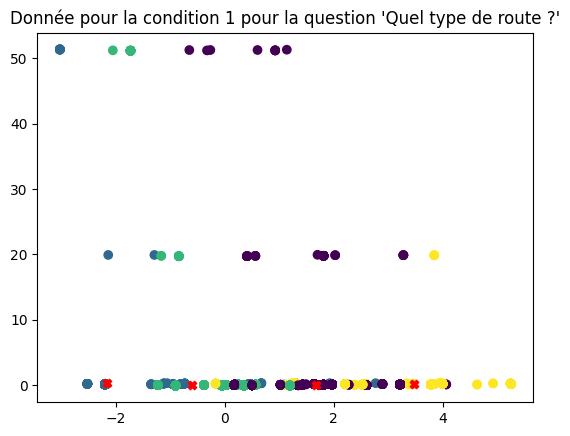

 Finished Mapping


,Severity,Bump,Crossing,Give_Way,Junction,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop
0,1.0,0.000421,0.977494,0.015215,0.000008,-1.714281e-06,-2.311925e-17,0.105124,0.047199,0.002723,0.835173,0.0
1,1.0,0.003434,0.015542,0.001931,0.999976,4.919804e-06,2.840837e-16,0.004192,0.008028,0.003505,0.011234,0.0
2,1.0,0.000351,0.000010,0.005852,-0.000002,4.165547e-07,-2.660537e-17,0.012280,0.038034,0.000502,0.234279,0.0
3,1.0,-0.000132,0.917223,0.003757,0.014112,9.999971e-01,6.899624e-16,0.226495,0.046056,0.003029,0.603391,0.0


Start Clustering and Mapping Nbr 2/1:
 Start Clustering:
   Scaling,PCAing,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


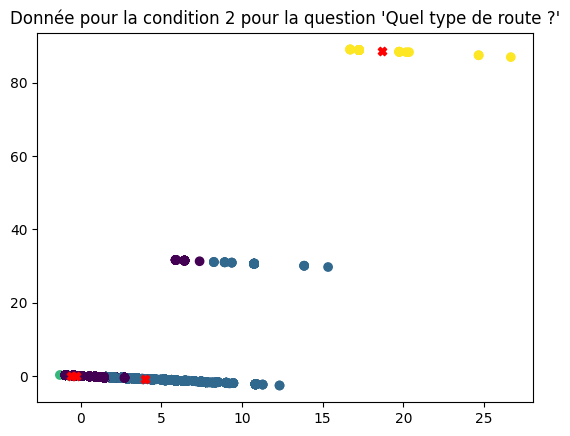

 Finished Mapping


,Severity,Bump,Crossing,Give_Way,Junction,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop
0,4.0,0.000018,0.013470,0.003530,0.105654,-0.001850,0.000001,0.004089,0.022499,0.000085,0.043065,0.0
1,4.0,0.000225,0.749757,0.034319,0.033749,0.130930,-0.000017,0.136306,0.096539,0.002792,0.821554,0.0
2,4.0,0.000124,-0.048283,-0.000244,0.169771,0.006626,0.999995,0.000726,0.505352,-0.000100,0.050514,0.0
3,4.0,0.775834,0.346373,-0.004490,0.065972,0.039214,0.000025,0.157748,0.008281,1.407281,-0.210041,0.0


Start Clustering and Mapping Nbr 2/2:
 Start Clustering:
   Scaling,PCAing,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


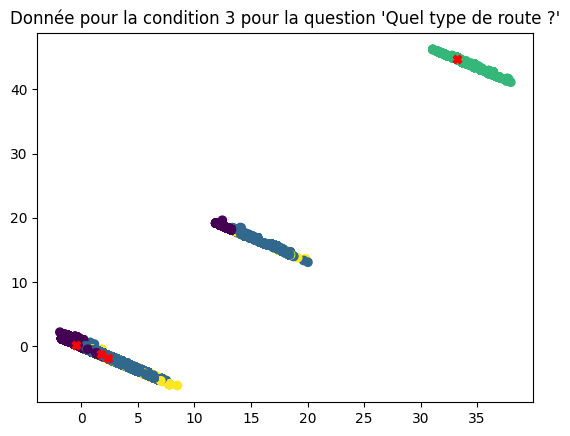

 Finished Mapping


,Severity,Bump,Crossing,Give_Way,Junction,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop
0,2.249981,0.000121,-0.012489,-0.000386,0.091066,0.004376,0.000036,0.007942,0.004456,0.000016,0.016657,0.0
1,2.068545,-0.000118,0.594748,0.001814,0.008771,0.023320,0.000014,0.101635,0.115927,0.001977,0.650161,0.0
2,2.073489,0.840410,0.312407,0.007110,0.009356,0.008425,-0.000225,0.060005,0.156364,1.234704,-0.043576,0.0
3,2.115325,0.000201,0.403928,0.986475,0.012048,0.096965,0.000268,-0.179244,0.121797,0.001507,0.565694,0.0


Start Clustering and Mapping Nbr 3/0:
 Start Clustering:
   Scaling,PCAing,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


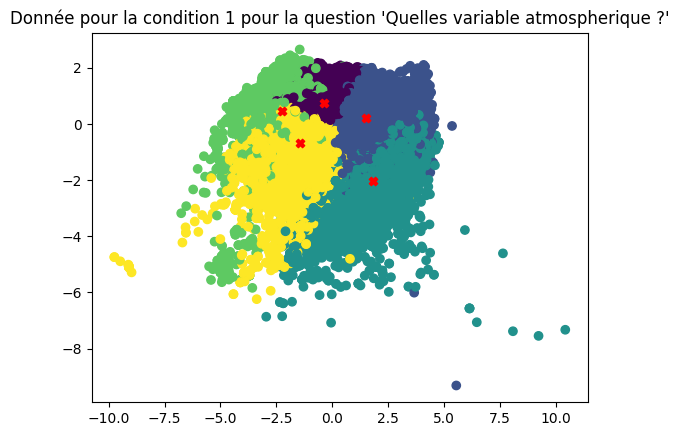

 Finished Mapping


,Severity,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph)
0,1.0,73.684810,73.418444,79.860183,29.588027,9.783071,4.323339
1,1.0,84.292530,83.989659,40.953438,29.327295,9.974908,9.926147
2,1.0,77.446520,77.258828,23.613301,26.296171,10.049023,8.702263
3,1.0,62.218820,61.649029,91.825701,29.392472,3.339218,6.213618
4,1.0,56.177776,55.543673,67.992956,29.577558,9.875727,7.525184


Start Clustering and Mapping Nbr 3/1:
 Start Clustering:
   Scaling,PCAing,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


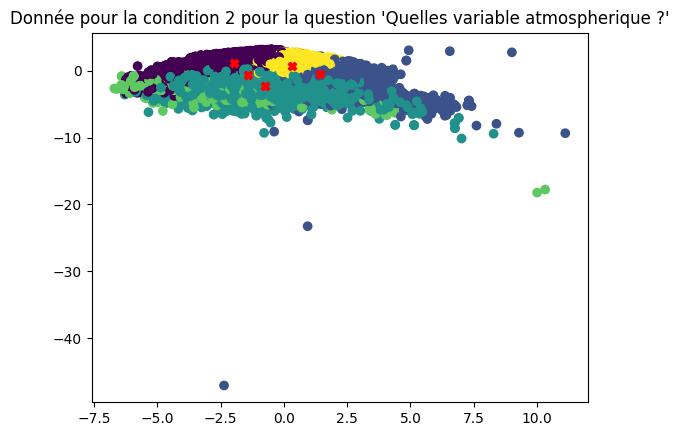

 Finished Mapping


,Severity,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph)
0,4.0,44.641273,43.183162,91.915521,29.508907,2.673912,7.799399
1,4.0,74.372468,70.465468,44.903793,29.605668,10.078388,9.358777
2,4.0,47.838948,44.911248,52.893900,24.351585,9.280888,8.690655
3,4.0,34.574331,30.214795,67.234078,29.659869,9.837304,8.416086
4,4.0,64.109950,63.568992,79.718281,29.716552,9.674743,5.551549


Start Clustering and Mapping Nbr 3/2:
 Start Clustering:
   Scaling,PCAing,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


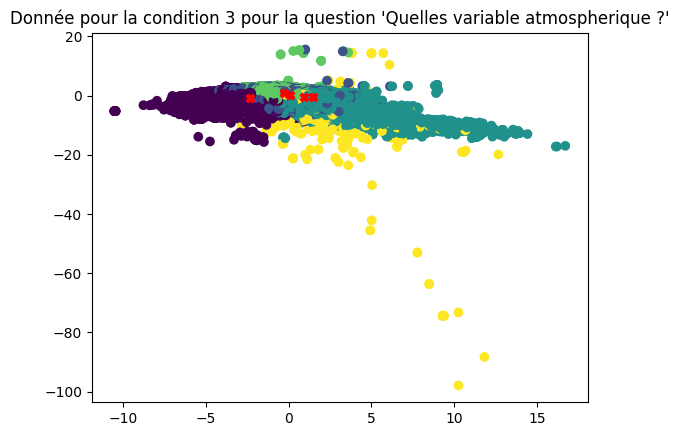

 Finished Mapping


,Severity,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph)
0,2.138188,30.822559,27.209599,73.856056,29.017673,7.834865,8.698817
1,3.157127,64.781679,61.716701,66.957790,29.778841,9.207405,7.524434
2,2.023508,76.585491,73.923314,38.153471,29.223366,10.070662,6.425474
3,1.987130,61.559770,60.597148,79.353510,29.790360,8.779300,4.879856
4,2.021271,71.866360,68.116564,57.457858,29.753697,9.805302,14.126249


In [ ]:
def get_answer_question_end():
  list_feat=[['Severity','Bump','Crossing','Give_Way','Junction','Railway','Roundabout','Station','Stop','Traffic_Calming','Traffic_Signal','Turning_Loop'],['Severity','Temperature(F)','Wind_Chill(F)','Humidity(%)','Pressure(in)','Visibility(mi)','Wind_Speed(mph)']]
  list_question=['Quel type de route ?','Quelles variable atmospherique ?']
  list_clustering = [4,5]
  list_pca = [8,6]
  #end_occurence
  for i in range(len(list_question)):
    temp = df[list_feat[i]]
    databases = [temp[temp['Severity'] == 1],temp[temp['Severity'] == 4],temp]
    for j in range(3):
      if databases[j].count() > 0 :
        print("===========================================================================")
        print(f"Start Clustering and Mapping Nbr {i+2}/{j}:")
        print(" Start Clustering:")
        data, data_center, data_cluster ,res_cluster = get_clusters(databases[j],list_pca[i],list_clustering[i])
        
        print(" Finished Clustering")
        print(" Start Mapping:")
        plot_data(data,data_center,f"Donnée pour la condition {j + 1} pour la question '{list_question[i]}'",data_cluster)
        print(" Finished Mapping")
        res_df = transform_to_readable(res_cluster,list_feat[i])
        display(res_df)
        print("===========================================================================")
get_answer_question_end()

Start Clustering and Mapping Nbr 0/0:
 Start Clustering:
  -with Nbr PCA = None, Nbr Cluster = 3
   Scaling,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


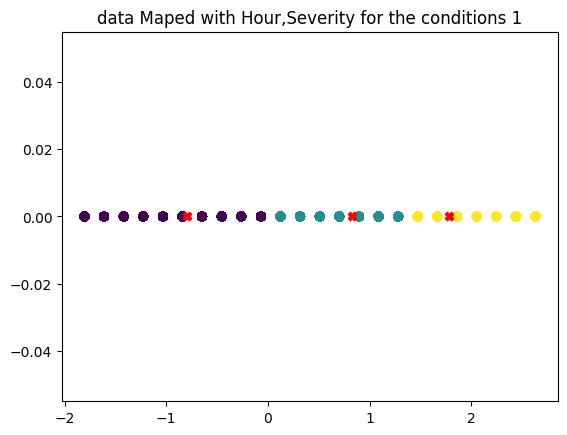

 Finished Mapping


,Hour,Severity
0,5.214155,1.0
1,13.630083,1.0
2,18.581533,1.0


Start Clustering and Mapping Nbr 0/1:
 Start Clustering:
  -with Nbr PCA = None, Nbr Cluster = 3
   Scaling,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


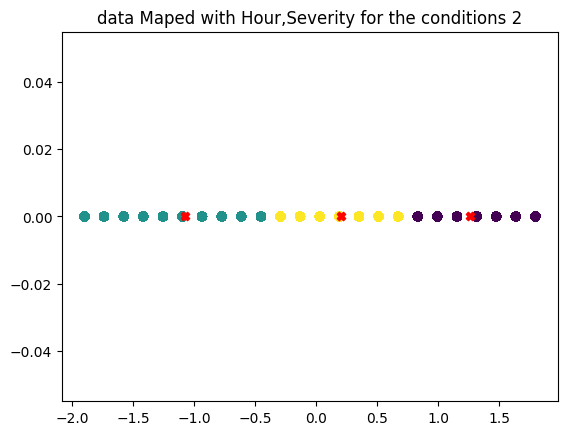

 Finished Mapping


,Hour,Severity
0,19.684667,4.0
1,5.125330,4.0
2,13.095357,4.0


Start Clustering and Mapping Nbr 0/2:
 Start Clustering:
  -with Nbr PCA = None, Nbr Cluster = 3
   Scaling,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


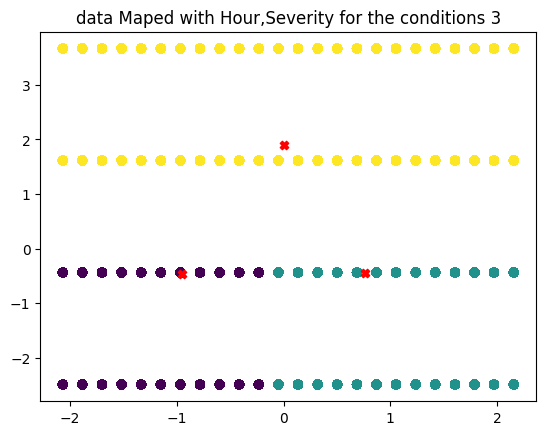

 Finished Mapping


,Hour,Severity
0,6.085120,1.985844
1,15.438008,1.991873
2,11.277379,3.136106


Start Clustering and Mapping Nbr 1/0:
 Start Clustering:
  -with Nbr PCA = None, Nbr Cluster = 3
   Scaling,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


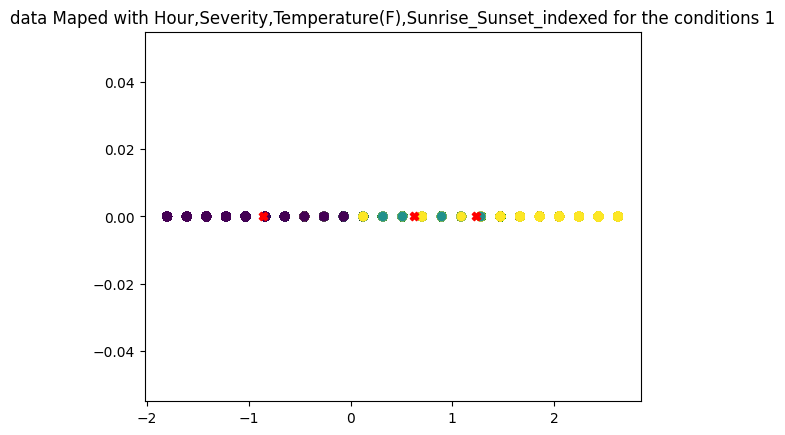

 Finished Mapping


,Hour,Severity,Temperature(F),Sunrise_Sunset
0,4.891824,1.0,67.275011,Day
1,12.571660,1.0,84.819451,Day
2,15.777355,1.0,60.463650,Day


Start Clustering and Mapping Nbr 1/1:
 Start Clustering:
  -with Nbr PCA = None, Nbr Cluster = 3
   Scaling,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


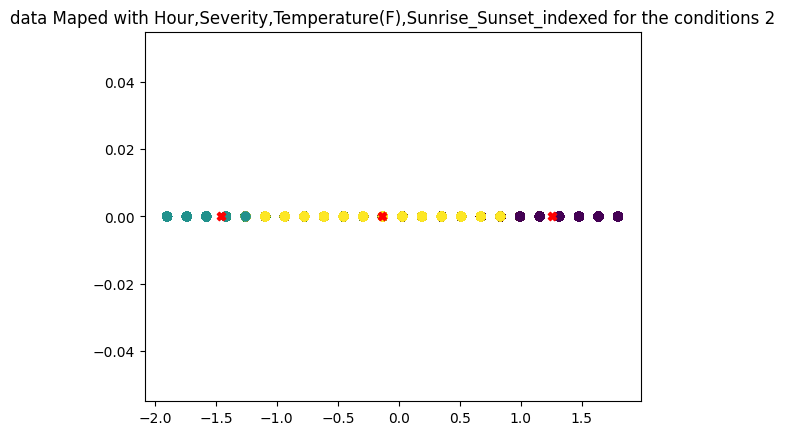

 Finished Mapping


,Hour,Severity,Temperature(F),Sunrise_Sunset
0,19.629660,4.0,53.840479,Night
1,2.757829,4.0,49.506394,Night
2,10.972884,4.0,62.769431,Day


Start Clustering and Mapping Nbr 1/2:
 Start Clustering:
  -with Nbr PCA = None, Nbr Cluster = 3
   Scaling,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


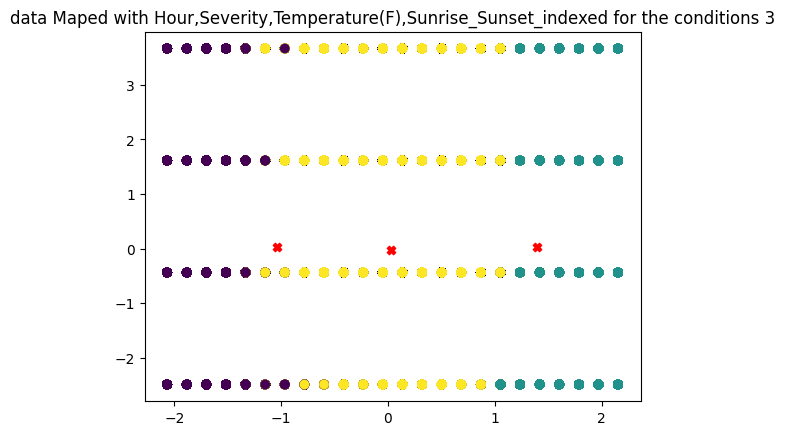

 Finished Mapping


,Hour,Severity,Temperature(F),Sunrise_Sunset
0,5.626746,2.224476,44.60924,Day
1,18.888458,2.223373,55.05818,Night
2,11.409769,2.203050,71.98874,Day


Start Clustering and Mapping Nbr 2/0:
 Start Clustering:
  -with Nbr PCA = 3, Nbr Cluster = 5
   Scaling,PCAing,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


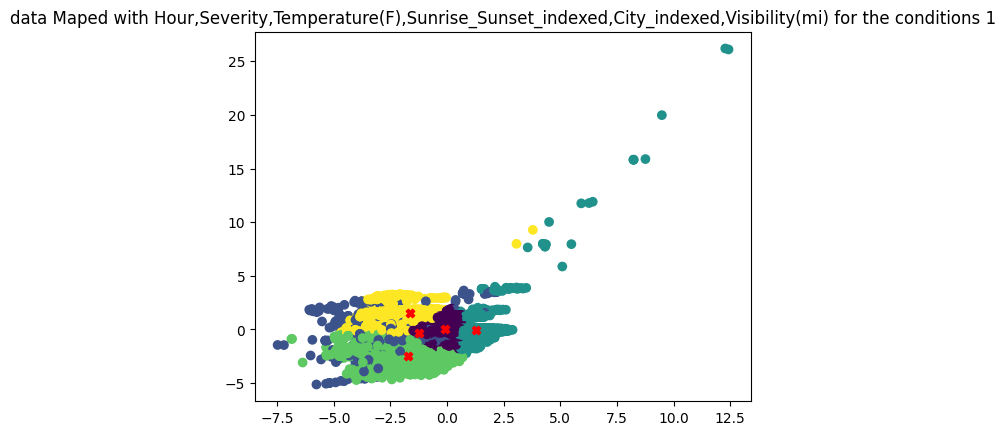

 Finished Mapping


,Hour,Severity,Temperature(F),Sunrise_Sunset,City,Visibility(mi)
0,9.072713,1.0,71.507011,Day,South El Monte,9.371683
1,8.274108,1.0,64.816206,Day,Montesano,9.914496
2,12.753715,1.0,82.569965,Day,San Mateo,10.269268
3,6.557049,1.0,55.058816,Day,Saint Augustine,4.170929
4,3.390384,1.0,60.023678,Night,Encino,10.238067


Start Clustering and Mapping Nbr 2/1:
 Start Clustering:
  -with Nbr PCA = 3, Nbr Cluster = 5
   Scaling,PCAing,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


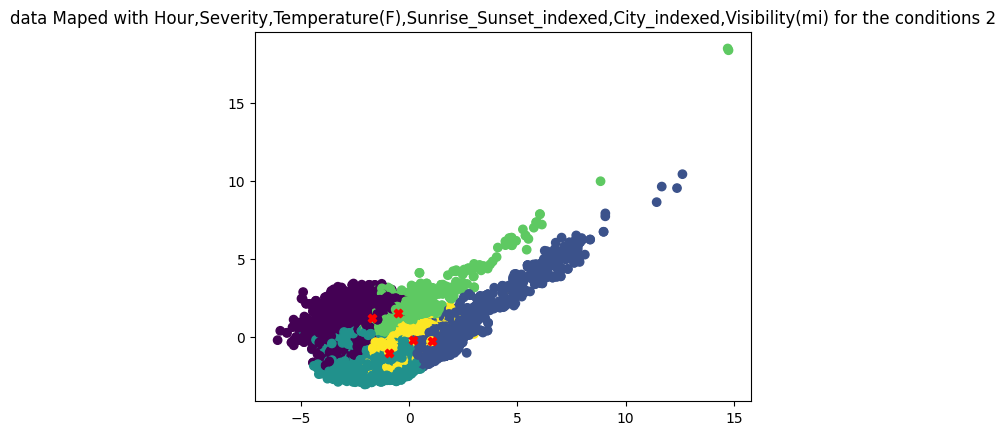

 Finished Mapping


,Hour,Severity,Temperature(F),Sunrise_Sunset,City,Visibility(mi)
0,17.447185,4.0,41.104980,Night,Bechtelsville,8.701686
1,10.387886,4.0,71.136914,Day,Sebastopol,10.056767
2,7.293287,4.0,42.150086,Night,Wytheville,6.562284
3,19.121260,4.0,54.680505,Night,Parkville,10.072741
4,10.492471,4.0,62.586004,Day,Peterborough,9.498716


Start Clustering and Mapping Nbr 2/2:
 Start Clustering:
  -with Nbr PCA = 3, Nbr Cluster = 5
   Scaling,PCAing,kMeaning and Reversing
 Finished Clustering
 Start Mapping:


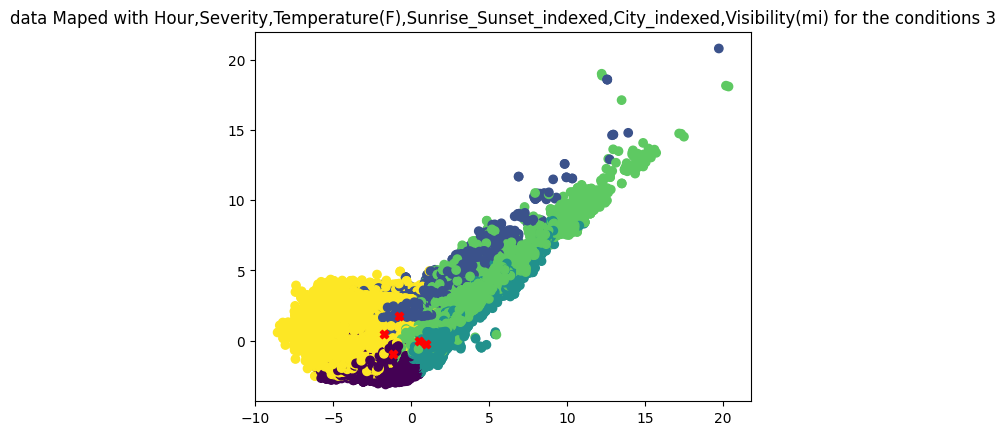

 Finished Mapping


,Hour,Severity,Temperature(F),Sunrise_Sunset,City,Visibility(mi)
0,7.114031,2.053285,44.684173,Day,City Of Industry,6.736352
1,18.800977,2.092242,53.879337,Night,Abingdon,9.868281
2,10.683104,2.044155,72.263256,Day,Fremont,9.805090
3,10.591168,2.763007,70.199255,Day,South Saint Paul,10.021786
4,11.707923,3.422022,46.033090,Night,Fort Monroe,8.548781


In [ ]:
temp_data = None
temp_cluster = None
def get_all_clusters():
  first_features = []
  list_pca = [None,None,3]
  list_clustering = [3,3,5]
  following_feat = [[ 'Hour', 'Severity'],['Temperature(F)','Sunrise_Sunset_indexed'],['City_indexed','Visibility(mi)']]
  #all_occurence
  for i in range(len(list_pca)):
    first_features += following_feat[i]
    temp = df[first_features]
    databases = [temp[temp['Severity'] == 1],temp[temp['Severity'] == 4],temp]
    for j in range(3):
      if databases[j].count() > 0 :
        print("===========================================================================")
        print(f"Start Clustering and Mapping Nbr {i}/{j}:")
        print(" Start Clustering:")
        print(f"  -with Nbr PCA = {list_pca[i]}, Nbr Cluster = {list_clustering[i]}")
        data, data_center, data_cluster ,res_cluster = get_clusters(databases[j],list_pca[i],list_clustering[i])
        
        print(" Finished Clustering")
        print(" Start Mapping:")
        plot_data(data,data_center,f"data Maped with {','.join(first_features)} for the conditions {j+1}",data_cluster)
        print(" Finished Mapping")
        res_df = transform_to_readable(res_cluster,first_features)
        display(res_df)
        print("===========================================================================")
get_all_clusters()